In [1]:
# ============================================================
# CÉLULA 1.1 — CONFIGURAÇÃO DO AMBIENTE
# Artigo: regulação de armas e homicídios no Brasil
# ============================================================

# Instalação dos pacotes que não vêm completos no Google Colab
!pip install -q linearmodels openpyxl

# Manipulação e organização dos dados
import os
import re
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

# Estatística e econometria
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare

# Gráficos
import matplotlib.pyplot as plt

# Exibição no Google Colab
from IPython.display import display, Markdown

# Configurações gerais
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Diretórios de saída
PASTA_RESULTADOS = Path("/content/resultados_artigo")
PASTA_TABELAS = PASTA_RESULTADOS / "tabelas"
PASTA_GRAFICOS = PASTA_RESULTADOS / "graficos"
PASTA_BASES = PASTA_RESULTADOS / "bases_processadas"

for pasta in [PASTA_RESULTADOS, PASTA_TABELAS, PASTA_GRAFICOS, PASTA_BASES]:
    pasta.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("AMBIENTE CONFIGURADO COM SUCESSO")
print("=" * 70)
print(f"Versão do pandas:       {pd.__version__}")
print(f"Versão do NumPy:        {np.__version__}")
print(f"Pasta de resultados:    {PASTA_RESULTADOS}")
print(f"Seed de reprodução:     {SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.6 MB/s eta 0:00:00
AMBIENTE CONFIGURADO COM SUCESSO
Versão do pandas:       2.2.2
Versão do NumPy:        2.0.2
Pasta de resultados:    /content/resultados_artigo
Seed de reprodução:     42


# Preparação e Upload

In [2]:
# ============================================================
# CÉLULA 1.2 — UPLOAD E LEITURA DA BASE DE DADOS
#               VERSÃO ATUALIZADA — painel_expandido (2005–2024)
# ============================================================
from google.colab import files
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. Upload do arquivo
# ------------------------------------------------------------
print("Selecione a planilha com a base de dados do artigo.")
print("Arquivo esperado: Base_CAC_UF_Ano_2016_2025_v5.xlsx (ou versão mais recente).")
arquivos_enviados = files.upload()

if not arquivos_enviados:
    raise ValueError("Nenhum arquivo foi enviado.")

nomes_arquivos = list(arquivos_enviados.keys())
print("\nArquivos enviados:")
for i, nome in enumerate(nomes_arquivos, start=1):
    tamanho_mb = len(arquivos_enviados[nome]) / (1024 ** 2)
    print(f"{i}. {nome} — {tamanho_mb:.2f} MB")

# ------------------------------------------------------------
# 2. Seleção automática do primeiro arquivo compatível
# ------------------------------------------------------------
extensoes_validas = (".xlsx", ".xls", ".xlsm", ".csv")
arquivos_dados = [
    n for n in nomes_arquivos
    if n.lower().endswith(extensoes_validas)
]

if not arquivos_dados:
    raise ValueError(
        "Nenhum arquivo Excel ou CSV identificado. "
        "Formatos aceitos: .xlsx, .xls, .xlsm e .csv."
    )

ARQUIVO_BASE = arquivos_dados[0]
CAMINHO_BASE = Path("/content") / ARQUIVO_BASE

print(f"\nArquivo selecionado: {CAMINHO_BASE}")

# ------------------------------------------------------------
# 3. Configuração de leitura da aba flat principal
# ------------------------------------------------------------
# A aba 'painel_expandido' é a base decidida no briefing de
# continuidade: 27 UFs × 20 anos (2005–2024) = 540 obs.
# Import conforme documentado na própria planilha:
#   pd.read_excel(..., sheet_name='painel_expandido', header=1)
#       .dropna(subset=['uf']).set_index(['uf','ano'])
#
# A aba possui uma coluna A vazia antes de 'uf' (offset de
# formatação do Excel) — é descartada na leitura por posição.
#
# 'dados_crs' permanece disponível como aba flat alternativa,
# mas não é mais a prioridade de carregamento.

ABAS_FLAT = ["painel_expandido", "painel", "dados_crs"]

ABAS_CONFIG = {
    "painel_expandido": {
        "header":     1,        # linha 2 do Excel contém os nomes Python
        "index_cols": ["uf", "ano"],
        "coluna_offset_vazia": True,  # descarta 1ª coluna (sem nome, vazia)
        "dtypes": {
            "uf":          str,
            "ano":         int,
            "hom100":      float,
            "crs100":      float,
            "estoque_crs": float,  # CRs acumulados desde 2005 por UF
            "ln_hom":      float,
            "ln_crs":      float,
            "pibpc":       float,
            "ln_pibpc":    float,
            "desemp":      float,
            "post":        int,
            "d_pan":       int,
            "int_i":       float,
            "pop":         float,  # população residente (hab.) — IBGE
        },
        "descricao": (
            "Painel para estimação — 27 UFs × 20 anos (2005–2024) = 540 obs. | "
            "Variáveis: hom100, crs100, estoque_crs, ln_hom, ln_crs, pibpc, "
            "ln_pibpc, desemp, post, d_pan, int_i, pop"
        ),
    },
    "painel": {
        "header":     2,
        "index_cols": ["uf", "ano"],
        "coluna_offset_vazia": False,
        "dtypes": {
            "uf":       str,
            "ano":      int,
            "hom100":   float,
            "crs100":   float,
            "ln_hom":   float,
            "ln_crs":   float,
            "pibpc":    float,
            "ln_pibpc": float,
            "desemp":   float,
            "post":     int,
            "d_pan":    int,
            "int_i":    float,
            "pop":      float,
        },
        "descricao": (
            "[LEGADO] Painel curto — 27 UFs × 8 anos (2016–2023) = 216 obs. "
            "Mantido apenas como fallback; não é mais a base principal."
        ),
    },
    "dados_crs": {
        "header":     2,
        "index_cols": None,
        "coluna_offset_vazia": False,
        "dtypes": {
            "uf":  str,
            "ano": int,
            "crs": int,
        },
        "descricao": (
            "CRs emitidos por UF e ano — formato long | "
            "27 UFs × 10 anos (2016–2025) = 270 obs."
        ),
    },
}

# ------------------------------------------------------------
# 4. Leitura do arquivo
# ------------------------------------------------------------
extensao = CAMINHO_BASE.suffix.lower()

if extensao in [".xlsx", ".xls", ".xlsm"]:

    excel      = pd.ExcelFile(CAMINHO_BASE)
    abas_disco = excel.sheet_names

    print("\nAbas disponíveis:")
    for i, aba in enumerate(abas_disco, start=1):
        tag = "  ★ flat" if aba in ABAS_FLAT else ""
        print(f"  {i:2d}. {aba}{tag}")

    # Detecta a primeira aba flat presente na planilha,
    # respeitando a ordem de prioridade de ABAS_FLAT.
    aba_flat = next((a for a in ABAS_FLAT if a in abas_disco), None)

    if aba_flat:
        cfg      = ABAS_CONFIG[aba_flat]
        ABA_BASE = aba_flat

        # Leitura com header na linha correta
        df_original = pd.read_excel(
            CAMINHO_BASE,
            sheet_name=ABA_BASE,
            header=cfg["header"],
        )

        # Remove a coluna A vazia (offset de formatação), quando aplicável
        if cfg.get("coluna_offset_vazia"):
            df_original = df_original.iloc[:, 1:].copy()

        # Remove linha de descrição / linhas sem UF válida.
        # Usa a coluna 'uf' (após o offset) como critério, não o
        # comprimento de string bruto, para não descartar colunas
        # numéricas longas (como pop ou estoque_crs).
        df_original = df_original.dropna(subset=[df_original.columns[0]])
        df_original = df_original[
            df_original.iloc[:, 0].astype(str).str.len() <= 4
        ]

        # Garante que os nomes das colunas são os nomes Python esperados.
        nomes_esperados = list(cfg["dtypes"].keys())
        if list(df_original.columns[:len(nomes_esperados)]) != nomes_esperados:
            df_original.columns = (
                nomes_esperados[:df_original.shape[1]]
            )

        # Aplica tipos de dados
        for col, tipo in cfg["dtypes"].items():
            if col in df_original.columns:
                try:
                    df_original[col] = df_original[col].astype(tipo)
                except (ValueError, TypeError):
                    pass  # mantém original se a conversão falhar

        # Define índice de painel (uf, ano)
        if cfg["index_cols"]:
            df_original = df_original.set_index(cfg["index_cols"])

        print(f"\n✅ Aba flat '{ABA_BASE}' carregada com sucesso.")
        print(f"   {cfg['descricao']}")

        if ABA_BASE != "painel_expandido":
            print(
                "\n⚠️  ATENÇÃO: a aba principal 'painel_expandido' não foi "
                f"encontrada. Carregando '{ABA_BASE}' como fallback. "
                "Confirme se o arquivo enviado é a versão v5 (ou mais recente) "
                "da base."
            )

    else:
        # Fallback: carrega a primeira aba sem tratamento
        ABA_BASE    = abas_disco[0]
        df_original = pd.read_excel(CAMINHO_BASE, sheet_name=ABA_BASE)

        print(f"\n⚠️  Nenhuma aba flat encontrada.")
        print(f"   Carregando '{ABA_BASE}' sem tratamento automático.")
        print(f"   Abas flat esperadas: {ABAS_FLAT}")
        print(f"   As colunas podem aparecer com nomes automáticos (Unnamed: N).")

elif extensao == ".csv":
    ABA_BASE = None
    for enc in ["utf-8", "latin-1"]:
        try:
            df_original = pd.read_csv(
                CAMINHO_BASE,
                sep=None,
                engine="python",
                encoding=enc,
            )
            break
        except UnicodeDecodeError:
            continue

else:
    raise ValueError(f"Extensão '{extensao}' não suportada.")

# ------------------------------------------------------------
# 5. Cópia de trabalho
# ------------------------------------------------------------
# df_original: preservado intacto durante toda a sessão.
# df: cópia de trabalho usada nas células seguintes.
df = df_original.copy()

# ------------------------------------------------------------
# 6. Diagnóstico inicial
# ------------------------------------------------------------
n_obs  = df.shape[0]
n_cols = df.shape[1]
n_dup  = df.duplicated().sum()
n_na   = df.isna().sum().sum()

print("\n" + "=" * 75)
print("BASE CARREGADA COM SUCESSO")
print("=" * 75)
print(f"Arquivo:              {ARQUIVO_BASE}")
print(f"Aba:                  {ABA_BASE or 'CSV'}")
print(f"Observações:          {n_obs:,}")
print(f"Colunas:              {n_cols:,}")
print(f"Duplicatas integrais: {n_dup:,}")
print(f"Células ausentes:     {n_na:,}")
print(f"Índice:               {list(df.index.names)}")

print("\nColunas e tipos:")
for col, dtype in zip(df.columns, df.dtypes):
    n_miss   = df[col].isna().sum()
    miss_str = f"  ← {n_miss} missing" if n_miss > 0 else ""
    print(f"  {col:<14} {str(dtype):<10}{miss_str}")

print("\nPrimeiras 5 observações:")
display(df.head())

print("\nEstatísticas descritivas (variáveis numéricas):")
display(df.describe().round(4))


Selecione a planilha com a base de dados do artigo.
Arquivo esperado: Base_CAC_UF_Ano_2016_2025_v5.xlsx (ou versão mais recente).


Saving Base_CAC_2005_2024.xlsx to Base_CAC_2005_2024.xlsx

Arquivos enviados:
1. Base_CAC_2005_2024.xlsx — 0.22 MB

Arquivo selecionado: /content/Base_CAC_2005_2024.xlsx

Abas disponíveis:
   1. CRs_por_UF_Ano
   2. Serie_Nacional
   3. Notas_Metodologicas
   4. Estoque_Total_UF
   5. Estoque_UsoRestrito_UF
   6. Estoque_UsoPermitido_UF
   7. Var_Tratamento_DiD
   8. Homicidios_ArmaFogo_UF
   9. PIB_UF_IBGE
  10. Populacao_UF
  11. PIB_PerCapita_UF
  12. Desemprego_UF
  13. Painel_Variaveis_Modelos
  14. painel  ★ flat
  15. dados_crs  ★ flat
  16. CRs_Expandido_2005_2025
  17. Homicidios_2005_2024
  18. Populacao_2005_2024
  19. Desemprego_2005_2024
  20. painel_expandido  ★ flat

✅ Aba flat 'painel_expandido' carregada com sucesso.
   Painel para estimação — 27 UFs × 20 anos (2005–2024) = 540 obs. | Variáveis: hom100, crs100, estoque_crs, ln_hom, ln_crs, pibpc, ln_pibpc, desemp, post, d_pan, int_i, pop

BASE CARREGADA COM SUCESSO
Arquivo:              Base_CAC_2005_2024.xlsx
Aba:    

hom100  crs100  estoque_crs  ln_hom  ln_crs  pibpc  ln_pibpc  desemp  post  d_pan   int_i     pop
uf ano                                                                                                    
uf ano   hom100  crs100  estoque_crs  ln_hom  ln_crs  pibpc  ln_pibpc  desemp  post  d_pan   int_i     pop
AC 2005  5.3800       0            0  3.5835     NaN   6694    8.8090 11.3300     0      0 72.8900  669736
   2006  6.7000  0.1500            1  3.8286       0   7041    8.8595  8.5800     0      0 72.8900  686652
   2007  7.4800       0            1  3.8918     NaN   8790    9.0814  5.7900     0      0 72.8900  655385
   2008  5.7300       0            1  3.6636     NaN   9896    9.1999  7.7400     0      0 72.8900  680075


Estatísticas descritivas (variáveis numéricas):


,hom100,crs100,estoque_crs,ln_hom,ln_crs,pibpc,ln_pibpc,desemp,post,d_pan,int_i,pop
count,541.0000,541,541,541.0000,499.0000,541,541.0000,541.0000,541,541,541.0000,541
unique,503.0000,360,416,491.0000,313.0000,540,538.0000,339.0000,3,3,28.0000,514
top,15.0400,0,0,7.4599,2.0794,22544,10.0232,11.2000,0,0,72.8900,3127683
freq,3.0000,42,16,3.0000,14.0000,2,2.0000,8.0000,486,486,20.0000,2


In [3]:
# ============================================================
# CÉLULA 1.3 — VALIDAÇÃO E PREPARAÇÃO DO PAINEL
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Preservação da base importada
# ------------------------------------------------------------
df_importado = df.copy()
painel       = df.copy()

# Garante MultiIndex (uf, ano)
if not isinstance(painel.index, pd.MultiIndex):
    if {"uf", "ano"}.issubset(painel.columns):
        painel = painel.set_index(["uf", "ano"])
    else:
        raise ValueError(
            "A base deve possuir um MultiIndex (uf, ano) "
            "ou as colunas 'uf' e 'ano'."
        )

painel.index = painel.index.set_names(["uf", "ano"])

# Conversão temporária para colunas — limpeza dos identificadores
painel = painel.reset_index()

painel["uf"] = (
    painel["uf"]
    .astype(str)
    .str.strip()
    .str.upper()
)

painel["ano"] = pd.to_numeric(
    painel["ano"], errors="coerce"
).astype("Int64")

# Lista oficial das 27 UFs
UFS_VALIDAS = {
    "AC", "AL", "AP", "AM", "BA", "CE", "DF",
    "ES", "GO", "MA", "MT", "MS", "MG", "PA",
    "PB", "PR", "PE", "PI", "RJ", "RN", "RS",
    "RO", "RR", "SC", "SP", "SE", "TO",
}

# ── CORREÇÃO: filtra pela coluna 'uf' explicitamente ─────────
# Usa isin(UFS_VALIDAS) em vez de str.len() <= 4
# Evita descartar colunas com valores longos (como pop)
painel = painel[
    painel["uf"].isin(UFS_VALIDAS) & painel["ano"].notna()
].copy()

painel["ano"] = painel["ano"].astype(int)

# ------------------------------------------------------------
# 2. Verificação das colunas esperadas
# ------------------------------------------------------------
COLUNAS_OBRIGATORIAS = [
    "hom100", "crs100",
    "ln_hom", "ln_crs",
    "pibpc",  "ln_pibpc",
    "desemp", "post", "d_pan", "int_i",
]
COLUNAS_OPCIONAIS = ["pop", "estoque_crs"]

colunas_ausentes = [
    c for c in COLUNAS_OBRIGATORIAS if c not in painel.columns
]
if colunas_ausentes:
    raise ValueError(
        "Colunas obrigatórias não encontradas: "
        + ", ".join(colunas_ausentes)
        + "\nVerifique se a planilha carregada é a versão atualizada "
          "(Base_CAC_UF_Ano_2016_2025_v5.xlsx, ou mais recente) com a "
          "aba 'painel_expandido'."
    )

# Verifica pop separadamente — avisa mas não bloqueia
TEM_POP = "pop" in painel.columns
if not TEM_POP:
    print("⚠️  Coluna 'pop' não encontrada.")
    print("   Carregue a planilha v5 (ou mais recente) para usar modelos ponderados.")
    print("   Prosseguindo sem pop.")
else:
    n_pop_missing = int(painel["pop"].isna().sum())
    n_pop_zero    = int((painel["pop"] == 0).sum())
    if n_pop_missing > 0 or n_pop_zero > 0:
        print(f"⚠️  pop: {n_pop_missing} missing, {n_pop_zero} zeros.")
    else:
        print(f"✅  pop: {int(painel['pop'].notna().sum())} valores válidos — "
              f"pronta para uso como peso.")

# Verifica estoque_crs separadamente — nova coluna do painel_expandido,
# não existe na aba 'painel' legada. Avisa mas não bloqueia.
TEM_ESTOQUE_CRS = "estoque_crs" in painel.columns
if not TEM_ESTOQUE_CRS:
    print("⚠️  Coluna 'estoque_crs' não encontrada.")
    print("   Disponível apenas na aba 'painel_expandido'. Modelos de")
    print("   robustez com estoque acumulado de CRs não poderão ser estimados.")
else:
    n_estoque_missing = int(painel["estoque_crs"].isna().sum())
    print(f"✅  estoque_crs: {int(painel['estoque_crs'].notna().sum())} valores "
          f"válidos ({n_estoque_missing} missing).")

# Converte para float
for coluna in COLUNAS_OBRIGATORIAS:
    painel[coluna] = pd.to_numeric(painel[coluna], errors="coerce")

if TEM_POP:
    painel["pop"] = pd.to_numeric(painel["pop"], errors="coerce")

if TEM_ESTOQUE_CRS:
    painel["estoque_crs"] = pd.to_numeric(painel["estoque_crs"], errors="coerce")

# ------------------------------------------------------------
# 3. Logaritmos das taxas
# ------------------------------------------------------------
# ln_hom e ln_crs da planilha foram calculados a partir dos
# valores absolutos. Criamos versões a partir das taxas por 100mil.

painel["ln_hom100"]   = np.where(
    painel["hom100"] > 0, np.log(painel["hom100"]), np.nan
)
painel["ln1p_hom100"] = np.log1p(painel["hom100"].clip(lower=0))

painel["ln_crs100"]   = np.where(
    painel["crs100"] > 0, np.log(painel["crs100"]), np.nan
)
painel["ln1p_crs100"] = np.log1p(painel["crs100"].clip(lower=0))

if TEM_POP:
    painel["ln_pop"] = np.where(
        painel["pop"] > 0, np.log(painel["pop"]), np.nan
    )

# ------------------------------------------------------------
# 4. Variáveis auxiliares do desenho econométrico
# ------------------------------------------------------------

# Intensidade padronizada (z-score)
media_int  = painel["int_i"].mean()
desvio_int = painel["int_i"].std(ddof=1)

if pd.isna(desvio_int) or desvio_int == 0:
    raise ValueError(
        "int_i não possui variação suficiente para padronização."
    )

painel["int_i_z"]        = (painel["int_i"] - media_int) / desvio_int
painel["did_continuo"]   = painel["int_i"]   * painel["post"]
painel["did_continuo_z"] = painel["int_i_z"] * painel["post"]
painel["pre_2023"]        = (painel["ano"] < 2023).astype(int)
painel["ano_2023"]        = (painel["ano"] == 2023).astype(int)

if TEM_POP:
    painel["peso_pop"] = painel["pop"] / painel["pop"].mean()

# ------------------------------------------------------------
# 5. Verificações do desenho econométrico
# ------------------------------------------------------------

# 5a. Anos com post = 1
anos_post = sorted(
    painel.loc[painel["post"] == 1, "ano"].dropna().unique().tolist()
)

# 5b. int_i deve ser constante dentro de cada UF
var_int_uf = (
    painel.groupby("uf")["int_i"]
    .nunique(dropna=False)
)
ufs_int_variavel = var_int_uf[var_int_uf > 1].index.tolist()

# 5c. ln_crs missing (crs100 = 0)
diagnostico_ln_crs = painel.loc[
    painel["ln_crs"].isna(),
    ["uf", "ano", "crs100", "ln_crs", "ln1p_crs100"],
].copy()

# ------------------------------------------------------------
# 6. Verificação da estrutura do painel
# ------------------------------------------------------------
n_dup = int(
    painel.duplicated(subset=["uf", "ano"], keep=False).sum()
)

anos_observados = sorted(painel["ano"].unique().tolist())
grade_esperada  = pd.MultiIndex.from_product(
    [sorted(UFS_VALIDAS), anos_observados],
    names=["uf", "ano"],
)
indice_observado     = pd.MultiIndex.from_frame(painel[["uf", "ano"]])
combinacoes_ausentes = grade_esperada.difference(indice_observado)

contagem_por_uf   = painel.groupby("uf")["ano"].nunique().sort_values()
painel_balanceado = (
    n_dup == 0
    and len(combinacoes_ausentes) == 0
    and contagem_por_uf.nunique() == 1
)

# ------------------------------------------------------------
# 7. Organização final e exportação
# ------------------------------------------------------------
painel = painel.sort_values(["uf", "ano"]).set_index(["uf", "ano"])
df     = painel.copy()

# ------------------------------------------------------------
# 8. Relatório de validação
# ------------------------------------------------------------
print("=" * 78)
print("VALIDAÇÃO E PREPARAÇÃO DO PAINEL")
print("=" * 78)
print(f"Observações:                   {len(df):,}")
print(f"Número de UFs:                 {df.index.get_level_values('uf').nunique()}")
print(f"Período:                       "
      f"{df.index.get_level_values('ano').min()}–"
      f"{df.index.get_level_values('ano').max()}")
print(f"Anos disponíveis:              {anos_observados}")
print(f"Duplicidades UF × ano:         {n_dup}")
print(f"Combinações ausentes:          {len(combinacoes_ausentes)}")
print(f"Painel balanceado:             "
      f"{'✅ SIM' if painel_balanceado else '❌ NÃO'}")
print(f"Anos com post = 1:             {anos_post}")
print(f"int_i constante por UF:        "
      f"{'✅ SIM' if not ufs_int_variavel else '❌ NÃO — ' + str(ufs_int_variavel)}")
print(f"Obs. com crs100 = 0:           {(df['crs100'] == 0).sum()}")
print(f"Missing em ln_crs:             {df['ln_crs'].isna().sum()}")
print(f"Missing em ln_crs100:          {df['ln_crs100'].isna().sum()}")
print(f"Missing em ln1p_crs100:        0  (ln1p nunca é missing)")

if TEM_POP:
    print(f"Missing em pop:                {df['pop'].isna().sum()}")
    print(f"Missing em ln_pop:             {df['ln_pop'].isna().sum()}")
    print(f"pop mín / máx:                 "
          f"{df['pop'].min():,.0f} / {df['pop'].max():,.0f}")
else:
    print("pop:                           ⚠️  não disponível")

if ufs_int_variavel:
    print(f"\n⚠️  int_i varia ao longo do tempo: {ufs_int_variavel}")

if len(combinacoes_ausentes) > 0:
    print(f"\nCombinações UF × ano ausentes:")
    print(list(combinacoes_ausentes))

if len(diagnostico_ln_crs) > 0:
    print(f"\nObservações com ln_crs missing ({len(diagnostico_ln_crs)} casos):")
    display(diagnostico_ln_crs)
else:
    print("\n✅  Sem missing em ln_crs.")

print("\nVariáveis disponíveis no df:")
for i, coluna in enumerate(df.columns, start=1):
    n_miss   = df[coluna].isna().sum()
    miss_str = f"  ← {n_miss} missing" if n_miss > 0 else ""
    print(f"  {i:02d}. {coluna:<18} {str(df[coluna].dtype):<10}{miss_str}")

print("\nPrimeiras 10 observações:")
display(df.head(10))

✅  pop: 540 valores válidos — pronta para uso como peso.
✅  estoque_crs: 540 valores válidos (0 missing).
VALIDAÇÃO E PREPARAÇÃO DO PAINEL
Observações:                   540
Número de UFs:                 27
Período:                       2005–2024
Anos disponíveis:              [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Duplicidades UF × ano:         0
Combinações ausentes:          0
Painel balanceado:             ✅ SIM
Anos com post = 1:             [2023, 2024]
int_i constante por UF:        ✅ SIM
Obs. com crs100 = 0:           42
Missing em ln_crs:             42
Missing em ln_crs100:          42
Missing em ln1p_crs100:        0  (ln1p nunca é missing)
Missing em pop:                0
Missing em ln_pop:             0
pop mín / máx:                 391,317 / 46,649,132

Observações com ln_crs missing (42 casos):


,uf,ano,crs100,ln_crs,ln1p_crs100
1,AC,2005,0.0000,NaN,0.0000
3,AC,2007,0.0000,NaN,0.0000
4,AC,2008,0.0000,NaN,0.0000
5,AC,2009,0.0000,NaN,0.0000
6,AC,2010,0.0000,NaN,0.0000
7,AC,2011,0.0000,NaN,0.0000
8,AC,2012,0.0000,NaN,0.0000
10,AC,2014,0.0000,NaN,0.0000
11,AC,2015,0.0000,NaN,0.0000
22,AL,2006,0.0000,NaN,0.0000



Variáveis disponíveis no df:
  01. hom100             float64   
  02. crs100             float64   
  03. estoque_crs        int64     
  04. ln_hom             float64   
  05. ln_crs             float64     ← 42 missing
  06. pibpc              int64     
  07. ln_pibpc           float64   
  08. desemp             float64   
  09. post               int64     
  10. d_pan              int64     
  11. int_i              float64   
  12. pop                int64     
  13. ln_hom100          float64   
  14. ln1p_hom100        float64   
  15. ln_crs100          float64     ← 42 missing
  16. ln1p_crs100        float64   
  17. ln_pop             float64   
  18. int_i_z            float64   
  19. did_continuo       float64   
  20. did_continuo_z     float64   
  21. pre_2023           int64     
  22. ano_2023           int64     
  23. peso_pop           float64   

Primeiras 10 observações:


hom100  crs100  estoque_crs  ln_hom  ln_crs  pibpc  ln_pibpc  desemp  post  d_pan   int_i     pop  ln_hom100  ln1p_hom100  ln_crs100  ln1p_crs100  ln_pop  int_i_z  \
uf ano                                                                                                                                                                        
AC 2005  5.3800  0.0000            0  3.5835     NaN   6694    8.8090 11.3300     0      0 72.8900  669736     1.6827       1.8532        NaN       0.0000 13.4146  -0.8023   
   2006  6.7000  0.1500            1  3.8286  0.0000   7041    8.8595  8.5800     0      0 72.8900  686652     1.9021       2.0412    -1.8971       0.1398 13.4396  -0.8023   
   2007  7.4800  0.0000            1  3.8918     NaN   8790    9.0814  5.7900     0      0 72.8900  655385     2.0122       2.1377        NaN       0.0000 13.3930  -0.8023   
   2008  5.7300  0.0000            1  3.6636     NaN   9896    9.1999  7.7400     0      0 72.8900  680075     1.7457       1.9066        NaN       0.0000 13.4300  -0.8023   
   2009  8.6800  0.0000            1  4.0943     NaN  10687    9.2768  7.5600     0      0 72.8900  691132     2.1610       2.2701        NaN       0.0000 13.4461  -0.8023   
   2010  8.4500  0.0000            1  4.1271     NaN  11372    9.3389  6.4600     0      0 72.8900  733559     2.1342       2.2460        NaN       0.0000 13.5057  -0.8023   
   2011  6.7000  0.0000            1  3.9120     NaN  11990    9.3918  5.3600     0      0 72.8900  746386     1.9021       2.0412        NaN       0.0000 13.5230  -0.8023   
   2012 11.2000  0.0000            1  4.4427     NaN  13361    9.5001  8.0000     0      0 72.8900  758786     2.4159       2.5014        NaN       0.0000 13.5395  -0.8023   
   2013 12.4900  0.2600            3  4.5747  0.6931  14777    9.6008  9.5600     0      0 72.8900  776463     2.5249       2.6019    -1.3471       0.2311 13.5625  -0.8023   
   2014 14.6800  0.0000            3  4.7536     NaN  17034    9.7430  9.8100     0      0 72.8900  790101     2.6865       2.7524        NaN       0.0000 13.5799  -0.8023   

         did_continuo  did_continuo_z  pre_2023  ano_2023  peso_pop  
uf ano                                                               
AC 2005        0.0000         -0.0000         1         0    0.0905  
   2006        0.0000         -0.0000         1         0    0.0928  
   2007        0.0000         -0.0000         1         0    0.0885  
   2008        0.0000         -0.0000         1         0    0.0919  
   2009        0.0000         -0.0000         1         0    0.0934  
   2010        0.0000         -0.0000         1         0    0.0991  
   2011        0.0000         -0.0000         1         0    0.1008  
   2012        0.0000         -0.0000         1         0    0.1025  
   2013        0.0000         -0.0000         1         0    0.1049  
   2014        0.0000         -0.0000         1         0    0.1067

# Auditoria das variáveis

In [4]:
# ============================================================
# CÉLULA 2.1 — AUDITORIA DAS VARIÁVEIS, TRANSFORMAÇÕES
#               E PESOS POPULACIONAIS
# ============================================================

# Objetivos:
# 1. verificar valores ausentes, zeros, negativos e extremos;
# 2. auditar as transformações logarítmicas;
# 3. validar post, pandemia e intensidade de tratamento;
# 4. validar população, log da população e peso populacional;
# 5. gerar arquivo de auditoria completo.

# ------------------------------------------------------------
# 1. Base temporária em formato plano
# ------------------------------------------------------------
auditoria = df.reset_index().copy()

# ------------------------------------------------------------
# 2. Verificação das variáveis necessárias
# ------------------------------------------------------------
variaveis_obrigatorias = [
    "uf",
    "ano",
    "hom100",
    "crs100",
    "ln_hom",
    "ln_crs",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "post",
    "d_pan",
    "int_i",
    "pop",
    "ln_hom100",
    "ln1p_hom100",
    "ln_crs100",
    "ln1p_crs100",
    "ln_pop",
    "int_i_z",
    "did_continuo",
    "did_continuo_z",
    "peso_pop"
]

variaveis_nao_encontradas = [
    variavel
    for variavel in variaveis_obrigatorias
    if variavel not in auditoria.columns
]

if variaveis_nao_encontradas:
    raise ValueError(
        "As seguintes variáveis não foram encontradas no df: "
        + ", ".join(variaveis_nao_encontradas)
    )

# ------------------------------------------------------------
# 3. Dicionário das variáveis
# ------------------------------------------------------------
rotulos_variaveis = {
    "hom100":
        "Homicídios por arma de fogo por 100 mil habitantes",

    "crs100":
        "Certificados de Registro CAC por 100 mil habitantes",

    "ln_hom":
        "Logaritmo do número absoluto de homicídios da planilha",

    "ln_crs":
        "Logaritmo do número absoluto de CRs da planilha",

    "pibpc":
        "PIB per capita",

    "ln_pibpc":
        "Logaritmo do PIB per capita",

    "desemp":
        "Taxa de desocupação",

    "post":
        "Indicador do período pós-mudança normativa",

    "d_pan":
        "Indicador do período da pandemia",

    "int_i":
        "Intensidade estadual de CRs em 2022",

    "pop":
        "População estadual",

    "ln_hom100":
        "Logaritmo da taxa de homicídios por arma de fogo",

    "ln1p_hom100":
        "Logaritmo de 1 + taxa de homicídios",

    "ln_crs100":
        "Logaritmo da taxa de CRs",

    "ln1p_crs100":
        "Logaritmo de 1 + taxa de CRs",

    "ln_pop":
        "Logaritmo da população estadual",

    "int_i_z":
        "Intensidade estadual padronizada",

    "did_continuo":
        "Interação entre intensidade e período pós",

    "did_continuo_z":
        "Interação entre intensidade padronizada e período pós",

    "peso_pop":
        "Peso populacional reescalonado"
}

# ------------------------------------------------------------
# 4. Tabela de diagnóstico geral
# ------------------------------------------------------------
variaveis_auditoria = [
    "hom100",
    "crs100",
    "ln_hom",
    "ln_crs",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "post",
    "d_pan",
    "int_i",
    "pop",
    "ln_hom100",
    "ln1p_hom100",
    "ln_crs100",
    "ln1p_crs100",
    "ln_pop",
    "int_i_z",
    "did_continuo",
    "did_continuo_z",
    "peso_pop"
]

linhas_resumo = []

for variavel in variaveis_auditoria:

    serie = pd.to_numeric(
        auditoria[variavel],
        errors="coerce"
    )

    linhas_resumo.append({
        "variavel": variavel,
        "descricao": rotulos_variaveis.get(
            variavel,
            variavel
        ),
        "tipo": str(auditoria[variavel].dtype),
        "n": int(serie.notna().sum()),
        "ausentes": int(serie.isna().sum()),
        "zeros": int((serie == 0).sum()),
        "negativos": int((serie < 0).sum()),
        "media": serie.mean(),
        "desvio_padrao": serie.std(ddof=1),
        "minimo": serie.min(),
        "p25": serie.quantile(0.25),
        "mediana": serie.median(),
        "p75": serie.quantile(0.75),
        "maximo": serie.max()
    })

tabela_auditoria = pd.DataFrame(
    linhas_resumo
)

print("=" * 100)
print("AUDITORIA GERAL DAS VARIÁVEIS")
print("=" * 100)

display(
    tabela_auditoria.style.format({
        "media": "{:,.4f}",
        "desvio_padrao": "{:,.4f}",
        "minimo": "{:,.4f}",
        "p25": "{:,.4f}",
        "mediana": "{:,.4f}",
        "p75": "{:,.4f}",
        "maximo": "{:,.4f}"
    })
)

# ------------------------------------------------------------
# 5. Auditoria das transformações logarítmicas
# ------------------------------------------------------------

# Recalcula as transformações diretamente da base
auditoria["ln_hom100_recalculado"] = np.where(
    auditoria["hom100"] > 0,
    np.log(auditoria["hom100"]),
    np.nan
)

auditoria["ln1p_hom100_recalculado"] = np.log1p(
    auditoria["hom100"].clip(lower=0)
)

auditoria["ln_crs100_recalculado"] = np.where(
    auditoria["crs100"] > 0,
    np.log(auditoria["crs100"]),
    np.nan
)

auditoria["ln1p_crs100_recalculado"] = np.log1p(
    auditoria["crs100"].clip(lower=0)
)

auditoria["ln_pibpc_recalculado"] = np.where(
    auditoria["pibpc"] > 0,
    np.log(auditoria["pibpc"]),
    np.nan
)

auditoria["ln_pop_recalculado"] = np.where(
    auditoria["pop"] > 0,
    np.log(auditoria["pop"]),
    np.nan
)

comparacoes_log = [
    (
        "ln_hom100",
        "ln_hom100_recalculado",
        "ln_hom100 versus ln(hom100)"
    ),
    (
        "ln1p_hom100",
        "ln1p_hom100_recalculado",
        "ln1p_hom100 versus ln(1 + hom100)"
    ),
    (
        "ln_crs100",
        "ln_crs100_recalculado",
        "ln_crs100 versus ln(crs100)"
    ),
    (
        "ln1p_crs100",
        "ln1p_crs100_recalculado",
        "ln1p_crs100 versus ln(1 + crs100)"
    ),
    (
        "ln_pibpc",
        "ln_pibpc_recalculado",
        "ln_pibpc versus ln(pibpc)"
    ),
    (
        "ln_pop",
        "ln_pop_recalculado",
        "ln_pop versus ln(pop)"
    )
]

linhas_comparacao_logs = []

for original, recalculada, descricao in comparacoes_log:

    dados_validos = auditoria[
        [original, recalculada]
    ].dropna()

    diferenca = (
        dados_validos[original]
        - dados_validos[recalculada]
    )

    if len(dados_validos) >= 2:
        correlacao = dados_validos.corr().iloc[0, 1]
    else:
        correlacao = np.nan

    linhas_comparacao_logs.append({
        "comparacao": descricao,
        "n_comparado": len(dados_validos),
        "correlacao": correlacao,
        "diferenca_media": diferenca.mean(),
        "diferenca_max_abs": diferenca.abs().max(),
        "transformacao_confere": bool(
            np.allclose(
                dados_validos[original],
                dados_validos[recalculada],
                rtol=1e-4,
                atol=1e-4,
                equal_nan=True
            )
        )
    })

comparacao_logs = pd.DataFrame(
    linhas_comparacao_logs
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DAS TRANSFORMAÇÕES LOGARÍTMICAS")
print("=" * 100)

display(
    comparacao_logs.style.format({
        "correlacao": "{:.8f}",
        "diferenca_media": "{:.8f}",
        "diferenca_max_abs": "{:.8f}"
    })
)

# ------------------------------------------------------------
# 6. Comparação dos logs absolutos com os logs das taxas
# ------------------------------------------------------------
# ln_hom e ln_crs vieram da planilha e aparentam corresponder
# aos valores absolutos, não às taxas por 100 mil.

auditoria["dif_ln_hom_absoluto_taxa"] = (
    auditoria["ln_hom"]
    - auditoria["ln_hom100"]
)

auditoria["dif_ln_crs_absoluto_taxa"] = (
    auditoria["ln_crs"]
    - auditoria["ln_crs100"]
)

comparacao_logs_originais = pd.DataFrame({
    "comparacao": [
        "ln_hom versus ln_hom100",
        "ln_crs versus ln_crs100"
    ],
    "correlacao": [
        auditoria[
            ["ln_hom", "ln_hom100"]
        ].corr().iloc[0, 1],

        auditoria[
            ["ln_crs", "ln_crs100"]
        ].corr().iloc[0, 1]
    ],
    "diferenca_media": [
        auditoria[
            "dif_ln_hom_absoluto_taxa"
        ].mean(),

        auditoria[
            "dif_ln_crs_absoluto_taxa"
        ].mean()
    ],
    "diferenca_max_abs": [
        auditoria[
            "dif_ln_hom_absoluto_taxa"
        ].abs().max(),

        auditoria[
            "dif_ln_crs_absoluto_taxa"
        ].abs().max()
    ]
})

print("\n" + "=" * 100)
print("COMPARAÇÃO ENTRE LOGS ABSOLUTOS E LOGS DAS TAXAS")
print("=" * 100)

display(
    comparacao_logs_originais.style.format({
        "correlacao": "{:.6f}",
        "diferenca_media": "{:.6f}",
        "diferenca_max_abs": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 7. Validação da população
# ------------------------------------------------------------
pop_invalidas = auditoria[
    auditoria["pop"].isna()
    | (auditoria["pop"] <= 0)
][
    ["uf", "ano", "pop", "ln_pop", "peso_pop"]
].copy()

duplicatas_pop = auditoria.duplicated(
    subset=["uf", "ano"],
    keep=False
).sum()

contagem_pop_uf = (
    auditoria
    .groupby("uf")["pop"]
    .count()
)

variacao_pop_anual = (
    auditoria
    .sort_values(["uf", "ano"])
    .assign(
        crescimento_pop_pct=lambda x: (
            100
            * x.groupby("uf")["pop"].pct_change(
                fill_method=None
            )
        )
    )
)

crescimentos_extremos_pop = variacao_pop_anual[
    variacao_pop_anual[
        "crescimento_pop_pct"
    ].abs() > 10
][
    [
        "uf",
        "ano",
        "pop",
        "crescimento_pop_pct"
    ]
].copy()

tabela_pop_ano = (
    auditoria
    .groupby("ano", as_index=False)
    .agg(
        UFs=("uf", "nunique"),
        populacao_soma=("pop", "sum"),
        populacao_media=("pop", "mean"),
        populacao_mediana=("pop", "median"),
        populacao_minima=("pop", "min"),
        populacao_maxima=("pop", "max"),
        peso_medio=("peso_pop", "mean"),
        peso_minimo=("peso_pop", "min"),
        peso_maximo=("peso_pop", "max")
    )
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DA POPULAÇÃO")
print("=" * 100)

print(f"Observações populacionais válidas: {auditoria['pop'].notna().sum()}")
print(f"Observações populacionais inválidas: {len(pop_invalidas)}")
print(f"Duplicidades UF × ano: {duplicatas_pop}")
print(
    "Número de observações populacionais por UF:",
    sorted(contagem_pop_uf.unique().tolist())
)

print(
    "População mínima:",
    f"{auditoria['pop'].min():,.0f}"
)

print(
    "População máxima:",
    f"{auditoria['pop'].max():,.0f}"
)

print(
    "Soma populacional em 2023:",
    f"{auditoria.loc[auditoria['ano'] == 2023, 'pop'].sum():,.0f}"
)

print("\nResumo anual da população:")
display(
    tabela_pop_ano.style.format({
        "populacao_soma": "{:,.0f}",
        "populacao_media": "{:,.0f}",
        "populacao_mediana": "{:,.0f}",
        "populacao_minima": "{:,.0f}",
        "populacao_maxima": "{:,.0f}",
        "peso_medio": "{:.6f}",
        "peso_minimo": "{:.6f}",
        "peso_maximo": "{:.6f}"
    })
)

if len(pop_invalidas) > 0:
    print("\nObservações populacionais inválidas:")
    display(pop_invalidas)

if len(crescimentos_extremos_pop) > 0:
    print(
        "\nATENÇÃO: variações anuais da população "
        "superiores a 10% em valor absoluto:"
    )
    display(
        crescimentos_extremos_pop.style.format({
            "pop": "{:,.0f}",
            "crescimento_pop_pct": "{:.2f}%"
        })
    )
else:
    print(
        "\nNão foram encontradas variações populacionais "
        "anuais superiores a 10%."
    )

# ------------------------------------------------------------
# 8. Validação da construção do peso populacional
# ------------------------------------------------------------
# Identifica qual normalização foi usada.
# A Célula 1.3 indica peso_pop = população / média da população.

auditoria["peso_pop_recalculado_global"] = (
    auditoria["pop"]
    / auditoria["pop"].mean()
)

auditoria["peso_pop_recalculado_ano"] = (
    auditoria["pop"]
    / auditoria.groupby("ano")["pop"].transform("mean")
)

confere_peso_global = np.allclose(
    auditoria["peso_pop"],
    auditoria["peso_pop_recalculado_global"],
    rtol=1e-5,
    atol=1e-5,
    equal_nan=True
)

confere_peso_ano = np.allclose(
    auditoria["peso_pop"],
    auditoria["peso_pop_recalculado_ano"],
    rtol=1e-5,
    atol=1e-5,
    equal_nan=True
)

if confere_peso_global:
    metodo_peso = (
        "população da UF-ano dividida pela média global "
        "da população no painel"
    )
elif confere_peso_ano:
    metodo_peso = (
        "população da UF-ano dividida pela média populacional "
        "do respectivo ano"
    )
else:
    metodo_peso = (
        "normalização não identificada automaticamente"
    )

auditoria["erro_peso_global"] = (
    auditoria["peso_pop"]
    - auditoria["peso_pop_recalculado_global"]
)

auditoria["erro_peso_ano"] = (
    auditoria["peso_pop"]
    - auditoria["peso_pop_recalculado_ano"]
)

tabela_validacao_peso = pd.DataFrame({
    "Indicador": [
        "Método identificado",
        "Peso médio global",
        "Peso mínimo",
        "Peso máximo",
        "Soma dos pesos",
        "Confere com normalização global",
        "Confere com normalização anual",
        "Maior erro absoluto — normalização global",
        "Maior erro absoluto — normalização anual"
    ],
    "Valor": [
        metodo_peso,
        auditoria["peso_pop"].mean(),
        auditoria["peso_pop"].min(),
        auditoria["peso_pop"].max(),
        auditoria["peso_pop"].sum(),
        confere_peso_global,
        confere_peso_ano,
        auditoria["erro_peso_global"].abs().max(),
        auditoria["erro_peso_ano"].abs().max()
    ]
})

print("\n" + "=" * 100)
print("VALIDAÇÃO DO PESO POPULACIONAL")
print("=" * 100)

display(tabela_validacao_peso)

print(f"\nMétodo de ponderação identificado: {metodo_peso}")

# ------------------------------------------------------------
# 9. Participação populacional média por UF
# ------------------------------------------------------------
tabela_pesos_uf = (
    auditoria
    .groupby("uf", as_index=False)
    .agg(
        populacao_media=("pop", "mean"),
        peso_medio=("peso_pop", "mean"),
        populacao_2022=(
            "pop",
            lambda x: x[
                auditoria.loc[x.index, "ano"] == 2022
            ].iloc[0]
            if (
                auditoria.loc[x.index, "ano"] == 2022
            ).any()
            else np.nan
        ),
        populacao_2023=(
            "pop",
            lambda x: x[
                auditoria.loc[x.index, "ano"] == 2023
            ].iloc[0]
            if (
                auditoria.loc[x.index, "ano"] == 2023
            ).any()
            else np.nan
        )
    )
)

tabela_pesos_uf[
    "participacao_populacional_media_pct"
] = (
    100
    * tabela_pesos_uf["populacao_media"]
    / tabela_pesos_uf["populacao_media"].sum()
)

tabela_pesos_uf = (
    tabela_pesos_uf
    .sort_values(
        "participacao_populacional_media_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("DISTRIBUIÇÃO DOS PESOS POPULACIONAIS POR UF")
print("=" * 100)

display(
    tabela_pesos_uf.style.format({
        "populacao_media": "{:,.0f}",
        "peso_medio": "{:.6f}",
        "populacao_2022": "{:,.0f}",
        "populacao_2023": "{:,.0f}",
        "participacao_populacional_media_pct": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 10. Validação dos indicadores temporais
# ------------------------------------------------------------
tabela_temporal = (
    auditoria
    .groupby("ano", as_index=False)
    .agg(
        observacoes=("uf", "count"),
        post_min=("post", "min"),
        post_max=("post", "max"),
        pandemia_min=("d_pan", "min"),
        pandemia_max=("d_pan", "max"),
        hom100_media=("hom100", "mean"),
        crs100_media=("crs100", "mean"),
        desemp_media=("desemp", "mean"),
        populacao_total=("pop", "sum")
    )
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DOS INDICADORES TEMPORAIS")
print("=" * 100)

display(
    tabela_temporal.style.format({
        "hom100_media": "{:,.4f}",
        "crs100_media": "{:,.4f}",
        "desemp_media": "{:,.4f}",
        "populacao_total": "{:,.0f}"
    })
)

# ------------------------------------------------------------
# 11. Validação da intensidade de tratamento
# ------------------------------------------------------------
intensidade_2022 = (
    auditoria.loc[
        auditoria["ano"] == 2022,
        [
            "uf",
            "crs100",
            "int_i",
            "int_i_z",
            "pop",
            "peso_pop"
        ]
    ]
    .copy()
)

intensidade_2022["diferenca_intensidade"] = (
    intensidade_2022["int_i"]
    - intensidade_2022["crs100"]
)

# A taxa crs100 está arredondada; utiliza tolerância de 0,01.
intensidade_confere = np.allclose(
    intensidade_2022["int_i"],
    intensidade_2022["crs100"],
    rtol=0,
    atol=0.01,
    equal_nan=True
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DA INTENSIDADE ESTADUAL")
print("=" * 100)

print(
    "int_i corresponde a crs100 de 2022, "
    "admitindo arredondamento de até 0,01:",
    "SIM" if intensidade_confere else "NÃO"
)

display(
    intensidade_2022
    .sort_values("int_i", ascending=False)
    .reset_index(drop=True)
    .style.format({
        "crs100": "{:.4f}",
        "int_i": "{:.4f}",
        "int_i_z": "{:.4f}",
        "pop": "{:,.0f}",
        "peso_pop": "{:.6f}",
        "diferenca_intensidade": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 12. Valores extremos pelo critério do IQR
# ------------------------------------------------------------
def identificar_outliers_iqr(
    dataframe,
    coluna
):
    """
    Identifica observações fora de 1,5 vezes o intervalo
    interquartil. Não elimina nenhuma observação.

    Evita duplicidade de nomes quando a variável analisada
    também é 'pop' ou 'peso_pop'.
    """

    serie = dataframe[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Colunas auxiliares, sem repetição
    colunas_saida = [
        "uf",
        "ano",
        coluna,
        "pop",
        "peso_pop"
    ]

    colunas_saida = list(
        dict.fromkeys(colunas_saida)
    )

    resultado = dataframe.loc[
        (
            dataframe[coluna] < limite_inferior
        )
        | (
            dataframe[coluna] > limite_superior
        ),
        colunas_saida
    ].copy()

    resultado["limite_inferior"] = limite_inferior
    resultado["limite_superior"] = limite_superior

    if len(resultado) == 0:
        return resultado

    return (
        resultado
        .sort_values(
            by=coluna,
            ascending=False
        )
        .reset_index(drop=True)
    )


outliers_hom100 = identificar_outliers_iqr(
    auditoria,
    "hom100"
)

outliers_crs100 = identificar_outliers_iqr(
    auditoria,
    "crs100"
)

outliers_pibpc = identificar_outliers_iqr(
    auditoria,
    "pibpc"
)

outliers_pop = identificar_outliers_iqr(
    auditoria,
    "pop"
)

print("\n" + "=" * 100)
print("DIAGNÓSTICO DE VALORES EXTREMOS — CRITÉRIO DO IQR")
print("=" * 100)

print(f"Outliers em hom100: {len(outliers_hom100)}")
display(outliers_hom100)

print(f"\nOutliers em crs100: {len(outliers_crs100)}")
display(outliers_crs100)

print(f"\nOutliers em pibpc: {len(outliers_pibpc)}")
display(outliers_pibpc)

print(f"\nOutliers em população: {len(outliers_pop)}")
display(outliers_pop)

# ------------------------------------------------------------
# 13. Comparação: médias simples e ponderadas
# ------------------------------------------------------------
def media_ponderada(
    valores,
    pesos
):
    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    if mascara.sum() == 0:
        return np.nan

    return np.average(
        valores[mascara],
        weights=pesos[mascara]
    )


linhas_medias = []

for ano, grupo in auditoria.groupby("ano"):

    linhas_medias.append({
        "ano": ano,

        "hom100_media_simples":
            grupo["hom100"].mean(),

        "hom100_media_ponderada_pop":
            media_ponderada(
                grupo["hom100"],
                grupo["pop"]
            ),

        "crs100_media_simples":
            grupo["crs100"].mean(),

        "crs100_media_ponderada_pop":
            media_ponderada(
                grupo["crs100"],
                grupo["pop"]
            ),

        "desemp_media_simples":
            grupo["desemp"].mean(),

        "desemp_media_ponderada_pop":
            media_ponderada(
                grupo["desemp"],
                grupo["pop"]
            )
    })

tabela_medias_ponderadas = pd.DataFrame(
    linhas_medias
)

print("\n" + "=" * 100)
print("MÉDIAS SIMPLES E PONDERADAS PELA POPULAÇÃO")
print("=" * 100)

display(
    tabela_medias_ponderadas.style.format({
        "hom100_media_simples": "{:.4f}",
        "hom100_media_ponderada_pop": "{:.4f}",
        "crs100_media_simples": "{:.4f}",
        "crs100_media_ponderada_pop": "{:.4f}",
        "desemp_media_simples": "{:.4f}",
        "desemp_media_ponderada_pop": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 14. Exportação dos diagnósticos
# ------------------------------------------------------------
arquivo_auditoria = (
    PASTA_TABELAS
    / "auditoria_variaveis_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_auditoria,
    engine="openpyxl"
) as writer:

    tabela_auditoria.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    comparacao_logs.to_excel(
        writer,
        sheet_name="Validacao_logs",
        index=False
    )

    comparacao_logs_originais.to_excel(
        writer,
        sheet_name="Logs_absolutos_taxas",
        index=False
    )

    tabela_pop_ano.to_excel(
        writer,
        sheet_name="Populacao_por_ano",
        index=False
    )

    tabela_validacao_peso.to_excel(
        writer,
        sheet_name="Validacao_peso",
        index=False
    )

    tabela_pesos_uf.to_excel(
        writer,
        sheet_name="Pesos_por_UF",
        index=False
    )

    tabela_temporal.to_excel(
        writer,
        sheet_name="Indicadores_temporais",
        index=False
    )

    intensidade_2022.to_excel(
        writer,
        sheet_name="Intensidade_2022",
        index=False
    )

    outliers_hom100.to_excel(
        writer,
        sheet_name="Outliers_hom100",
        index=False
    )

    outliers_crs100.to_excel(
        writer,
        sheet_name="Outliers_crs100",
        index=False
    )

    outliers_pibpc.to_excel(
        writer,
        sheet_name="Outliers_pibpc",
        index=False
    )

    outliers_pop.to_excel(
        writer,
        sheet_name="Outliers_pop",
        index=False
    )

    tabela_medias_ponderadas.to_excel(
        writer,
        sheet_name="Medias_ponderadas",
        index=False
    )

    if len(pop_invalidas) > 0:
        pop_invalidas.to_excel(
            writer,
            sheet_name="Pop_invalidas",
            index=False
        )

    if len(crescimentos_extremos_pop) > 0:
        crescimentos_extremos_pop.to_excel(
            writer,
            sheet_name="Variacoes_pop_extremas",
            index=False
        )

print("\nArquivo de auditoria salvo em:")
print(arquivo_auditoria)

print("\nCélula 2.1 concluída com sucesso.")

AUDITORIA GERAL DAS VARIÁVEIS


,variavel,descricao,tipo,n,ausentes,zeros,negativos,media,desvio_padrao,minimo,p25,mediana,p75,maximo
0,hom100,Homicídios por arma de fogo por 100 mil habitantes,float64,540,0,0,0,20.7694,11.0542,3.1300,12.6350,18.9500,27.2750,61.6200
1,crs100,Certificados de Registro CAC por 100 mil habitantes,float64,540,0,42,0,21.0202,55.4686,0.0000,0.3500,1.4200,9.4750,412.6600
2,ln_hom,Logaritmo do número absoluto de homicídios da planilha,float64,540,0,0,0,6.6744,1.1847,3.2189,5.9216,6.8276,7.5857,8.6973
3,ln_crs,Logaritmo do número absoluto de CRs da planilha,float64,498,42,13,0,4.8308,2.4664,0.0000,2.9957,4.5949,6.5095,11.3471
4,pibpc,PIB per capita,int64,540,0,0,0,"25,453.1870","18,266.0254","3,701.0000","13,364.0000","20,046.0000","31,956.5000","136,149.0000"
5,ln_pibpc,Logaritmo do PIB per capita,float64,540,0,0,0,9.9278,0.6609,8.2164,9.5003,9.9058,10.3721,11.8215
6,desemp,Taxa de desocupação,float64,540,0,0,0,9.6805,3.4286,2.9000,7.2175,9.2250,11.8000,20.4000
7,post,Indicador do período pós-mudança normativa,int64,540,0,486,0,0.1000,0.3003,0.0000,0.0000,0.0000,0.0000,1.0000
8,d_pan,Indicador do período da pandemia,int64,540,0,486,0,0.1000,0.3003,0.0000,0.0000,0.0000,0.0000,1.0000
9,int_i,Intensidade estadual de CRs em 2022,float64,540,0,0,0,172.6592,124.3544,43.5926,75.0928,93.3910,325.6786,412.6553



VALIDAÇÃO DAS TRANSFORMAÇÕES LOGARÍTMICAS


,comparacao,n_comparado,correlacao,diferenca_media,diferenca_max_abs,transformacao_confere
0,ln_hom100 versus ln(hom100),540,1.00000000,0.00000000,0.00000000,True
1,ln1p_hom100 versus ln(1 + hom100),540,1.00000000,0.00000000,0.00000000,True
2,ln_crs100 versus ln(crs100),498,1.00000000,0.00000000,0.00000000,True
3,ln1p_crs100 versus ln(1 + crs100),540,1.00000000,0.00000000,0.00000000,True
4,ln_pibpc versus ln(pibpc),540,1.00000000,-0.00000009,0.00004967,True
5,ln_pop versus ln(pop),540,1.00000000,0.00000000,0.00000000,True



COMPARAÇÃO ENTRE LOGS ABSOLUTOS E LOGS DAS TAXAS


...


Outliers em população: 40


,uf,ano,pop,peso_pop,limite_inferior,limite_superior
0,SP,2021,46649132,6.3015,"-7,071,616.3750","18,743,946.6250"
1,SP,2020,46289333,6.2529,"-7,071,616.3750","18,743,946.6250"
2,SP,2024,45973194,6.2102,"-7,071,616.3750","18,743,946.6250"
3,SP,2019,45919049,6.2029,"-7,071,616.3750","18,743,946.6250"
4,SP,2018,45538936,6.1516,"-7,071,616.3750","18,743,946.6250"
5,SP,2017,45094866,6.0916,"-7,071,616.3750","18,743,946.6250"
6,SP,2016,44749699,6.0450,"-7,071,616.3750","18,743,946.6250"
7,SP,2022,44411238,5.9992,"-7,071,616.3750","18,743,946.6250"
8,SP,2023,44411238,5.9992,"-7,071,616.3750","18,743,946.6250"
9,SP,2015,44396484,5.9972,"-7,071,616.3750","18,743,946.6250"



MÉDIAS SIMPLES E PONDERADAS PELA POPULAÇÃO


,ano,hom100_media_simples,hom100_media_ponderada_pop,crs100_media_simples,crs100_media_ponderada_pop,desemp_media_simples,desemp_media_ponderada_pop
0,2005,16.4544,18.1437,0.5930,0.7892,10.1604,10.2116
1,2006,17.8752,18.6985,0.8711,1.3375,8.7456,9.2328
2,2007,18.6481,18.5590,0.5707,1.0414,9.0296,8.9657
3,2008,19.1863,18.8144,0.6904,1.3196,7.9148,7.8172
4,2009,20.3493,19.1267,1.0359,2.2291,9.3352,9.1371
5,2010,20.6626,19.2861,1.1215,2.2599,8.5574,8.2804
6,2011,21.1430,19.0959,1.7696,2.8596,7.7819,7.4233
7,2012,22.7270,20.6689,1.5659,2.2908,7.2800,6.8559
8,2013,22.5385,20.0824,0.9170,1.4304,7.9167,7.3175
9,2014,24.1070,21.0851,0.7007,0.8937,7.8474,7.6668



Arquivo de auditoria salvo em:
/content/resultados_artigo/tabelas/auditoria_variaveis_populacao.xlsx

Célula 2.1 concluída com sucesso.


In [5]:
# ============================================================
# CÉLULA 2.2 — ESTATÍSTICAS DESCRITIVAS,
#               PONDERAÇÃO POPULACIONAL E EVOLUÇÃO ANUAL
# ============================================================

# Objetivos:
# 1. apresentar estatísticas descritivas gerais;
# 2. comparar médias simples e ponderadas pela população;
# 3. apresentar evolução anual das variáveis;
# 4. formar grupos descritivos de intensidade;
# 5. comparar 2022 e 2023;
# 6. calcular correlações simples e ponderadas;
# 7. preservar população e peso populacional no painel.

# ------------------------------------------------------------
# 1. Base plana para elaboração das tabelas
# ------------------------------------------------------------
base_desc = df.reset_index().copy()

base_desc = (
    base_desc
    .sort_values(["uf", "ano"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Validação das variáveis necessárias
# ------------------------------------------------------------
variaveis_necessarias = [
    "uf",
    "ano",
    "hom100",
    "crs100",
    "int_i",
    "pibpc",
    "desemp",
    "ln_hom100",
    "ln1p_crs100",
    "pop",
    "ln_pop",
    "peso_pop"
]

faltantes = [
    variavel
    for variavel in variaveis_necessarias
    if variavel not in base_desc.columns
]

if faltantes:
    raise ValueError(
        "Variáveis ausentes na base: "
        + ", ".join(faltantes)
    )

if base_desc["pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em pop."
    )

if (base_desc["pop"] <= 0).any():
    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )

if base_desc["peso_pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em peso_pop."
    )

# ------------------------------------------------------------
# 3. Funções auxiliares
# ------------------------------------------------------------
def media_ponderada(valores, pesos):
    """
    Calcula média ponderada, ignorando pares inválidos.
    """
    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    if mascara.sum() == 0:
        return np.nan

    return np.average(
        valores.loc[mascara],
        weights=pesos.loc[mascara]
    )


def variancia_ponderada(valores, pesos):
    """
    Variância ponderada descritiva.
    Usa o denominador correspondente à soma dos pesos.
    """
    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    valores_validos = valores.loc[mascara].astype(float)
    pesos_validos = pesos.loc[mascara].astype(float)

    if len(valores_validos) == 0:
        return np.nan

    media = np.average(
        valores_validos,
        weights=pesos_validos
    )

    return np.average(
        (valores_validos - media) ** 2,
        weights=pesos_validos
    )


def desvio_ponderado(valores, pesos):
    """
    Desvio-padrão ponderado descritivo.
    """
    variancia = variancia_ponderada(
        valores,
        pesos
    )

    if pd.isna(variancia):
        return np.nan

    return np.sqrt(variancia)


def quantil_ponderado(valores, pesos, quantil):
    """
    Calcula quantil ponderado.
    quantil deve estar entre 0 e 1.
    """
    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    valores_validos = valores.loc[mascara].astype(float).to_numpy()
    pesos_validos = pesos.loc[mascara].astype(float).to_numpy()

    if len(valores_validos) == 0:
        return np.nan

    ordem = np.argsort(valores_validos)

    valores_ordenados = valores_validos[ordem]
    pesos_ordenados = pesos_validos[ordem]

    acumulado = np.cumsum(pesos_ordenados)
    acumulado = acumulado / acumulado[-1]

    return np.interp(
        quantil,
        acumulado,
        valores_ordenados
    )


def correlacao_ponderada(x, y, pesos):
    """
    Correlação de Pearson ponderada.
    """
    mascara = (
        x.notna()
        & y.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    x_val = x.loc[mascara].astype(float)
    y_val = y.loc[mascara].astype(float)
    w_val = pesos.loc[mascara].astype(float)

    if len(x_val) < 2:
        return np.nan

    media_x = np.average(
        x_val,
        weights=w_val
    )

    media_y = np.average(
        y_val,
        weights=w_val
    )

    cov_xy = np.average(
        (x_val - media_x)
        * (y_val - media_y),
        weights=w_val
    )

    var_x = np.average(
        (x_val - media_x) ** 2,
        weights=w_val
    )

    var_y = np.average(
        (y_val - media_y) ** 2,
        weights=w_val
    )

    if var_x <= 0 or var_y <= 0:
        return np.nan

    return cov_xy / np.sqrt(
        var_x * var_y
    )


# ------------------------------------------------------------
# 4. Variáveis principais da análise
# ------------------------------------------------------------
variaveis_principais = {
    "hom100":
        "Homicídios por arma de fogo por 100 mil habitantes",

    "crs100":
        "CRs de CAC por 100 mil habitantes",

    "int_i":
        "Intensidade de CRs em 2022 por 100 mil habitantes",

    "pibpc":
        "PIB per capita",

    "desemp":
        "Taxa de desocupação",

    "pop":
        "População estadual",

    "ln_pop":
        "Logaritmo da população estadual",

    "ln_hom100":
        "Logaritmo da taxa de homicídios por arma de fogo",

    "ln1p_crs100":
        "Logaritmo de 1 + taxa de CRs"
}

# ------------------------------------------------------------
# 5. Estatísticas descritivas gerais não ponderadas
# ------------------------------------------------------------
linhas_descritivas = []

for variavel, rotulo in variaveis_principais.items():

    serie = base_desc[variavel].dropna()

    linhas_descritivas.append({
        "Variável": rotulo,
        "N": int(serie.count()),
        "Média": serie.mean(),
        "Desvio-padrão": serie.std(ddof=1),
        "Mínimo": serie.min(),
        "P25": serie.quantile(0.25),
        "Mediana": serie.median(),
        "P75": serie.quantile(0.75),
        "Máximo": serie.max()
    })

tabela_descritiva = pd.DataFrame(
    linhas_descritivas
)

print("=" * 100)
print("TABELA 1 — ESTATÍSTICAS DESCRITIVAS NÃO PONDERADAS")
print("=" * 100)

display(
    tabela_descritiva.style.format({
        "N": "{:,.0f}",
        "Média": "{:,.3f}",
        "Desvio-padrão": "{:,.3f}",
        "Mínimo": "{:,.3f}",
        "P25": "{:,.3f}",
        "Mediana": "{:,.3f}",
        "P75": "{:,.3f}",
        "Máximo": "{:,.3f}"
    })
)

# ------------------------------------------------------------
# 6. Estatísticas descritivas ponderadas pela população
# ------------------------------------------------------------
# Para a própria população e ln_pop, a ponderação não é muito
# informativa; por isso, a tabela ponderada concentra-se nas
# variáveis substantivas.

variaveis_ponderadas = {
    "hom100":
        "Homicídios por arma de fogo por 100 mil habitantes",

    "crs100":
        "CRs de CAC por 100 mil habitantes",

    "int_i":
        "Intensidade de CRs em 2022 por 100 mil habitantes",

    "pibpc":
        "PIB per capita",

    "desemp":
        "Taxa de desocupação",

    "ln_hom100":
        "Logaritmo da taxa de homicídios por arma de fogo",

    "ln1p_crs100":
        "Logaritmo de 1 + taxa de CRs"
}

linhas_descritivas_ponderadas = []

for variavel, rotulo in variaveis_ponderadas.items():

    valores = base_desc[variavel]
    pesos = base_desc["pop"]

    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    linhas_descritivas_ponderadas.append({
        "Variável": rotulo,
        "N": int(mascara.sum()),

        "Média ponderada":
            media_ponderada(
                valores,
                pesos
            ),

        "Desvio-padrão ponderado":
            desvio_ponderado(
                valores,
                pesos
            ),

        "P25 ponderado":
            quantil_ponderado(
                valores,
                pesos,
                0.25
            ),

        "Mediana ponderada":
            quantil_ponderado(
                valores,
                pesos,
                0.50
            ),

        "P75 ponderado":
            quantil_ponderado(
                valores,
                pesos,
                0.75
            )
    })

tabela_descritiva_ponderada = pd.DataFrame(
    linhas_descritivas_ponderadas
)

print("\n" + "=" * 100)
print("TABELA 2 — ESTATÍSTICAS DESCRITIVAS PONDERADAS PELA POPULAÇÃO")
print("=" * 100)

display(
    tabela_descritiva_ponderada.style.format({
        "N": "{:,.0f}",
        "Média ponderada": "{:,.3f}",
        "Desvio-padrão ponderado": "{:,.3f}",
        "P25 ponderado": "{:,.3f}",
        "Mediana ponderada": "{:,.3f}",
        "P75 ponderado": "{:,.3f}"
    })
)

# ------------------------------------------------------------
# 7. Comparação direta entre médias simples e ponderadas
# ------------------------------------------------------------
linhas_comparacao_medias = []

for variavel, rotulo in variaveis_ponderadas.items():

    media_simples = base_desc[variavel].mean()

    media_pop = media_ponderada(
        base_desc[variavel],
        base_desc["pop"]
    )

    linhas_comparacao_medias.append({
        "Variável": rotulo,
        "Média simples": media_simples,
        "Média ponderada pela população": media_pop,
        "Diferença absoluta": media_pop - media_simples,

        "Diferença percentual": (
            100
            * (media_pop - media_simples)
            / media_simples
            if media_simples != 0
            else np.nan
        )
    })

tabela_comparacao_medias = pd.DataFrame(
    linhas_comparacao_medias
)

print("\n" + "=" * 100)
print("COMPARAÇÃO ENTRE MÉDIAS SIMPLES E PONDERADAS")
print("=" * 100)

display(
    tabela_comparacao_medias.style.format({
        "Média simples": "{:,.3f}",
        "Média ponderada pela população": "{:,.3f}",
        "Diferença absoluta": "{:,.3f}",
        "Diferença percentual": "{:,.2f}%"
    })
)

# ------------------------------------------------------------
# 8. Estatísticas anuais simples e ponderadas
# ------------------------------------------------------------
linhas_anuais = []

for ano, grupo in base_desc.groupby("ano"):

    linhas_anuais.append({
        "ano": int(ano),
        "UFs": grupo["uf"].nunique(),
        "populacao_total": grupo["pop"].sum(),

        "hom100_media_simples":
            grupo["hom100"].mean(),

        "hom100_media_ponderada":
            media_ponderada(
                grupo["hom100"],
                grupo["pop"]
            ),

        "hom100_dp":
            grupo["hom100"].std(ddof=1),

        "hom100_mediana":
            grupo["hom100"].median(),

        "crs100_media_simples":
            grupo["crs100"].mean(),

        "crs100_media_ponderada":
            media_ponderada(
                grupo["crs100"],
                grupo["pop"]
            ),

        "crs100_dp":
            grupo["crs100"].std(ddof=1),

        "crs100_mediana":
            grupo["crs100"].median(),

        "pibpc_media_simples":
            grupo["pibpc"].mean(),

        "pibpc_media_ponderada":
            media_ponderada(
                grupo["pibpc"],
                grupo["pop"]
            ),

        "desemp_media_simples":
            grupo["desemp"].mean(),

        "desemp_media_ponderada":
            media_ponderada(
                grupo["desemp"],
                grupo["pop"]
            )
    })

tabela_anual = pd.DataFrame(
    linhas_anuais
)

print("\n" + "=" * 100)
print("EVOLUÇÃO ANUAL — MÉDIAS SIMPLES E PONDERADAS")
print("=" * 100)

display(
    tabela_anual.style.format({
        "populacao_total": "{:,.0f}",

        "hom100_media_simples": "{:,.2f}",
        "hom100_media_ponderada": "{:,.2f}",
        "hom100_dp": "{:,.2f}",
        "hom100_mediana": "{:,.2f}",

        "crs100_media_simples": "{:,.2f}",
        "crs100_media_ponderada": "{:,.2f}",
        "crs100_dp": "{:,.2f}",
        "crs100_mediana": "{:,.2f}",

        "pibpc_media_simples": "{:,.2f}",
        "pibpc_media_ponderada": "{:,.2f}",

        "desemp_media_simples": "{:,.2f}",
        "desemp_media_ponderada": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# 9. Intensidade de tratamento por UF
# ------------------------------------------------------------
tabela_intensidade = (
    base_desc.loc[
        base_desc["ano"] == 2022,
        [
            "uf",
            "int_i",
            "int_i_z",
            "pop",
            "peso_pop"
        ]
    ]
    .drop_duplicates(subset="uf")
    .sort_values(
        "int_i",
        ascending=False
    )
    .reset_index(drop=True)
)

# Grupos de intensidade apenas para fins descritivos.
tabela_intensidade[
    "grupo_intensidade"
] = pd.qcut(
    tabela_intensidade["int_i"],
    q=3,
    labels=[
        "Baixa intensidade",
        "Média intensidade",
        "Alta intensidade"
    ]
)

mapa_grupos = (
    tabela_intensidade
    .set_index("uf")[
        "grupo_intensidade"
    ]
)

base_desc["grupo_intensidade"] = (
    base_desc["uf"]
    .map(mapa_grupos)
)

print("\n" + "=" * 100)
print("INTENSIDADE DE TRATAMENTO EM 2022")
print("=" * 100)

display(
    tabela_intensidade.style.format({
        "int_i": "{:,.2f}",
        "int_i_z": "{:,.4f}",
        "pop": "{:,.0f}",
        "peso_pop": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 10. Resumo dos grupos de intensidade
# ------------------------------------------------------------
linhas_resumo_grupos = []

for grupo_nome, grupo in tabela_intensidade.groupby(
    "grupo_intensidade",
    observed=True
):

    linhas_resumo_grupos.append({
        "Grupo": grupo_nome,
        "UFs": grupo["uf"].nunique(),

        "Intensidade média simples":
            grupo["int_i"].mean(),

        "Intensidade média ponderada":
            media_ponderada(
                grupo["int_i"],
                grupo["pop"]
            ),

        "População total em 2022":
            grupo["pop"].sum(),

        "Participação na população de 2022":
            100
            * grupo["pop"].sum()
            / tabela_intensidade["pop"].sum()
    })

tabela_resumo_grupos = pd.DataFrame(
    linhas_resumo_grupos
)

print("\n" + "=" * 100)
print("RESUMO DOS GRUPOS DE INTENSIDADE")
print("=" * 100)

display(
    tabela_resumo_grupos.style.format({
        "Intensidade média simples": "{:,.2f}",
        "Intensidade média ponderada": "{:,.2f}",
        "População total em 2022": "{:,.0f}",
        "Participação na população de 2022": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 11. Médias por grupo e ano
# ------------------------------------------------------------
linhas_grupo_ano = []

for (
    grupo_nome,
    ano
), grupo in base_desc.groupby(
    [
        "grupo_intensidade",
        "ano"
    ],
    observed=True
):

    linhas_grupo_ano.append({
        "grupo_intensidade": grupo_nome,
        "ano": int(ano),
        "UFs": grupo["uf"].nunique(),
        "populacao_total": grupo["pop"].sum(),

        "hom100_media_simples":
            grupo["hom100"].mean(),

        "hom100_media_ponderada":
            media_ponderada(
                grupo["hom100"],
                grupo["pop"]
            ),

        "hom100_dp":
            grupo["hom100"].std(ddof=1),

        "crs100_media_simples":
            grupo["crs100"].mean(),

        "crs100_media_ponderada":
            media_ponderada(
                grupo["crs100"],
                grupo["pop"]
            )
    })

tabela_grupo_ano = pd.DataFrame(
    linhas_grupo_ano
)

print("\n" + "=" * 100)
print("HOMICÍDIOS E CRS POR GRUPO DE INTENSIDADE E ANO")
print("=" * 100)

display(
    tabela_grupo_ano.style.format({
        "populacao_total": "{:,.0f}",
        "hom100_media_simples": "{:,.2f}",
        "hom100_media_ponderada": "{:,.2f}",
        "hom100_dp": "{:,.2f}",
        "crs100_media_simples": "{:,.2f}",
        "crs100_media_ponderada": "{:,.2f}"
    })
)

# ------------------------------------------------------------
# 12. Comparação entre 2022 e 2023
# ------------------------------------------------------------
comparacao_2022_2023 = (
    base_desc.loc[
        base_desc["ano"].isin(
            [2022, 2023]
        ),
        [
            "uf",
            "ano",
            "hom100",
            "crs100",
            "pop",
            "peso_pop"
        ]
    ]
    .pivot(
        index="uf",
        columns="ano",
        values=[
            "hom100",
            "crs100",
            "pop",
            "peso_pop"
        ]
    )
)

comparacao_2022_2023.columns = [
    f"{variavel}_{ano}"
    for variavel, ano
    in comparacao_2022_2023.columns
]

comparacao_2022_2023 = (
    comparacao_2022_2023
    .reset_index()
)

comparacao_2022_2023[
    "variacao_hom100_22_23"
] = (
    comparacao_2022_2023["hom100_2023"]
    - comparacao_2022_2023["hom100_2022"]
)

comparacao_2022_2023[
    "variacao_percentual_hom100_22_23"
] = (
    100
    * comparacao_2022_2023[
        "variacao_hom100_22_23"
    ]
    / comparacao_2022_2023[
        "hom100_2022"
    ]
)

comparacao_2022_2023[
    "variacao_log_hom100_22_23"
] = (
    np.log(
        comparacao_2022_2023["hom100_2023"]
    )
    - np.log(
        comparacao_2022_2023["hom100_2022"]
    )
)

comparacao_2022_2023[
    "quebra_crs_22_23"
] = (
    comparacao_2022_2023["crs100_2023"]
    - comparacao_2022_2023["crs100_2022"]
)

comparacao_2022_2023[
    "pop_media_22_23"
] = (
    comparacao_2022_2023["pop_2022"]
    + comparacao_2022_2023["pop_2023"]
) / 2

comparacao_2022_2023 = (
    comparacao_2022_2023
    .merge(
        tabela_intensidade[
            [
                "uf",
                "int_i",
                "int_i_z",
                "grupo_intensidade"
            ]
        ],
        on="uf",
        how="left",
        validate="one_to_one"
    )
)

comparacao_2022_2023 = (
    comparacao_2022_2023
    .sort_values(
        "int_i",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("COMPARAÇÃO ENTRE 2022 E 2023")
print("=" * 100)

display(
    comparacao_2022_2023.style.format({
        "hom100_2022": "{:,.2f}",
        "hom100_2023": "{:,.2f}",

        "crs100_2022": "{:,.2f}",
        "crs100_2023": "{:,.2f}",

        "pop_2022": "{:,.0f}",
        "pop_2023": "{:,.0f}",
        "pop_media_22_23": "{:,.0f}",

        "peso_pop_2022": "{:.6f}",
        "peso_pop_2023": "{:.6f}",

        "variacao_hom100_22_23": "{:,.2f}",
        "variacao_percentual_hom100_22_23": "{:,.2f}%",
        "variacao_log_hom100_22_23": "{:.4f}",

        "quebra_crs_22_23": "{:,.2f}",

        "int_i": "{:,.2f}",
        "int_i_z": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 13. Resumo nacional da mudança 2022–2023
# ------------------------------------------------------------
resumo_mudanca_22_23 = pd.DataFrame({
    "Indicador": [
        "Mudança média simples em hom100",
        "Mudança média ponderada em hom100",
        "Mudança percentual média simples",
        "Mudança percentual média ponderada",
        "Mudança média simples em log",
        "Mudança média ponderada em log"
    ],

    "Valor": [
        comparacao_2022_2023[
            "variacao_hom100_22_23"
        ].mean(),

        media_ponderada(
            comparacao_2022_2023[
                "variacao_hom100_22_23"
            ],
            comparacao_2022_2023[
                "pop_media_22_23"
            ]
        ),

        comparacao_2022_2023[
            "variacao_percentual_hom100_22_23"
        ].mean(),

        media_ponderada(
            comparacao_2022_2023[
                "variacao_percentual_hom100_22_23"
            ],
            comparacao_2022_2023[
                "pop_media_22_23"
            ]
        ),

        comparacao_2022_2023[
            "variacao_log_hom100_22_23"
        ].mean(),

        media_ponderada(
            comparacao_2022_2023[
                "variacao_log_hom100_22_23"
            ],
            comparacao_2022_2023[
                "pop_media_22_23"
            ]
        )
    ]
})

print("\n" + "=" * 100)
print("RESUMO DA MUDANÇA ENTRE 2022 E 2023")
print("=" * 100)

display(
    resumo_mudanca_22_23.style.format({
        "Valor": "{:,.4f}"
    })
)

# ------------------------------------------------------------
# 14. Correlações simples
# ------------------------------------------------------------
variaveis_correlacao = [
    "hom100",
    "crs100",
    "int_i",
    "pibpc",
    "desemp",
    "pop"
]

correlacao_pearson = (
    base_desc[
        variaveis_correlacao
    ]
    .corr(method="pearson")
)

correlacao_spearman = (
    base_desc[
        variaveis_correlacao
    ]
    .corr(method="spearman")
)

print("\n" + "=" * 100)
print("MATRIZ DE CORRELAÇÃO DE PEARSON — NÃO PONDERADA")
print("=" * 100)

display(
    correlacao_pearson.style.format(
        "{:.3f}"
    )
)

print("\nMATRIZ DE CORRELAÇÃO DE SPEARMAN — NÃO PONDERADA")

display(
    correlacao_spearman.style.format(
        "{:.3f}"
    )
)

# ------------------------------------------------------------
# 15. Correlação de Pearson ponderada pela população
# ------------------------------------------------------------
correlacao_ponderada_pop = pd.DataFrame(
    index=variaveis_correlacao,
    columns=variaveis_correlacao,
    dtype=float
)

for variavel_x in variaveis_correlacao:
    for variavel_y in variaveis_correlacao:

        correlacao_ponderada_pop.loc[
            variavel_x,
            variavel_y
        ] = correlacao_ponderada(
            base_desc[variavel_x],
            base_desc[variavel_y],
            base_desc["pop"]
        )

print("\n" + "=" * 100)
print("MATRIZ DE CORRELAÇÃO DE PEARSON PONDERADA PELA POPULAÇÃO")
print("=" * 100)

display(
    correlacao_ponderada_pop.style.format(
        "{:.3f}"
    )
)

# ------------------------------------------------------------
# 16. Correlação entre intensidade e mudança 2022–2023
# ------------------------------------------------------------
corr_intensidade_mudanca = pd.DataFrame({
    "Método": [
        "Pearson não ponderado",
        "Spearman não ponderado",
        "Pearson ponderado pela população"
    ],

    "Correlação": [
        comparacao_2022_2023[
            [
                "int_i",
                "variacao_hom100_22_23"
            ]
        ].corr(method="pearson").iloc[0, 1],

        comparacao_2022_2023[
            [
                "int_i",
                "variacao_hom100_22_23"
            ]
        ].corr(method="spearman").iloc[0, 1],

        correlacao_ponderada(
            comparacao_2022_2023["int_i"],
            comparacao_2022_2023[
                "variacao_hom100_22_23"
            ],
            comparacao_2022_2023[
                "pop_media_22_23"
            ]
        )
    ]
})

print("\n" + "=" * 100)
print("INTENSIDADE DE 2022 E MUDANÇA DOS HOMICÍDIOS EM 2023")
print("=" * 100)

display(
    corr_intensidade_mudanca.style.format({
        "Correlação": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 17. Exportação das tabelas
# ------------------------------------------------------------
arquivo_descritivas = (
    PASTA_TABELAS
    / "estatisticas_descritivas_com_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_descritivas,
    engine="openpyxl"
) as writer:

    tabela_descritiva.to_excel(
        writer,
        sheet_name="Descritivas_simples",
        index=False
    )

    tabela_descritiva_ponderada.to_excel(
        writer,
        sheet_name="Descritivas_ponderadas",
        index=False
    )

    tabela_comparacao_medias.to_excel(
        writer,
        sheet_name="Comparacao_medias",
        index=False
    )

    tabela_anual.to_excel(
        writer,
        sheet_name="Evolucao_anual",
        index=False
    )

    tabela_intensidade.to_excel(
        writer,
        sheet_name="Intensidade_UF",
        index=False
    )

    tabela_resumo_grupos.to_excel(
        writer,
        sheet_name="Resumo_grupos",
        index=False
    )

    tabela_grupo_ano.to_excel(
        writer,
        sheet_name="Grupos_por_ano",
        index=False
    )

    comparacao_2022_2023.to_excel(
        writer,
        sheet_name="Comparacao_2022_2023",
        index=False
    )

    resumo_mudanca_22_23.to_excel(
        writer,
        sheet_name="Resumo_mudanca",
        index=False
    )

    correlacao_pearson.to_excel(
        writer,
        sheet_name="Pearson_simples"
    )

    correlacao_spearman.to_excel(
        writer,
        sheet_name="Spearman_simples"
    )

    correlacao_ponderada_pop.to_excel(
        writer,
        sheet_name="Pearson_ponderada"
    )

    corr_intensidade_mudanca.to_excel(
        writer,
        sheet_name="Intensidade_mudanca",
        index=False
    )

print("\nArquivo salvo em:")
print(arquivo_descritivas)

# ------------------------------------------------------------
# 18. Atualização da base principal
# ------------------------------------------------------------
# Mantém todas as variáveis anteriores e acrescenta somente
# grupo_intensidade.

df = (
    base_desc
    .set_index(
        ["uf", "ano"]
    )
    .sort_index()
)

print("\nObjetos atualizados:")
print("• tabela_descritiva")
print("• tabela_descritiva_ponderada")
print("• tabela_comparacao_medias")
print("• tabela_anual")
print("• tabela_intensidade")
print("• tabela_resumo_grupos")
print("• tabela_grupo_ano")
print("• comparacao_2022_2023")
print("• correlacao_ponderada_pop")
print("• df")

print("\nCélula 2.2 concluída com sucesso.")

TABELA 1 — ESTATÍSTICAS DESCRITIVAS NÃO PONDERADAS


,Variável,N,Média,Desvio-padrão,Mínimo,P25,Mediana,P75,Máximo
0,Homicídios por arma de fogo por 100 mil habitantes,540,20.769,11.054,3.130,12.635,18.950,27.275,61.620
1,CRs de CAC por 100 mil habitantes,540,21.020,55.469,0.000,0.350,1.420,9.475,412.660
2,Intensidade de CRs em 2022 por 100 mil habitantes,540,172.659,124.354,43.593,75.093,93.391,325.679,412.655
3,PIB per capita,540,"25,453.187","18,266.025","3,701.000","13,364.000","20,046.000","31,956.500","136,149.000"
4,Taxa de desocupação,540,9.680,3.429,2.900,7.217,9.225,11.800,20.400
5,População estadual,540,"7,402,821.441","8,676,743.769","391,317.000","2,609,219.750","3,899,735.000","9,063,110.500","46,649,132.000"
6,Logaritmo da população estadual,540,15.307,1.037,12.877,14.775,15.176,16.020,17.658
7,Logaritmo da taxa de homicídios por arma de fogo,540,2.880,0.583,1.141,2.536,2.942,3.306,4.121
8,Logaritmo de 1 + taxa de CRs,540,1.513,1.569,0.000,0.300,0.884,2.349,6.025



TABELA 2 — ESTATÍSTICAS DESCRITIVAS PONDERADAS PELA POPULAÇÃO


,Variável,N,Média ponderada,Desvio-padrão ponderado,P25 ponderado,Mediana ponderada,P75 ponderado
0,Homicídios por arma de fogo por 100 mil habitantes,540,18.368,10.973,9.102,16.105,25.383
1,CRs de CAC por 100 mil habitantes,540,23.672,54.666,0.617,2.286,11.067
2,Intensidade de CRs em 2022 por 100 mil habitantes,540,176.067,104.116,83.590,178.189,190.760
3,PIB per capita,540,"30,126.129","18,659.814","16,114.453","25,553.046","40,787.333"
4,Taxa de desocupação,540,9.694,3.328,7.200,9.250,11.820
5,Logaritmo da taxa de homicídios por arma de fogo,540,2.705,0.684,2.208,2.779,3.234
6,Logaritmo de 1 + taxa de CRs,540,1.754,1.558,0.481,1.190,2.490



COMPARAÇÃO ENTRE MÉDIAS SIMPLES E PONDERADAS


...


MATRIZ DE CORRELAÇÃO DE PEARSON PONDERADA PELA POPULAÇÃO


,hom100,crs100,int_i,pibpc,desemp,pop
hom100,1.000,-0.236,-0.391,-0.518,0.316,-0.567
crs100,-0.236,1.000,0.246,0.447,0.020,0.052
int_i,-0.391,0.246,1.000,0.349,-0.472,0.028
pibpc,-0.518,0.447,0.349,1.000,-0.075,0.432
desemp,0.316,0.020,-0.472,-0.075,1.000,0.072
pop,-0.567,0.052,0.028,0.432,0.072,1.000



INTENSIDADE DE 2022 E MUDANÇA DOS HOMICÍDIOS EM 2023


,Método,Correlação
0,Pearson não ponderado,-0.0539
1,Spearman não ponderado,0.0580
2,Pearson ponderado pela população,-0.1118



Arquivo salvo em:
/content/resultados_artigo/tabelas/estatisticas_descritivas_com_populacao.xlsx

Objetos atualizados:
• tabela_descritiva
• tabela_descritiva_ponderada
• tabela_comparacao_medias
• tabela_anual
• tabela_intensidade
• tabela_resumo_grupos
• tabela_grupo_ano
• comparacao_2022_2023
• correlacao_ponderada_pop
• df

Célula 2.2 concluída com sucesso.


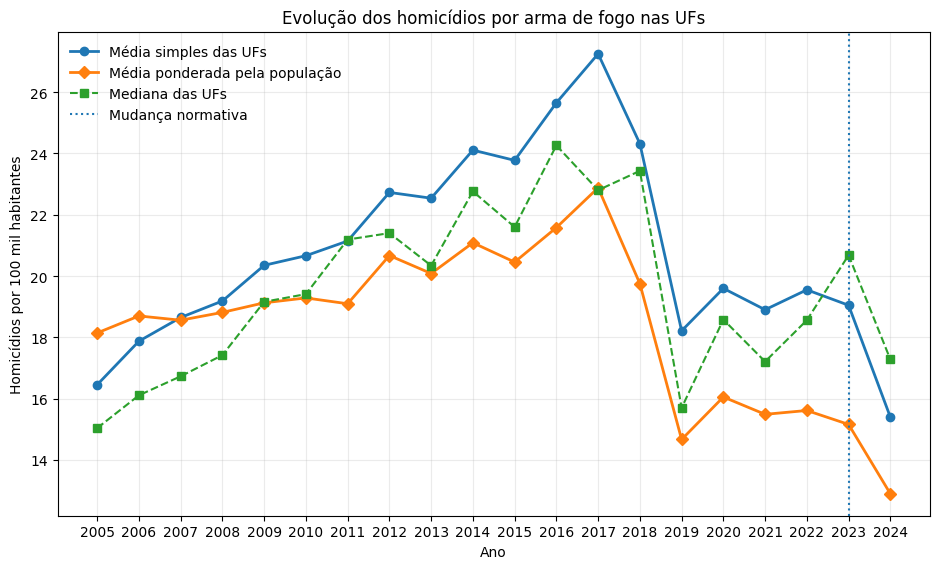

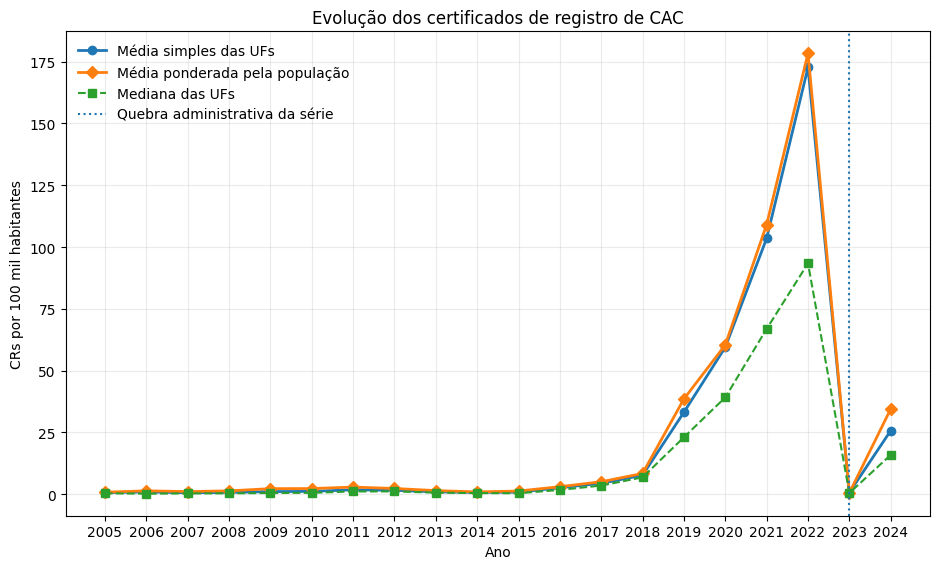

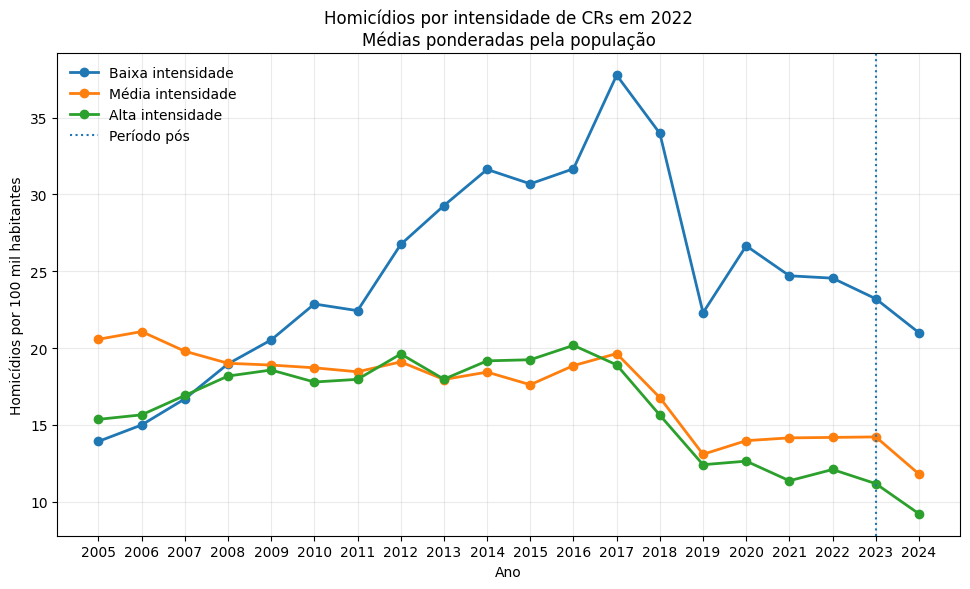

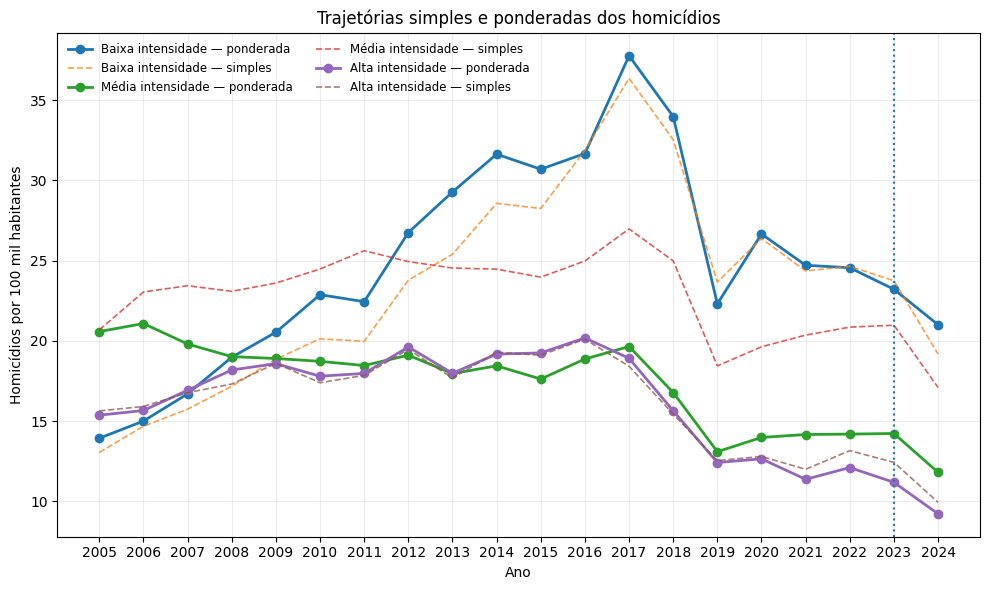

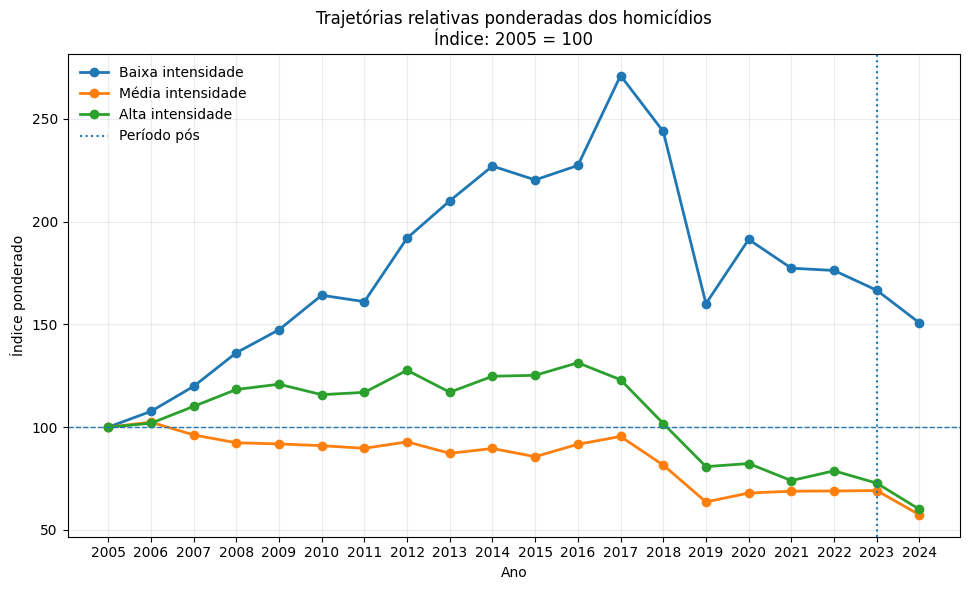

VARIAÇÃO PRÉ-TRATAMENTO POR GRUPO — 2005 A 2022


,grupo_intensidade,hom_simples_2005,hom_simples_2022,hom_ponderada_2005,hom_ponderada_2022,variacao_simples_absoluta,variacao_simples_percentual,variacao_ponderada_absoluta,variacao_ponderada_percentual
0,Alta intensidade,15.63,13.16,15.37,12.10,-2.48,-15.85%,-3.26,-21.24%
1,Baixa intensidade,13.05,24.65,13.93,24.55,11.60,88.87%,10.62,76.26%
2,Média intensidade,20.68,20.85,20.58,14.19,0.17,0.83%,-6.39,-31.04%


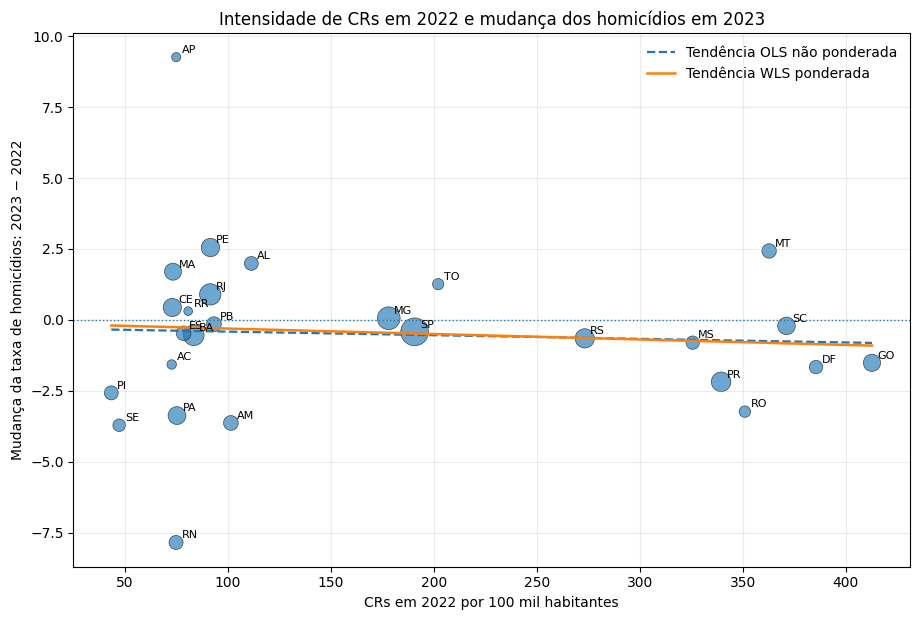


CORRELAÇÃO ENTRE INTENSIDADE E MUDANÇA DOS HOMICÍDIOS


,Método,Correlação,p-valor
0,Pearson não ponderado — mudança em nível,-0.0539,0.7893
1,Spearman não ponderado — mudança em nível,0.0580,0.7738
2,Pearson ponderado — mudança em nível,-0.1118,nan
3,Pearson ponderado — mudança em log,-0.3591,nan



Nota: as correlações ponderadas são apresentadas como medidas descritivas. Seus p-valores serão avaliados nos modelos econométricos ponderados.


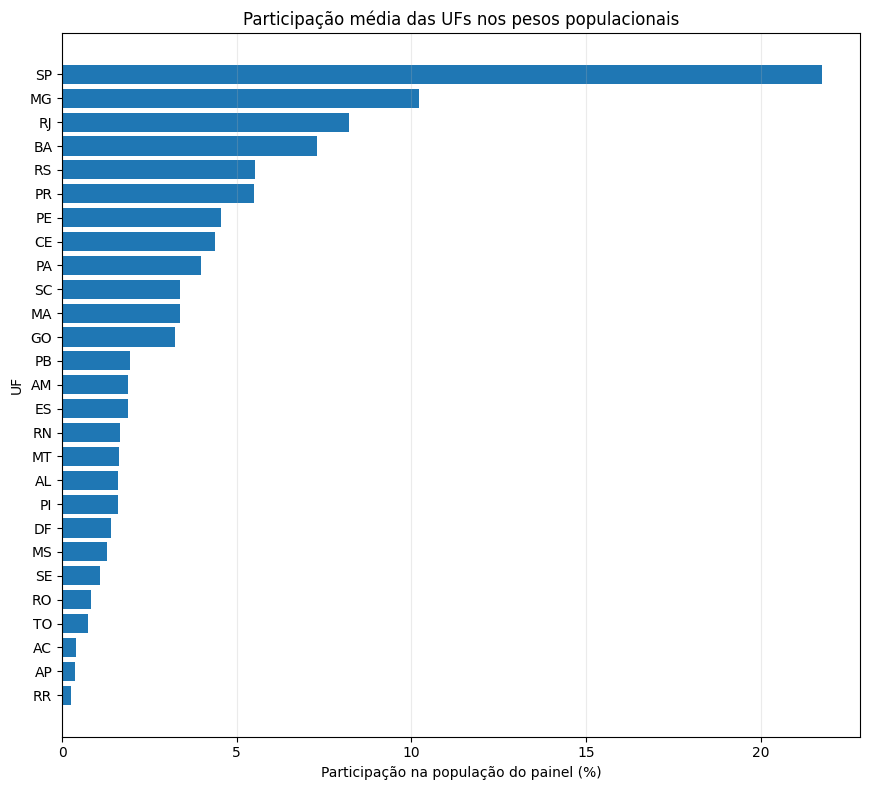


GRÁFICOS GERADOS


,Gráfico,Arquivo
0,Evolução dos homicídios,/content/resultados_artigo/graficos/evolucao_h...
1,Evolução dos CRs,/content/resultados_artigo/graficos/evolucao_c...
2,Homicídios por grupo — ponderado,/content/resultados_artigo/graficos/homicidios...
3,Grupos simples versus ponderados,/content/resultados_artigo/graficos/homicidios...
4,Tendências normalizadas ponderadas,/content/resultados_artigo/graficos/tendencias...
5,Intensidade e mudança 2022–2023,/content/resultados_artigo/graficos/intensidad...
6,Participação populacional das UFs,/content/resultados_artigo/graficos/participac...



Arquivos gerados:
Tabelas:  /content/resultados_artigo/tabelas/tendencias_descritivas_com_populacao.xlsx
Gráficos: /content/resultados_artigo/graficos

Objetos criados:
• serie_homicidios
• serie_crs
• serie_grupos
• serie_normalizada
• comparacao_pre
• dados_mudanca
• tabela_correlacao_delta
• tabela_pesos_graficos

Célula 2.3 concluída com sucesso.


In [6]:
# ============================================================
# CÉLULA 2.3 — GRÁFICOS DESCRITIVOS,
#               PONDERAÇÃO POPULACIONAL E TENDÊNCIAS PRÉVIAS
# ============================================================

# Objetivos:
# 1. comparar médias estaduais simples e ponderadas;
# 2. visualizar a evolução nacional dos homicídios;
# 3. visualizar a expansão dos CRs até 2022;
# 4. comparar trajetórias por intensidade de tratamento;
# 5. examinar tendências anteriores a 2023;
# 6. representar a população no contraste 2022–2023;
# 7. comparar tendências lineares OLS e WLS;
# 8. salvar os gráficos em alta resolução.

# ------------------------------------------------------------
# 1. Preparação e validação da base
# ------------------------------------------------------------
base_graficos = df.reset_index().copy()

base_graficos = (
    base_graficos
    .sort_values(["uf", "ano"])
    .reset_index(drop=True)
)

variaveis_necessarias = [
    "uf",
    "ano",
    "hom100",
    "crs100",
    "int_i",
    "int_i_z",
    "pop",
    "peso_pop",
    "grupo_intensidade"
]

variaveis_ausentes = [
    variavel
    for variavel in variaveis_necessarias
    if variavel not in base_graficos.columns
]

if variaveis_ausentes:
    raise ValueError(
        "Variáveis ausentes para os gráficos: "
        + ", ".join(variaveis_ausentes)
    )

if base_graficos["pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em pop."
    )

if (base_graficos["pop"] <= 0).any():
    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )

# Garante a ordenação lógica dos grupos
ordem_grupos = [
    "Baixa intensidade",
    "Média intensidade",
    "Alta intensidade"
]

base_graficos["grupo_intensidade"] = pd.Categorical(
    base_graficos["grupo_intensidade"],
    categories=ordem_grupos,
    ordered=True
)

# ------------------------------------------------------------
# 2. Funções auxiliares
# ------------------------------------------------------------
def media_ponderada_grafico(
    valores,
    pesos
):
    """
    Calcula média ponderada ignorando pares inválidos.
    """

    mascara = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    if mascara.sum() == 0:
        return np.nan

    return np.average(
        valores.loc[mascara],
        weights=pesos.loc[mascara]
    )


def correlacao_ponderada_grafico(
    x,
    y,
    pesos
):
    """
    Correlação de Pearson ponderada.
    """

    mascara = (
        x.notna()
        & y.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    x_val = x.loc[mascara].astype(float)
    y_val = y.loc[mascara].astype(float)
    w_val = pesos.loc[mascara].astype(float)

    if len(x_val) < 2:
        return np.nan

    media_x = np.average(
        x_val,
        weights=w_val
    )

    media_y = np.average(
        y_val,
        weights=w_val
    )

    cov_xy = np.average(
        (x_val - media_x)
        * (y_val - media_y),
        weights=w_val
    )

    var_x = np.average(
        (x_val - media_x) ** 2,
        weights=w_val
    )

    var_y = np.average(
        (y_val - media_y) ** 2,
        weights=w_val
    )

    if var_x <= 0 or var_y <= 0:
        return np.nan

    return (
        cov_xy
        / np.sqrt(var_x * var_y)
    )


def salvar_figura(
    nome_arquivo
):
    """
    Salva a figura atual em alta resolução.
    """

    caminho_figura = (
        PASTA_GRAFICOS
        / nome_arquivo
    )

    plt.savefig(
        caminho_figura,
        dpi=300,
        bbox_inches="tight"
    )

    return caminho_figura


# ------------------------------------------------------------
# 3. Evolução dos homicídios:
#    média simples, ponderada e mediana
# ------------------------------------------------------------
linhas_homicidios = []

for ano, grupo in base_graficos.groupby("ano"):

    linhas_homicidios.append({
        "ano": int(ano),

        "media_simples":
            grupo["hom100"].mean(),

        "media_ponderada":
            media_ponderada_grafico(
                grupo["hom100"],
                grupo["pop"]
            ),

        "mediana":
            grupo["hom100"].median(),

        "desvio_padrao":
            grupo["hom100"].std(ddof=1),

        "populacao_total":
            grupo["pop"].sum()
    })

serie_homicidios = pd.DataFrame(
    linhas_homicidios
)

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

ax.plot(
    serie_homicidios["ano"],
    serie_homicidios["media_simples"],
    marker="o",
    linewidth=2,
    label="Média simples das UFs"
)

ax.plot(
    serie_homicidios["ano"],
    serie_homicidios["media_ponderada"],
    marker="D",
    linewidth=2,
    label="Média ponderada pela população"
)

ax.plot(
    serie_homicidios["ano"],
    serie_homicidios["mediana"],
    marker="s",
    linewidth=1.5,
    linestyle="--",
    label="Mediana das UFs"
)

ax.axvline(
    x=2023,
    linestyle=":",
    linewidth=1.5,
    label="Mudança normativa"
)

ax.set_title(
    "Evolução dos homicídios por arma de fogo nas UFs"
)

ax.set_xlabel("Ano")

ax.set_ylabel(
    "Homicídios por 100 mil habitantes"
)

ax.set_xticks(
    sorted(
        base_graficos["ano"].unique()
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_homicidios = salvar_figura(
    "evolucao_homicidios_simples_ponderada.png"
)

plt.show()

# ------------------------------------------------------------
# 4. Evolução dos CRs:
#    média simples, ponderada e mediana
# ------------------------------------------------------------
linhas_crs = []

for ano, grupo in base_graficos.groupby("ano"):

    linhas_crs.append({
        "ano": int(ano),

        "media_simples":
            grupo["crs100"].mean(),

        "media_ponderada":
            media_ponderada_grafico(
                grupo["crs100"],
                grupo["pop"]
            ),

        "mediana":
            grupo["crs100"].median(),

        "populacao_total":
            grupo["pop"].sum()
    })

serie_crs = pd.DataFrame(
    linhas_crs
)

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

ax.plot(
    serie_crs["ano"],
    serie_crs["media_simples"],
    marker="o",
    linewidth=2,
    label="Média simples das UFs"
)

ax.plot(
    serie_crs["ano"],
    serie_crs["media_ponderada"],
    marker="D",
    linewidth=2,
    label="Média ponderada pela população"
)

ax.plot(
    serie_crs["ano"],
    serie_crs["mediana"],
    marker="s",
    linewidth=1.5,
    linestyle="--",
    label="Mediana das UFs"
)

ax.axvline(
    x=2023,
    linestyle=":",
    linewidth=1.5,
    label="Quebra administrativa da série"
)

ax.set_title(
    "Evolução dos certificados de registro de CAC"
)

ax.set_xlabel("Ano")

ax.set_ylabel(
    "CRs por 100 mil habitantes"
)

ax.set_xticks(
    sorted(
        base_graficos["ano"].unique()
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_crs = salvar_figura(
    "evolucao_crs_simples_ponderada.png"
)

plt.show()

# ------------------------------------------------------------
# 5. Homicídios por grupo de intensidade:
#    médias simples e ponderadas
# ------------------------------------------------------------
linhas_grupos = []

for (
    grupo_intensidade,
    ano
), grupo in base_graficos.groupby(
    [
        "grupo_intensidade",
        "ano"
    ],
    observed=True
):

    linhas_grupos.append({
        "grupo_intensidade":
            grupo_intensidade,

        "ano":
            int(ano),

        "UFs":
            grupo["uf"].nunique(),

        "populacao_total":
            grupo["pop"].sum(),

        "media_hom_simples":
            grupo["hom100"].mean(),

        "media_hom_ponderada":
            media_ponderada_grafico(
                grupo["hom100"],
                grupo["pop"]
            ),

        "erro_padrao_simples": (
            grupo["hom100"].std(ddof=1)
            / np.sqrt(
                grupo["hom100"].count()
            )
        ),

        "media_crs_simples":
            grupo["crs100"].mean(),

        "media_crs_ponderada":
            media_ponderada_grafico(
                grupo["crs100"],
                grupo["pop"]
            )
    })

serie_grupos = pd.DataFrame(
    linhas_grupos
)

# Gráfico principal: médias ponderadas
fig, ax = plt.subplots(
    figsize=(9.8, 6)
)

for grupo in ordem_grupos:

    dados_grupo = serie_grupos[
        serie_grupos[
            "grupo_intensidade"
        ] == grupo
    ]

    ax.plot(
        dados_grupo["ano"],
        dados_grupo[
            "media_hom_ponderada"
        ],
        marker="o",
        linewidth=2,
        label=grupo
    )

ax.axvline(
    x=2023,
    linestyle=":",
    linewidth=1.5,
    label="Período pós"
)

ax.set_title(
    "Homicídios por intensidade de CRs em 2022\n"
    "Médias ponderadas pela população"
)

ax.set_xlabel("Ano")

ax.set_ylabel(
    "Homicídios por 100 mil habitantes"
)

ax.set_xticks(
    sorted(
        base_graficos["ano"].unique()
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_grupos_ponderado = salvar_figura(
    "homicidios_grupos_intensidade_ponderado.png"
)

plt.show()

# ------------------------------------------------------------
# 6. Comparação visual:
#    média simples versus ponderada em cada grupo
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for grupo in ordem_grupos:

    dados_grupo = serie_grupos[
        serie_grupos[
            "grupo_intensidade"
        ] == grupo
    ]

    ax.plot(
        dados_grupo["ano"],
        dados_grupo[
            "media_hom_ponderada"
        ],
        marker="o",
        linewidth=2,
        label=f"{grupo} — ponderada"
    )

    ax.plot(
        dados_grupo["ano"],
        dados_grupo[
            "media_hom_simples"
        ],
        linewidth=1.2,
        linestyle="--",
        alpha=0.75,
        label=f"{grupo} — simples"
    )

ax.axvline(
    x=2023,
    linestyle=":",
    linewidth=1.5
)

ax.set_title(
    "Trajetórias simples e ponderadas dos homicídios"
)

ax.set_xlabel("Ano")

ax.set_ylabel(
    "Homicídios por 100 mil habitantes"
)

ax.set_xticks(
    sorted(
        base_graficos["ano"].unique()
    )
)

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=8.5
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_grupos_comparacao = salvar_figura(
    "homicidios_grupos_simples_ponderado.png"
)

plt.show()

# ------------------------------------------------------------
# 7. Tendências ponderadas normalizadas:
#    índice 2005 = 100
# ------------------------------------------------------------
serie_normalizada = serie_grupos.copy()

valores_base_ponderados = (
    serie_normalizada.loc[
        serie_normalizada["ano"] == 2005,
        [
            "grupo_intensidade",
            "media_hom_ponderada"
        ]
    ]
    .set_index(
        "grupo_intensidade"
    )[
        "media_hom_ponderada"
    ]
)

valores_base_simples = (
    serie_normalizada.loc[
        serie_normalizada["ano"] == 2005,
        [
            "grupo_intensidade",
            "media_hom_simples"
        ]
    ]
    .set_index(
        "grupo_intensidade"
    )[
        "media_hom_simples"
    ]
)

serie_normalizada[
    "indice_ponderado_2005_100"
] = serie_normalizada.apply(
    lambda linha: (
        linha["media_hom_ponderada"]
        / valores_base_ponderados.loc[
            linha["grupo_intensidade"]
        ]
    ) * 100,
    axis=1
)

serie_normalizada[
    "indice_simples_2005_100"
] = serie_normalizada.apply(
    lambda linha: (
        linha["media_hom_simples"]
        / valores_base_simples.loc[
            linha["grupo_intensidade"]
        ]
    ) * 100,
    axis=1
)

fig, ax = plt.subplots(
    figsize=(9.8, 6)
)

for grupo in ordem_grupos:

    dados_grupo = serie_normalizada[
        serie_normalizada[
            "grupo_intensidade"
        ] == grupo
    ]

    ax.plot(
        dados_grupo["ano"],
        dados_grupo[
            "indice_ponderado_2005_100"
        ],
        marker="o",
        linewidth=2,
        label=grupo
    )

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    x=2023,
    linestyle=":",
    linewidth=1.5,
    label="Período pós"
)

ax.set_title(
    "Trajetórias relativas ponderadas dos homicídios\n"
    "Índice: 2005 = 100"
)

ax.set_xlabel("Ano")

ax.set_ylabel(
    "Índice ponderado"
)

ax.set_xticks(
    sorted(
        base_graficos["ano"].unique()
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_normalizado = salvar_figura(
    "tendencias_ponderadas_normalizadas_2005.png"
)

plt.show()

# ------------------------------------------------------------
# 8. Variação acumulada pré-tratamento:
#    simples e ponderada
# ------------------------------------------------------------
comparacao_pre_simples = (
    serie_grupos.loc[
        serie_grupos["ano"].isin(
            [2005, 2022]
        )
    ]
    .pivot(
        index="grupo_intensidade",
        columns="ano",
        values="media_hom_simples"
    )
    .reset_index()
)

comparacao_pre_simples.columns.name = None

comparacao_pre_simples = (
    comparacao_pre_simples
    .rename(
        columns={
            2005: "hom_simples_2005",
            2022: "hom_simples_2022"
        }
    )
)

comparacao_pre_ponderada = (
    serie_grupos.loc[
        serie_grupos["ano"].isin(
            [2005, 2022]
        )
    ]
    .pivot(
        index="grupo_intensidade",
        columns="ano",
        values="media_hom_ponderada"
    )
    .reset_index()
)

comparacao_pre_ponderada.columns.name = None

comparacao_pre_ponderada = (
    comparacao_pre_ponderada
    .rename(
        columns={
            2005: "hom_ponderada_2005",
            2022: "hom_ponderada_2022"
        }
    )
)

comparacao_pre = (
    comparacao_pre_simples
    .merge(
        comparacao_pre_ponderada,
        on="grupo_intensidade",
        how="inner",
        validate="one_to_one"
    )
)

comparacao_pre[
    "variacao_simples_absoluta"
] = (
    comparacao_pre["hom_simples_2022"]
    - comparacao_pre["hom_simples_2005"]
)

comparacao_pre[
    "variacao_simples_percentual"
] = (
    100
    * comparacao_pre[
        "variacao_simples_absoluta"
    ]
    / comparacao_pre[
        "hom_simples_2005"
    ]
)

comparacao_pre[
    "variacao_ponderada_absoluta"
] = (
    comparacao_pre["hom_ponderada_2022"]
    - comparacao_pre["hom_ponderada_2005"]
)

comparacao_pre[
    "variacao_ponderada_percentual"
] = (
    100
    * comparacao_pre[
        "variacao_ponderada_absoluta"
    ]
    / comparacao_pre[
        "hom_ponderada_2005"
    ]
)

print("=" * 100)
print(
    "VARIAÇÃO PRÉ-TRATAMENTO POR GRUPO — 2005 A 2022"
)
print("=" * 100)

display(
    comparacao_pre.style.format({
        "hom_simples_2005": "{:,.2f}",
        "hom_simples_2022": "{:,.2f}",
        "hom_ponderada_2005": "{:,.2f}",
        "hom_ponderada_2022": "{:,.2f}",

        "variacao_simples_absoluta": "{:,.2f}",
        "variacao_simples_percentual": "{:,.2f}%",

        "variacao_ponderada_absoluta": "{:,.2f}",
        "variacao_ponderada_percentual": "{:,.2f}%"
    })
)

# ------------------------------------------------------------
# 9. Base de mudança 2022–2023
# ------------------------------------------------------------
dados_mudanca = (
    base_graficos.loc[
        base_graficos["ano"].isin(
            [2022, 2023]
        ),
        [
            "uf",
            "ano",
            "hom100",
            "pop",
            "peso_pop"
        ]
    ]
    .pivot(
        index="uf",
        columns="ano",
        values=[
            "hom100",
            "pop",
            "peso_pop"
        ]
    )
)

dados_mudanca.columns = [
    f"{variavel}_{ano}"
    for variavel, ano
    in dados_mudanca.columns
]

dados_mudanca = (
    dados_mudanca
    .reset_index()
)

intensidade_uf = (
    base_graficos.loc[
        base_graficos["ano"] == 2022,
        [
            "uf",
            "int_i",
            "int_i_z",
            "grupo_intensidade"
        ]
    ]
    .drop_duplicates(
        subset="uf"
    )
)

dados_mudanca = (
    dados_mudanca
    .merge(
        intensidade_uf,
        on="uf",
        how="left",
        validate="one_to_one"
    )
)

dados_mudanca[
    "delta_hom_22_23"
] = (
    dados_mudanca["hom100_2023"]
    - dados_mudanca["hom100_2022"]
)

dados_mudanca[
    "delta_ln_hom_22_23"
] = (
    np.log(
        dados_mudanca["hom100_2023"]
    )
    - np.log(
        dados_mudanca["hom100_2022"]
    )
)

dados_mudanca[
    "pop_media_22_23"
] = (
    dados_mudanca["pop_2022"]
    + dados_mudanca["pop_2023"]
) / 2

# Tamanho visual dos pontos:
# usa raiz quadrada para evitar dominância visual excessiva de SP.
raiz_pop = np.sqrt(
    dados_mudanca["pop_media_22_23"]
)

dados_mudanca[
    "tamanho_ponto"
] = (
    40
    + 360
    * (
        raiz_pop - raiz_pop.min()
    )
    / (
        raiz_pop.max()
        - raiz_pop.min()
    )
)

# ------------------------------------------------------------
# 10. Dispersão:
#     intensidade e mudança dos homicídios
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(9.3, 6.3)
)

ax.scatter(
    dados_mudanca["int_i"],
    dados_mudanca["delta_hom_22_23"],
    s=dados_mudanca["tamanho_ponto"],
    alpha=0.65,
    edgecolors="black",
    linewidths=0.5
)

# Linha OLS não ponderada
coef_ols = np.polyfit(
    dados_mudanca["int_i"],
    dados_mudanca["delta_hom_22_23"],
    deg=1
)

# Linha WLS ponderada pela população.
# np.polyfit aplica o peso ao resíduo;
# sqrt(população) corresponde à ponderação WLS por população.
coef_wls = np.polyfit(
    dados_mudanca["int_i"],
    dados_mudanca["delta_hom_22_23"],
    deg=1,
    w=np.sqrt(
        dados_mudanca["pop_media_22_23"]
    )
)

linha_x = np.linspace(
    dados_mudanca["int_i"].min(),
    dados_mudanca["int_i"].max(),
    200
)

linha_ols = (
    coef_ols[0] * linha_x
    + coef_ols[1]
)

linha_wls = (
    coef_wls[0] * linha_x
    + coef_wls[1]
)

ax.plot(
    linha_x,
    linha_ols,
    linestyle="--",
    linewidth=1.6,
    label="Tendência OLS não ponderada"
)

ax.plot(
    linha_x,
    linha_wls,
    linestyle="-",
    linewidth=1.8,
    label="Tendência WLS ponderada"
)

ax.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

for _, linha in dados_mudanca.iterrows():

    ax.annotate(
        linha["uf"],
        (
            linha["int_i"],
            linha["delta_hom_22_23"]
        ),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title(
    "Intensidade de CRs em 2022 e mudança dos homicídios em 2023"
)

ax.set_xlabel(
    "CRs em 2022 por 100 mil habitantes"
)

ax.set_ylabel(
    "Mudança da taxa de homicídios: 2023 − 2022"
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

caminho_dispersao = salvar_figura(
    "intensidade_mudanca_homicidios_ponderada.png"
)

plt.show()

# ------------------------------------------------------------
# 11. Correlações entre intensidade e mudança
# ------------------------------------------------------------
corr_pearson_delta = stats.pearsonr(
    dados_mudanca["int_i"],
    dados_mudanca["delta_hom_22_23"]
)

corr_spearman_delta = stats.spearmanr(
    dados_mudanca["int_i"],
    dados_mudanca["delta_hom_22_23"]
)

corr_ponderada_delta = (
    correlacao_ponderada_grafico(
        dados_mudanca["int_i"],
        dados_mudanca["delta_hom_22_23"],
        dados_mudanca["pop_media_22_23"]
    )
)

corr_ponderada_delta_log = (
    correlacao_ponderada_grafico(
        dados_mudanca["int_i"],
        dados_mudanca["delta_ln_hom_22_23"],
        dados_mudanca["pop_media_22_23"]
    )
)

tabela_correlacao_delta = pd.DataFrame({
    "Método": [
        "Pearson não ponderado — mudança em nível",
        "Spearman não ponderado — mudança em nível",
        "Pearson ponderado — mudança em nível",
        "Pearson ponderado — mudança em log"
    ],

    "Correlação": [
        corr_pearson_delta.statistic,
        corr_spearman_delta.statistic,
        corr_ponderada_delta,
        corr_ponderada_delta_log
    ],

    "p-valor": [
        corr_pearson_delta.pvalue,
        corr_spearman_delta.pvalue,
        np.nan,
        np.nan
    ]
})

print("\n" + "=" * 100)
print(
    "CORRELAÇÃO ENTRE INTENSIDADE E MUDANÇA DOS HOMICÍDIOS"
)
print("=" * 100)

display(
    tabela_correlacao_delta.style.format({
        "Correlação": "{:.4f}",
        "p-valor": "{:.4f}"
    })
)

print(
    "\nNota: as correlações ponderadas são apresentadas "
    "como medidas descritivas. Seus p-valores serão avaliados "
    "nos modelos econométricos ponderados."
)

# ------------------------------------------------------------
# 12. Participação populacional das UFs
# ------------------------------------------------------------
tabela_pesos_graficos = (
    base_graficos
    .groupby(
        "uf",
        as_index=False
    )
    .agg(
        populacao_media=(
            "pop",
            "mean"
        )
    )
)

tabela_pesos_graficos[
    "participacao_populacional_pct"
] = (
    100
    * tabela_pesos_graficos[
        "populacao_media"
    ]
    / tabela_pesos_graficos[
        "populacao_media"
    ].sum()
)

tabela_pesos_graficos = (
    tabela_pesos_graficos
    .sort_values(
        "participacao_populacional_pct",
        ascending=True
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(8.8, 8)
)

ax.barh(
    tabela_pesos_graficos["uf"],
    tabela_pesos_graficos[
        "participacao_populacional_pct"
    ]
)

ax.set_title(
    "Participação média das UFs nos pesos populacionais"
)

ax.set_xlabel(
    "Participação na população do painel (%)"
)

ax.set_ylabel("UF")

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

caminho_pesos = salvar_figura(
    "participacao_populacional_ufs.png"
)

plt.show()

# ------------------------------------------------------------
# 13. Lista dos arquivos gráficos gerados
# ------------------------------------------------------------
tabela_arquivos_graficos = pd.DataFrame({
    "Gráfico": [
        "Evolução dos homicídios",
        "Evolução dos CRs",
        "Homicídios por grupo — ponderado",
        "Grupos simples versus ponderados",
        "Tendências normalizadas ponderadas",
        "Intensidade e mudança 2022–2023",
        "Participação populacional das UFs"
    ],

    "Arquivo": [
        str(caminho_homicidios),
        str(caminho_crs),
        str(caminho_grupos_ponderado),
        str(caminho_grupos_comparacao),
        str(caminho_normalizado),
        str(caminho_dispersao),
        str(caminho_pesos)
    ]
})

print("\n" + "=" * 100)
print("GRÁFICOS GERADOS")
print("=" * 100)

display(tabela_arquivos_graficos)

# ------------------------------------------------------------
# 14. Exportação das tabelas auxiliares
# ------------------------------------------------------------
arquivo_tendencias = (
    PASTA_TABELAS
    / "tendencias_descritivas_com_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_tendencias,
    engine="openpyxl"
) as writer:

    serie_homicidios.to_excel(
        writer,
        sheet_name="Serie_homicidios",
        index=False
    )

    serie_crs.to_excel(
        writer,
        sheet_name="Serie_CRs",
        index=False
    )

    serie_grupos.to_excel(
        writer,
        sheet_name="Grupos_intensidade",
        index=False
    )

    serie_normalizada.to_excel(
        writer,
        sheet_name="Tendencias_normalizadas",
        index=False
    )

    comparacao_pre.to_excel(
        writer,
        sheet_name="Variacao_pre",
        index=False
    )

    dados_mudanca.to_excel(
        writer,
        sheet_name="Mudanca_2022_2023",
        index=False
    )

    tabela_correlacao_delta.to_excel(
        writer,
        sheet_name="Correlacao_delta",
        index=False
    )

    tabela_pesos_graficos.to_excel(
        writer,
        sheet_name="Pesos_populacionais",
        index=False
    )

    tabela_arquivos_graficos.to_excel(
        writer,
        sheet_name="Arquivos_graficos",
        index=False
    )

print("\nArquivos gerados:")
print(f"Tabelas:  {arquivo_tendencias}")
print(f"Gráficos: {PASTA_GRAFICOS}")

print("\nObjetos criados:")
print("• serie_homicidios")
print("• serie_crs")
print("• serie_grupos")
print("• serie_normalizada")
print("• comparacao_pre")
print("• dados_mudanca")
print("• tabela_correlacao_delta")
print("• tabela_pesos_graficos")

print("\nCélula 2.3 concluída com sucesso.")

# Preparação de Amostras e diagnostico preliminar

In [7]:
# ============================================================
# CÉLULA 3.1 — PREPARAÇÃO DAS AMOSTRAS,
#               PESOS E ESPECIFICAÇÕES ECONOMÉTRICAS
# ============================================================

# Objetivos:
# 1. definir formalmente as amostras de H1, H2 e H3;
# 2. incorporar população e pesos populacionais;
# 3. preparar modelos ponderados e não ponderados;
# 4. padronizar a intensidade no nível das 27 UFs;
# 5. construir as interações do event study;
# 6. preparar a regressão da mudança 2022–2023;
# 7. documentar as especificações planejadas.

# ------------------------------------------------------------
# 1. Base principal em formato plano
# ------------------------------------------------------------
base_modelos = (
    df
    .reset_index()
    .copy()
    .sort_values(["uf", "ano"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Validação das variáveis necessárias
# ------------------------------------------------------------
variaveis_necessarias = [
    "uf",
    "ano",
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "post",
    "d_pan",
    "int_i",
    "pop",
    "ln_pop",
    "peso_pop"
]

variaveis_ausentes = [
    variavel
    for variavel in variaveis_necessarias
    if variavel not in base_modelos.columns
]

if variaveis_ausentes:
    raise ValueError(
        "Variáveis ausentes na base: "
        + ", ".join(variaveis_ausentes)
    )

if base_modelos["pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes na variável pop."
    )

if (base_modelos["pop"] <= 0).any():
    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )

if base_modelos["peso_pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes na variável peso_pop."
    )

if (base_modelos["peso_pop"] <= 0).any():
    raise ValueError(
        "Existem pesos populacionais menores ou iguais a zero."
    )

# ------------------------------------------------------------
# 3. Definição das variáveis dos modelos
# ------------------------------------------------------------

# Variáveis dependentes
VAR_DEP_NIVEL = "hom100"
VAR_DEP_LOG = "ln_hom100"

# Variáveis contemporâneas de CRs para H1
VAR_CRS_NIVEL = "crs100"
VAR_CRS_LOG = "ln1p_crs100"

# Intensidade predeterminada
VAR_INTENSIDADE = "int_i"
VAR_INTENSIDADE_Z = "int_i_z"

# Interações do DiD
VAR_DID = "did_continuo"
VAR_DID_Z = "did_continuo_z"

# População e pesos
VAR_POP = "pop"
VAR_LN_POP = "ln_pop"
VAR_PESO = "peso_pop"

# Controles admissíveis em modelos com efeitos fixos de ano
CONTROLES_FE = [
    "ln_pibpc",
    "desemp"
]

# A dummy de pandemia não deve entrar junto com efeitos fixos
# de ano, pois é perfeitamente colinear com as dummies anuais.
CONTROLES_DESCRITIVOS = [
    "ln_pibpc",
    "desemp",
    "d_pan"
]

# ------------------------------------------------------------
# 4. Padronização correta da intensidade no nível das UFs
# ------------------------------------------------------------
# int_i é constante dentro de cada UF.
# A padronização deve utilizar as 27 intensidades estaduais,
# e não as 216 observações repetidas do painel.

intensidade_uf = (
    base_modelos.loc[
        base_modelos["ano"] == 2022,
        [
            "uf",
            "int_i"
        ]
    ]
    .drop_duplicates(subset="uf")
    .sort_values("uf")
    .reset_index(drop=True)
)

if len(intensidade_uf) != 27:
    raise ValueError(
        "A padronização da intensidade esperava 27 UFs, "
        f"mas encontrou {len(intensidade_uf)}."
    )

media_intensidade_uf = (
    intensidade_uf["int_i"].mean()
)

dp_intensidade_uf = (
    intensidade_uf["int_i"].std(ddof=1)
)

if dp_intensidade_uf <= 0:
    raise ValueError(
        "O desvio-padrão da intensidade é inválido."
    )

intensidade_uf["int_i_z"] = (
    intensidade_uf["int_i"]
    - media_intensidade_uf
) / dp_intensidade_uf

mapa_intensidade_z = (
    intensidade_uf
    .set_index("uf")["int_i_z"]
)

# Substitui a padronização anterior pela versão calculada
# corretamente no nível das 27 UFs.
base_modelos["int_i_z"] = (
    base_modelos["uf"]
    .map(mapa_intensidade_z)
)

# Recria as interações do DiD
base_modelos["did_continuo"] = (
    base_modelos["int_i"]
    * base_modelos["post"]
)

base_modelos["did_continuo_z"] = (
    base_modelos["int_i_z"]
    * base_modelos["post"]
)

print("=" * 100)
print("PADRONIZAÇÃO DA INTENSIDADE")
print("=" * 100)

print(
    f"Média da intensidade entre as 27 UFs: "
    f"{media_intensidade_uf:.4f}"
)

print(
    f"Desvio-padrão entre as 27 UFs: "
    f"{dp_intensidade_uf:.4f}"
)

print(
    f"Média de int_i_z entre as UFs: "
    f"{intensidade_uf['int_i_z'].mean():.8f}"
)

print(
    f"Desvio-padrão de int_i_z entre as UFs: "
    f"{intensidade_uf['int_i_z'].std(ddof=1):.8f}"
)

# ------------------------------------------------------------
# 5. Indicadores e interações do event study
# ------------------------------------------------------------
# Ano de referência: 2022 (pico da série de CACs, imediatamente
# anterior ao Decreto 11.366/jan-2023).
# As interações de 2022 não são criadas, ficando omitidas.
#
# Painel completo: 2005–2024. Os coeficientes de 2005–2021 são o
# teste de tendências paralelas (devem ser estatisticamente ~0);
# os de 2023–2024 são o efeito pós-tratamento dinâmico.

ANO_REFERENCIA_EVENT_STUDY = 2022

ANOS_EVENT_STUDY = [
    ano
    for ano in range(2005, 2025)
    if ano != ANO_REFERENCIA_EVENT_STUDY
]

colunas_event_study = []

for ano_evento in ANOS_EVENT_STUDY:

    nome_coluna = f"es_{ano_evento}"

    base_modelos[nome_coluna] = (
        base_modelos["int_i_z"]
        * (
            base_modelos["ano"]
            == ano_evento
        ).astype(int)
    )

    colunas_event_study.append(
        nome_coluna
    )

# ------------------------------------------------------------
# 6. Definição das amostras
# ------------------------------------------------------------
# DECISÃO (atualizada): H1, H2 e H3 passam a usar o painel
# completo 2005–2024 (540 obs.), sem exclusão do período
# pós-2022. A antiga restrição de H1 a 2016–2022 — motivada
# pela quebra administrativa na série contemporânea de CRs —
# foi removida: com a série expandida, essa quebra é apenas
# mais um ano dentro de um painel de 20 anos, e H1 já é
# tratado como associativo, não causal.

# Base completa para H1, H2 e H3 — painel inteiro 2005–2024
amostra_completa = (
    base_modelos.copy()
)

# H1: associação contemporânea — painel completo
amostra_h1 = (
    base_modelos.copy()
)

# H1 pré-pandemia (mantém o corte em 2019; início passa a 2005)
amostra_h1_pre_pandemia = (
    base_modelos.loc[
        base_modelos["ano"].between(
            2005,
            2019
        )
    ]
    .copy()
)

# H2: DiD contínuo — painel completo
amostra_h2 = (
    amostra_completa.copy()
)

# H3: event study contínuo — painel completo
amostra_h3 = (
    amostra_completa.copy()
)

# Amostra pré-tratamento (usada nos diagnósticos de tendência
# prévia — Célula 3.2). Pré-tratamento = tudo até 2022,
# imediatamente antes do Decreto 11.366/jan-2023.
amostra_pre = (
    base_modelos.loc[
        base_modelos["ano"] <= 2022
    ]
    .copy()
)

# ------------------------------------------------------------
# 7. Construção da amostra de mudança 2022–2023
# ------------------------------------------------------------
base_2022 = (
    base_modelos.loc[
        base_modelos["ano"] == 2022,
        [
            "uf",
            "hom100",
            "ln_hom100",
            "ln_pibpc",
            "desemp",
            "pop",
            "peso_pop",
            "int_i",
            "int_i_z"
        ]
    ]
    .rename(
        columns={
            "hom100": "hom100_2022",
            "ln_hom100": "ln_hom100_2022",
            "ln_pibpc": "ln_pibpc_2022",
            "desemp": "desemp_2022",
            "pop": "pop_2022",
            "peso_pop": "peso_pop_2022"
        }
    )
)

base_2023 = (
    base_modelos.loc[
        base_modelos["ano"] == 2023,
        [
            "uf",
            "hom100",
            "ln_hom100",
            "ln_pibpc",
            "desemp",
            "pop",
            "peso_pop"
        ]
    ]
    .rename(
        columns={
            "hom100": "hom100_2023",
            "ln_hom100": "ln_hom100_2023",
            "ln_pibpc": "ln_pibpc_2023",
            "desemp": "desemp_2023",
            "pop": "pop_2023",
            "peso_pop": "peso_pop_2023"
        }
    )
)

amostra_mudanca_22_23 = (
    base_2022
    .merge(
        base_2023,
        on="uf",
        how="inner",
        validate="one_to_one"
    )
)

amostra_mudanca_22_23[
    "delta_hom100"
] = (
    amostra_mudanca_22_23["hom100_2023"]
    - amostra_mudanca_22_23["hom100_2022"]
)

amostra_mudanca_22_23[
    "delta_ln_hom100"
] = (
    amostra_mudanca_22_23["ln_hom100_2023"]
    - amostra_mudanca_22_23["ln_hom100_2022"]
)

amostra_mudanca_22_23[
    "delta_ln_pibpc"
] = (
    amostra_mudanca_22_23["ln_pibpc_2023"]
    - amostra_mudanca_22_23["ln_pibpc_2022"]
)

amostra_mudanca_22_23[
    "delta_desemp"
] = (
    amostra_mudanca_22_23["desemp_2023"]
    - amostra_mudanca_22_23["desemp_2022"]
)

# População média dos dois anos
amostra_mudanca_22_23[
    "pop_media_22_23"
] = (
    amostra_mudanca_22_23["pop_2022"]
    + amostra_mudanca_22_23["pop_2023"]
) / 2

# Peso reescalonado para média igual a 1
amostra_mudanca_22_23[
    "peso_pop_22_23"
] = (
    amostra_mudanca_22_23[
        "pop_media_22_23"
    ]
    / amostra_mudanca_22_23[
        "pop_media_22_23"
    ].mean()
)

if len(amostra_mudanca_22_23) != 27:
    raise ValueError(
        "A amostra de mudança deveria conter 27 UFs, "
        f"mas contém {len(amostra_mudanca_22_23)}."
    )

# ------------------------------------------------------------
# 8. Função de validação das amostras
# ------------------------------------------------------------
def validar_amostra(
    dados,
    nome,
    colunas_obrigatorias,
    ano_minimo=None,
    ano_maximo=None
):
    """
    Verifica observações, UFs, período, duplicidades,
    ausências, população e pesos.
    """

    duplicatas = dados.duplicated(
        subset=["uf", "ano"]
    ).sum() if "ano" in dados.columns else dados.duplicated(
        subset=["uf"]
    ).sum()

    ausencias = (
        dados[colunas_obrigatorias]
        .isna()
        .sum()
    )

    resultado = {
        "Amostra": nome,
        "Observações": len(dados),
        "UFs": dados["uf"].nunique(),
        "Ano inicial": (
            dados["ano"].min()
            if "ano" in dados.columns
            else 2022
        ),
        "Ano final": (
            dados["ano"].max()
            if "ano" in dados.columns
            else 2023
        ),
        "Duplicidades": int(duplicatas),
        "Ausências nas variáveis": int(
            ausencias.sum()
        ),
        "População mínima": (
            dados["pop"].min()
            if "pop" in dados.columns
            else dados[
                "pop_media_22_23"
            ].min()
        ),
        "População máxima": (
            dados["pop"].max()
            if "pop" in dados.columns
            else dados[
                "pop_media_22_23"
            ].max()
        ),
        "Peso mínimo": (
            dados["peso_pop"].min()
            if "peso_pop" in dados.columns
            else dados[
                "peso_pop_22_23"
            ].min()
        ),
        "Peso máximo": (
            dados["peso_pop"].max()
            if "peso_pop" in dados.columns
            else dados[
                "peso_pop_22_23"
            ].max()
        )
    }

    if (
        ano_minimo is not None
        and ano_maximo is not None
    ):
        resultado[
            "Observações esperadas"
        ] = (
            dados["uf"].nunique()
            * (
                ano_maximo
                - ano_minimo
                + 1
            )
        )
    else:
        resultado[
            "Observações esperadas"
        ] = dados["uf"].nunique()

    return resultado, ausencias


validacoes = []
ausencias_por_amostra = {}

# H1
resultado, ausencias = validar_amostra(
    dados=amostra_h1,
    nome="H1 — associação contemporânea",
    colunas_obrigatorias=[
        VAR_DEP_NIVEL,
        VAR_DEP_LOG,
        VAR_CRS_NIVEL,
        VAR_CRS_LOG,
        *CONTROLES_FE,
        VAR_POP,
        VAR_PESO
    ],
    ano_minimo=2005,
    ano_maximo=2024
)

validacoes.append(resultado)
ausencias_por_amostra["H1"] = ausencias

# H2
resultado, ausencias = validar_amostra(
    dados=amostra_h2,
    nome="H2 — DiD contínuo",
    colunas_obrigatorias=[
        VAR_DEP_NIVEL,
        VAR_DEP_LOG,
        VAR_INTENSIDADE,
        VAR_INTENSIDADE_Z,
        "post",
        VAR_DID,
        VAR_DID_Z,
        *CONTROLES_FE,
        VAR_POP,
        VAR_PESO
    ],
    ano_minimo=2005,
    ano_maximo=2024
)

validacoes.append(resultado)
ausencias_por_amostra["H2"] = ausencias

# H3
resultado, ausencias = validar_amostra(
    dados=amostra_h3,
    nome="H3 — event study contínuo",
    colunas_obrigatorias=[
        VAR_DEP_NIVEL,
        VAR_DEP_LOG,
        VAR_INTENSIDADE_Z,
        *colunas_event_study,
        *CONTROLES_FE,
        VAR_POP,
        VAR_PESO
    ],
    ano_minimo=2005,
    ano_maximo=2024
)

validacoes.append(resultado)
ausencias_por_amostra["H3"] = ausencias

# Mudança 2022–2023
resultado, ausencias = validar_amostra(
    dados=amostra_mudanca_22_23,
    nome="H2 — mudança 2022–2023",
    colunas_obrigatorias=[
        "delta_hom100",
        "delta_ln_hom100",
        "int_i",
        "int_i_z",
        "delta_ln_pibpc",
        "delta_desemp",
        "pop_media_22_23",
        "peso_pop_22_23"
    ]
)

validacoes.append(resultado)
ausencias_por_amostra[
    "Mudança 2022–2023"
] = ausencias

tabela_validacao_amostras = pd.DataFrame(
    validacoes
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DAS AMOSTRAS DOS MODELOS")
print("=" * 100)

display(
    tabela_validacao_amostras.style.format({
        "População mínima": "{:,.0f}",
        "População máxima": "{:,.0f}",
        "Peso mínimo": "{:.6f}",
        "Peso máximo": "{:.6f}"
    })
)

for nome, tabela_ausencias in ausencias_por_amostra.items():

    print(
        f"\nAusências nas variáveis — {nome}:"
    )

    display(
        tabela_ausencias
        .rename("Ausências")
        .to_frame()
    )

# ------------------------------------------------------------
# 9. Índices de painel para linearmodels
# ------------------------------------------------------------
painel_h1 = (
    amostra_h1
    .set_index(["uf", "ano"])
    .sort_index()
)

painel_h1_pre_pandemia = (
    amostra_h1_pre_pandemia
    .set_index(["uf", "ano"])
    .sort_index()
)

painel_h2 = (
    amostra_h2
    .set_index(["uf", "ano"])
    .sort_index()
)

painel_h3 = (
    amostra_h3
    .set_index(["uf", "ano"])
    .sort_index()
)

painel_pre = (
    amostra_pre
    .set_index(["uf", "ano"])
    .sort_index()
)

# Os mesmos painéis servem para modelos ponderados,
# pois peso_pop já está incorporado como coluna.
painel_h1_ponderado = painel_h1.copy()
painel_h2_ponderado = painel_h2.copy()
painel_h3_ponderado = painel_h3.copy()

# ------------------------------------------------------------
# 10. Quadro das especificações planejadas
# ------------------------------------------------------------
quadro_especificacoes = pd.DataFrame([
    {
        "Modelo": "H1.1",
        "Objetivo": "Associação contemporânea em nível",
        "Amostra": "2005–2024",
        "Dependente": "hom100",
        "Variável principal": "crs100",
        "Controles": "Nenhum",
        "Ponderação": "Não",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H1.2",
        "Objetivo": "Associação contemporânea controlada",
        "Amostra": "2005–2024",
        "Dependente": "hom100",
        "Variável principal": "crs100",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "Não",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H1.3",
        "Objetivo": "Associação contemporânea logarítmica",
        "Amostra": "2005–2024",
        "Dependente": "ln_hom100",
        "Variável principal": "ln1p_crs100",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "Não",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H1.P1",
        "Objetivo": "Associação contemporânea ponderada",
        "Amostra": "2005–2024",
        "Dependente": "hom100",
        "Variável principal": "crs100",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "População UF-ano",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H1.P2",
        "Objetivo": "Associação logarítmica ponderada",
        "Amostra": "2005–2024",
        "Dependente": "ln_hom100",
        "Variável principal": "ln1p_crs100",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "População UF-ano",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H2.1",
        "Objetivo": "DiD contínuo em nível",
        "Amostra": "2005–2024",
        "Dependente": "hom100",
        "Variável principal": "int_i_z × post",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "Não",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H2.P1",
        "Objetivo": "DiD contínuo ponderado",
        "Amostra": "2005–2024",
        "Dependente": "ln_hom100",
        "Variável principal": "int_i_z × post",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "População UF-ano",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    },
    {
        "Modelo": "H2.M1",
        "Objetivo": "Mudança 2022–2023",
        "Amostra": "27 UFs",
        "Dependente": "Δ ln(hom100)",
        "Variável principal": "int_i_z",
        "Controles": "Δ ln_pibpc, Δ desemp",
        "Ponderação": "Não",
        "Efeitos fixos": "Não aplicável",
        "Inferência": "HC3"
    },
    {
        "Modelo": "H2.M2",
        "Objetivo": "Mudança 2022–2023 ponderada",
        "Amostra": "27 UFs",
        "Dependente": "Δ ln(hom100)",
        "Variável principal": "int_i_z",
        "Controles": "Δ ln_pibpc, Δ desemp",
        "Ponderação": "População média 2022–2023",
        "Efeitos fixos": "Não aplicável",
        "Inferência": "HC3"
    },
    {
        "Modelo": "H3",
        "Objetivo": "Event study contínuo",
        "Amostra": "2005–2024",
        "Dependente": "ln_hom100",
        "Variável principal": "int_i_z × indicadores de ano",
        "Controles": "ln_pibpc, desemp",
        "Ponderação": "Não e população",
        "Efeitos fixos": "UF e ano",
        "Inferência": "Cluster por UF"
    }
])

print("\n" + "=" * 100)
print("QUADRO DAS ESPECIFICAÇÕES ECONOMÉTRICAS")
print("=" * 100)

display(quadro_especificacoes)

# ------------------------------------------------------------
# 11. Atualização da base principal
# ------------------------------------------------------------
# Preserva as novas variáveis padronizadas e de event study.

df = (
    base_modelos
    .set_index(["uf", "ano"])
    .sort_index()
)

# ------------------------------------------------------------
# 12. Salvamento
# ------------------------------------------------------------
arquivo_especificacoes = (
    PASTA_TABELAS
    / "amostras_especificacoes_e_pesos.xlsx"
)

with pd.ExcelWriter(
    arquivo_especificacoes,
    engine="openpyxl"
) as writer:

    tabela_validacao_amostras.to_excel(
        writer,
        sheet_name="Validacao_amostras",
        index=False
    )

    quadro_especificacoes.to_excel(
        writer,
        sheet_name="Especificacoes",
        index=False
    )

    intensidade_uf.to_excel(
        writer,
        sheet_name="Intensidade_padronizada",
        index=False
    )

    amostra_mudanca_22_23.to_excel(
        writer,
        sheet_name="Mudanca_2022_2023",
        index=False
    )

print("\nObjetos criados ou atualizados:")
print("• base_modelos")
print("• intensidade_uf")
print("• colunas_event_study")
print("• amostra_h1")
print("• amostra_h1_pre_pandemia")
print("• amostra_h2")
print("• amostra_h3")
print("• amostra_pre")
print("• amostra_mudanca_22_23")
print("• painel_h1")
print("• painel_h1_ponderado")
print("• painel_h2")
print("• painel_h2_ponderado")
print("• painel_h3")
print("• painel_h3_ponderado")
print("• painel_pre")
print("• df")

print("\nArquivo salvo em:")
print(arquivo_especificacoes)

print("\nCélula 3.1 concluída com sucesso.")

PADRONIZAÇÃO DA INTENSIDADE
Média da intensidade entre as 27 UFs: 172.6592
Desvio-padrão entre as 27 UFs: 126.6058
Média de int_i_z entre as UFs: 0.00000000
Desvio-padrão de int_i_z entre as UFs: 1.00000000

VALIDAÇÃO DAS AMOSTRAS DOS MODELOS


,Amostra,Observações,UFs,Ano inicial,Ano final,Duplicidades,Ausências nas variáveis,População mínima,População máxima,Peso mínimo,Peso máximo,Observações esperadas
0,H1 — associação contemporânea,540,27,2005,2024,0,0,"391,317","46,649,132",0.052861,6.301534,540
1,H2 — DiD contínuo,540,27,2005,2024,0,0,"391,317","46,649,132",0.052861,6.301534,540
2,H3 — event study contínuo,540,27,2005,2024,0,0,"391,317","46,649,132",0.052861,6.301534,540
3,H2 — mudança 2022–2023,27,27,2022,2023,0,0,"636,707","44,411,238",0.084651,5.904565,27



Ausências nas variáveis — H1:


,Ausências
hom100,0
ln_hom100,0
crs100,0
ln1p_crs100,0
ln_pibpc,0
desemp,0
pop,0
peso_pop,0



Ausências nas variáveis — H2:


...


Ausências nas variáveis — Mudança 2022–2023:


,Ausências
delta_hom100,0
delta_ln_hom100,0
int_i,0
int_i_z,0
delta_ln_pibpc,0
delta_desemp,0
pop_media_22_23,0
peso_pop_22_23,0



QUADRO DAS ESPECIFICAÇÕES ECONOMÉTRICAS


,Modelo,Objetivo,Amostra,Dependente,Variável principal,Controles,Ponderação,Efeitos fixos,Inferência
0,H1.1,Associação contemporânea em nível,2005–2024,hom100,crs100,Nenhum,Não,UF e ano,Cluster por UF
1,H1.2,Associação contemporânea controlada,2005–2024,hom100,crs100,"ln_pibpc, desemp",Não,UF e ano,Cluster por UF
2,H1.3,Associação contemporânea logarítmica,2005–2024,ln_hom100,ln1p_crs100,"ln_pibpc, desemp",Não,UF e ano,Cluster por UF
3,H1.P1,Associação contemporânea ponderada,2005–2024,hom100,crs100,"ln_pibpc, desemp",População UF-ano,UF e ano,Cluster por UF
4,H1.P2,Associação logarítmica ponderada,2005–2024,ln_hom100,ln1p_crs100,"ln_pibpc, desemp",População UF-ano,UF e ano,Cluster por UF
5,H2.1,DiD contínuo em nível,2005–2024,hom100,int_i_z × post,"ln_pibpc, desemp",Não,UF e ano,Cluster por UF
6,H2.P1,DiD contínuo ponderado,2005–2024,ln_hom100,int_i_z × post,"ln_pibpc, desemp",População UF-ano,UF e ano,Cluster por UF
7,H2.M1,Mudança 2022–2023,27 UFs,Δ ln(hom100),int_i_z,"Δ ln_pibpc, Δ desemp",Não,Não aplicável,HC3
8,H2.M2,Mudança 2022–2023 ponderada,27 UFs,Δ ln(hom100),int_i_z,"Δ ln_pibpc, Δ desemp",População média 2022–2023,Não aplicável,HC3
9,H3,Event study contínuo,2005–2024,ln_hom100,int_i_z × indicadores de ano,"ln_pibpc, desemp",Não e população,UF e ano,Cluster por UF



Objetos criados ou atualizados:
• base_modelos
• intensidade_uf
• colunas_event_study
• amostra_h1
• amostra_h1_pre_pandemia
• amostra_h2
• amostra_h3
• amostra_pre
• amostra_mudanca_22_23
• painel_h1
• painel_h1_ponderado
• painel_h2
• painel_h2_ponderado
• painel_h3
• painel_h3_ponderado
• painel_pre
• df

Arquivo salvo em:
/content/resultados_artigo/tabelas/amostras_especificacoes_e_pesos.xlsx

Célula 3.1 concluída com sucesso.


In [8]:
# ============================================================
# CÉLULA 3.2 — DIAGNÓSTICOS PRELIMINARES DO PAINEL
#               VERSÃO ATUALIZADA PARA 2005–2024
# ============================================================

# Objetivos:
# 1. validar a estrutura do painel atualizado;
# 2. detectar e tratar colunas duplicadas;
# 3. decompor a variação total, between e within;
# 4. calcular médias anuais simples e ponderadas;
# 5. verificar variáveis invariantes dentro das UFs;
# 6. examinar correlações e multicolinearidade;
# 7. calcular persistência temporal;
# 8. calcular correlações within;
# 9. verificar tendências prévias entre 2005 e 2022;
# 10. exportar todos os diagnósticos.

import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# ------------------------------------------------------------
# 1. Verificação dos objetos necessários
# ------------------------------------------------------------
objetos_necessarios_32 = [
    "painel_h2",
    "painel_h1",
    "amostra_pre",
    "PASTA_TABELAS"
]

objetos_ausentes_32 = [
    objeto
    for objeto in objetos_necessarios_32
    if objeto not in globals()
]

if objetos_ausentes_32:
    raise NameError(
        "Os seguintes objetos não foram encontrados: "
        + ", ".join(objetos_ausentes_32)
        + ". Execute novamente as células anteriores."
    )

# ------------------------------------------------------------
# 2. Função segura para converter painel em base plana
# ------------------------------------------------------------
def converter_painel_para_base_plana(
    dados,
    nome_objeto
):
    """
    Converte um painel em DataFrame plano e trata:
    - índice MultiIndex;
    - colunas duplicadas;
    - duplicidades UF × ano;
    - padronização das siglas das UFs.
    """

    if not isinstance(dados, pd.DataFrame):
        raise TypeError(
            f"O objeto {nome_objeto} não é um DataFrame."
        )

    base = dados.copy()

    # --------------------------------------------------------
    # 2.1. Reset do índice
    # --------------------------------------------------------
    if (
        "uf" in base.index.names
        or "ano" in base.index.names
    ):
        base = base.reset_index()

    # --------------------------------------------------------
    # 2.2. Identificação das colunas duplicadas
    # --------------------------------------------------------
    colunas_duplicadas = (
        base.columns[
            base.columns.duplicated(
                keep=False
            )
        ]
        .astype(str)
        .tolist()
    )

    if colunas_duplicadas:
        print(
            f"\nATENÇÃO — colunas duplicadas em {nome_objeto}:"
        )

        print(
            sorted(
                set(colunas_duplicadas)
            )
        )

        # Mantém a primeira ocorrência de cada nome.
        base = base.loc[
            :,
            ~base.columns.duplicated(
                keep="first"
            )
        ].copy()

        print(
            "Duplicidades removidas, mantendo a primeira ocorrência."
        )

    # --------------------------------------------------------
    # 2.3. Validação de UF e ano
    # --------------------------------------------------------
    for coluna in ["uf", "ano"]:
        if coluna not in base.columns:
            raise KeyError(
                f"A coluna '{coluna}' não foi encontrada "
                f"no objeto {nome_objeto}."
            )

    base["uf"] = (
        base["uf"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    base["ano"] = pd.to_numeric(
        base["ano"],
        errors="coerce"
    )

    if base["ano"].isna().any():
        raise ValueError(
            f"Existem valores de ano inválidos em {nome_objeto}."
        )

    base["ano"] = base["ano"].astype(int)

    # --------------------------------------------------------
    # 2.4. Duplicidades UF × ano
    # --------------------------------------------------------
    duplicidades = (
        base
        .duplicated(
            subset=["uf", "ano"],
            keep=False
        )
    )

    if duplicidades.any():
        tabela_duplicidades = (
            base.loc[
                duplicidades,
                ["uf", "ano"]
            ]
            .sort_values(
                ["uf", "ano"]
            )
        )

        display(tabela_duplicidades)

        raise ValueError(
            f"Existem duplicidades UF × ano em {nome_objeto}."
        )

    return (
        base
        .sort_values(
            ["uf", "ano"]
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 3. Construção das bases planas
# ------------------------------------------------------------
diagnostico = converter_painel_para_base_plana(
    painel_h2,
    "painel_h2"
)

diagnostico_h1 = converter_painel_para_base_plana(
    painel_h1,
    "painel_h1"
)

amostra_pre_diag = converter_painel_para_base_plana(
    amostra_pre,
    "amostra_pre"
)

# ------------------------------------------------------------
# 4. Validação geral do painel
# ------------------------------------------------------------
ufs_esperadas = 27
anos_esperados = list(
    range(2005, 2025)
)

n_anos_esperados = len(
    anos_esperados
)

n_observacoes_esperadas = (
    ufs_esperadas
    * n_anos_esperados
)

n_ufs_observadas = (
    diagnostico["uf"]
    .nunique()
)

anos_observados = sorted(
    diagnostico["ano"]
    .unique()
    .tolist()
)

n_observacoes = len(
    diagnostico
)

contagem_por_uf = (
    diagnostico
    .groupby("uf")
    .size()
)

painel_balanceado = bool(
    contagem_por_uf.nunique() == 1
    and contagem_por_uf.iloc[0] == n_anos_esperados
)

print("=" * 100)
print("VALIDAÇÃO GERAL DO PAINEL H2")
print("=" * 100)

print(
    f"Observações encontradas: {n_observacoes}"
)

print(
    f"Observações esperadas: {n_observacoes_esperadas}"
)

print(
    f"UFs encontradas: {n_ufs_observadas}"
)

print(
    f"Anos encontrados: {anos_observados}"
)

print(
    "Painel balanceado:",
    "SIM" if painel_balanceado else "NÃO"
)

if "post" in diagnostico.columns:
    anos_post = sorted(
        diagnostico.loc[
            diagnostico["post"] == 1,
            "ano"
        ]
        .unique()
        .tolist()
    )

    print(
        f"Anos classificados como pós: {anos_post}"
    )

    if anos_post != [2023, 2024]:
        print(
            "ATENÇÃO: o esperado é post = 1 em 2023 e 2024."
        )

if n_observacoes != n_observacoes_esperadas:
    print(
        "\nATENÇÃO: o painel não possui exatamente "
        f"{n_observacoes_esperadas} observações."
    )

if anos_observados != anos_esperados:
    print(
        "\nATENÇÃO: os anos encontrados diferem de 2005–2024."
    )

# ------------------------------------------------------------
# 5. Diagnóstico de nomes de colunas
# ------------------------------------------------------------
contagem_nomes_colunas = (
    pd.Series(
        diagnostico.columns
    )
    .value_counts()
    .rename_axis("Coluna")
    .reset_index(name="Número de ocorrências")
)

tabela_colunas_repetidas = (
    contagem_nomes_colunas.loc[
        contagem_nomes_colunas[
            "Número de ocorrências"
        ] > 1
    ]
    .copy()
)

print("\n" + "=" * 100)
print("DIAGNÓSTICO DE NOMES DE COLUNAS")
print("=" * 100)

if tabela_colunas_repetidas.empty:
    print(
        "Nenhuma coluna duplicada permaneceu na base."
    )
else:
    display(tabela_colunas_repetidas)

# ------------------------------------------------------------
# 6. Conversão das variáveis numéricas
# ------------------------------------------------------------
variaveis_numericas_candidatas = [
    "hom100",
    "ln_hom100",
    "ln1p_hom100",
    "crs100",
    "ln_crs100",
    "ln1p_crs100",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "pop",
    "ln_pop",
    "peso_pop",
    "int_i",
    "int_i_z",
    "post",
    "d_pan",
    "did_continuo",
    "did_continuo_z"
]

variaveis_numericas_existentes = [
    variavel
    for variavel in variaveis_numericas_candidatas
    if variavel in diagnostico.columns
]

for variavel in variaveis_numericas_existentes:
    diagnostico[variavel] = pd.to_numeric(
        diagnostico[variavel],
        errors="coerce"
    )

# Repete conversão nas bases auxiliares
for base_auxiliar in [
    diagnostico_h1,
    amostra_pre_diag
]:
    for variavel in variaveis_numericas_candidatas:
        if variavel in base_auxiliar.columns:
            base_auxiliar[variavel] = pd.to_numeric(
                base_auxiliar[variavel],
                errors="coerce"
            )

# ------------------------------------------------------------
# 7. Auditoria das variáveis essenciais
# ------------------------------------------------------------
variaveis_auditoria = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "pop",
    "peso_pop",
    "int_i",
    "int_i_z",
    "post",
    "did_continuo",
    "did_continuo_z"
]

linhas_auditoria = []

for variavel in variaveis_auditoria:

    if variavel not in diagnostico.columns:
        linhas_auditoria.append({
            "Variável": variavel,
            "Existe": "Não",
            "Tipo": np.nan,
            "N válido": 0,
            "Ausências": np.nan,
            "Valores infinitos": np.nan,
            "Mínimo": np.nan,
            "Máximo": np.nan
        })

        continue

    serie_variavel = pd.to_numeric(
        diagnostico[variavel],
        errors="coerce"
    )

    linhas_auditoria.append({
        "Variável": variavel,
        "Existe": "Sim",
        "Tipo": str(
            diagnostico[variavel].dtype
        ),
        "N válido": int(
            serie_variavel.notna().sum()
        ),
        "Ausências": int(
            serie_variavel.isna().sum()
        ),
        "Valores infinitos": int(
            np.isinf(
                serie_variavel.dropna()
            ).sum()
        ),
        "Mínimo": serie_variavel.min(),
        "Máximo": serie_variavel.max()
    })

tabela_auditoria_32 = pd.DataFrame(
    linhas_auditoria
)

print("\n" + "=" * 100)
print("AUDITORIA DAS VARIÁVEIS PRINCIPAIS")
print("=" * 100)

display(
    tabela_auditoria_32.style.format({
        "Mínimo": "{:,.4f}",
        "Máximo": "{:,.4f}"
    })
)

# ------------------------------------------------------------
# 8. Função robusta para média ponderada
# ------------------------------------------------------------
def media_ponderada_diag(
    valores,
    pesos
):
    """
    Calcula média ponderada ignorando:
    - valores ausentes;
    - pesos ausentes;
    - valores infinitos;
    - pesos menores ou iguais a zero.

    Também protege contra entradas bidimensionais.
    """

    # --------------------------------------------------------
    # 8.1. Tratamento de DataFrame
    # --------------------------------------------------------
    if isinstance(
        valores,
        pd.DataFrame
    ):
        if valores.shape[1] != 1:
            raise ValueError(
                "O argumento 'valores' possui mais de uma coluna. "
                "Verifique nomes duplicados."
            )

        valores = valores.iloc[:, 0]

    if isinstance(
        pesos,
        pd.DataFrame
    ):
        if pesos.shape[1] != 1:
            raise ValueError(
                "O argumento 'pesos' possui mais de uma coluna. "
                "Verifique nomes duplicados."
            )

        pesos = pesos.iloc[:, 0]

    # --------------------------------------------------------
    # 8.2. Conversão para Series numéricas
    # --------------------------------------------------------
    valores = pd.Series(
        valores
    ).copy()

    pesos = pd.Series(
        pesos
    ).copy()

    valores = pd.to_numeric(
        valores,
        errors="coerce"
    )

    pesos = pd.to_numeric(
        pesos,
        errors="coerce"
    )

    # --------------------------------------------------------
    # 8.3. Alinhamento posicional
    # --------------------------------------------------------
    valores = valores.reset_index(
        drop=True
    )

    pesos = pesos.reset_index(
        drop=True
    )

    if len(valores) != len(pesos):
        raise ValueError(
            "Valores e pesos possuem comprimentos diferentes."
        )

    # --------------------------------------------------------
    # 8.4. Máscara booleana unidimensional
    # --------------------------------------------------------
    mascara = (
        valores.notna()
        & pesos.notna()
        & np.isfinite(
            valores.to_numpy(
                dtype=float
            )
        )
        & np.isfinite(
            pesos.to_numpy(
                dtype=float
            )
        )
        & (
            pesos > 0
        )
    )

    numero_validos = int(
        np.asarray(
            mascara,
            dtype=bool
        ).sum()
    )

    if numero_validos == 0:
        return np.nan

    valores_validos = (
        valores.loc[
            mascara
        ]
        .to_numpy(
            dtype=float
        )
    )

    pesos_validos = (
        pesos.loc[
            mascara
        ]
        .to_numpy(
            dtype=float
        )
    )

    soma_pesos = float(
        pesos_validos.sum()
    )

    if (
        not np.isfinite(
            soma_pesos
        )
        or soma_pesos <= 0
    ):
        return np.nan

    return float(
        np.average(
            valores_validos,
            weights=pesos_validos
        )
    )


# ------------------------------------------------------------
# 9. Decomposição da variação:
#    total, between e within
# ------------------------------------------------------------
variaveis_variacao_candidatas = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "pibpc",
    "ln_pibpc",
    "desemp",
    "pop",
    "ln_pop",
    "int_i",
    "int_i_z",
    "did_continuo",
    "did_continuo_z"
]

variaveis_variacao = [
    variavel
    for variavel in variaveis_variacao_candidatas
    if variavel in diagnostico.columns
]

linhas_variacao = []

for variavel in variaveis_variacao:

    serie_variacao = (
        diagnostico[
            [
                "uf",
                "ano",
                variavel
            ]
        ]
        .dropna(
            subset=[variavel]
        )
        .copy()
    )

    serie_variacao[variavel] = pd.to_numeric(
        serie_variacao[variavel],
        errors="coerce"
    )

    serie_variacao = serie_variacao.dropna(
        subset=[variavel]
    )

    media_uf = (
        serie_variacao
        .groupby("uf")[variavel]
        .transform("mean")
    )

    componente_within = (
        serie_variacao[variavel]
        - media_uf
    )

    componente_between = (
        serie_variacao
        .groupby("uf")[variavel]
        .mean()
    )

    linhas_variacao.append({
        "Variável": variavel,
        "N": len(serie_variacao),
        "UFs": serie_variacao["uf"].nunique(),
        "Desvio total": serie_variacao[
            variavel
        ].std(ddof=1),
        "Desvio between": componente_between.std(
            ddof=1
        ),
        "Desvio within": componente_within.std(
            ddof=1
        ),
        "Mínimo": serie_variacao[
            variavel
        ].min(),
        "Máximo": serie_variacao[
            variavel
        ].max(),
        "Média": serie_variacao[
            variavel
        ].mean()
    })

tabela_variacao = pd.DataFrame(
    linhas_variacao
)

print("\n" + "=" * 100)
print("DECOMPOSIÇÃO DA VARIAÇÃO DO PAINEL")
print("=" * 100)

display(
    tabela_variacao.style.format({
        "Desvio total": "{:,.4f}",
        "Desvio between": "{:,.4f}",
        "Desvio within": "{:,.4f}",
        "Mínimo": "{:,.4f}",
        "Máximo": "{:,.4f}",
        "Média": "{:,.4f}"
    })
)

# ------------------------------------------------------------
# 10. Verificação de variáveis invariantes por UF
# ------------------------------------------------------------
variaveis_invariancia_candidatas = [
    "int_i",
    "int_i_z",
    "post",
    "d_pan",
    "did_continuo",
    "did_continuo_z"
]

variaveis_invariancia = [
    variavel
    for variavel in variaveis_invariancia_candidatas
    if variavel in diagnostico.columns
]

variacao_por_uf = []

for variavel in variaveis_invariancia:

    n_valores_por_uf = (
        diagnostico
        .groupby("uf")[variavel]
        .nunique(
            dropna=False
        )
    )

    variacao_por_uf.append({
        "Variável": variavel,
        "UFs sem variação temporal": int(
            (
                n_valores_por_uf == 1
            ).sum()
        ),
        "UFs com variação temporal": int(
            (
                n_valores_por_uf > 1
            ).sum()
        ),
        "Máximo de valores distintos em uma UF": int(
            n_valores_por_uf.max()
        )
    })

tabela_variacao_uf = pd.DataFrame(
    variacao_por_uf
)

print("\n" + "=" * 100)
print("VARIAÇÃO TEMPORAL DENTRO DAS UFs")
print("=" * 100)

display(
    tabela_variacao_uf
)

print(
    "\nObservação: int_i e int_i_z devem ser invariantes "
    "dentro de cada UF. As interações did_continuo e "
    "did_continuo_z devem variar entre os períodos pré e pós."
)

# ------------------------------------------------------------
# 11. Estatísticas anuais simples e ponderadas
# ------------------------------------------------------------
if "pop" not in diagnostico.columns:
    raise KeyError(
        "A coluna 'pop' não foi encontrada. "
        "Ela é necessária para as médias ponderadas."
    )

variaveis_serie_anual_candidatas = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "pibpc",
    "ln_pibpc",
    "desemp"
]

variaveis_serie_anual = [
    variavel
    for variavel in variaveis_serie_anual_candidatas
    if variavel in diagnostico.columns
]

linhas_serie_anual = []

for ano, grupo_ano in diagnostico.groupby(
    "ano"
):

    for variavel in variaveis_serie_anual:

        valores_ano = pd.to_numeric(
            grupo_ano[variavel],
            errors="coerce"
        )

        pesos_ano = pd.to_numeric(
            grupo_ano["pop"],
            errors="coerce"
        )

        linhas_serie_anual.append({
            "Ano": int(ano),
            "Variável": variavel,
            "N válido": int(
                valores_ano.notna().sum()
            ),
            "Média simples": valores_ano.mean(),
            "Média ponderada": media_ponderada_diag(
                valores_ano,
                pesos_ano
            ),
            "Mediana": valores_ano.median(),
            "Desvio-padrão": valores_ano.std(
                ddof=1
            ),
            "Mínimo": valores_ano.min(),
            "Máximo": valores_ano.max(),
            "População total usada": pesos_ano.loc[
                valores_ano.notna()
                & pesos_ano.notna()
                & (
                    pesos_ano > 0
                )
            ].sum()
        })

tabela_serie_anual = pd.DataFrame(
    linhas_serie_anual
)

print("\n" + "=" * 100)
print("ESTATÍSTICAS ANUAIS — SIMPLES E PONDERADAS")
print("=" * 100)

display(
    tabela_serie_anual.style.format({
        "Média simples": "{:,.4f}",
        "Média ponderada": "{:,.4f}",
        "Mediana": "{:,.4f}",
        "Desvio-padrão": "{:,.4f}",
        "Mínimo": "{:,.4f}",
        "Máximo": "{:,.4f}",
        "População total usada": "{:,.0f}"
    })
)

# ------------------------------------------------------------
# 12. Tabela anual em formato largo
# ------------------------------------------------------------
tabela_serie_anual_larga = (
    tabela_serie_anual
    .pivot(
        index="Ano",
        columns="Variável",
        values=[
            "Média simples",
            "Média ponderada"
        ]
    )
)

tabela_serie_anual_larga.columns = [
    f"{estatistica} — {variavel}"
    for estatistica, variavel
    in tabela_serie_anual_larga.columns
]

tabela_serie_anual_larga = (
    tabela_serie_anual_larga
    .reset_index()
)

print("\n" + "=" * 100)
print("SÉRIE ANUAL CONSOLIDADA")
print("=" * 100)

display(
    tabela_serie_anual_larga.style.format({
        coluna: "{:,.4f}"
        for coluna
        in tabela_serie_anual_larga.columns
        if coluna != "Ano"
    })
)

# ------------------------------------------------------------
# 13. Médias anuais por região
# ------------------------------------------------------------
if "regiao" in diagnostico.columns:

    diagnostico["regiao"] = (
        diagnostico["regiao"]
        .astype(str)
        .str.strip()
    )

    linhas_serie_regional = []

    for (
        ano,
        regiao
    ), grupo_regional in diagnostico.groupby(
        [
            "ano",
            "regiao"
        ],
        observed=False
    ):

        for variavel in [
            variavel
            for variavel in [
                "hom100",
                "ln_hom100",
                "crs100",
                "ln1p_crs100"
            ]
            if variavel in diagnostico.columns
        ]:

            valores_regiao = pd.to_numeric(
                grupo_regional[variavel],
                errors="coerce"
            )

            pesos_regiao = pd.to_numeric(
                grupo_regional["pop"],
                errors="coerce"
            )

            linhas_serie_regional.append({
                "Ano": int(ano),
                "Região": regiao,
                "Variável": variavel,
                "UFs": grupo_regional[
                    "uf"
                ].nunique(),
                "Média simples": valores_regiao.mean(),
                "Média ponderada": media_ponderada_diag(
                    valores_regiao,
                    pesos_regiao
                )
            })

    tabela_serie_regional = pd.DataFrame(
        linhas_serie_regional
    )

    print("\n" + "=" * 100)
    print("MÉDIAS ANUAIS POR MACRORREGIÃO")
    print("=" * 100)

    display(
        tabela_serie_regional.style.format({
            "Média simples": "{:,.4f}",
            "Média ponderada": "{:,.4f}"
        })
    )

else:
    tabela_serie_regional = pd.DataFrame()

    print(
        "\nA coluna 'regiao' não foi encontrada. "
        "A tabela regional não foi produzida."
    )

# ------------------------------------------------------------
# 14. Correlação das variáveis explicativas
# ------------------------------------------------------------
variaveis_explicativas_candidatas = [
    "crs100",
    "ln1p_crs100",
    "ln_pibpc",
    "desemp",
    "d_pan",
    "int_i",
    "int_i_z",
    "did_continuo",
    "did_continuo_z"
]

variaveis_explicativas = [
    variavel
    for variavel in variaveis_explicativas_candidatas
    if variavel in diagnostico.columns
]

matriz_correlacao_exp = (
    diagnostico[
        variaveis_explicativas
    ]
    .corr(
        method="pearson"
    )
)

matriz_correlacao_spearman = (
    diagnostico[
        variaveis_explicativas
    ]
    .corr(
        method="spearman"
    )
)

print("\n" + "=" * 100)
print("CORRELAÇÃO DE PEARSON — VARIÁVEIS EXPLICATIVAS")
print("=" * 100)

display(
    matriz_correlacao_exp.style.format(
        "{:.3f}"
    )
)

print("\n" + "=" * 100)
print("CORRELAÇÃO DE SPEARMAN — VARIÁVEIS EXPLICATIVAS")
print("=" * 100)

display(
    matriz_correlacao_spearman.style.format(
        "{:.3f}"
    )
)

# ------------------------------------------------------------
# 15. Função robusta para VIF
# ------------------------------------------------------------
def calcular_tabela_vif(
    dados,
    variaveis,
    nome_modelo
):
    """
    Calcula o VIF após remover ausências e variáveis
    sem variação.
    """

    variaveis_disponiveis = [
        variavel
        for variavel in variaveis
        if variavel in dados.columns
    ]

    if not variaveis_disponiveis:
        print(
            f"Nenhuma variável disponível para o VIF de {nome_modelo}."
        )

        return pd.DataFrame()

    base_vif = (
        dados[
            variaveis_disponiveis
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .copy()
    )

    variaveis_com_variacao = [
        variavel
        for variavel in variaveis_disponiveis
        if base_vif[
            variavel
        ].nunique() > 1
    ]

    if not variaveis_com_variacao:
        print(
            f"Nenhuma variável com variação suficiente "
            f"para o VIF de {nome_modelo}."
        )

        return pd.DataFrame()

    X_vif = sm.add_constant(
        base_vif[
            variaveis_com_variacao
        ],
        has_constant="add"
    )

    linhas_vif = []

    for i, coluna in enumerate(
        X_vif.columns
    ):

        try:
            vif = variance_inflation_factor(
                X_vif.to_numpy(
                    dtype=float
                ),
                i
            )

        except Exception:
            vif = np.nan

        linhas_vif.append({
            "Modelo": nome_modelo,
            "Variável": coluna,
            "VIF": vif,
            "N": len(
                X_vif
            )
        })

    return pd.DataFrame(
        linhas_vif
    )


# ------------------------------------------------------------
# 16. VIF do modelo H1
# ------------------------------------------------------------
tabela_vif_h1 = calcular_tabela_vif(
    diagnostico_h1,
    [
        "crs100",
        "ln_pibpc",
        "desemp",
        "d_pan"
    ],
    "H1"
)

print("\n" + "=" * 100)
print("FATOR DE INFLAÇÃO DA VARIÂNCIA — H1")
print("=" * 100)

display(
    tabela_vif_h1.style.format({
        "VIF": "{:.3f}"
    })
)

# ------------------------------------------------------------
# 17. VIF do modelo H2
# ------------------------------------------------------------
# O indicador post não é incluído isoladamente porque é
# absorvido pelos efeitos fixos de ano.

tabela_vif_h2 = calcular_tabela_vif(
    diagnostico,
    [
        "did_continuo_z",
        "ln_pibpc",
        "desemp",
        "d_pan"
    ],
    "H2"
)

print("\n" + "=" * 100)
print("FATOR DE INFLAÇÃO DA VARIÂNCIA — H2")
print("=" * 100)

display(
    tabela_vif_h2.style.format({
        "VIF": "{:.3f}"
    })
)

# ------------------------------------------------------------
# 18. Persistência temporal das variáveis
# ------------------------------------------------------------
def correlacao_defasada(
    dados,
    variavel
):
    """
    Calcula correlações Pearson e Spearman entre t e t-1,
    respeitando os limites de cada UF.
    """

    if variavel not in dados.columns:
        return {
            "Variável": variavel,
            "N pares": 0,
            "Pearson t,t-1": np.nan,
            "p-valor Pearson": np.nan,
            "Spearman t,t-1": np.nan,
            "p-valor Spearman": np.nan
        }

    temp = (
        dados[
            [
                "uf",
                "ano",
                variavel
            ]
        ]
        .copy()
        .sort_values(
            ["uf", "ano"]
        )
    )

    temp[variavel] = pd.to_numeric(
        temp[variavel],
        errors="coerce"
    )

    nome_lag = (
        f"{variavel}_lag1"
    )

    temp[nome_lag] = (
        temp
        .groupby("uf")[variavel]
        .shift(1)
    )

    temp = (
        temp
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna(
            subset=[
                variavel,
                nome_lag
            ]
        )
    )

    if (
        len(temp) < 3
        or temp[variavel].nunique() < 2
        or temp[nome_lag].nunique() < 2
    ):
        return {
            "Variável": variavel,
            "N pares": len(temp),
            "Pearson t,t-1": np.nan,
            "p-valor Pearson": np.nan,
            "Spearman t,t-1": np.nan,
            "p-valor Spearman": np.nan
        }

    pearson = stats.pearsonr(
        temp[variavel],
        temp[nome_lag]
    )

    spearman = stats.spearmanr(
        temp[variavel],
        temp[nome_lag]
    )

    return {
        "Variável": variavel,
        "N pares": len(temp),
        "Pearson t,t-1": pearson.statistic,
        "p-valor Pearson": pearson.pvalue,
        "Spearman t,t-1": spearman.statistic,
        "p-valor Spearman": spearman.pvalue
    }


variaveis_persistencia = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "desemp",
    "ln_pibpc"
]

linhas_persistencia = []

for variavel in variaveis_persistencia:

    # A série de CRs pode possuir quebra administrativa
    # depois de 2022. O diagnóstico pré-2023 é mantido
    # separadamente para ln1p_crs100.
    if variavel == "ln1p_crs100":
        dados_persistencia = diagnostico.loc[
            diagnostico["ano"] <= 2022
        ].copy()
    else:
        dados_persistencia = diagnostico

    linhas_persistencia.append(
        correlacao_defasada(
            dados_persistencia,
            variavel
        )
    )

tabela_persistencia = pd.DataFrame(
    linhas_persistencia
)

print("\n" + "=" * 100)
print("PERSISTÊNCIA TEMPORAL DAS VARIÁVEIS")
print("=" * 100)

display(
    tabela_persistencia.style.format({
        "Pearson t,t-1": "{:.4f}",
        "p-valor Pearson": "{:.4f}",
        "Spearman t,t-1": "{:.4f}",
        "p-valor Spearman": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 19. Correlação within
# ------------------------------------------------------------
variaveis_within_candidatas = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "ln_pibpc",
    "desemp",
    "d_pan",
    "did_continuo_z"
]

variaveis_within = [
    variavel
    for variavel in variaveis_within_candidatas
    if variavel in diagnostico.columns
]

base_within = diagnostico[
    [
        "uf",
        "ano",
        *variaveis_within
    ]
].copy()

for variavel in variaveis_within:

    base_within[variavel] = pd.to_numeric(
        base_within[variavel],
        errors="coerce"
    )

    base_within[
        f"{variavel}_within"
    ] = (
        base_within[variavel]
        - base_within
        .groupby("uf")[variavel]
        .transform("mean")
    )

colunas_within = [
    f"{variavel}_within"
    for variavel in variaveis_within
]

correlacao_within = (
    base_within[
        colunas_within
    ]
    .corr()
)

correlacao_within.index = (
    variaveis_within
)

correlacao_within.columns = (
    variaveis_within
)

print("\n" + "=" * 100)
print("CORRELAÇÃO WITHIN — DESVIOS EM RELAÇÃO À MÉDIA DA UF")
print("=" * 100)

display(
    correlacao_within.style.format(
        "{:.3f}"
    )
)

# ------------------------------------------------------------
# 20. Tendência prévia por UF — 2005–2022
# ------------------------------------------------------------
base_pre_tendencia = (
    amostra_pre_diag.loc[
        amostra_pre_diag["ano"].between(
            2005,
            2022
        )
    ]
    .copy()
)

def calcular_tendencia(
    grupo
):
    """
    Calcula a inclinação linear da taxa de homicídios
    ao longo do tempo.
    """

    grupo = (
        grupo[
            [
                "ano",
                "hom100"
            ]
        ]
        .dropna()
        .sort_values("ano")
    )

    x = grupo[
        "ano"
    ].to_numpy(
        dtype=float
    )

    y = grupo[
        "hom100"
    ].to_numpy(
        dtype=float
    )

    if (
        len(x) < 2
        or len(
            np.unique(x)
        ) < 2
    ):
        return np.nan

    return float(
        np.polyfit(
            x,
            y,
            deg=1
        )[0]
    )


tendencias_uf = (
    base_pre_tendencia
    .groupby("uf")
    .apply(
        calcular_tendencia,
        include_groups=False
    )
    .rename(
        "tendencia_hom100_2005_2022"
    )
    .reset_index()
)

# A intensidade continua sendo fixada em 2022.
colunas_intensidade_disponiveis = [
    coluna
    for coluna in [
        "uf",
        "int_i",
        "int_i_z",
        "grupo_intensidade",
        "regiao"
    ]
    if coluna in base_pre_tendencia.columns
]

intensidade_uf = (
    base_pre_tendencia.loc[
        base_pre_tendencia["ano"] == 2022,
        colunas_intensidade_disponiveis
    ]
    .drop_duplicates(
        subset="uf"
    )
)

tendencias_uf = tendencias_uf.merge(
    intensidade_uf,
    on="uf",
    how="left",
    validate="one_to_one"
)

base_corr_tendencia = (
    tendencias_uf[
        [
            "int_i",
            "tendencia_hom100_2005_2022"
        ]
    ]
    .replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan
    )
    .dropna()
)

if (
    len(base_corr_tendencia) >= 3
    and base_corr_tendencia[
        "int_i"
    ].nunique() > 1
    and base_corr_tendencia[
        "tendencia_hom100_2005_2022"
    ].nunique() > 1
):

    corr_tendencia_pearson = stats.pearsonr(
        base_corr_tendencia[
            "int_i"
        ],
        base_corr_tendencia[
            "tendencia_hom100_2005_2022"
        ]
    )

    corr_tendencia_spearman = stats.spearmanr(
        base_corr_tendencia[
            "int_i"
        ],
        base_corr_tendencia[
            "tendencia_hom100_2005_2022"
        ]
    )

    tabela_correlacao_tendencias = pd.DataFrame({
        "Método": [
            "Pearson",
            "Spearman"
        ],
        "Correlação entre intensidade e tendência prévia": [
            corr_tendencia_pearson.statistic,
            corr_tendencia_spearman.statistic
        ],
        "p-valor": [
            corr_tendencia_pearson.pvalue,
            corr_tendencia_spearman.pvalue
        ],
        "N": [
            len(
                base_corr_tendencia
            ),
            len(
                base_corr_tendencia
            )
        ]
    })

else:
    tabela_correlacao_tendencias = pd.DataFrame({
        "Método": [
            "Pearson",
            "Spearman"
        ],
        "Correlação entre intensidade e tendência prévia": [
            np.nan,
            np.nan
        ],
        "p-valor": [
            np.nan,
            np.nan
        ],
        "N": [
            len(
                base_corr_tendencia
            ),
            len(
                base_corr_tendencia
            )
        ]
    })

print("\n" + "=" * 100)
print("INTENSIDADE E TENDÊNCIA PRÉVIA DOS HOMICÍDIOS")
print("=" * 100)

display(
    tendencias_uf
    .sort_values(
        "tendencia_hom100_2005_2022"
    )
    .style.format({
        "tendencia_hom100_2005_2022": "{:.4f}",
        "int_i": "{:.2f}",
        "int_i_z": "{:.4f}"
    })
)

display(
    tabela_correlacao_tendencias.style.format({
        "Correlação entre intensidade e tendência prévia": "{:.4f}",
        "p-valor": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 21. Resumo do painel por região
# ------------------------------------------------------------
if "regiao" in diagnostico.columns:

    tabela_resumo_regional_32 = (
        diagnostico
        .groupby(
            "regiao",
            observed=False
        )
        .agg(
            numero_ufs=(
                "uf",
                "nunique"
            ),
            numero_observacoes=(
                "uf",
                "size"
            ),
            ano_minimo=(
                "ano",
                "min"
            ),
            ano_maximo=(
                "ano",
                "max"
            ),
            populacao_media=(
                "pop",
                "mean"
            )
        )
        .reset_index()
    )

    print("\n" + "=" * 100)
    print("RESUMO DO PAINEL POR MACRORREGIÃO")
    print("=" * 100)

    display(
        tabela_resumo_regional_32.style.format({
            "populacao_media": "{:,.0f}"
        })
    )

else:
    tabela_resumo_regional_32 = pd.DataFrame()

# ------------------------------------------------------------
# 22. Exportação
# ------------------------------------------------------------
arquivo_diagnosticos = (
    PASTA_TABELAS
    / "diagnosticos_preliminares_painel_2005_2024.xlsx"
)

with pd.ExcelWriter(
    arquivo_diagnosticos,
    engine="openpyxl"
) as writer:

    tabela_auditoria_32.to_excel(
        writer,
        sheet_name="Auditoria_variaveis",
        index=False
    )

    tabela_variacao.to_excel(
        writer,
        sheet_name="Variacao_within_between",
        index=False
    )

    tabela_variacao_uf.to_excel(
        writer,
        sheet_name="Variacao_por_UF",
        index=False
    )

    tabela_serie_anual.to_excel(
        writer,
        sheet_name="Serie_anual",
        index=False
    )

    tabela_serie_anual_larga.to_excel(
        writer,
        sheet_name="Serie_anual_larga",
        index=False
    )

    if not tabela_serie_regional.empty:
        tabela_serie_regional.to_excel(
            writer,
            sheet_name="Serie_por_regiao",
            index=False
        )

    matriz_correlacao_exp.to_excel(
        writer,
        sheet_name="Correlacao_Pearson"
    )

    matriz_correlacao_spearman.to_excel(
        writer,
        sheet_name="Correlacao_Spearman"
    )

    tabela_vif_h1.to_excel(
        writer,
        sheet_name="VIF_H1",
        index=False
    )

    tabela_vif_h2.to_excel(
        writer,
        sheet_name="VIF_H2",
        index=False
    )

    tabela_persistencia.to_excel(
        writer,
        sheet_name="Persistencia_temporal",
        index=False
    )

    correlacao_within.to_excel(
        writer,
        sheet_name="Correlacao_within"
    )

    tendencias_uf.to_excel(
        writer,
        sheet_name="Tendencias_UF",
        index=False
    )

    tabela_correlacao_tendencias.to_excel(
        writer,
        sheet_name="Intensidade_tendencia",
        index=False
    )

    if not tabela_resumo_regional_32.empty:
        tabela_resumo_regional_32.to_excel(
            writer,
            sheet_name="Resumo_regional",
            index=False
        )

print("\n" + "=" * 100)
print("OBJETOS CRIADOS")
print("=" * 100)

print("• diagnostico")
print("• diagnostico_h1")
print("• amostra_pre_diag")
print("• tabela_auditoria_32")
print("• tabela_variacao")
print("• tabela_variacao_uf")
print("• tabela_serie_anual")
print("• tabela_serie_anual_larga")
print("• tabela_serie_regional")
print("• matriz_correlacao_exp")
print("• matriz_correlacao_spearman")
print("• tabela_vif_h1")
print("• tabela_vif_h2")
print("• tabela_persistencia")
print("• correlacao_within")
print("• tendencias_uf")
print("• tabela_correlacao_tendencias")
print("• tabela_resumo_regional_32")

print("\nArquivo salvo em:")
print(arquivo_diagnosticos)

print("\nCélula 3.2 concluída com sucesso.")

VALIDAÇÃO GERAL DO PAINEL H2
Observações encontradas: 540
Observações esperadas: 540
UFs encontradas: 27
Anos encontrados: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Painel balanceado: SIM
Anos classificados como pós: [2023, 2024]

DIAGNÓSTICO DE NOMES DE COLUNAS
Nenhuma coluna duplicada permaneceu na base.

AUDITORIA DAS VARIÁVEIS PRINCIPAIS


,Variável,Existe,Tipo,N válido,Ausências,Valores infinitos,Mínimo,Máximo
0,hom100,Sim,float64,540,0,0,3.1300,61.6200
1,ln_hom100,Sim,float64,540,0,0,1.1410,4.1210
2,crs100,Sim,float64,540,0,0,0.0000,412.6600
3,ln1p_crs100,Sim,float64,540,0,0,0.0000,6.0250
4,pibpc,Sim,int64,540,0,0,"3,701.0000","136,149.0000"
5,ln_pibpc,Sim,float64,540,0,0,8.2164,11.8215
6,desemp,Sim,float64,540,0,0,2.9000,20.4000
7,pop,Sim,int64,540,0,0,"391,317.0000","46,649,132.0000"
8,peso_pop,Sim,float64,540,0,0,0.0529,6.3015
9,int_i,Sim,float64,540,0,0,43.5926,412.6553



DECOMPOSIÇÃO DA VARIAÇÃO DO PAINEL


,Variável,N,UFs,Desvio total,Desvio between,Desvio within,Mínimo,Máximo,Média
0,hom100,540,27,11.0542,8.5681,7.1674,3.1300,61.6200,20.7694
1,ln_hom100,540,27,0.5830,0.4649,0.3625,1.1410,4.1210,2.8801
2,crs100,540,27,55.4686,14.8832,53.5076,0.0000,412.6600,21.0202
3,ln1p_crs100,540,27,1.5695,0.4527,1.5052,0.0000,6.0250,1.5134
4,pibpc,540,27,"18,266.0254","13,495.3750","12,567.5191","3,701.0000","136,149.0000","25,453.1870"
5,ln_pibpc,540,27,0.6609,0.4612,0.4812,8.2164,11.8215,9.9278
6,desemp,540,27,3.4286,2.3516,2.5338,2.9000,20.4000,9.6805
7,pop,540,27,"8,676,743.7691","8,816,556.8823","542,480.2127","391,317.0000","46,649,132.0000","7,402,821.4407"
8,ln_pop,540,27,1.0366,1.0526,0.0752,12.8773,17.6582,15.3072
9,int_i,540,27,124.3544,126.6058,0.0000,43.5926,412.6553,172.6592



VARIAÇÃO TEMPORAL DENTRO DAS UFs


...

,hom100,ln_hom100,crs100,ln1p_crs100,ln_pibpc,desemp,d_pan,did_continuo_z
hom100,1.000,0.906,-0.159,-0.087,0.053,0.162,-0.071,-0.072
ln_hom100,0.906,1.000,-0.209,-0.096,0.063,0.169,-0.060,-0.191
crs100,-0.159,-0.209,1.000,0.754,0.411,0.152,0.377,-0.032
ln1p_crs100,-0.087,-0.096,0.754,1.000,0.637,0.436,0.580,0.017
ln_pibpc,0.053,0.063,0.411,0.637,1.000,0.175,0.279,0.010
desemp,0.162,0.169,0.152,0.436,0.175,1.000,0.519,-0.039
d_pan,-0.071,-0.060,0.377,0.580,0.279,0.519,1.000,-0.000
did_continuo_z,-0.072,-0.191,-0.032,0.017,0.010,-0.039,-0.000,1.000



INTENSIDADE E TENDÊNCIA PRÉVIA DOS HOMICÍDIOS


,uf,tendencia_hom100_2005_2022,int_i,int_i_z,grupo_intensidade
7,ES,-1.3369,78.64,-0.7426,Baixa intensidade
1,AL,-1.3329,111.52,-0.4829,Média intensidade
6,DF,-1.2086,385.50,1.6811,Alta intensidade
18,RJ,-1.1066,91.60,-0.6403,Média intensidade
17,PR,-0.7705,339.47,1.3175,Alta intensidade
25,SP,-0.5828,190.76,0.1430,Média intensidade
11,MS,-0.5614,325.68,1.2086,Alta intensidade
15,PE,-0.4922,91.70,-0.6395,Média intensidade
10,MG,-0.4259,178.19,0.0437,Média intensidade
20,RO,-0.2866,351.00,1.4086,Alta intensidade


,Método,Correlação entre intensidade e tendência prévia,p-valor,N
0,Pearson,-0.4514,0.0181,27
1,Spearman,-0.5702,0.0019,27



OBJETOS CRIADOS
• diagnostico
• diagnostico_h1
• amostra_pre_diag
• tabela_auditoria_32
• tabela_variacao
• tabela_variacao_uf
• tabela_serie_anual
• tabela_serie_anual_larga
• tabela_serie_regional
• matriz_correlacao_exp
• matriz_correlacao_spearman
• tabela_vif_h1
• tabela_vif_h2
• tabela_persistencia
• correlacao_within
• tendencias_uf
• tabela_correlacao_tendencias
• tabela_resumo_regional_32

Arquivo salvo em:
/content/resultados_artigo/tabelas/diagnosticos_preliminares_painel_2005_2024.xlsx

Célula 3.2 concluída com sucesso.


# Modelo H1 e variações

In [9]:
# ============================================================
# CÉLULA 4.1 — MODELO H1:
#               EFEITOS FIXOS E PONDERAÇÃO POPULACIONAL
# ============================================================

# Objetivo:
# Estimar a associação contemporânea entre certificados de
# registro de CAC e homicídios por arma de fogo.
#
# Amostra principal: painel completo 2005–2024 (decisão
# atualizada — H1 deixou de ser restrito a 2016–2022; a antiga
# exclusão do período pós-2022, motivada pela quebra
# administrativa na série contemporânea de CRs, foi removida
# porque H1 é tratado como associativo, não causal, e a série
# de 20 anos permite que essa quebra seja absorvida pelos
# efeitos fixos de ano).
#
# Estratégias:
# 1. modelos não ponderados: UF média;
# 2. modelos ponderados: relação mais próxima da experiência
#    da população brasileira;
# 3. robustez com ln_pop como controle adicional.
#
# IMPORTANTE:
# H1 é associativo, e não causal, devido à possível
# simultaneidade, causalidade reversa e variáveis omitidas.

from linearmodels.panel import PanelOLS

# ------------------------------------------------------------
# 1. Validação dos painéis
# ------------------------------------------------------------
variaveis_h1_necessarias = [
    "hom100",
    "ln_hom100",
    "crs100",
    "ln1p_crs100",
    "ln_pibpc",
    "desemp",
    "ln_pop",
    "pop",
    "peso_pop"
]

variaveis_h1_ausentes = [
    variavel
    for variavel in variaveis_h1_necessarias
    if variavel not in painel_h1.columns
]

if variaveis_h1_ausentes:
    raise ValueError(
        "Variáveis ausentes em painel_h1: "
        + ", ".join(variaveis_h1_ausentes)
    )

if painel_h1["peso_pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em peso_pop."
    )

if (painel_h1["peso_pop"] <= 0).any():
    raise ValueError(
        "Existem pesos populacionais menores ou iguais a zero."
    )

if painel_h1["pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em pop."
    )

print("=" * 100)
print("VALIDAÇÃO DA AMOSTRA H1")
print("=" * 100)

print(f"Observações: {len(painel_h1)}")
print(
    "UFs:",
    painel_h1.index.get_level_values("uf").nunique()
)
print(
    "Período:",
    f"{painel_h1.index.get_level_values('ano').min()}–"
    f"{painel_h1.index.get_level_values('ano').max()}"
)
print(
    "Peso médio:",
    f"{painel_h1['peso_pop'].mean():.6f}"
)
print(
    "Peso mínimo:",
    f"{painel_h1['peso_pop'].min():.6f}"
)
print(
    "Peso máximo:",
    f"{painel_h1['peso_pop'].max():.6f}"
)

# ------------------------------------------------------------
# 2. Função geral de estimação
# ------------------------------------------------------------
def estimar_modelo_fe_h1(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=False,
    coluna_peso="peso_pop"
):
    """
    Estima modelo com:
    - efeitos fixos de UF;
    - efeitos fixos de ano;
    - erros-padrão agrupados por UF;
    - correção de graus de liberdade;
    - ponderação populacional opcional.
    """

    colunas = (
        [dependente]
        + explicativas
        + (
            [coluna_peso]
            if ponderado
            else []
        )
    )

    amostra = (
        dados[colunas]
        .dropna()
        .copy()
    )

    if amostra.empty:
        raise ValueError(
            f"A amostra do modelo {nome_modelo} ficou vazia."
        )

    if ponderado:

        if (
            amostra[coluna_peso] <= 0
        ).any():
            raise ValueError(
                f"O modelo {nome_modelo} contém pesos inválidos."
            )

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    else:

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    resultado = modelo.fit(
        cov_type="clustered",
        cluster_entity=True,
        debiased=True
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)
    print(
        "Ponderação:",
        (
            "População UF-ano"
            if ponderado
            else "Não ponderado"
        )
    )
    print(
        "Observações utilizadas:",
        resultado.nobs
    )
    print(resultado.summary)

    return resultado


# ------------------------------------------------------------
# 3. H1.1 — Linear sem controles, não ponderado
# ------------------------------------------------------------
resultado_h1_1 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="hom100",
    explicativas=[
        "crs100"
    ],
    nome_modelo=(
        "H1.1 — Modelo linear sem controles, não ponderado"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 4. H1.2 — Linear com controles, não ponderado
# ------------------------------------------------------------
resultado_h1_2 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="hom100",
    explicativas=[
        "crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.2 — Modelo linear com controles, não ponderado"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 5. H1.3 — Logarítmico com controles, não ponderado
# ------------------------------------------------------------
resultado_h1_3 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="ln_hom100",
    explicativas=[
        "ln1p_crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.3 — Modelo logarítmico, não ponderado"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 6. H1.4 — Pré-pandemia, não ponderado
# ------------------------------------------------------------
resultado_h1_4 = estimar_modelo_fe_h1(
    dados=painel_h1_pre_pandemia,
    dependente="ln_hom100",
    explicativas=[
        "ln1p_crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.4 — Modelo logarítmico pré-pandemia, 2005–2019"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 7. H1.P1 — Linear sem controles, ponderado
# ------------------------------------------------------------
resultado_h1_p1 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="hom100",
    explicativas=[
        "crs100"
    ],
    nome_modelo=(
        "H1.P1 — Modelo linear sem controles, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 8. H1.P2 — Linear com controles, ponderado
# ------------------------------------------------------------
resultado_h1_p2 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="hom100",
    explicativas=[
        "crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.P2 — Modelo linear com controles, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 9. H1.P3 — Logarítmico com controles, ponderado
# ------------------------------------------------------------
resultado_h1_p3 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="ln_hom100",
    explicativas=[
        "ln1p_crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.P3 — Modelo logarítmico, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 10. H1.P4 — Log ponderado com ln_pop
# ------------------------------------------------------------
# Teste de robustez:
# utiliza a população simultaneamente como peso e como controle.
# Não deve ser tratado como especificação principal.

resultado_h1_p4 = estimar_modelo_fe_h1(
    dados=painel_h1,
    dependente="ln_hom100",
    explicativas=[
        "ln1p_crs100",
        "ln_pibpc",
        "desemp",
        "ln_pop"
    ],
    nome_modelo=(
        "H1.P4 — Log ponderado com controle de população"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 11. H1.P5 — Pré-pandemia ponderado
# ------------------------------------------------------------
resultado_h1_p5 = estimar_modelo_fe_h1(
    dados=painel_h1_pre_pandemia,
    dependente="ln_hom100",
    explicativas=[
        "ln1p_crs100",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H1.P5 — Log ponderado pré-pandemia, 2005–2019"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 12. Organização dos modelos
# ------------------------------------------------------------
modelos_h1 = {
    "H1.1 — Linear sem controles": {
        "resultado": resultado_h1_1,
        "variavel": "crs100",
        "ponderado": "Não",
        "controles": "Nenhum",
        "amostra": "2005–2024"
    },

    "H1.2 — Linear com controles": {
        "resultado": resultado_h1_2,
        "variavel": "crs100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2024"
    },

    "H1.3 — Logarítmico": {
        "resultado": resultado_h1_3,
        "variavel": "ln1p_crs100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2024"
    },

    "H1.4 — Pré-pandemia": {
        "resultado": resultado_h1_4,
        "variavel": "ln1p_crs100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2019"
    },

    "H1.P1 — Linear sem controles": {
        "resultado": resultado_h1_p1,
        "variavel": "crs100",
        "ponderado": "Sim",
        "controles": "Nenhum",
        "amostra": "2005–2024"
    },

    "H1.P2 — Linear com controles": {
        "resultado": resultado_h1_p2,
        "variavel": "crs100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2024"
    },

    "H1.P3 — Logarítmico": {
        "resultado": resultado_h1_p3,
        "variavel": "ln1p_crs100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2024"
    },

    "H1.P4 — Log com ln_pop": {
        "resultado": resultado_h1_p4,
        "variavel": "ln1p_crs100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp, ln_pop",
        "amostra": "2005–2024"
    },

    "H1.P5 — Pré-pandemia ponderado": {
        "resultado": resultado_h1_p5,
        "variavel": "ln1p_crs100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp",
        "amostra": "2005–2019"
    }
}

# ------------------------------------------------------------
# 13. Tabela-resumo da variável de interesse
# ------------------------------------------------------------
linhas_resumo_h1 = []

for nome, conteudo in modelos_h1.items():

    resultado = conteudo["resultado"]
    variavel = conteudo["variavel"]

    intervalo = (
        resultado
        .conf_int()
        .loc[variavel]
    )

    beta = resultado.params[variavel]

    # Efeito aproximado da duplicação dos CRs apenas para
    # especificações logarítmicas.
    if variavel == "ln1p_crs100":

        efeito_duplicacao = (
            100
            * (
                (2 ** beta)
                - 1
            )
        )

        efeito_aumento_10 = (
            100
            * (
                (1.10 ** beta)
                - 1
            )
        )

    else:

        efeito_duplicacao = np.nan
        efeito_aumento_10 = np.nan

    linhas_resumo_h1.append({
        "Modelo": nome,
        "Amostra": conteudo["amostra"],
        "Ponderado pela população": conteudo["ponderado"],
        "Controles": conteudo["controles"],
        "Variável de interesse": variavel,
        "Coeficiente": beta,
        "Erro-padrão": resultado.std_errors[variavel],
        "Estatística t": resultado.tstats[variavel],
        "p-valor": resultado.pvalues[variavel],
        "IC 2,5%": intervalo.iloc[0],
        "IC 97,5%": intervalo.iloc[1],
        "Efeito aproximado de +10% nos CRs (%)":
            efeito_aumento_10,
        "Efeito aproximado da duplicação dos CRs (%)":
            efeito_duplicacao,
        "Observações": resultado.nobs,
        "R² within": resultado.rsquared_within,
        "R² between": resultado.rsquared_between,
        "R² global": resultado.rsquared
    })

tabela_resumo_h1 = pd.DataFrame(
    linhas_resumo_h1
)

print("\n" + "=" * 100)
print("RESUMO DOS RESULTADOS — H1")
print("=" * 100)

display(
    tabela_resumo_h1.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito aproximado de +10% nos CRs (%)": "{:.3f}%",
        "Efeito aproximado da duplicação dos CRs (%)": "{:.3f}%",
        "Observações": "{:.0f}",
        "R² within": "{:.4f}",
        "R² between": "{:.4f}",
        "R² global": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 14. Comparação direta:
#     modelos equivalentes ponderados e não ponderados
# ------------------------------------------------------------
pares_comparacao = [
    {
        "Especificação": "Linear sem controles",
        "Não ponderado": resultado_h1_1,
        "Ponderado": resultado_h1_p1,
        "Variável": "crs100"
    },
    {
        "Especificação": "Linear com controles",
        "Não ponderado": resultado_h1_2,
        "Ponderado": resultado_h1_p2,
        "Variável": "crs100"
    },
    {
        "Especificação": "Logarítmico com controles",
        "Não ponderado": resultado_h1_3,
        "Ponderado": resultado_h1_p3,
        "Variável": "ln1p_crs100"
    },
    {
        "Especificação": "Pré-pandemia",
        "Não ponderado": resultado_h1_4,
        "Ponderado": resultado_h1_p5,
        "Variável": "ln1p_crs100"
    }
]

linhas_comparacao = []

for par in pares_comparacao:

    variavel = par["Variável"]
    resultado_np = par["Não ponderado"]
    resultado_p = par["Ponderado"]

    beta_np = resultado_np.params[variavel]
    beta_p = resultado_p.params[variavel]

    linhas_comparacao.append({
        "Especificação": par["Especificação"],
        "Variável": variavel,

        "Coeficiente não ponderado":
            beta_np,

        "p-valor não ponderado":
            resultado_np.pvalues[variavel],

        "Coeficiente ponderado":
            beta_p,

        "p-valor ponderado":
            resultado_p.pvalues[variavel],

        "Diferença dos coeficientes":
            beta_p - beta_np,

        "Razão ponderado / não ponderado": (
            beta_p / beta_np
            if beta_np != 0
            else np.nan
        ),

        "Mudança de sinal": (
            np.sign(beta_np)
            != np.sign(beta_p)
        )
    })

tabela_comparacao_h1 = pd.DataFrame(
    linhas_comparacao
)

print("\n" + "=" * 100)
print("COMPARAÇÃO — MODELOS PONDERADOS E NÃO PONDERADOS")
print("=" * 100)

display(
    tabela_comparacao_h1.style.format({
        "Coeficiente não ponderado": "{:.6f}",
        "p-valor não ponderado": "{:.4f}",
        "Coeficiente ponderado": "{:.6f}",
        "p-valor ponderado": "{:.4f}",
        "Diferença dos coeficientes": "{:.6f}",
        "Razão ponderado / não ponderado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 15. Extração de todos os coeficientes
# ------------------------------------------------------------
def extrair_resultado_completo_h1(
    resultado,
    nome_modelo,
    ponderado
):
    """
    Extrai coeficientes, erros-padrão e intervalos.
    """

    intervalos = resultado.conf_int()

    tabela = pd.DataFrame({
        "Modelo": nome_modelo,
        "Ponderado": ponderado,
        "Variável": resultado.params.index,
        "Coeficiente": resultado.params.values,
        "Erro-padrão": resultado.std_errors.values,
        "Estatística t": resultado.tstats.values,
        "p-valor": resultado.pvalues.values,
        "IC 2,5%": intervalos.iloc[:, 0].values,
        "IC 97,5%": intervalos.iloc[:, 1].values,
        "Observações": resultado.nobs,
        "R² within": resultado.rsquared_within,
        "R² between": resultado.rsquared_between,
        "R² global": resultado.rsquared
    })

    return tabela


tabela_coeficientes_h1 = pd.concat(
    [
        extrair_resultado_completo_h1(
            conteudo["resultado"],
            nome,
            conteudo["ponderado"]
        )
        for nome, conteudo in modelos_h1.items()
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 16. Interpretação dos modelos logarítmicos
# ------------------------------------------------------------
modelos_log_interpretacao = {
    "H1.3 — Não ponderado": resultado_h1_3,
    "H1.P3 — Ponderado": resultado_h1_p3,
    "H1.P4 — Ponderado com ln_pop": resultado_h1_p4,
    "H1.4 — Pré-pandemia não ponderado": resultado_h1_4,
    "H1.P5 — Pré-pandemia ponderado": resultado_h1_p5
}

linhas_interpretacao_log = []

for nome, resultado in modelos_log_interpretacao.items():

    beta = resultado.params[
        "ln1p_crs100"
    ]

    linhas_interpretacao_log.append({
        "Modelo": nome,
        "Coeficiente": beta,

        "Efeito aproximado de +10% nos CRs (%)":
            100
            * (
                (1.10 ** beta)
                - 1
            ),

        "Efeito aproximado de +50% nos CRs (%)":
            100
            * (
                (1.50 ** beta)
                - 1
            ),

        "Efeito aproximado da duplicação dos CRs (%)":
            100
            * (
                (2.00 ** beta)
                - 1
            )
    })

interpretacao_log_h1 = pd.DataFrame(
    linhas_interpretacao_log
)

print("\n" + "=" * 100)
print("INTERPRETAÇÃO APROXIMADA DOS MODELOS LOGARÍTMICOS")
print("=" * 100)

display(
    interpretacao_log_h1.style.format({
        "Coeficiente": "{:.6f}",
        "Efeito aproximado de +10% nos CRs (%)": "{:.3f}%",
        "Efeito aproximado de +50% nos CRs (%)": "{:.3f}%",
        "Efeito aproximado da duplicação dos CRs (%)": "{:.3f}%"
    })
)

print(
    "\nNota: como a variável explicativa é ln(1 + crs100), "
    "a interpretação como elasticidade é aproximada, sobretudo "
    "para observações com baixa intensidade de CRs."
)

# ------------------------------------------------------------
# 17. Diagnóstico da influência populacional
# ------------------------------------------------------------
tabela_influencia_pop_h1 = (
    painel_h1
    .reset_index()
    .groupby(
        "uf",
        as_index=False
    )
    .agg(
        populacao_media=("pop", "mean"),
        peso_medio=("peso_pop", "mean"),
        hom100_media=("hom100", "mean"),
        crs100_media=("crs100", "mean")
    )
)

tabela_influencia_pop_h1[
    "participacao_populacional_pct"
] = (
    100
    * tabela_influencia_pop_h1[
        "populacao_media"
    ]
    / tabela_influencia_pop_h1[
        "populacao_media"
    ].sum()
)

tabela_influencia_pop_h1 = (
    tabela_influencia_pop_h1
    .sort_values(
        "participacao_populacional_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("DISTRIBUIÇÃO DOS PESOS NO MODELO H1")
print("=" * 100)

display(
    tabela_influencia_pop_h1.style.format({
        "populacao_media": "{:,.0f}",
        "peso_medio": "{:.4f}",
        "hom100_media": "{:.2f}",
        "crs100_media": "{:.2f}",
        "participacao_populacional_pct": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 18. Exportação
# ------------------------------------------------------------
arquivo_h1 = (
    PASTA_TABELAS
    / "modelo_H1_efeitos_fixos_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_h1,
    engine="openpyxl"
) as writer:

    tabela_resumo_h1.to_excel(
        writer,
        sheet_name="Resumo_H1",
        index=False
    )

    tabela_comparacao_h1.to_excel(
        writer,
        sheet_name="Comparacao_ponderacao",
        index=False
    )

    tabela_coeficientes_h1.to_excel(
        writer,
        sheet_name="Coeficientes",
        index=False
    )

    interpretacao_log_h1.to_excel(
        writer,
        sheet_name="Interpretacao_log",
        index=False
    )

    tabela_influencia_pop_h1.to_excel(
        writer,
        sheet_name="Pesos_por_UF",
        index=False
    )

print("\nObjetos criados:")
print("• resultado_h1_1")
print("• resultado_h1_2")
print("• resultado_h1_3")
print("• resultado_h1_4")
print("• resultado_h1_p1")
print("• resultado_h1_p2")
print("• resultado_h1_p3")
print("• resultado_h1_p4")
print("• resultado_h1_p5")
print("• modelos_h1")
print("• tabela_resumo_h1")
print("• tabela_comparacao_h1")
print("• tabela_coeficientes_h1")
print("• interpretacao_log_h1")
print("• tabela_influencia_pop_h1")

print("\nArquivo salvo em:")
print(arquivo_h1)

print("\nCélula 4.1 concluída com sucesso.")

VALIDAÇÃO DA AMOSTRA H1
Observações: 540
UFs: 27
Período: 2005–2024
Peso médio: 1.000000
Peso mínimo: 0.052861
Peso máximo: 6.301534

H1.1 — Modelo linear sem controles, não ponderado
Ponderação: Não ponderado
Observações utilizadas: 540
                          PanelOLS Estimation Summary                           
Dep. Variable:                 hom100   R-squared:                        0.0207
Estimator:                   PanelOLS   R-squared (Between):             -0.0465
No. Observations:                 540   R-squared (Within):               0.0216
Date:                Wed, Jul 22 2026   R-squared (Overall):             -0.0402
Time:                        18:52:39   Log-likelihood                   -1770.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.402
Entities:                          27   P-value                           0.0013
Avg Obs:                       20

,Modelo,Amostra,Ponderado pela população,Controles,Variável de interesse,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%",Efeito aproximado de +10% nos CRs (%),Efeito aproximado da duplicação dos CRs (%),Observações,R² within,R² between,R² global
0,H1.1 — Linear sem controles,2005–2024,Não,Nenhum,crs100,-0.029422,0.011584,-2.540,0.0114,-0.052183,-0.006662,nan%,nan%,540,0.0216,-0.0465,0.0207
1,H1.2 — Linear com controles,2005–2024,Não,"ln_pibpc, desemp",crs100,-0.022530,0.013500,-1.669,0.0958,-0.049054,0.003994,nan%,nan%,540,-0.0290,-2.3345,0.0521
2,H1.3 — Logarítmico,2005–2024,Não,"ln_pibpc, desemp",ln1p_crs100,-0.031192,0.077223,-0.404,0.6864,-0.182920,0.120536,-0.297%,-2.139%,540,-0.2816,0.2527,0.0603
3,H1.4 — Pré-pandemia,2005–2019,Não,"ln_pibpc, desemp",ln1p_crs100,0.014441,0.109526,0.132,0.8952,-0.200947,0.229829,0.138%,1.006%,405,0.0294,0.8316,0.0719
4,H1.P1 — Linear sem controles,2005–2024,Sim,Nenhum,crs100,-0.018518,0.012207,-1.517,0.1299,-0.042503,0.005467,nan%,nan%,540,0.0519,-0.0330,0.0091
5,H1.P2 — Linear com controles,2005–2024,Sim,"ln_pibpc, desemp",crs100,-0.000681,0.013438,-0.051,0.9596,-0.027083,0.025721,nan%,nan%,540,-3.2219,-81.8331,0.1251
6,H1.P3 — Logarítmico,2005–2024,Sim,"ln_pibpc, desemp",ln1p_crs100,0.045719,0.061778,0.740,0.4596,-0.075663,0.167102,0.437%,3.220%,540,-8.3833,-30.9086,0.2378
7,H1.P4 — Log com ln_pop,2005–2024,Sim,"ln_pibpc, desemp, ln_pop",ln1p_crs100,0.038779,0.062117,0.624,0.5327,-0.083270,0.160828,0.370%,2.724%,540,-9.6940,-169.8829,0.2480
8,H1.P5 — Pré-pandemia ponderado,2005–2019,Sim,"ln_pibpc, desemp",ln1p_crs100,0.129962,0.093904,1.384,0.1672,-0.054705,0.314629,1.246%,9.426%,405,-6.4891,-22.1980,0.2081



COMPARAÇÃO — MODELOS PONDERADOS E NÃO PONDERADOS


,Especificação,Variável,Coeficiente não ponderado,p-valor não ponderado,Coeficiente ponderado,p-valor ponderado,Diferença dos coeficientes,Razão ponderado / não ponderado,Mudança de sinal
0,Linear sem controles,crs100,-0.029422,0.0114,-0.018518,0.1299,0.010904,0.6294,False
1,Linear com controles,crs100,-0.022530,0.0958,-0.000681,0.9596,0.021849,0.0302,False
2,Logarítmico com controles,ln1p_crs100,-0.031192,0.6864,0.045719,0.4596,0.076911,-1.4657,True
3,Pré-pandemia,ln1p_crs100,0.014441,0.8952,0.129962,0.1672,0.115520,8.9994,False



INTERPRETAÇÃO APROXIMADA DOS MODELOS LOGARÍTMICOS


,Modelo,Coeficiente,Efeito aproximado de +10% nos CRs (%),Efeito aproximado de +50% nos CRs (%),Efeito aproximado da duplicação dos CRs (%)
0,H1.3 — Não ponderado,-0.031192,-0.297%,-1.257%,-2.139%
1,H1.P3 — Ponderado,0.045719,0.437%,1.871%,3.220%
2,H1.P4 — Ponderado com ln_pop,0.038779,0.370%,1.585%,2.724%
3,H1.4 — Pré-pandemia não ponderado,0.014441,0.138%,0.587%,1.006%
4,H1.P5 — Pré-pandemia ponderado,0.129962,1.246%,5.411%,9.426%



Nota: como a variável explicativa é ln(1 + crs100), a interpretação como elasticidade é aproximada, sobretudo para observações com baixa intensidade de CRs.

DISTRIBUIÇÃO DOS PESOS NO MODELO H1


,uf,populacao_media,peso_medio,hom100_media,crs100_media,participacao_populacional_pct
0,SP,"43,480,232",5.8735,7.12,27.24,21.75%
1,MG,"20,434,289",2.7603,12.80,21.02,10.22%
2,RJ,"16,395,107",2.2147,22.92,10.54,8.20%
3,BA,"14,600,304",1.9723,29.39,11.36,7.30%
4,RS,"11,058,825",1.4939,15.61,42.95,5.53%
5,PR,"11,008,061",1.4870,17.78,38.18,5.51%
6,PE,"9,112,820",1.2310,33.76,12.00,4.56%
7,CE,"8,752,771",1.1824,29.43,12.69,4.38%
8,PA,"7,964,658",1.0759,26.98,8.29,3.98%
9,SC,"6,749,680",0.9118,6.68,46.32,3.38%



Objetos criados:
• resultado_h1_1
• resultado_h1_2
• resultado_h1_3
• resultado_h1_4
• resultado_h1_p1
• resultado_h1_p2
• resultado_h1_p3
• resultado_h1_p4
• resultado_h1_p5
• modelos_h1
• tabela_resumo_h1
• tabela_comparacao_h1
• tabela_coeficientes_h1
• interpretacao_log_h1
• tabela_influencia_pop_h1

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H1_efeitos_fixos_populacao.xlsx

Célula 4.1 concluída com sucesso.


# Modelo H2 e variações

In [11]:
# ============================================================
# CÉLULA 5.1 — MODELO H2:
#               DID CONTÍNUO E PONDERAÇÃO POPULACIONAL
# ============================================================

# Modelo:
#
# Y_it = beta * (intensidade_i × post_t)
#        + controles_it
#        + efeitos fixos de UF
#        + efeitos fixos de ano
#        + erro_it
#
# A intensidade é medida em 2022 e permanece constante por UF.
# Seu efeito isolado é absorvido pelos efeitos fixos estaduais.
# O indicador post isolado é absorvido pelos efeitos fixos anuais.
#
# Estratégias:
# 1. modelos não ponderados: estimando referente à UF média;
# 2. modelos ponderados: maior influência das UFs populosas;
# 3. robustez com ln_pop;
# 4. regressão complementar da mudança 2022–2023.
#
# ATENÇÃO:
# O painel agora é completo (2005–2024), com pré-tratamento de
# 18 anos (2005–2022) e dois anos pós-tratamento (2023 e 2024).
# Isso fortalece bastante a identificação em relação à versão
# anterior (pré-tratamento de apenas 7 anos, 2016–2022, e um
# único ano pós). Ainda assim, o DiD principal aqui usa post
# como indicador único (2023 e 2024 agrupados); os efeitos
# separados por ano estão na Célula 5.5 (H2 dinâmico).

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# ------------------------------------------------------------
# 1. Validação dos dados
# ------------------------------------------------------------
variaveis_h2_necessarias = [
    "hom100",
    "ln_hom100",
    "did_continuo",
    "did_continuo_z",
    "ln_pibpc",
    "desemp",
    "ln_pop",
    "pop",
    "peso_pop"
]

variaveis_h2_ausentes = [
    variavel
    for variavel in variaveis_h2_necessarias
    if variavel not in painel_h2.columns
]

if variaveis_h2_ausentes:
    raise ValueError(
        "Variáveis ausentes em painel_h2: "
        + ", ".join(variaveis_h2_ausentes)
    )

if painel_h2["peso_pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em peso_pop."
    )

if (painel_h2["peso_pop"] <= 0).any():
    raise ValueError(
        "Existem pesos populacionais menores ou iguais a zero."
    )

if painel_h2["pop"].isna().any():
    raise ValueError(
        "Existem valores ausentes em pop."
    )

duplicidades_h2 = (
    painel_h2
    .reset_index()
    .duplicated(
        subset=["uf", "ano"]
    )
    .sum()
)

if duplicidades_h2 > 0:
    raise ValueError(
        f"Foram encontradas {duplicidades_h2} duplicidades UF × ano."
    )

print("=" * 100)
print("VALIDAÇÃO DA AMOSTRA H2")
print("=" * 100)

print(f"Observações: {len(painel_h2)}")

print(
    "UFs:",
    painel_h2.index
    .get_level_values("uf")
    .nunique()
)

print(
    "Período:",
    f"{painel_h2.index.get_level_values('ano').min()}–"
    f"{painel_h2.index.get_level_values('ano').max()}"
)

print(
    "Peso médio:",
    f"{painel_h2['peso_pop'].mean():.6f}"
)

print(
    "Peso mínimo:",
    f"{painel_h2['peso_pop'].min():.6f}"
)

print(
    "Peso máximo:",
    f"{painel_h2['peso_pop'].max():.6f}"
)

# ------------------------------------------------------------
# 2. Função de estimação do DiD contínuo
# ------------------------------------------------------------
def estimar_did_continuo(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=False,
    coluna_peso="peso_pop"
):
    """
    Estima DiD contínuo com:
    - efeitos fixos de UF;
    - efeitos fixos de ano;
    - erros-padrão agrupados por UF;
    - correção de graus de liberdade;
    - ponderação populacional opcional.
    """

    colunas_modelo = (
        [dependente]
        + explicativas
        + (
            [coluna_peso]
            if ponderado
            else []
        )
    )

    # Remove repetições eventuais de nomes
    colunas_modelo = list(
        dict.fromkeys(
            colunas_modelo
        )
    )

    amostra = (
        dados[
            colunas_modelo
        ]
        .dropna()
        .copy()
    )

    if amostra.empty:
        raise ValueError(
            f"A amostra do modelo {nome_modelo} ficou vazia."
        )

    if ponderado:

        if (
            amostra[coluna_peso] <= 0
        ).any():
            raise ValueError(
                f"O modelo {nome_modelo} contém pesos inválidos."
            )

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    else:

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    resultado = modelo.fit(
        cov_type="clustered",
        cluster_entity=True,
        debiased=True
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)

    print(
        "Ponderação:",
        (
            "População UF-ano"
            if ponderado
            else "Não ponderado"
        )
    )

    print(
        "Observações utilizadas:",
        resultado.nobs
    )

    print(resultado.summary)

    return resultado


# ------------------------------------------------------------
# 3. H2.1 — Nível sem controles, não ponderado
# ------------------------------------------------------------
resultado_h2_1 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo"
    ],
    nome_modelo=(
        "H2.1 — DiD contínuo em nível, sem controles"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 4. H2.2 — Nível com controles, não ponderado
# ------------------------------------------------------------
resultado_h2_2 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.2 — DiD contínuo em nível, com controles"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 5. H2.3 — Nível padronizado, não ponderado
# ------------------------------------------------------------
resultado_h2_3 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.3 — DiD padronizado em nível"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 6. H2.4 — Log padronizado, não ponderado
# ------------------------------------------------------------
resultado_h2_4 = estimar_did_continuo(
    dados=painel_h2,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.4 — DiD padronizado com homicídios em log"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 7. H2.5 — Log sem controles, não ponderado
# ------------------------------------------------------------
resultado_h2_5 = estimar_did_continuo(
    dados=painel_h2,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z"
    ],
    nome_modelo=(
        "H2.5 — DiD padronizado em log, sem controles"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 8. H2.P1 — Nível sem controles, ponderado
# ------------------------------------------------------------
resultado_h2_p1 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo"
    ],
    nome_modelo=(
        "H2.P1 — DiD em nível, sem controles, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 9. H2.P2 — Nível com controles, ponderado
# ------------------------------------------------------------
resultado_h2_p2 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.P2 — DiD em nível, com controles, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 10. H2.P3 — Nível padronizado, ponderado
# ------------------------------------------------------------
resultado_h2_p3 = estimar_did_continuo(
    dados=painel_h2,
    dependente="hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.P3 — DiD padronizado em nível, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 11. H2.P4 — Log padronizado, ponderado
# ------------------------------------------------------------
resultado_h2_p4 = estimar_did_continuo(
    dados=painel_h2,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp"
    ],
    nome_modelo=(
        "H2.P4 — DiD padronizado em log, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 12. H2.P5 — Log sem controles, ponderado
# ------------------------------------------------------------
resultado_h2_p5 = estimar_did_continuo(
    dados=painel_h2,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z"
    ],
    nome_modelo=(
        "H2.P5 — DiD padronizado em log, sem controles, ponderado"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 13. H2.P6 — Robustez ponderada com ln_pop
# ------------------------------------------------------------
# A população é usada simultaneamente como peso e controle.
# Esta especificação deve ser tratada como robustez, não como
# modelo principal.

resultado_h2_p6 = estimar_did_continuo(
    dados=painel_h2,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp",
        "ln_pop"
    ],
    nome_modelo=(
        "H2.P6 — DiD log ponderado com controle populacional"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 14. Organização dos modelos
# ------------------------------------------------------------
modelos_h2 = {
    "H2.1 — Nível sem controles": {
        "resultado": resultado_h2_1,
        "variavel": "did_continuo",
        "dependente": "hom100",
        "ponderado": "Não",
        "controles": "Nenhum"
    },

    "H2.2 — Nível com controles": {
        "resultado": resultado_h2_2,
        "variavel": "did_continuo",
        "dependente": "hom100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp"
    },

    "H2.3 — Nível padronizado": {
        "resultado": resultado_h2_3,
        "variavel": "did_continuo_z",
        "dependente": "hom100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp"
    },

    "H2.4 — Log padronizado": {
        "resultado": resultado_h2_4,
        "variavel": "did_continuo_z",
        "dependente": "ln_hom100",
        "ponderado": "Não",
        "controles": "ln_pibpc, desemp"
    },

    "H2.5 — Log sem controles": {
        "resultado": resultado_h2_5,
        "variavel": "did_continuo_z",
        "dependente": "ln_hom100",
        "ponderado": "Não",
        "controles": "Nenhum"
    },

    "H2.P1 — Nível sem controles": {
        "resultado": resultado_h2_p1,
        "variavel": "did_continuo",
        "dependente": "hom100",
        "ponderado": "Sim",
        "controles": "Nenhum"
    },

    "H2.P2 — Nível com controles": {
        "resultado": resultado_h2_p2,
        "variavel": "did_continuo",
        "dependente": "hom100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp"
    },

    "H2.P3 — Nível padronizado": {
        "resultado": resultado_h2_p3,
        "variavel": "did_continuo_z",
        "dependente": "hom100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp"
    },

    "H2.P4 — Log padronizado": {
        "resultado": resultado_h2_p4,
        "variavel": "did_continuo_z",
        "dependente": "ln_hom100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp"
    },

    "H2.P5 — Log sem controles": {
        "resultado": resultado_h2_p5,
        "variavel": "did_continuo_z",
        "dependente": "ln_hom100",
        "ponderado": "Sim",
        "controles": "Nenhum"
    },

    "H2.P6 — Log com ln_pop": {
        "resultado": resultado_h2_p6,
        "variavel": "did_continuo_z",
        "dependente": "ln_hom100",
        "ponderado": "Sim",
        "controles": "ln_pibpc, desemp, ln_pop"
    }
}

# ------------------------------------------------------------
# 15. Tabela-resumo dos modelos de painel
# ------------------------------------------------------------
linhas_resumo_h2 = []

for nome, conteudo in modelos_h2.items():

    resultado = conteudo["resultado"]
    variavel = conteudo["variavel"]
    dependente = conteudo["dependente"]

    intervalo = (
        resultado
        .conf_int()
        .loc[variavel]
    )

    beta = resultado.params[
        variavel
    ]

    if (
        dependente == "ln_hom100"
        and variavel == "did_continuo_z"
    ):

        efeito_percentual = (
            100
            * (
                np.exp(beta)
                - 1
            )
        )

        efeito_percentual_ic_inferior = (
            100
            * (
                np.exp(
                    intervalo.iloc[0]
                )
                - 1
            )
        )

        efeito_percentual_ic_superior = (
            100
            * (
                np.exp(
                    intervalo.iloc[1]
                )
                - 1
            )
        )

    else:

        efeito_percentual = np.nan
        efeito_percentual_ic_inferior = np.nan
        efeito_percentual_ic_superior = np.nan

    linhas_resumo_h2.append({
        "Modelo": nome,
        "Dependente": dependente,
        "Ponderado pela população": conteudo["ponderado"],
        "Controles": conteudo["controles"],
        "Variável de interesse": variavel,
        "Coeficiente": beta,
        "Erro-padrão": resultado.std_errors[variavel],
        "Estatística t": resultado.tstats[variavel],
        "p-valor": resultado.pvalues[variavel],
        "IC 2,5%": intervalo.iloc[0],
        "IC 97,5%": intervalo.iloc[1],
        "Efeito percentual estimado": efeito_percentual,
        "Efeito percentual — IC inferior":
            efeito_percentual_ic_inferior,
        "Efeito percentual — IC superior":
            efeito_percentual_ic_superior,
        "Observações": resultado.nobs,
        "R² within": resultado.rsquared_within,
        "R² between": resultado.rsquared_between,
        "R² global": resultado.rsquared
    })

tabela_resumo_h2 = pd.DataFrame(
    linhas_resumo_h2
)

print("\n" + "=" * 100)
print("RESUMO DOS RESULTADOS — H2")
print("=" * 100)

display(
    tabela_resumo_h2.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual estimado": "{:.3f}%",
        "Efeito percentual — IC inferior": "{:.3f}%",
        "Efeito percentual — IC superior": "{:.3f}%",
        "Observações": "{:.0f}",
        "R² within": "{:.4f}",
        "R² between": "{:.4f}",
        "R² global": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 16. Comparação direta:
#     ponderados versus não ponderados
# ------------------------------------------------------------
pares_comparacao_h2 = [
    {
        "Especificação": "Nível sem controles",
        "Não ponderado": resultado_h2_1,
        "Ponderado": resultado_h2_p1,
        "Variável": "did_continuo"
    },

    {
        "Especificação": "Nível com controles",
        "Não ponderado": resultado_h2_2,
        "Ponderado": resultado_h2_p2,
        "Variável": "did_continuo"
    },

    {
        "Especificação": "Nível padronizado",
        "Não ponderado": resultado_h2_3,
        "Ponderado": resultado_h2_p3,
        "Variável": "did_continuo_z"
    },

    {
        "Especificação": "Log padronizado",
        "Não ponderado": resultado_h2_4,
        "Ponderado": resultado_h2_p4,
        "Variável": "did_continuo_z"
    },

    {
        "Especificação": "Log sem controles",
        "Não ponderado": resultado_h2_5,
        "Ponderado": resultado_h2_p5,
        "Variável": "did_continuo_z"
    }
]

linhas_comparacao_h2 = []

for par in pares_comparacao_h2:

    variavel = par["Variável"]
    resultado_np = par["Não ponderado"]
    resultado_p = par["Ponderado"]

    beta_np = resultado_np.params[
        variavel
    ]

    beta_p = resultado_p.params[
        variavel
    ]

    linhas_comparacao_h2.append({
        "Especificação": par["Especificação"],
        "Variável": variavel,

        "Coeficiente não ponderado":
            beta_np,

        "p-valor não ponderado":
            resultado_np.pvalues[variavel],

        "Coeficiente ponderado":
            beta_p,

        "p-valor ponderado":
            resultado_p.pvalues[variavel],

        "Diferença dos coeficientes":
            beta_p - beta_np,

        "Razão ponderado / não ponderado": (
            beta_p / beta_np
            if beta_np != 0
            else np.nan
        ),

        "Mudança de sinal": (
            np.sign(beta_np)
            != np.sign(beta_p)
        )
    })

tabela_comparacao_h2 = pd.DataFrame(
    linhas_comparacao_h2
)

print("\n" + "=" * 100)
print("COMPARAÇÃO — H2 PONDERADO E NÃO PONDERADO")
print("=" * 100)

display(
    tabela_comparacao_h2.style.format({
        "Coeficiente não ponderado": "{:.6f}",
        "p-valor não ponderado": "{:.4f}",
        "Coeficiente ponderado": "{:.6f}",
        "p-valor ponderado": "{:.4f}",
        "Diferença dos coeficientes": "{:.6f}",
        "Razão ponderado / não ponderado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 17. Regressão complementar da mudança 2022–2023
# ------------------------------------------------------------
variaveis_mudanca_necessarias = [
    "delta_hom100",
    "delta_ln_hom100",
    "int_i_z",
    "delta_ln_pibpc",
    "delta_desemp",
    "peso_pop_22_23"
]

faltantes_mudanca = [
    variavel
    for variavel in variaveis_mudanca_necessarias
    if variavel not in amostra_mudanca_22_23.columns
]

if faltantes_mudanca:
    raise ValueError(
        "Variáveis ausentes em amostra_mudanca_22_23: "
        + ", ".join(faltantes_mudanca)
    )


def estimar_modelo_mudanca(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=False,
    coluna_peso="peso_pop_22_23"
):
    """
    Estima regressão transversal da mudança 2022–2023.
    Usa erros-padrão HC3.
    """

    colunas = (
        [dependente]
        + explicativas
        + (
            [coluna_peso]
            if ponderado
            else []
        )
    )

    colunas = list(
        dict.fromkeys(
            colunas
        )
    )

    amostra = (
        dados[colunas]
        .dropna()
        .copy()
    )

    X = sm.add_constant(
        amostra[explicativas],
        has_constant="add"
    )

    y = amostra[dependente]

    if ponderado:

        modelo = sm.WLS(
            y,
            X,
            weights=amostra[coluna_peso]
        )

    else:

        modelo = sm.OLS(
            y,
            X
        )

    resultado = modelo.fit(
        cov_type="HC3"
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)
    print(resultado.summary())

    return resultado


# Mudança em log, sem controles
resultado_h2_m1 = estimar_modelo_mudanca(
    dados=amostra_mudanca_22_23,
    dependente="delta_ln_hom100",
    explicativas=[
        "int_i_z"
    ],
    nome_modelo=(
        "H2.M1 — Mudança 2022–2023 em log, sem controles"
    ),
    ponderado=False
)

# Mudança em log, com controles
resultado_h2_m2 = estimar_modelo_mudanca(
    dados=amostra_mudanca_22_23,
    dependente="delta_ln_hom100",
    explicativas=[
        "int_i_z",
        "delta_ln_pibpc",
        "delta_desemp"
    ],
    nome_modelo=(
        "H2.M2 — Mudança 2022–2023 em log, com controles"
    ),
    ponderado=False
)

# Mudança ponderada, sem controles
resultado_h2_m3 = estimar_modelo_mudanca(
    dados=amostra_mudanca_22_23,
    dependente="delta_ln_hom100",
    explicativas=[
        "int_i_z"
    ],
    nome_modelo=(
        "H2.M3 — Mudança em log, ponderada, sem controles"
    ),
    ponderado=True
)

# Mudança ponderada, com controles
resultado_h2_m4 = estimar_modelo_mudanca(
    dados=amostra_mudanca_22_23,
    dependente="delta_ln_hom100",
    explicativas=[
        "int_i_z",
        "delta_ln_pibpc",
        "delta_desemp"
    ],
    nome_modelo=(
        "H2.M4 — Mudança em log, ponderada, com controles"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 18. Tabela da regressão de mudança
# ------------------------------------------------------------
modelos_mudanca_h2 = {
    "H2.M1 — Não ponderado sem controles":
        resultado_h2_m1,

    "H2.M2 — Não ponderado com controles":
        resultado_h2_m2,

    "H2.M3 — Ponderado sem controles":
        resultado_h2_m3,

    "H2.M4 — Ponderado com controles":
        resultado_h2_m4
}

linhas_mudanca_h2 = []

for nome, resultado in modelos_mudanca_h2.items():

    variavel = "int_i_z"

    beta = resultado.params[
        variavel
    ]

    intervalo = resultado.conf_int().loc[
        variavel
    ]

    linhas_mudanca_h2.append({
        "Modelo": nome,
        "Coeficiente": beta,
        "Erro-padrão": resultado.bse[variavel],
        "Estatística t/z": resultado.tvalues[variavel],
        "p-valor": resultado.pvalues[variavel],
        "IC 2,5%": intervalo.iloc[0],
        "IC 97,5%": intervalo.iloc[1],

        "Efeito percentual estimado": (
            100
            * (
                np.exp(beta)
                - 1
            )
        ),

        "Observações": int(resultado.nobs),
        "R²": resultado.rsquared,
        "R² ajustado": resultado.rsquared_adj
    })

tabela_mudanca_h2 = pd.DataFrame(
    linhas_mudanca_h2
)

print("\n" + "=" * 100)
print("REGRESSÕES DA MUDANÇA 2022–2023")
print("=" * 100)

display(
    tabela_mudanca_h2.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t/z": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual estimado": "{:.3f}%",
        "Observações": "{:.0f}",
        "R²": "{:.4f}",
        "R² ajustado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 19. Extração completa dos coeficientes do painel
# ------------------------------------------------------------
def extrair_coeficientes_h2(
    resultado,
    nome_modelo,
    ponderado
):
    intervalos = resultado.conf_int()

    return pd.DataFrame({
        "Modelo": nome_modelo,
        "Ponderado": ponderado,
        "Variável": resultado.params.index,
        "Coeficiente": resultado.params.values,
        "Erro-padrão": resultado.std_errors.values,
        "Estatística t": resultado.tstats.values,
        "p-valor": resultado.pvalues.values,
        "IC 2,5%": intervalos.iloc[:, 0].values,
        "IC 97,5%": intervalos.iloc[:, 1].values,
        "Observações": resultado.nobs,
        "R² within": resultado.rsquared_within,
        "R² between": resultado.rsquared_between,
        "R² global": resultado.rsquared
    })


tabela_coeficientes_h2 = pd.concat(
    [
        extrair_coeficientes_h2(
            conteudo["resultado"],
            nome,
            conteudo["ponderado"]
        )
        for nome, conteudo in modelos_h2.items()
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 20. Interpretação do modelo ponderado principal
# ------------------------------------------------------------
# H2.P4 é a especificação ponderada principal em log.

beta_h2_principal = resultado_h2_p4.params[
    "did_continuo_z"
]

ic_h2_principal = resultado_h2_p4.conf_int().loc[
    "did_continuo_z"
]

interpretacao_h2 = pd.DataFrame({
    "Medida": [
        "Efeito estimado de 1 desvio-padrão maior de intensidade",
        "Limite inferior do IC de 95%",
        "Limite superior do IC de 95%"
    ],

    "Coeficiente em log": [
        beta_h2_principal,
        ic_h2_principal.iloc[0],
        ic_h2_principal.iloc[1]
    ],

    "Variação percentual estimada nos homicídios": [
        100
        * (
            np.exp(
                beta_h2_principal
            )
            - 1
        ),

        100
        * (
            np.exp(
                ic_h2_principal.iloc[0]
            )
            - 1
        ),

        100
        * (
            np.exp(
                ic_h2_principal.iloc[1]
            )
            - 1
        )
    ]
})

print("\n" + "=" * 100)
print("INTERPRETAÇÃO DO MODELO H2.P4")
print("=" * 100)

display(
    interpretacao_h2.style.format({
        "Coeficiente em log": "{:.6f}",
        "Variação percentual estimada nos homicídios": "{:.3f}%"
    })
)

print(
    "\nInterpretação: o coeficiente compara a mudança em 2023 "
    "entre UFs cuja intensidade de CRs em 2022 difere em um "
    "desvio-padrão, ponderando as observações pela população."
)

# ------------------------------------------------------------
# 21. Distribuição dos pesos no H2
# ------------------------------------------------------------
tabela_pesos_h2 = (
    painel_h2
    .reset_index()
    .groupby(
        "uf",
        as_index=False
    )
    .agg(
        populacao_media=("pop", "mean"),
        peso_medio=("peso_pop", "mean"),
        intensidade=("int_i", "first"),
        intensidade_z=("int_i_z", "first"),
        hom100_media=("hom100", "mean")
    )
)

tabela_pesos_h2[
    "participacao_populacional_pct"
] = (
    100
    * tabela_pesos_h2[
        "populacao_media"
    ]
    / tabela_pesos_h2[
        "populacao_media"
    ].sum()
)

tabela_pesos_h2 = (
    tabela_pesos_h2
    .sort_values(
        "participacao_populacional_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("DISTRIBUIÇÃO DOS PESOS NO MODELO H2")
print("=" * 100)

display(
    tabela_pesos_h2.style.format({
        "populacao_media": "{:,.0f}",
        "peso_medio": "{:.4f}",
        "intensidade": "{:.2f}",
        "intensidade_z": "{:.4f}",
        "hom100_media": "{:.2f}",
        "participacao_populacional_pct": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 22. Exportação
# ------------------------------------------------------------
arquivo_h2 = (
    PASTA_TABELAS
    / "modelo_H2_DiD_continuo_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_h2,
    engine="openpyxl"
) as writer:

    tabela_resumo_h2.to_excel(
        writer,
        sheet_name="Resumo_H2",
        index=False
    )

    tabela_comparacao_h2.to_excel(
        writer,
        sheet_name="Comparacao_ponderacao",
        index=False
    )

    tabela_coeficientes_h2.to_excel(
        writer,
        sheet_name="Coeficientes_painel",
        index=False
    )

    tabela_mudanca_h2.to_excel(
        writer,
        sheet_name="Mudanca_2022_2023",
        index=False
    )

    interpretacao_h2.to_excel(
        writer,
        sheet_name="Interpretacao",
        index=False
    )

    tabela_pesos_h2.to_excel(
        writer,
        sheet_name="Pesos_por_UF",
        index=False
    )

print("\nObjetos criados:")
print("• resultado_h2_1 a resultado_h2_5")
print("• resultado_h2_p1 a resultado_h2_p6")
print("• resultado_h2_m1 a resultado_h2_m4")
print("• modelos_h2")
print("• tabela_resumo_h2")
print("• tabela_comparacao_h2")
print("• tabela_coeficientes_h2")
print("• tabela_mudanca_h2")
print("• interpretacao_h2")
print("• tabela_pesos_h2")

print("\nArquivo salvo em:")
print(arquivo_h2)

print("\nCélula 5.1 concluída com sucesso.")

VALIDAÇÃO DA AMOSTRA H2
Observações: 540
UFs: 27
Período: 2005–2024
Peso médio: 1.000000
Peso mínimo: 0.052861
Peso máximo: 6.301534

H2.1 — DiD contínuo em nível, sem controles
Ponderação: Não ponderado
Observações utilizadas: 540
                          PanelOLS Estimation Summary                           
Dep. Variable:                 hom100   R-squared:                        0.0063
Estimator:                   PanelOLS   R-squared (Between):             -0.0175
No. Observations:                 540   R-squared (Within):               0.0281
Date:                Wed, Jul 22 2026   R-squared (Overall):             -0.0133
Time:                        15:33:57   Log-likelihood                   -1774.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.1023
Entities:                          27   P-value                           0.0788
Avg Obs:                       20.000  

,Modelo,Dependente,Ponderado pela população,Controles,Variável de interesse,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%",Efeito percentual estimado,Efeito percentual — IC inferior,Efeito percentual — IC superior,Observações,R² within,R² between,R² global
0,H2.1 — Nível sem controles,hom100,Não,Nenhum,did_continuo,-0.013758,0.009876,-1.393,0.1642,-0.033164,0.005647,nan%,nan%,nan%,540,0.0281,-0.0175,0.0063
1,H2.2 — Nível com controles,hom100,Não,"ln_pibpc, desemp",did_continuo,-0.012014,0.010133,-1.186,0.2364,-0.031924,0.007896,nan%,nan%,nan%,540,-0.0836,-2.2573,0.0453
2,H2.3 — Nível padronizado,hom100,Não,"ln_pibpc, desemp",did_continuo_z,-1.521026,1.282936,-1.186,0.2364,-4.041748,0.999696,nan%,nan%,nan%,540,-0.1204,-2.2901,0.0453
3,H2.4 — Log padronizado,ln_hom100,Não,"ln_pibpc, desemp",did_continuo_z,-0.226263,0.081285,-2.784,0.0056,-0.385974,-0.066553,-20.249%,-32.021%,-6.439%,540,-0.4456,0.0648,0.1006
4,H2.5 — Log sem controles,ln_hom100,Não,Nenhum,did_continuo_z,-0.234760,0.081248,-2.889,0.0040,-0.394395,-0.075125,-20.924%,-32.591%,-7.237%,540,0.0364,0.0008,0.0449
5,H2.P1 — Nível sem controles,hom100,Sim,Nenhum,did_continuo,-0.011654,0.008897,-1.310,0.1909,-0.029135,0.005827,nan%,nan%,nan%,540,0.0440,-0.0163,0.0048
6,H2.P2 — Nível com controles,hom100,Sim,"ln_pibpc, desemp",did_continuo,-0.007863,0.008562,-0.918,0.3589,-0.024686,0.008960,nan%,nan%,nan%,540,-3.1209,-81.9480,0.1272
7,H2.P3 — Nível padronizado,hom100,Sim,"ln_pibpc, desemp",did_continuo_z,-0.995518,1.084030,-0.918,0.3589,-3.125428,1.134393,nan%,nan%,nan%,540,-3.2299,-82.0729,0.1272
8,H2.P4 — Log padronizado,ln_hom100,Sim,"ln_pibpc, desemp",did_continuo_z,-0.191742,0.051011,-3.759,0.0002,-0.291968,-0.091516,-17.448%,-25.321%,-8.745%,540,-7.8927,-33.1363,0.2622
9,H2.P5 — Log sem controles,ln_hom100,Sim,Nenhum,did_continuo_z,-0.220812,0.063262,-3.490,0.0005,-0.345108,-0.096516,-19.813%,-29.186%,-9.200%,540,0.0301,0.0004,0.0357



COMPARAÇÃO — H2 PONDERADO E NÃO PONDERADO


,Especificação,Variável,Coeficiente não ponderado,p-valor não ponderado,Coeficiente ponderado,p-valor ponderado,Diferença dos coeficientes,Razão ponderado / não ponderado,Mudança de sinal
0,Nível sem controles,did_continuo,-0.013758,0.1642,-0.011654,0.1909,0.002104,0.8470,False
1,Nível com controles,did_continuo,-0.012014,0.2364,-0.007863,0.3589,0.004151,0.6545,False
2,Nível padronizado,did_continuo_z,-1.521026,0.2364,-0.995518,0.3589,0.525508,0.6545,False
3,Log padronizado,did_continuo_z,-0.226263,0.0056,-0.191742,0.0002,0.034522,0.8474,False
4,Log sem controles,did_continuo_z,-0.234760,0.0040,-0.220812,0.0005,0.013948,0.9406,False



H2.M1 — Mudança 2022–2023 em log, sem controles
                            OLS Regression Results                            
Dep. Variable:        delta_ln_hom100   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.311
Date:                Wed, 22 Jul 2026   Prob (F-statistic):              0.263
Time:                        15:33:59   Log-Likelihood:                 18.762
No. Observations:                  27   AIC:                            -33.52
Df Residuals:                      25   BIC:                            -30.93
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

...


INTERPRETAÇÃO DO MODELO H2.P4


,Medida,Coeficiente em log,Variação percentual estimada nos homicídios
0,Efeito estimado de 1 desvio-padrão maior de intensidade,-0.191742,-17.448%
1,Limite inferior do IC de 95%,-0.291968,-25.321%
2,Limite superior do IC de 95%,-0.091516,-8.745%



Interpretação: o coeficiente compara a mudança em 2023 entre UFs cuja intensidade de CRs em 2022 difere em um desvio-padrão, ponderando as observações pela população.

DISTRIBUIÇÃO DOS PESOS NO MODELO H2


,uf,populacao_media,peso_medio,intensidade,intensidade_z,hom100_media,participacao_populacional_pct
0,SP,"43,480,232",5.8735,190.76,0.1430,7.12,21.75%
1,MG,"20,434,289",2.7603,178.19,0.0437,12.80,10.22%
2,RJ,"16,395,107",2.2147,91.60,-0.6403,22.92,8.20%
3,BA,"14,600,304",1.9723,83.59,-0.7035,29.39,7.30%
4,RS,"11,058,825",1.4939,273.31,0.7950,15.61,5.53%
5,PR,"11,008,061",1.4870,339.47,1.3175,17.78,5.51%
6,PE,"9,112,820",1.2310,91.70,-0.6395,33.76,4.56%
7,CE,"8,752,771",1.1824,73.20,-0.7856,29.43,4.38%
8,PA,"7,964,658",1.0759,75.47,-0.7677,26.98,3.98%
9,SC,"6,749,680",0.9118,371.17,1.5679,6.68,3.38%



Objetos criados:
• resultado_h2_1 a resultado_h2_5
• resultado_h2_p1 a resultado_h2_p6
• resultado_h2_m1 a resultado_h2_m4
• modelos_h2
• tabela_resumo_h2
• tabela_comparacao_h2
• tabela_coeficientes_h2
• tabela_mudanca_h2
• interpretacao_h2
• tabela_pesos_h2

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H2_DiD_continuo_populacao.xlsx

Célula 5.1 concluída com sucesso.


In [12]:
# ============================================================
# CÉLULA 5.2 — ESPECIFICAÇÕES COMPLEMENTARES PARA H2
# ============================================================

# Objetivos:
# 1. estimar a mudança 2022–2023 em função da intensidade;
# 2. estimar ANCOVA para 2023, controlando pelo resultado de 2022;
# 3. utilizar a média pré-tratamento como controle;
# 4. controlar pela tendência linear prévia de cada UF;
# 5. usar erros-padrão HC3, adequados à pequena amostra transversal.
#
# IMPORTANTE:
# Essas especificações buscam aumentar a precisão, mas não devem
# ser escolhidas apenas em função do p-valor. Todas devem ser
# reportadas como análises complementares.

import statsmodels.api as sm
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 1. Base em formato plano
# ------------------------------------------------------------
base_ancova = painel_h2.reset_index().copy()

# ------------------------------------------------------------
# 2. Construção da base transversal por UF
# ------------------------------------------------------------

# Resultado em 2022
dados_2022 = (
    base_ancova.loc[
        base_ancova["ano"] == 2022,
        [
            "uf",
            "hom100",
            "ln_hom100",
            "ln_pibpc",
            "desemp",
            "int_i",
            "int_i_z"
        ]
    ]
    .rename(columns={
        "hom100": "hom100_2022",
        "ln_hom100": "ln_hom100_2022",
        "ln_pibpc": "ln_pibpc_2022",
        "desemp": "desemp_2022"
    })
)

# Resultado em 2023
dados_2023 = (
    base_ancova.loc[
        base_ancova["ano"] == 2023,
        [
            "uf",
            "hom100",
            "ln_hom100",
            "ln_pibpc",
            "desemp"
        ]
    ]
    .rename(columns={
        "hom100": "hom100_2023",
        "ln_hom100": "ln_hom100_2023",
        "ln_pibpc": "ln_pibpc_2023",
        "desemp": "desemp_2023"
    })
)

# Médias prévias, 2005–2022
medias_pre = (
    base_ancova.loc[
        base_ancova["ano"].between(2005, 2022)
    ]
    .groupby("uf", as_index=False)
    .agg(
        hom100_media_pre=("hom100", "mean"),
        ln_hom100_media_pre=("ln_hom100", "mean"),
        ln_pibpc_media_pre=("ln_pibpc", "mean"),
        desemp_media_pre=("desemp", "mean")
    )
)

# ------------------------------------------------------------
# 3. Tendência linear prévia dos homicídios por UF
# ------------------------------------------------------------
def estimar_tendencia_pre(grupo, variavel):
    """
    Inclinação linear da variável entre 2005 e 2022.
    """
    grupo = grupo.sort_values("ano")

    x = grupo["ano"].to_numpy(dtype=float)
    y = grupo[variavel].to_numpy(dtype=float)

    if len(grupo) < 2:
        return np.nan

    return np.polyfit(x, y, 1)[0]


base_periodo_pre = base_ancova[
    base_ancova["ano"].between(2005, 2022)
].copy()

tendencia_nivel = (
    base_periodo_pre
    .groupby("uf")
    .apply(
        lambda g: estimar_tendencia_pre(g, "hom100"),
        include_groups=False
    )
    .rename("tendencia_hom100_pre")
    .reset_index()
)

tendencia_log = (
    base_periodo_pre
    .groupby("uf")
    .apply(
        lambda g: estimar_tendencia_pre(g, "ln_hom100"),
        include_groups=False
    )
    .rename("tendencia_ln_hom100_pre")
    .reset_index()
)

# ------------------------------------------------------------
# 4. Consolidação da base transversal
# ------------------------------------------------------------
base_h2_transversal = (
    dados_2022
    .merge(
        dados_2023,
        on="uf",
        how="inner"
    )
    .merge(
        medias_pre,
        on="uf",
        how="left"
    )
    .merge(
        tendencia_nivel,
        on="uf",
        how="left"
    )
    .merge(
        tendencia_log,
        on="uf",
        how="left"
    )
)

# Mudanças entre 2022 e 2023
base_h2_transversal["delta_hom100"] = (
    base_h2_transversal["hom100_2023"]
    - base_h2_transversal["hom100_2022"]
)

base_h2_transversal["delta_ln_hom100"] = (
    base_h2_transversal["ln_hom100_2023"]
    - base_h2_transversal["ln_hom100_2022"]
)

base_h2_transversal["delta_ln_pibpc"] = (
    base_h2_transversal["ln_pibpc_2023"]
    - base_h2_transversal["ln_pibpc_2022"]
)

base_h2_transversal["delta_desemp"] = (
    base_h2_transversal["desemp_2023"]
    - base_h2_transversal["desemp_2022"]
)

print("=" * 100)
print("BASE TRANSVERSAL PARA ESPECIFICAÇÕES COMPLEMENTARES")
print("=" * 100)

print(f"Observações: {len(base_h2_transversal)}")
print(f"UFs: {base_h2_transversal['uf'].nunique()}")
print(
    "Ausências:",
    int(base_h2_transversal.isna().sum().sum())
)

display(base_h2_transversal.head())

# ------------------------------------------------------------
# 5. Função de estimação OLS com HC3
# ------------------------------------------------------------
def estimar_ols_hc3(
    formula,
    dados,
    nome_modelo
):
    """
    Estima OLS com erros-padrão HC3.
    HC3 é utilizado por seu melhor comportamento em amostras pequenas.
    """

    modelo = smf.ols(
        formula=formula,
        data=dados
    )

    resultado = modelo.fit(
        cov_type="HC3"
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)
    print(resultado.summary())

    return resultado


# ------------------------------------------------------------
# 6. H2.6 — Primeira diferença em nível
# ------------------------------------------------------------
resultado_h2_6 = estimar_ols_hc3(
    formula=(
        "delta_hom100 ~ int_i_z"
    ),
    dados=base_h2_transversal,
    nome_modelo=(
        "H2.6 — Mudança 2022–2023 em nível"
    )
)

# ------------------------------------------------------------
# 7. H2.7 — Primeira diferença em log com controles em diferença
# ------------------------------------------------------------
resultado_h2_7 = estimar_ols_hc3(
    formula=(
        "delta_ln_hom100 ~ int_i_z "
        "+ delta_ln_pibpc + delta_desemp"
    ),
    dados=base_h2_transversal,
    nome_modelo=(
        "H2.7 — Mudança 2022–2023 em log, com controles"
    )
)

# ------------------------------------------------------------
# 8. H2.8 — ANCOVA com resultado de 2022
# ------------------------------------------------------------
resultado_h2_8 = estimar_ols_hc3(
    formula=(
        "ln_hom100_2023 ~ int_i_z "
        "+ ln_hom100_2022 "
        "+ delta_ln_pibpc + delta_desemp"
    ),
    dados=base_h2_transversal,
    nome_modelo=(
        "H2.8 — ANCOVA: resultado de 2023 controlado por 2022"
    )
)

# ------------------------------------------------------------
# 9. H2.9 — ANCOVA com média pré-tratamento
# ------------------------------------------------------------
resultado_h2_9 = estimar_ols_hc3(
    formula=(
        "ln_hom100_2023 ~ int_i_z "
        "+ ln_hom100_media_pre "
        "+ delta_ln_pibpc + delta_desemp"
    ),
    dados=base_h2_transversal,
    nome_modelo=(
        "H2.9 — ANCOVA com média pré-tratamento, 2005–2022"
    )
)

# ------------------------------------------------------------
# 10. H2.10 — ANCOVA com nível de 2022 e tendência prévia
# ------------------------------------------------------------
resultado_h2_10 = estimar_ols_hc3(
    formula=(
        "ln_hom100_2023 ~ int_i_z "
        "+ ln_hom100_2022 "
        "+ tendencia_ln_hom100_pre "
        "+ delta_ln_pibpc + delta_desemp"
    ),
    dados=base_h2_transversal,
    nome_modelo=(
        "H2.10 — ANCOVA com resultado inicial e tendência prévia"
    )
)

# ------------------------------------------------------------
# 11. Organização dos resultados
# ------------------------------------------------------------
modelos_h2_complementares = {
    "H2.6 — Diferença em nível": {
        "resultado": resultado_h2_6,
        "variavel": "int_i_z"
    },
    "H2.7 — Diferença em log": {
        "resultado": resultado_h2_7,
        "variavel": "int_i_z"
    },
    "H2.8 — ANCOVA com 2022": {
        "resultado": resultado_h2_8,
        "variavel": "int_i_z"
    },
    "H2.9 — ANCOVA com média prévia": {
        "resultado": resultado_h2_9,
        "variavel": "int_i_z"
    },
    "H2.10 — ANCOVA com tendência": {
        "resultado": resultado_h2_10,
        "variavel": "int_i_z"
    }
}

linhas_complementares = []

for nome, conteudo in modelos_h2_complementares.items():

    resultado = conteudo["resultado"]
    variavel = conteudo["variavel"]

    intervalo = resultado.conf_int().loc[
        variavel
    ]

    beta = resultado.params[variavel]

    # Conversão percentual somente para modelos com dependente em log
    if nome == "H2.6 — Diferença em nível":
        efeito_percentual = np.nan
    else:
        efeito_percentual = (
            100 * (np.exp(beta) - 1)
        )

    linhas_complementares.append({
        "Modelo": nome,
        "Coeficiente de int_i_z": beta,
        "Erro-padrão HC3": resultado.bse[variavel],
        "Estatística t/z": resultado.tvalues[variavel],
        "p-valor": resultado.pvalues[variavel],
        "IC 2,5%": intervalo.iloc[0],
        "IC 97,5%": intervalo.iloc[1],
        "Efeito percentual aproximado": efeito_percentual,
        "Observações": int(resultado.nobs),
        "R²": resultado.rsquared,
        "R² ajustado": resultado.rsquared_adj
    })

tabela_h2_complementares = pd.DataFrame(
    linhas_complementares
)

print("\n" + "=" * 100)
print("RESUMO DAS ESPECIFICAÇÕES COMPLEMENTARES — H2")
print("=" * 100)

display(
    tabela_h2_complementares.style.format({
        "Coeficiente de int_i_z": "{:.6f}",
        "Erro-padrão HC3": "{:.6f}",
        "Estatística t/z": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual aproximado": "{:.3f}%",
        "Observações": "{:.0f}",
        "R²": "{:.4f}",
        "R² ajustado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 12. Diagnóstico de influência
# ------------------------------------------------------------
# Utiliza o modelo ANCOVA com resultado de 2022.

influencia = resultado_h2_8.get_influence()

diagnostico_influencia = (
    base_h2_transversal[
        ["uf", "int_i_z", "ln_hom100_2023"]
    ]
    .copy()
)

diagnostico_influencia["residuo_studentizado"] = (
    influencia.resid_studentized_external
)

diagnostico_influencia["distancia_cook"] = (
    influencia.cooks_distance[0]
)

diagnostico_influencia["leverage"] = (
    influencia.hat_matrix_diag
)

diagnostico_influencia = (
    diagnostico_influencia
    .sort_values(
        "distancia_cook",
        ascending=False
    )
)

print("\n" + "=" * 100)
print("DIAGNÓSTICO DE OBSERVAÇÕES INFLUENTES — H2.8")
print("=" * 100)

display(
    diagnostico_influencia.style.format({
        "int_i_z": "{:.4f}",
        "ln_hom100_2023": "{:.4f}",
        "residuo_studentizado": "{:.4f}",
        "distancia_cook": "{:.4f}",
        "leverage": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 13. Exportação
# ------------------------------------------------------------
arquivo_h2_complementar = (
    PASTA_TABELAS
    / "modelo_H2_especificacoes_complementares.xlsx"
)

with pd.ExcelWriter(
    arquivo_h2_complementar,
    engine="openpyxl"
) as writer:

    base_h2_transversal.to_excel(
        writer,
        sheet_name="Base_transversal",
        index=False
    )

    tabela_h2_complementares.to_excel(
        writer,
        sheet_name="Resumo_modelos",
        index=False
    )

    diagnostico_influencia.to_excel(
        writer,
        sheet_name="Influencia",
        index=False
    )

print("\nArquivo salvo em:")
print(arquivo_h2_complementar)

print("\nCélula 5.2 concluída com sucesso.")

BASE TRANSVERSAL PARA ESPECIFICAÇÕES COMPLEMENTARES
Observações: 27
UFs: 27
Ausências: 0


,uf,hom100_2022,ln_hom100_2022,ln_pibpc_2022,desemp_2022,int_i,int_i_z,hom100_2023,ln_hom100_2023,ln_pibpc_2023,desemp_2023,hom100_media_pre,ln_hom100_media_pre,ln_pibpc_media_pre,desemp_media_pre,tendencia_hom100_pre,tendencia_ln_hom100_pre,delta_hom100,delta_ln_hom100,delta_ln_pibpc,delta_desemp
0,AC,17.2300,2.8467,10.2585,11.6000,72.8900,-0.7880,15.6600,2.7511,10.3633,7.9000,16.1828,2.5781,9.5407,10.2439,1.4009,0.0972,-1.5700,-0.0955,0.1048,-3.7000
1,AL,26.4700,3.2760,10.0991,11.2000,111.5203,-0.4829,28.4600,3.3485,10.2638,9.6000,43.3350,3.7222,9.3233,12.8922,-1.3329,-0.0364,1.9900,0.0725,0.1647,-1.6000
2,AM,30.3200,3.4118,10.5139,10.8000,101.6081,-0.5612,26.6900,3.2843,10.6225,9.7000,20.0094,2.9455,9.9011,12.0289,0.9469,0.0533,-3.6300,-0.1275,0.1086,-1.1000
3,AP,32.0300,3.4667,10.3792,12.5000,75.0928,-0.7706,41.2900,3.7206,10.5503,12.8000,19.3722,2.8721,9.6547,14.0911,1.4806,0.0792,9.2600,0.2539,0.1711,0.3000
4,BA,34.1200,3.5299,10.2567,15.3000,83.5901,-0.7035,33.5800,3.5139,10.3247,13.4000,29.3767,3.3524,9.5136,13.2828,0.9580,0.0381,-0.5400,-0.0160,0.0680,-1.9000



H2.6 — Mudança 2022–2023 em nível
                            OLS Regression Results                            
Dep. Variable:           delta_hom100   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                   0.08927
Date:                Wed, 22 Jul 2026   Prob (F-statistic):              0.768
Time:                        15:33:59   Log-Likelihood:                -67.292
No. Observations:                  27   AIC:                             138.6
Df Residuals:                      25   BIC:                             141.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.

,Modelo,Coeficiente de int_i_z,Erro-padrão HC3,Estatística t/z,p-valor,"IC 2,5%","IC 97,5%",Efeito percentual aproximado,Observações,R²,R² ajustado
0,H2.6 — Diferença em nível,-0.161022,0.538935,-0.299,0.7651,-1.217316,0.895272,nan%,27,0.0029,-0.0370
1,H2.7 — Diferença em log,-0.034909,0.029532,-1.182,0.2372,-0.092789,0.022972,-3.431%,27,0.1514,0.0407
2,H2.8 — ANCOVA com 2022,-0.023352,0.034185,-0.683,0.4945,-0.090354,0.043650,-2.308%,27,0.9678,0.9620
3,H2.9 — ANCOVA com média prévia,-0.267608,0.105370,-2.540,0.0111,-0.474130,-0.061086,-23.479%,27,0.7317,0.6829
4,H2.10 — ANCOVA com tendência,-0.027920,0.034174,-0.817,0.4139,-0.094899,0.039059,-2.753%,27,0.9681,0.9605



DIAGNÓSTICO DE OBSERVAÇÕES INFLUENTES — H2.8


,uf,int_i_z,ln_hom100_2023,residuo_studentizado,distancia_cook,leverage
3,AP,-0.7706,3.7206,1.8522,0.2393,0.2792
12,MT,1.5015,3.0402,1.8538,0.1766,0.2221
6,DF,1.6811,1.5454,-1.5678,0.1205,0.2072
18,RJ,-0.6403,2.7782,1.2797,0.1174,0.2695
16,PI,-1.0194,2.7720,-1.6402,0.1158,0.1882
19,RN,-0.7714,3.0625,-2.7237,0.1065,0.0849
9,MA,-0.7830,3.0545,1.3691,0.0534,0.1289
1,AL,-0.4829,3.3485,0.8328,0.0381,0.2131
20,RO,1.4086,3.0292,-0.5247,0.0312,0.3543
13,PA,-0.7677,3.0792,-1.0480,0.0216,0.0901



Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H2_especificacoes_complementares.xlsx

Célula 5.2 concluída com sucesso.


In [13]:
# ============================================================
# CÉLULA 5.3 — MUDANÇA 2022–2023
#               PONDERADA PELA POPULAÇÃO
# ============================================================

# Objetivo:
# Estimar a relação entre a intensidade estadual de CRs em 2022
# e a mudança dos homicídios por arma de fogo entre 2022 e 2023.
#
# A população já foi incorporada nas células anteriores.
# Esta célula utiliza diretamente:
#
# - amostra_mudanca_22_23
# - pop_media_22_23
# - peso_pop_22_23
#
# Modelos estimados:
# 1. OLS em nível, sem controles;
# 2. WLS em nível, sem controles;
# 3. OLS em log, sem controles;
# 4. WLS em log, sem controles;
# 5. OLS em log, com controles;
# 6. WLS em log, com controles;
# 7. WLS em log, com resultado inicial;
# 8. WLS em log, com intensidade em escala original;
# 9. análise leave-one-out do modelo ponderado principal.

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 1. Preparação da base
# ------------------------------------------------------------
if "amostra_mudanca_22_23" not in globals():
    raise NameError(
        "O objeto amostra_mudanca_22_23 não foi encontrado. "
        "Execute novamente a Célula 3.1 antes desta célula."
    )

base_h2_ponderada = (
    amostra_mudanca_22_23
    .copy()
    .sort_values("uf")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Validação das variáveis
# ------------------------------------------------------------
variaveis_necessarias = [
    "uf",
    "int_i",
    "int_i_z",
    "hom100_2022",
    "hom100_2023",
    "ln_hom100_2022",
    "ln_hom100_2023",
    "delta_hom100",
    "delta_ln_hom100",
    "delta_ln_pibpc",
    "delta_desemp",
    "pop_2022",
    "pop_2023",
    "pop_media_22_23",
    "peso_pop_22_23"
]

variaveis_ausentes = [
    variavel
    for variavel in variaveis_necessarias
    if variavel not in base_h2_ponderada.columns
]

if variaveis_ausentes:
    raise ValueError(
        "Variáveis ausentes em amostra_mudanca_22_23: "
        + ", ".join(variaveis_ausentes)
    )

if base_h2_ponderada.columns.duplicated().any():
    colunas_duplicadas = (
        base_h2_ponderada.columns[
            base_h2_ponderada.columns.duplicated()
        ]
        .tolist()
    )

    raise ValueError(
        "A base contém colunas duplicadas: "
        + ", ".join(colunas_duplicadas)
    )

if len(base_h2_ponderada) != 27:
    raise ValueError(
        "A base transversal deveria conter 27 UFs, "
        f"mas contém {len(base_h2_ponderada)}."
    )

if base_h2_ponderada["uf"].nunique() != 27:
    raise ValueError(
        "A base transversal não contém 27 UFs distintas."
    )

if base_h2_ponderada["uf"].duplicated().any():
    ufs_duplicadas = (
        base_h2_ponderada.loc[
            base_h2_ponderada["uf"].duplicated(),
            "uf"
        ]
        .tolist()
    )

    raise ValueError(
        "Existem UFs duplicadas na base: "
        + ", ".join(ufs_duplicadas)
    )

colunas_numericas = [
    "int_i",
    "int_i_z",
    "hom100_2022",
    "hom100_2023",
    "ln_hom100_2022",
    "ln_hom100_2023",
    "delta_hom100",
    "delta_ln_hom100",
    "delta_ln_pibpc",
    "delta_desemp",
    "pop_2022",
    "pop_2023",
    "pop_media_22_23",
    "peso_pop_22_23"
]

for coluna in colunas_numericas:
    base_h2_ponderada[coluna] = pd.to_numeric(
        base_h2_ponderada[coluna],
        errors="coerce"
    )

ausencias_numericas = (
    base_h2_ponderada[colunas_numericas]
    .isna()
    .sum()
)

if ausencias_numericas.sum() > 0:
    print("Ausências nas variáveis numéricas:")
    display(
        ausencias_numericas[
            ausencias_numericas > 0
        ]
        .rename("Ausências")
        .to_frame()
    )

if base_h2_ponderada["peso_pop_22_23"].isna().any():
    raise ValueError(
        "Existem valores ausentes em peso_pop_22_23."
    )

if (
    base_h2_ponderada["peso_pop_22_23"] <= 0
).any():
    raise ValueError(
        "Existem pesos populacionais menores ou iguais a zero."
    )

if (
    base_h2_ponderada["pop_media_22_23"] <= 0
).any():
    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )

# ------------------------------------------------------------
# 3. Padronização dos pesos
# ------------------------------------------------------------
# A média dos pesos é reescalonada para 1.
# Esse reescalonamento não altera os coeficientes da WLS.

base_h2_ponderada["peso_populacional"] = (
    base_h2_ponderada["pop_media_22_23"]
    / base_h2_ponderada["pop_media_22_23"].mean()
)

erro_peso = (
    base_h2_ponderada["peso_populacional"]
    - base_h2_ponderada["peso_pop_22_23"]
).abs().max()

# ------------------------------------------------------------
# 4. Validação da base transversal
# ------------------------------------------------------------
print("=" * 100)
print("VALIDAÇÃO DA BASE TRANSVERSAL 2022–2023")
print("=" * 100)

print(
    f"Observações: {len(base_h2_ponderada)}"
)

print(
    f"UFs distintas: {base_h2_ponderada['uf'].nunique()}"
)

print(
    "População média mínima:",
    f"{base_h2_ponderada['pop_media_22_23'].min():,.0f}"
)

print(
    "População média máxima:",
    f"{base_h2_ponderada['pop_media_22_23'].max():,.0f}"
)

print(
    "Peso médio:",
    f"{base_h2_ponderada['peso_populacional'].mean():.6f}"
)

print(
    "Peso mínimo:",
    f"{base_h2_ponderada['peso_populacional'].min():.6f}"
)

print(
    "Peso máximo:",
    f"{base_h2_ponderada['peso_populacional'].max():.6f}"
)

print(
    "Maior diferença entre peso anterior e peso recalculado:",
    f"{erro_peso:.10f}"
)

# ------------------------------------------------------------
# 5. Tabela da base utilizada
# ------------------------------------------------------------
tabela_base_h2_ponderada = (
    base_h2_ponderada[
        [
            "uf",
            "int_i",
            "int_i_z",
            "hom100_2022",
            "hom100_2023",
            "delta_hom100",
            "delta_ln_hom100",
            "delta_ln_pibpc",
            "delta_desemp",
            "pop_2022",
            "pop_2023",
            "pop_media_22_23",
            "peso_populacional"
        ]
    ]
    .sort_values(
        "pop_media_22_23",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabela_base_h2_ponderada.style.format({
        "int_i": "{:,.2f}",
        "int_i_z": "{:.4f}",
        "hom100_2022": "{:,.2f}",
        "hom100_2023": "{:,.2f}",
        "delta_hom100": "{:,.2f}",
        "delta_ln_hom100": "{:.4f}",
        "delta_ln_pibpc": "{:.4f}",
        "delta_desemp": "{:.4f}",
        "pop_2022": "{:,.0f}",
        "pop_2023": "{:,.0f}",
        "pop_media_22_23": "{:,.0f}",
        "peso_populacional": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 6. Funções de estimação
# ------------------------------------------------------------
def estimar_ols_hc3(
    formula,
    dados,
    nome
):
    """
    Estima OLS com erros-padrão robustos HC3.
    """

    variaveis_formula = [
        termo.strip()
        for termo in (
            formula
            .replace("~", "+")
            .split("+")
        )
    ]

    variaveis_formula = [
        variavel
        for variavel in variaveis_formula
        if variavel in dados.columns
    ]

    amostra = (
        dados
        .dropna(
            subset=variaveis_formula
        )
        .copy()
    )

    if amostra.empty:
        raise ValueError(
            f"A amostra do modelo {nome} ficou vazia."
        )

    resultado = (
        smf.ols(
            formula=formula,
            data=amostra
        )
        .fit(
            cov_type="HC3"
        )
    )

    print("\n" + "=" * 100)
    print(nome)
    print("=" * 100)
    print(f"Observações utilizadas: {int(resultado.nobs)}")
    print(resultado.summary())

    return resultado


def estimar_wls_hc3(
    formula,
    dados,
    coluna_peso,
    nome
):
    """
    Estima WLS com erros-padrão robustos HC3.
    """

    if coluna_peso not in dados.columns:
        raise ValueError(
            f"A coluna de peso {coluna_peso} não existe."
        )

    variaveis_formula = [
        termo.strip()
        for termo in (
            formula
            .replace("~", "+")
            .split("+")
        )
    ]

    variaveis_formula = [
        variavel
        for variavel in variaveis_formula
        if variavel in dados.columns
    ]

    colunas_amostra = list(
        dict.fromkeys(
            variaveis_formula
            + [coluna_peso]
        )
    )

    amostra = (
        dados
        .dropna(
            subset=colunas_amostra
        )
        .copy()
    )

    if amostra.empty:
        raise ValueError(
            f"A amostra do modelo {nome} ficou vazia."
        )

    if (
        amostra[coluna_peso] <= 0
    ).any():
        raise ValueError(
            f"O modelo {nome} contém pesos inválidos."
        )

    resultado = (
        smf.wls(
            formula=formula,
            data=amostra,
            weights=amostra[coluna_peso]
        )
        .fit(
            cov_type="HC3"
        )
    )

    print("\n" + "=" * 100)
    print(nome)
    print("=" * 100)
    print(f"Observações utilizadas: {int(resultado.nobs)}")
    print(resultado.summary())

    return resultado


# ------------------------------------------------------------
# 7. H2.11 — Mudança em nível, não ponderada
# ------------------------------------------------------------
resultado_h2_11 = estimar_ols_hc3(
    formula="delta_hom100 ~ int_i_z",
    dados=base_h2_ponderada,
    nome=(
        "H2.11 — Mudança 2022–2023 em nível, "
        "não ponderada"
    )
)

# ------------------------------------------------------------
# 8. H2.12 — Mudança em nível, ponderada
# ------------------------------------------------------------
resultado_h2_12 = estimar_wls_hc3(
    formula="delta_hom100 ~ int_i_z",
    dados=base_h2_ponderada,
    coluna_peso="peso_populacional",
    nome=(
        "H2.12 — Mudança 2022–2023 em nível, "
        "ponderada pela população"
    )
)

# ------------------------------------------------------------
# 9. H2.13 — Mudança em log, não ponderada
# ------------------------------------------------------------
resultado_h2_13 = estimar_ols_hc3(
    formula="delta_ln_hom100 ~ int_i_z",
    dados=base_h2_ponderada,
    nome=(
        "H2.13 — Mudança 2022–2023 em log, "
        "não ponderada"
    )
)

# ------------------------------------------------------------
# 10. H2.14 — Mudança em log, ponderada
# ------------------------------------------------------------
resultado_h2_14 = estimar_wls_hc3(
    formula="delta_ln_hom100 ~ int_i_z",
    dados=base_h2_ponderada,
    coluna_peso="peso_populacional",
    nome=(
        "H2.14 — Mudança 2022–2023 em log, "
        "ponderada pela população"
    )
)

# ------------------------------------------------------------
# 11. H2.15 — Mudança em log com controles,
#              não ponderada
# ------------------------------------------------------------
resultado_h2_15 = estimar_ols_hc3(
    formula=(
        "delta_ln_hom100 ~ int_i_z "
        "+ delta_ln_pibpc "
        "+ delta_desemp"
    ),
    dados=base_h2_ponderada,
    nome=(
        "H2.15 — Mudança em log, "
        "não ponderada e com controles"
    )
)

# ------------------------------------------------------------
# 12. H2.16 — Mudança em log com controles,
#              ponderada
# ------------------------------------------------------------
resultado_h2_16 = estimar_wls_hc3(
    formula=(
        "delta_ln_hom100 ~ int_i_z "
        "+ delta_ln_pibpc "
        "+ delta_desemp"
    ),
    dados=base_h2_ponderada,
    coluna_peso="peso_populacional",
    nome=(
        "H2.16 — Mudança em log, "
        "ponderada e com controles"
    )
)

# ------------------------------------------------------------
# 13. H2.17 — Robustez com resultado inicial
# ------------------------------------------------------------
# O controle pelo resultado inicial pode captar reversão à média.
# Deve ser interpretado como teste de robustez.

resultado_h2_17 = estimar_wls_hc3(
    formula=(
        "delta_ln_hom100 ~ int_i_z "
        "+ ln_hom100_2022 "
        "+ delta_ln_pibpc "
        "+ delta_desemp"
    ),
    dados=base_h2_ponderada,
    coluna_peso="peso_populacional",
    nome=(
        "H2.17 — Mudança em log ponderada, "
        "com resultado inicial e controles"
    )
)

# ------------------------------------------------------------
# 14. H2.18 — Intensidade em escala original
# ------------------------------------------------------------
# O coeficiente representa a mudança associada a uma unidade
# adicional de CR por 100 mil habitantes.

resultado_h2_18 = estimar_wls_hc3(
    formula=(
        "delta_ln_hom100 ~ int_i "
        "+ delta_ln_pibpc "
        "+ delta_desemp"
    ),
    dados=base_h2_ponderada,
    coluna_peso="peso_populacional",
    nome=(
        "H2.18 — Mudança em log ponderada, "
        "com intensidade em escala original"
    )
)

# ------------------------------------------------------------
# 15. Organização dos modelos
# ------------------------------------------------------------
modelos_h2_ponderados = {
    "H2.11 — Nível não ponderado": {
        "resultado": resultado_h2_11,
        "variavel": "int_i_z",
        "dependente": "delta_hom100",
        "ponderado": "Não",
        "controles": "Nenhum"
    },

    "H2.12 — Nível ponderado": {
        "resultado": resultado_h2_12,
        "variavel": "int_i_z",
        "dependente": "delta_hom100",
        "ponderado": "Sim",
        "controles": "Nenhum"
    },

    "H2.13 — Log não ponderado": {
        "resultado": resultado_h2_13,
        "variavel": "int_i_z",
        "dependente": "delta_ln_hom100",
        "ponderado": "Não",
        "controles": "Nenhum"
    },

    "H2.14 — Log ponderado": {
        "resultado": resultado_h2_14,
        "variavel": "int_i_z",
        "dependente": "delta_ln_hom100",
        "ponderado": "Sim",
        "controles": "Nenhum"
    },

    "H2.15 — Log não ponderado com controles": {
        "resultado": resultado_h2_15,
        "variavel": "int_i_z",
        "dependente": "delta_ln_hom100",
        "ponderado": "Não",
        "controles": "Δ ln_pibpc, Δ desemp"
    },

    "H2.16 — Log ponderado com controles": {
        "resultado": resultado_h2_16,
        "variavel": "int_i_z",
        "dependente": "delta_ln_hom100",
        "ponderado": "Sim",
        "controles": "Δ ln_pibpc, Δ desemp"
    },

    "H2.17 — Log ponderado com resultado inicial": {
        "resultado": resultado_h2_17,
        "variavel": "int_i_z",
        "dependente": "delta_ln_hom100",
        "ponderado": "Sim",
        "controles": (
            "ln_hom100_2022, Δ ln_pibpc, Δ desemp"
        )
    },

    "H2.18 — Log ponderado com intensidade original": {
        "resultado": resultado_h2_18,
        "variavel": "int_i",
        "dependente": "delta_ln_hom100",
        "ponderado": "Sim",
        "controles": "Δ ln_pibpc, Δ desemp"
    }
}

# ------------------------------------------------------------
# 16. Tabela-resumo dos resultados
# ------------------------------------------------------------
linhas_resultados_h2_ponderados = []

for nome, conteudo in modelos_h2_ponderados.items():

    resultado = conteudo["resultado"]
    variavel = conteudo["variavel"]
    dependente = conteudo["dependente"]

    if variavel not in resultado.params.index:
        raise KeyError(
            f"A variável {variavel} não foi estimada no modelo {nome}."
        )

    intervalo = (
        resultado
        .conf_int()
        .loc[variavel]
    )

    beta = resultado.params[
        variavel
    ]

    modelo_log = (
        dependente == "delta_ln_hom100"
    )

    if modelo_log:
        efeito_percentual = (
            100
            * (
                np.exp(beta)
                - 1
            )
        )

        efeito_percentual_inferior = (
            100
            * (
                np.exp(
                    intervalo.iloc[0]
                )
                - 1
            )
        )

        efeito_percentual_superior = (
            100
            * (
                np.exp(
                    intervalo.iloc[1]
                )
                - 1
            )
        )

    else:
        efeito_percentual = np.nan
        efeito_percentual_inferior = np.nan
        efeito_percentual_superior = np.nan

    linhas_resultados_h2_ponderados.append({
        "Modelo": nome,
        "Dependente": dependente,
        "Ponderado pela população": conteudo["ponderado"],
        "Controles": conteudo["controles"],
        "Variável de interesse": variavel,
        "Coeficiente": beta,
        "Erro-padrão HC3": resultado.bse[variavel],
        "Estatística z": resultado.tvalues[variavel],
        "p-valor": resultado.pvalues[variavel],
        "IC 2,5%": intervalo.iloc[0],
        "IC 97,5%": intervalo.iloc[1],
        "Efeito percentual": efeito_percentual,
        "IC percentual inferior": efeito_percentual_inferior,
        "IC percentual superior": efeito_percentual_superior,
        "Observações": int(resultado.nobs),
        "R²": resultado.rsquared,
        "R² ajustado": resultado.rsquared_adj
    })

tabela_h2_ponderada = pd.DataFrame(
    linhas_resultados_h2_ponderados
)

print("\n" + "=" * 100)
print("COMPARAÇÃO DOS MODELOS DE MUDANÇA 2022–2023")
print("=" * 100)

display(
    tabela_h2_ponderada.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão HC3": "{:.6f}",
        "Estatística z": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual": "{:.3f}%",
        "IC percentual inferior": "{:.3f}%",
        "IC percentual superior": "{:.3f}%",
        "Observações": "{:.0f}",
        "R²": "{:.4f}",
        "R² ajustado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 17. Comparação direta entre modelos equivalentes
# ------------------------------------------------------------
pares_comparacao = [
    {
        "Especificação": "Mudança em nível",
        "Não ponderado": resultado_h2_11,
        "Ponderado": resultado_h2_12,
        "Variável": "int_i_z"
    },

    {
        "Especificação": "Mudança em log",
        "Não ponderado": resultado_h2_13,
        "Ponderado": resultado_h2_14,
        "Variável": "int_i_z"
    },

    {
        "Especificação": "Mudança em log com controles",
        "Não ponderado": resultado_h2_15,
        "Ponderado": resultado_h2_16,
        "Variável": "int_i_z"
    }
]

linhas_comparacao = []

for par in pares_comparacao:

    variavel = par["Variável"]
    resultado_np = par["Não ponderado"]
    resultado_p = par["Ponderado"]

    beta_np = resultado_np.params[
        variavel
    ]

    beta_p = resultado_p.params[
        variavel
    ]

    linhas_comparacao.append({
        "Especificação": par["Especificação"],

        "Coeficiente não ponderado":
            beta_np,

        "p-valor não ponderado":
            resultado_np.pvalues[variavel],

        "Coeficiente ponderado":
            beta_p,

        "p-valor ponderado":
            resultado_p.pvalues[variavel],

        "Diferença dos coeficientes":
            beta_p - beta_np,

        "Razão ponderado / não ponderado": (
            beta_p / beta_np
            if beta_np != 0
            else np.nan
        ),

        "Mudança de sinal": (
            np.sign(beta_np)
            != np.sign(beta_p)
        )
    })

tabela_comparacao_h2_ponderada = pd.DataFrame(
    linhas_comparacao
)

print("\n" + "=" * 100)
print("COMPARAÇÃO — MODELOS PONDERADOS E NÃO PONDERADOS")
print("=" * 100)

display(
    tabela_comparacao_h2_ponderada.style.format({
        "Coeficiente não ponderado": "{:.6f}",
        "p-valor não ponderado": "{:.4f}",
        "Coeficiente ponderado": "{:.6f}",
        "p-valor ponderado": "{:.4f}",
        "Diferença dos coeficientes": "{:.6f}",
        "Razão ponderado / não ponderado": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 18. Distribuição dos pesos
# ------------------------------------------------------------
tabela_pesos_h2_ponderada = (
    base_h2_ponderada[
        [
            "uf",
            "int_i",
            "int_i_z",
            "delta_hom100",
            "delta_ln_hom100",
            "pop_media_22_23",
            "peso_populacional"
        ]
    ]
    .copy()
)

tabela_pesos_h2_ponderada[
    "participacao_percentual_peso"
] = (
    100
    * tabela_pesos_h2_ponderada[
        "pop_media_22_23"
    ]
    / tabela_pesos_h2_ponderada[
        "pop_media_22_23"
    ].sum()
)

tabela_pesos_h2_ponderada = (
    tabela_pesos_h2_ponderada
    .sort_values(
        "participacao_percentual_peso",
        ascending=False
    )
    .reset_index(drop=True)
)

pesos = (
    tabela_pesos_h2_ponderada[
        "peso_populacional"
    ]
)

n_efetivo = (
    pesos.sum() ** 2
    / np.sum(
        pesos ** 2
    )
)

participacao_top4 = (
    tabela_pesos_h2_ponderada
    .head(4)[
        "participacao_percentual_peso"
    ]
    .sum()
)

print("\n" + "=" * 100)
print("DISTRIBUIÇÃO DOS PESOS POPULACIONAIS")
print("=" * 100)

print(
    f"Tamanho amostral efetivo de Kish: {n_efetivo:.2f}"
)

print(
    "Participação das quatro maiores UFs:",
    f"{participacao_top4:.2f}%"
)

display(
    tabela_pesos_h2_ponderada.style.format({
        "int_i": "{:,.2f}",
        "int_i_z": "{:.4f}",
        "delta_hom100": "{:,.2f}",
        "delta_ln_hom100": "{:.4f}",
        "pop_media_22_23": "{:,.0f}",
        "peso_populacional": "{:.4f}",
        "participacao_percentual_peso": "{:.2f}%"
    })
)

# ------------------------------------------------------------
# 19. Análise leave-one-out
# ------------------------------------------------------------
# Reestima o modelo H2.16 retirando uma UF por vez.

resultados_leave_one_out = []

formula_principal = (
    "delta_ln_hom100 ~ int_i_z "
    "+ delta_ln_pibpc "
    "+ delta_desemp"
)

for uf_excluida in base_h2_ponderada["uf"]:

    base_loo = (
        base_h2_ponderada.loc[
            base_h2_ponderada["uf"]
            != uf_excluida
        ]
        .dropna(
            subset=[
                "delta_ln_hom100",
                "int_i_z",
                "delta_ln_pibpc",
                "delta_desemp",
                "peso_populacional"
            ]
        )
        .copy()
    )

    resultado_loo = (
        smf.wls(
            formula=formula_principal,
            data=base_loo,
            weights=base_loo[
                "peso_populacional"
            ]
        )
        .fit(
            cov_type="HC3"
        )
    )

    resultados_leave_one_out.append({
        "UF excluída": uf_excluida,

        "Coeficiente int_i_z":
            resultado_loo.params[
                "int_i_z"
            ],

        "Erro-padrão HC3":
            resultado_loo.bse[
                "int_i_z"
            ],

        "p-valor":
            resultado_loo.pvalues[
                "int_i_z"
            ],

        "R²":
            resultado_loo.rsquared
    })

tabela_leave_one_out_h2 = pd.DataFrame(
    resultados_leave_one_out
)

beta_principal = resultado_h2_16.params[
    "int_i_z"
]

tabela_leave_one_out_h2[
    "Diferença em relação ao modelo completo"
] = (
    tabela_leave_one_out_h2[
        "Coeficiente int_i_z"
    ]
    - beta_principal
)

tabela_leave_one_out_h2[
    "Mudança de sinal"
] = (
    np.sign(
        tabela_leave_one_out_h2[
            "Coeficiente int_i_z"
        ]
    )
    != np.sign(
        beta_principal
    )
)

tabela_leave_one_out_h2 = (
    tabela_leave_one_out_h2
    .assign(
        diferenca_absoluta=lambda x: (
            x[
                "Diferença em relação ao modelo completo"
            ]
            .abs()
        )
    )
    .sort_values(
        "diferenca_absoluta",
        ascending=False
    )
    .drop(
        columns="diferenca_absoluta"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("ANÁLISE LEAVE-ONE-OUT — MODELO H2.16")
print("=" * 100)

display(
    tabela_leave_one_out_h2.style.format({
        "Coeficiente int_i_z": "{:.6f}",
        "Erro-padrão HC3": "{:.6f}",
        "p-valor": "{:.4f}",
        "R²": "{:.4f}",
        "Diferença em relação ao modelo completo": "{:.6f}"
    })
)

# ------------------------------------------------------------
# 20. Interpretação do modelo principal
# ------------------------------------------------------------
# Modelo transversal principal:
# H2.16 — WLS em log com controles.

beta_principal = resultado_h2_16.params[
    "int_i_z"
]

ic_principal = resultado_h2_16.conf_int().loc[
    "int_i_z"
]

interpretacao_h2_ponderada = pd.DataFrame({
    "Medida": [
        "Efeito estimado de 1 desvio-padrão maior de intensidade",
        "Limite inferior do IC de 95%",
        "Limite superior do IC de 95%"
    ],

    "Coeficiente em log": [
        beta_principal,
        ic_principal.iloc[0],
        ic_principal.iloc[1]
    ],

    "Variação percentual estimada": [
        100
        * (
            np.exp(beta_principal)
            - 1
        ),

        100
        * (
            np.exp(
                ic_principal.iloc[0]
            )
            - 1
        ),

        100
        * (
            np.exp(
                ic_principal.iloc[1]
            )
            - 1
        )
    ]
})

print("\n" + "=" * 100)
print("INTERPRETAÇÃO DO MODELO H2.16")
print("=" * 100)

display(
    interpretacao_h2_ponderada.style.format({
        "Coeficiente em log": "{:.6f}",
        "Variação percentual estimada": "{:.3f}%"
    })
)

print(
    "\nInterpretação: o coeficiente representa a diferença "
    "estimada na mudança percentual dos homicídios entre "
    "2022 e 2023 associada a uma diferença de um "
    "desvio-padrão na intensidade estadual de CRs em 2022."
)

# ------------------------------------------------------------
# 21. Extração completa dos coeficientes
# ------------------------------------------------------------
def extrair_coeficientes_transversais(
    resultado,
    nome_modelo
):
    """
    Extrai todos os coeficientes de um modelo transversal.
    """

    intervalos = resultado.conf_int()

    return pd.DataFrame({
        "Modelo": nome_modelo,
        "Variável": resultado.params.index,
        "Coeficiente": resultado.params.values,
        "Erro-padrão HC3": resultado.bse.values,
        "Estatística z": resultado.tvalues.values,
        "p-valor": resultado.pvalues.values,
        "IC 2,5%": intervalos.iloc[:, 0].values,
        "IC 97,5%": intervalos.iloc[:, 1].values,
        "Observações": int(resultado.nobs),
        "R²": resultado.rsquared,
        "R² ajustado": resultado.rsquared_adj
    })


tabela_coeficientes_h2_ponderada = pd.concat(
    [
        extrair_coeficientes_transversais(
            conteudo["resultado"],
            nome
        )
        for nome, conteudo
        in modelos_h2_ponderados.items()
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 22. Exportação
# ------------------------------------------------------------
arquivo_h2_ponderado = (
    PASTA_TABELAS
    / "modelo_H2_mudanca_ponderada_populacao.xlsx"
)

with pd.ExcelWriter(
    arquivo_h2_ponderado,
    engine="openpyxl"
) as writer:

    tabela_base_h2_ponderada.to_excel(
        writer,
        sheet_name="Base_ponderada",
        index=False
    )

    tabela_h2_ponderada.to_excel(
        writer,
        sheet_name="Resultados",
        index=False
    )

    tabela_comparacao_h2_ponderada.to_excel(
        writer,
        sheet_name="Comparacao",
        index=False
    )

    tabela_coeficientes_h2_ponderada.to_excel(
        writer,
        sheet_name="Coeficientes",
        index=False
    )

    tabela_pesos_h2_ponderada.to_excel(
        writer,
        sheet_name="Pesos",
        index=False
    )

    tabela_leave_one_out_h2.to_excel(
        writer,
        sheet_name="Leave_one_out",
        index=False
    )

    interpretacao_h2_ponderada.to_excel(
        writer,
        sheet_name="Interpretacao",
        index=False
    )

print("\nObjetos criados:")
print("• base_h2_ponderada")
print("• resultado_h2_11")
print("• resultado_h2_12")
print("• resultado_h2_13")
print("• resultado_h2_14")
print("• resultado_h2_15")
print("• resultado_h2_16")
print("• resultado_h2_17")
print("• resultado_h2_18")
print("• modelos_h2_ponderados")
print("• tabela_h2_ponderada")
print("• tabela_comparacao_h2_ponderada")
print("• tabela_coeficientes_h2_ponderada")
print("• tabela_pesos_h2_ponderada")
print("• tabela_leave_one_out_h2")
print("• interpretacao_h2_ponderada")

print("\nArquivo salvo em:")
print(arquivo_h2_ponderado)

print("\nCélula 5.3 concluída com sucesso.")

VALIDAÇÃO DA BASE TRANSVERSAL 2022–2023
Observações: 27
UFs distintas: 27
População média mínima: 636,707
População média máxima: 44,411,238
Peso médio: 1.000000
Peso mínimo: 0.084651
Peso máximo: 5.904565
Maior diferença entre peso anterior e peso recalculado: 0.0000000000


,uf,int_i,int_i_z,hom100_2022,hom100_2023,delta_hom100,delta_ln_hom100,delta_ln_pibpc,delta_desemp,pop_2022,pop_2023,pop_media_22_23,peso_populacional
0,SP,190.76,0.1430,3.71,3.29,-0.42,-0.1201,0.0957,-1.5000,"44,411,238","44,411,238","44,411,238",5.9046
1,MG,178.19,0.0437,8.46,8.52,0.06,0.0071,0.0695,-1.1000,"20,539,989","20,539,989","20,539,989",2.7308
2,RJ,91.60,-0.6403,15.19,16.09,0.90,0.0576,0.0166,-1.8000,"16,055,174","16,055,174","16,055,174",2.1346
3,BA,83.59,-0.7035,34.12,33.58,-0.54,-0.0160,0.0680,-1.9000,"14,141,626","14,141,626","14,141,626",1.8802
4,PR,339.47,1.3175,13.12,10.94,-2.18,-0.1817,0.0877,-0.9000,"11,444,380","11,444,380","11,444,380",1.5216
5,RS,273.31,0.7950,13.58,12.93,-0.65,-0.0490,0.0909,-0.8000,"10,882,965","10,882,965","10,882,965",1.4469
6,PE,91.70,-0.6395,30.53,33.08,2.55,0.0802,0.0955,-0.8000,"9,058,931","9,058,931","9,058,931",1.2044
7,CE,73.20,-0.7856,28.13,28.57,0.44,0.0155,0.0836,-0.4000,"8,794,957","8,794,957","8,794,957",1.1693
8,PA,75.47,-0.7677,25.11,21.74,-3.37,-0.1441,0.0751,-1.1000,"8,120,131","8,120,131","8,120,131",1.0796
9,SC,371.17,1.5679,4.11,3.90,-0.21,-0.0524,0.0963,-0.4000,"7,610,361","7,610,361","7,610,361",1.0118



H2.11 — Mudança 2022–2023 em nível, não ponderada
Observações utilizadas: 27
                            OLS Regression Results                            
Dep. Variable:           delta_hom100   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                   0.08927
Date:                Wed, 22 Jul 2026   Prob (F-statistic):              0.768
Time:                        15:33:59   Log-Likelihood:                -67.292
No. Observations:                  27   AIC:                             138.6
Df Residuals:                      25   BIC:                             141.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

,Modelo,Dependente,Ponderado pela população,Controles,Variável de interesse,Coeficiente,Erro-padrão HC3,Estatística z,p-valor,"IC 2,5%","IC 97,5%",Efeito percentual,IC percentual inferior,IC percentual superior,Observações,R²,R² ajustado
0,H2.11 — Nível não ponderado,delta_hom100,Não,Nenhum,int_i_z,-0.161022,0.538935,-0.299,0.7651,-1.217316,0.895272,nan%,nan%,nan%,27,0.0029,-0.0370
1,H2.12 — Nível ponderado,delta_hom100,Sim,Nenhum,int_i_z,-0.243070,0.400119,-0.607,0.5435,-1.027289,0.541150,nan%,nan%,nan%,27,0.0125,-0.0270
2,H2.13 — Log não ponderado,delta_ln_hom100,Não,Nenhum,int_i_z,-0.031669,0.027660,-1.145,0.2522,-0.085882,0.022545,-3.117%,-8.230%,2.280%,27,0.0621,0.0246
3,H2.14 — Log ponderado,delta_ln_hom100,Sim,Nenhum,int_i_z,-0.041295,0.021929,-1.883,0.0597,-0.084275,0.001685,-4.045%,-8.082%,0.169%,27,0.1290,0.0941
4,H2.15 — Log não ponderado com controles,delta_ln_hom100,Não,"Δ ln_pibpc, Δ desemp",int_i_z,-0.034909,0.029532,-1.182,0.2372,-0.092789,0.022972,-3.431%,-8.861%,2.324%,27,0.1514,0.0407
5,H2.16 — Log ponderado com controles,delta_ln_hom100,Sim,"Δ ln_pibpc, Δ desemp",int_i_z,-0.044510,0.023921,-1.861,0.0628,-0.091395,0.002375,-4.353%,-8.734%,0.238%,27,0.2019,0.0978
6,H2.17 — Log ponderado com resultado inicial,delta_ln_hom100,Sim,"ln_hom100_2022, Δ ln_pibpc, Δ desemp",int_i_z,-0.032896,0.032928,-0.999,0.3178,-0.097434,0.031641,-3.236%,-9.284%,3.215%,27,0.2315,0.0918
7,H2.18 — Log ponderado com intensidade original,delta_ln_hom100,Sim,"Δ ln_pibpc, Δ desemp",int_i,-0.000352,0.000189,-1.861,0.0628,-0.000722,0.000019,-0.035%,-0.072%,0.002%,27,0.2019,0.0978



COMPARAÇÃO — MODELOS PONDERADOS E NÃO PONDERADOS


...


ANÁLISE LEAVE-ONE-OUT — MODELO H2.16


,UF excluída,Coeficiente int_i_z,Erro-padrão HC3,p-valor,R²,Diferença em relação ao modelo completo,Mudança de sinal
0,PR,-0.034920,0.024897,0.1607,0.1584,0.009590,False
1,PI,-0.053875,0.023783,0.0235,0.2477,-0.009365,False
2,PA,-0.053419,0.023516,0.0231,0.2676,-0.008909,False
3,MT,-0.053084,0.022692,0.0193,0.2534,-0.008574,False
4,PE,-0.036571,0.023888,0.1258,0.1848,0.007940,False
5,DF,-0.037965,0.025535,0.1371,0.1580,0.006545,False
6,RN,-0.050544,0.023618,0.0323,0.2713,-0.006034,False
7,SP,-0.039863,0.025060,0.1117,0.1600,0.004647,False
8,SC,-0.049087,0.024946,0.0491,0.2175,-0.004576,False
9,RJ,-0.040644,0.024701,0.0999,0.1287,0.003866,False



INTERPRETAÇÃO DO MODELO H2.16


,Medida,Coeficiente em log,Variação percentual estimada
0,Efeito estimado de 1 desvio-padrão maior de intensidade,-0.044510,-4.353%
1,Limite inferior do IC de 95%,-0.091395,-8.734%
2,Limite superior do IC de 95%,0.002375,0.238%



Interpretação: o coeficiente representa a diferença estimada na mudança percentual dos homicídios entre 2022 e 2023 associada a uma diferença de um desvio-padrão na intensidade estadual de CRs em 2022.

Objetos criados:
• base_h2_ponderada
• resultado_h2_11
• resultado_h2_12
• resultado_h2_13
• resultado_h2_14
• resultado_h2_15
• resultado_h2_16
• resultado_h2_17
• resultado_h2_18
• modelos_h2_ponderados
• tabela_h2_ponderada
• tabela_comparacao_h2_ponderada
• tabela_coeficientes_h2_ponderada
• tabela_pesos_h2_ponderada
• tabela_leave_one_out_h2
• interpretacao_h2_ponderada

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H2_mudanca_ponderada_populacao.xlsx

Célula 5.3 concluída com sucesso.


In [14]:
# ============================================================
# CÉLULA — ADIÇÃO DA MACRORREGIÃO A PARTIR DA UF
# ============================================================

# Objetivo:
# Adicionar a macrorregião brasileira correspondente a cada UF.
#
# A variável de CAC continua estadual.
# A nova coluna "regiao" servirá apenas para controles,
# tendências regionais e análises de heterogeneidade.

# ------------------------------------------------------------
# 1. Mapeamento oficial das UFs por macrorregião
# ------------------------------------------------------------
mapa_regioes = {
    # Norte
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    # Nordeste
    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    # Centro-Oeste
    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    # Sudeste
    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    # Sul
    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}

# ------------------------------------------------------------
# 2. Função para adicionar e validar a região
# ------------------------------------------------------------
def adicionar_regiao(
    dados,
    coluna_uf="uf",
    nome_coluna_regiao="regiao"
):
    """
    Adiciona a macrorregião brasileira com base na sigla da UF.
    """

    if dados is None:
        return None

    dados = dados.copy()

    # Caso UF esteja no índice, transforma temporariamente
    # em coluna para permitir o mapeamento.
    uf_no_indice = (
        coluna_uf not in dados.columns
        and coluna_uf in dados.index.names
    )

    if uf_no_indice:
        dados = dados.reset_index()

    if coluna_uf not in dados.columns:
        raise KeyError(
            f"A coluna '{coluna_uf}' não foi encontrada "
            "nem nas colunas nem no índice."
        )

    dados[coluna_uf] = (
        dados[coluna_uf]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    dados[nome_coluna_regiao] = (
        dados[coluna_uf]
        .map(mapa_regioes)
    )

    ufs_nao_mapeadas = (
        dados.loc[
            dados[nome_coluna_regiao].isna(),
            coluna_uf
        ]
        .dropna()
        .unique()
        .tolist()
    )

    if ufs_nao_mapeadas:
        raise ValueError(
            "As seguintes UFs não foram mapeadas: "
            + ", ".join(
                sorted(ufs_nao_mapeadas)
            )
        )

    # Ordenação categórica opcional
    ordem_regioes = [
        "Norte",
        "Nordeste",
        "Centro-Oeste",
        "Sudeste",
        "Sul"
    ]

    dados[nome_coluna_regiao] = pd.Categorical(
        dados[nome_coluna_regiao],
        categories=ordem_regioes,
        ordered=True
    )

    # Restaura o índice original quando necessário
    if uf_no_indice:
        nomes_indice = [
            nome
            for nome in dados.columns
            if nome in [
                "uf",
                "ano"
            ]
        ]

        if "uf" in nomes_indice and "ano" in nomes_indice:
            dados = (
                dados
                .set_index(
                    ["uf", "ano"]
                )
                .sort_index()
            )

        elif "uf" in nomes_indice:
            dados = (
                dados
                .set_index("uf")
                .sort_index()
            )

    return dados


# ------------------------------------------------------------
# 3. Aplicação ao DataFrame principal
# ------------------------------------------------------------
if "df" not in globals():
    raise NameError(
        "O DataFrame principal 'df' não foi encontrado."
    )

df = adicionar_regiao(
    df,
    coluna_uf="uf",
    nome_coluna_regiao="regiao"
)

# ------------------------------------------------------------
# 4. Atualização dos demais objetos já criados
# ------------------------------------------------------------
objetos_para_atualizar = [
    "painel",
    "painel_h1",
    "painel_h1_pre_pandemia",
    "painel_h2",
    "amostra_pre",
    "amostra_mudanca_22_23",
    "base_h2_transversal",
    "base_h2_ponderada"
]

objetos_atualizados = []

for nome_objeto in objetos_para_atualizar:

    if nome_objeto in globals():

        objeto = globals()[nome_objeto]

        if isinstance(
            objeto,
            pd.DataFrame
        ):

            globals()[nome_objeto] = adicionar_regiao(
                objeto,
                coluna_uf="uf",
                nome_coluna_regiao="regiao"
            )

            objetos_atualizados.append(
                nome_objeto
            )

# ------------------------------------------------------------
# 5. Validações
# ------------------------------------------------------------
df_validacao_regiao = (
    df.reset_index()
    if "uf" not in df.columns
    else df.copy()
)

tabela_validacao_regiao = (
    df_validacao_regiao[
        [
            "uf",
            "regiao"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "regiao",
            "uf"
        ]
    )
    .reset_index(drop=True)
)

contagem_ufs_regiao = (
    tabela_validacao_regiao
    .groupby(
        "regiao",
        observed=False
    )
    .agg(
        numero_ufs=("uf", "nunique")
    )
    .reset_index()
)

contagem_observacoes_regiao = (
    df_validacao_regiao
    .groupby(
        "regiao",
        observed=False
    )
    .size()
    .rename(
        "numero_observacoes"
    )
    .reset_index()
)

resumo_regioes = (
    contagem_ufs_regiao
    .merge(
        contagem_observacoes_regiao,
        on="regiao",
        how="left"
    )
)

print("=" * 100)
print("VALIDAÇÃO DA VARIÁVEL REGIÃO")
print("=" * 100)

display(
    tabela_validacao_regiao
)

display(
    resumo_regioes
)

print(
    "\nUFs sem região:",
    int(
        df_validacao_regiao[
            "regiao"
        ]
        .isna()
        .sum()
    )
)

print(
    "\nObjetos atualizados:",
    (
        ", ".join(objetos_atualizados)
        if objetos_atualizados
        else "nenhum objeto adicional encontrado"
    )
)

print(
    "\nColuna 'regiao' adicionada com sucesso."
)

VALIDAÇÃO DA VARIÁVEL REGIÃO


,uf,regiao
0,AC,Norte
1,AM,Norte
2,AP,Norte
3,PA,Norte
4,RO,Norte
5,RR,Norte
6,TO,Norte
7,AL,Nordeste
8,BA,Nordeste
9,CE,Nordeste


,regiao,numero_ufs,numero_observacoes
0,Norte,7,140
1,Nordeste,9,180
2,Centro-Oeste,4,80
3,Sudeste,4,80
4,Sul,3,60



UFs sem região: 0

Objetos atualizados: painel, painel_h1, painel_h1_pre_pandemia, painel_h2, amostra_pre, amostra_mudanca_22_23, base_h2_transversal, base_h2_ponderada

Coluna 'regiao' adicionada com sucesso.


In [15]:
# ============================================================
# CÉLULA 5.4 — H2 COM TENDÊNCIAS LINEARES REGIONAIS
#               E PONDERAÇÃO POPULACIONAL
# ============================================================

# Objetivo:
# Verificar se a associação entre intensidade estadual de CRs
# em 2022 e a mudança dos homicídios em 2023 permanece depois
# de permitir trajetórias temporais diferentes entre as cinco
# macrorregiões brasileiras.
#
# A intensidade de CAC continua sendo medida no nível da UF.
# A variável regional é utilizada somente para controlar
# diferenças sistemáticas de trajetória entre regiões.
#
# Especificação:
#
# ln(hom100_it) =
#     beta * did_continuo_z_it
#     + controles_it
#     + tendências lineares regionais
#     + efeitos fixos de UF
#     + efeitos fixos de ano
#     + erro_it
#
# Região de referência: Centro-Oeste.
#
# Modelos:
# R0 — modelo ponderado básico, sem tendências regionais;
# R1 — modelo ponderado com tendências regionais;
# R2 — modelo ponderado com tendências regionais e controles;
# R3 — modelo não ponderado com tendências e controles;
# R4 — modelo ponderado com intensidade não padronizada.

import re
import unicodedata
import numpy as np
import pandas as pd

from linearmodels.panel import PanelOLS

# ------------------------------------------------------------
# 1. Validação do objeto principal
# ------------------------------------------------------------
if "painel_h2" not in globals():
    raise NameError(
        "O objeto painel_h2 não foi encontrado. "
        "Execute novamente as células de preparação do painel."
    )

base_regional = (
    painel_h2
    .reset_index()
    .copy()
    .sort_values(
        ["uf", "ano"]
    )
    .reset_index(drop=True)
)

variaveis_necessarias = [
    "uf",
    "ano",
    "regiao",
    "hom100",
    "ln_hom100",
    "did_continuo",
    "did_continuo_z",
    "ln_pibpc",
    "desemp",
    "pop",
    "peso_pop"
]

variaveis_ausentes = [
    variavel
    for variavel in variaveis_necessarias
    if variavel not in base_regional.columns
]

if variaveis_ausentes:
    raise ValueError(
        "Variáveis ausentes em painel_h2: "
        + ", ".join(
            variaveis_ausentes
        )
    )

if base_regional.columns.duplicated().any():

    colunas_duplicadas = (
        base_regional.columns[
            base_regional.columns.duplicated()
        ]
        .tolist()
    )

    raise ValueError(
        "Existem colunas duplicadas: "
        + ", ".join(
            colunas_duplicadas
        )
    )

if base_regional[
    ["uf", "ano"]
].duplicated().any():

    raise ValueError(
        "Existem observações duplicadas de UF × ano."
    )

if base_regional["regiao"].isna().any():

    ufs_sem_regiao = (
        base_regional.loc[
            base_regional["regiao"].isna(),
            "uf"
        ]
        .drop_duplicates()
        .tolist()
    )

    raise ValueError(
        "Existem UFs sem região: "
        + ", ".join(
            ufs_sem_regiao
        )
    )

if base_regional["peso_pop"].isna().any():

    raise ValueError(
        "Existem valores ausentes em peso_pop."
    )

if (
    base_regional["peso_pop"] <= 0
).any():

    raise ValueError(
        "Existem pesos populacionais inválidos."
    )

# ------------------------------------------------------------
# 2. Normalização dos nomes das regiões
# ------------------------------------------------------------
def normalizar_nome_regiao(texto):
    """
    Produz nomes adequados para colunas do DataFrame.
    """

    texto = str(texto)

    texto = unicodedata.normalize(
        "NFKD",
        texto
    ).encode(
        "ascii",
        errors="ignore"
    ).decode("utf-8")

    texto = texto.lower()

    texto = re.sub(
        r"[^a-z0-9]+",
        "_",
        texto
    ).strip("_")

    return texto


base_regional["regiao_texto"] = (
    base_regional["regiao"]
    .astype(str)
    .str.strip()
)

regioes_encontradas = sorted(
    base_regional[
        "regiao_texto"
    ]
    .unique()
    .tolist()
)

regioes_esperadas = {
    "Norte",
    "Nordeste",
    "Centro-Oeste",
    "Sudeste",
    "Sul"
}

if set(regioes_encontradas) != regioes_esperadas:

    raise ValueError(
        "As regiões encontradas não correspondem às cinco "
        "macrorregiões esperadas. Encontradas: "
        + ", ".join(
            regioes_encontradas
        )
    )

# ------------------------------------------------------------
# 3. Tendência temporal
# ------------------------------------------------------------
# A tendência é centrada no primeiro ano da amostra (dinâmico).
# Com o painel completo, isso significa:
# 2005 = 0
# 2006 = 1
# ...
# 2024 = 19

ano_inicial = int(
    base_regional["ano"].min()
)

base_regional["tendencia"] = (
    base_regional["ano"]
    - ano_inicial
)

# ------------------------------------------------------------
# 4. Construção das tendências regionais
# ------------------------------------------------------------
# Centro-Oeste é a região de referência.
#
# Não incluímos uma tendência própria do Centro-Oeste porque:
# - a tendência nacional comum é absorvida pelos FE de ano;
# - as quatro interações abaixo representam diferenças de
#   tendência em relação ao Centro-Oeste.

regiao_referencia = "Centro-Oeste"

regioes_interagidas = [
    "Norte",
    "Nordeste",
    "Sudeste",
    "Sul"
]

colunas_tendencias_regionais = []

for regiao in regioes_interagidas:

    nome_regiao = normalizar_nome_regiao(
        regiao
    )

    nome_coluna = (
        f"tend_{nome_regiao}"
    )

    base_regional[nome_coluna] = (
        (
            base_regional["regiao_texto"]
            == regiao
        )
        .astype(float)
        * base_regional["tendencia"]
    )

    colunas_tendencias_regionais.append(
        nome_coluna
    )

print("=" * 100)
print("TENDÊNCIAS REGIONAIS CRIADAS")
print("=" * 100)

print(
    "Região de referência:",
    regiao_referencia
)

print(
    "Colunas criadas:",
    ", ".join(
        colunas_tendencias_regionais
    )
)

# ------------------------------------------------------------
# 5. Validação das tendências regionais
# ------------------------------------------------------------
tabela_validacao_tendencias = (
    base_regional
    .groupby(
        "regiao_texto",
        as_index=False
    )
    .agg(
        numero_ufs=("uf", "nunique"),
        observacoes=("uf", "size"),
        ano_minimo=("ano", "min"),
        ano_maximo=("ano", "max"),
        tendencia_minima=("tendencia", "min"),
        tendencia_maxima=("tendencia", "max")
    )
    .rename(
        columns={
            "regiao_texto": "regiao"
        }
    )
)

display(
    tabela_validacao_tendencias
)

# ------------------------------------------------------------
# 6. Reconstrução do índice do painel
# ------------------------------------------------------------
painel_h2_regional = (
    base_regional
    .set_index(
        ["uf", "ano"]
    )
    .sort_index()
)

# ------------------------------------------------------------
# 7. Função de estimação
# ------------------------------------------------------------
def estimar_h2_regional(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=True,
    coluna_peso="peso_pop"
):
    """
    Estima PanelOLS com:
    - efeitos fixos de UF;
    - efeitos fixos de ano;
    - tendências lineares regionais opcionais;
    - ponderação populacional opcional;
    - erros-padrão agrupados por UF;
    - correção de graus de liberdade.
    """

    colunas_modelo = (
        [dependente]
        + explicativas
    )

    if ponderado:
        colunas_modelo.append(
            coluna_peso
        )

    colunas_modelo = list(
        dict.fromkeys(
            colunas_modelo
        )
    )

    amostra = (
        dados[
            colunas_modelo
        ]
        .dropna()
        .copy()
    )

    if amostra.empty:
        raise ValueError(
            f"A amostra de {nome_modelo} ficou vazia."
        )

    if ponderado:

        if (
            amostra[coluna_peso] <= 0
        ).any():

            raise ValueError(
                f"O modelo {nome_modelo} contém pesos inválidos."
            )

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    else:

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    resultado = modelo.fit(
        cov_type="clustered",
        cluster_entity=True,
        debiased=True
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)

    print(
        "Ponderação:",
        (
            "população UF-ano"
            if ponderado
            else "não ponderado"
        )
    )

    print(
        "Observações utilizadas:",
        resultado.nobs
    )

    print(
        "UFs:",
        amostra.index
        .get_level_values("uf")
        .nunique()
    )

    print(
        "Anos:",
        amostra.index
        .get_level_values("ano")
        .nunique()
    )

    print(resultado.summary)

    return resultado


# ------------------------------------------------------------
# 8. R0 — Modelo básico ponderado
# ------------------------------------------------------------
# Reproduz a lógica do H2 ponderado em log, sem tendências
# regionais, para comparação dentro da mesma célula.

resultado_h2_r0 = estimar_h2_regional(
    dados=painel_h2_regional,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z"
    ],
    nome_modelo=(
        "H2.R0 — Modelo básico ponderado, "
        "sem tendências regionais"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 9. R1 — Modelo regional principal
# ------------------------------------------------------------
# Modelo parcimonioso:
# tratamento contínuo + quatro tendências regionais.

resultado_h2_r1 = estimar_h2_regional(
    dados=painel_h2_regional,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        *colunas_tendencias_regionais
    ],
    nome_modelo=(
        "H2.R1 — DiD ponderado com tendências "
        "lineares regionais"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 10. R2 — Modelo regional com controles econômicos
# ------------------------------------------------------------
resultado_h2_r2 = estimar_h2_regional(
    dados=painel_h2_regional,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp",
        *colunas_tendencias_regionais
    ],
    nome_modelo=(
        "H2.R2 — DiD ponderado com tendências regionais "
        "e controles econômicos"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 11. R3 — Modelo regional não ponderado
# ------------------------------------------------------------
resultado_h2_r3 = estimar_h2_regional(
    dados=painel_h2_regional,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo_z",
        "ln_pibpc",
        "desemp",
        *colunas_tendencias_regionais
    ],
    nome_modelo=(
        "H2.R3 — DiD não ponderado com tendências regionais "
        "e controles"
    ),
    ponderado=False
)

# ------------------------------------------------------------
# 12. R4 — Intensidade na escala original
# ------------------------------------------------------------
resultado_h2_r4 = estimar_h2_regional(
    dados=painel_h2_regional,
    dependente="ln_hom100",
    explicativas=[
        "did_continuo",
        "ln_pibpc",
        "desemp",
        *colunas_tendencias_regionais
    ],
    nome_modelo=(
        "H2.R4 — DiD ponderado com intensidade original "
        "e tendências regionais"
    ),
    ponderado=True
)

# ------------------------------------------------------------
# 13. Organização dos modelos
# ------------------------------------------------------------
modelos_h2_regionais = {
    "H2.R0 — Básico ponderado": {
        "resultado": resultado_h2_r0,
        "variavel": "did_continuo_z",
        "ponderado": "Sim",
        "tendencias_regionais": "Não",
        "controles": "Nenhum"
    },

    "H2.R1 — Tendências regionais": {
        "resultado": resultado_h2_r1,
        "variavel": "did_continuo_z",
        "ponderado": "Sim",
        "tendencias_regionais": "Sim",
        "controles": "Nenhum"
    },

    "H2.R2 — Tendências e controles": {
        "resultado": resultado_h2_r2,
        "variavel": "did_continuo_z",
        "ponderado": "Sim",
        "tendencias_regionais": "Sim",
        "controles": "ln_pibpc, desemp"
    },

    "H2.R3 — Não ponderado": {
        "resultado": resultado_h2_r3,
        "variavel": "did_continuo_z",
        "ponderado": "Não",
        "tendencias_regionais": "Sim",
        "controles": "ln_pibpc, desemp"
    },

    "H2.R4 — Intensidade original": {
        "resultado": resultado_h2_r4,
        "variavel": "did_continuo",
        "ponderado": "Sim",
        "tendencias_regionais": "Sim",
        "controles": "ln_pibpc, desemp"
    }
}

# ------------------------------------------------------------
# 14. Tabela-resumo da variável de interesse
# ------------------------------------------------------------
linhas_resumo_regionais = []

for nome, conteudo in modelos_h2_regionais.items():

    resultado = conteudo["resultado"]
    variavel = conteudo["variavel"]

    if variavel not in resultado.params.index:

        raise KeyError(
            f"A variável {variavel} não foi estimada "
            f"no modelo {nome}."
        )

    beta = resultado.params[
        variavel
    ]

    intervalo = (
        resultado
        .conf_int()
        .loc[variavel]
    )

    efeito_percentual = (
        100
        * (
            np.exp(beta)
            - 1
        )
    )

    efeito_percentual_inferior = (
        100
        * (
            np.exp(
                intervalo.iloc[0]
            )
            - 1
        )
    )

    efeito_percentual_superior = (
        100
        * (
            np.exp(
                intervalo.iloc[1]
            )
            - 1
        )
    )

    linhas_resumo_regionais.append({
        "Modelo": nome,
        "Variável de interesse": variavel,
        "Ponderado pela população":
            conteudo["ponderado"],
        "Tendências regionais":
            conteudo["tendencias_regionais"],
        "Controles":
            conteudo["controles"],
        "Coeficiente":
            beta,
        "Erro-padrão":
            resultado.std_errors[variavel],
        "Estatística t":
            resultado.tstats[variavel],
        "p-valor":
            resultado.pvalues[variavel],
        "IC 2,5%":
            intervalo.iloc[0],
        "IC 97,5%":
            intervalo.iloc[1],
        "Efeito percentual":
            efeito_percentual,
        "IC percentual inferior":
            efeito_percentual_inferior,
        "IC percentual superior":
            efeito_percentual_superior,
        "Observações":
            resultado.nobs,
        "R² within":
            resultado.rsquared_within,
        "R² between":
            resultado.rsquared_between,
        "R² global":
            resultado.rsquared
    })

tabela_resumo_h2_regional = pd.DataFrame(
    linhas_resumo_regionais
)

print("\n" + "=" * 100)
print("RESUMO — MODELOS H2 COM TENDÊNCIAS REGIONAIS")
print("=" * 100)

display(
    tabela_resumo_h2_regional.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual": "{:.3f}%",
        "IC percentual inferior": "{:.3f}%",
        "IC percentual superior": "{:.3f}%",
        "Observações": "{:.0f}",
        "R² within": "{:.4f}",
        "R² between": "{:.4f}",
        "R² global": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 15. Comparação com o modelo básico
# ------------------------------------------------------------
beta_basico = resultado_h2_r0.params[
    "did_continuo_z"
]

beta_regional = resultado_h2_r1.params[
    "did_continuo_z"
]

beta_regional_controles = resultado_h2_r2.params[
    "did_continuo_z"
]

tabela_comparacao_h2_regional = pd.DataFrame({
    "Comparação": [
        "Regional sem controles versus básico",
        "Regional com controles versus básico"
    ],

    "Coeficiente básico": [
        beta_basico,
        beta_basico
    ],

    "Coeficiente regional": [
        beta_regional,
        beta_regional_controles
    ],

    "Diferença": [
        beta_regional
        - beta_basico,

        beta_regional_controles
        - beta_basico
    ],

    "Razão regional / básico": [
        (
            beta_regional
            / beta_basico
            if beta_basico != 0
            else np.nan
        ),

        (
            beta_regional_controles
            / beta_basico
            if beta_basico != 0
            else np.nan
        )
    ],

    "Mudança de sinal": [
        (
            np.sign(beta_regional)
            != np.sign(beta_basico)
        ),

        (
            np.sign(beta_regional_controles)
            != np.sign(beta_basico)
        )
    ],

    "p-valor básico": [
        resultado_h2_r0.pvalues[
            "did_continuo_z"
        ],
        resultado_h2_r0.pvalues[
            "did_continuo_z"
        ]
    ],

    "p-valor regional": [
        resultado_h2_r1.pvalues[
            "did_continuo_z"
        ],
        resultado_h2_r2.pvalues[
            "did_continuo_z"
        ]
    ]
})

print("\n" + "=" * 100)
print("COMPARAÇÃO COM O MODELO BÁSICO")
print("=" * 100)

display(
    tabela_comparacao_h2_regional.style.format({
        "Coeficiente básico": "{:.6f}",
        "Coeficiente regional": "{:.6f}",
        "Diferença": "{:.6f}",
        "Razão regional / básico": "{:.4f}",
        "p-valor básico": "{:.4f}",
        "p-valor regional": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 16. Coeficientes das tendências regionais
# ------------------------------------------------------------
linhas_tendencias_estimadas = []

for nome_modelo in [
    "H2.R1 — Tendências regionais",
    "H2.R2 — Tendências e controles"
]:

    resultado = (
        modelos_h2_regionais[
            nome_modelo
        ]["resultado"]
    )

    intervalos = resultado.conf_int()

    for variavel in colunas_tendencias_regionais:

        if variavel not in resultado.params.index:
            continue

        linhas_tendencias_estimadas.append({
            "Modelo": nome_modelo,
            "Tendência regional": variavel,
            "Coeficiente":
                resultado.params[variavel],
            "Erro-padrão":
                resultado.std_errors[variavel],
            "Estatística t":
                resultado.tstats[variavel],
            "p-valor":
                resultado.pvalues[variavel],
            "IC 2,5%":
                intervalos.loc[
                    variavel
                ].iloc[0],
            "IC 97,5%":
                intervalos.loc[
                    variavel
                ].iloc[1]
        })

tabela_tendencias_regionais = pd.DataFrame(
    linhas_tendencias_estimadas
)

print("\n" + "=" * 100)
print("COEFICIENTES DAS TENDÊNCIAS REGIONAIS")
print("=" * 100)

display(
    tabela_tendencias_regionais.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}"
    })
)

print(
    "\nNota: os coeficientes das tendências representam "
    "diferenças anuais de trajetória em relação ao "
    "Centro-Oeste. Eles não representam efeitos regionais "
    "da intensidade de CAC."
)

# ------------------------------------------------------------
# 17. Extração completa dos coeficientes
# ------------------------------------------------------------
def extrair_coeficientes_h2_regional(
    resultado,
    nome_modelo
):
    """
    Extrai todos os coeficientes do modelo regional.
    """

    intervalos = resultado.conf_int()

    return pd.DataFrame({
        "Modelo": nome_modelo,
        "Variável": resultado.params.index,
        "Coeficiente": resultado.params.values,
        "Erro-padrão": resultado.std_errors.values,
        "Estatística t": resultado.tstats.values,
        "p-valor": resultado.pvalues.values,
        "IC 2,5%": intervalos.iloc[:, 0].values,
        "IC 97,5%": intervalos.iloc[:, 1].values,
        "Observações": resultado.nobs,
        "R² within": resultado.rsquared_within,
        "R² between": resultado.rsquared_between,
        "R² global": resultado.rsquared
    })


tabela_coeficientes_h2_regional = pd.concat(
    [
        extrair_coeficientes_h2_regional(
            conteudo["resultado"],
            nome
        )
        for nome, conteudo
        in modelos_h2_regionais.items()
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 18. Interpretação automática do modelo principal
# ------------------------------------------------------------
# Modelo regional principal: H2.R1.

beta_principal_regional = (
    resultado_h2_r1.params[
        "did_continuo_z"
    ]
)

ic_principal_regional = (
    resultado_h2_r1
    .conf_int()
    .loc[
        "did_continuo_z"
    ]
)

p_principal_regional = (
    resultado_h2_r1.pvalues[
        "did_continuo_z"
    ]
)

interpretacao_h2_regional = pd.DataFrame({
    "Medida": [
        "Coeficiente estimado",
        "Efeito percentual estimado",
        "Limite percentual inferior do IC de 95%",
        "Limite percentual superior do IC de 95%",
        "p-valor"
    ],

    "Valor": [
        beta_principal_regional,

        100
        * (
            np.exp(
                beta_principal_regional
            )
            - 1
        ),

        100
        * (
            np.exp(
                ic_principal_regional.iloc[0]
            )
            - 1
        ),

        100
        * (
            np.exp(
                ic_principal_regional.iloc[1]
            )
            - 1
        ),

        p_principal_regional
    ]
})

print("\n" + "=" * 100)
print("INTERPRETAÇÃO DO MODELO REGIONAL PRINCIPAL — H2.R1")
print("=" * 100)

display(
    interpretacao_h2_regional.style.format({
        "Valor": "{:.6f}"
    })
)

if p_principal_regional < 0.05:

    conclusao_regional = (
        "O coeficiente é estatisticamente significativo "
        "ao nível de 5%."
    )

elif p_principal_regional < 0.10:

    conclusao_regional = (
        "O coeficiente apresenta evidência estatística "
        "ao nível de 10%, mas não ao nível de 5%."
    )

else:

    conclusao_regional = (
        "O coeficiente não é estatisticamente significativo "
        "aos níveis de 5% ou 10%."
    )

print("\n" + conclusao_regional)

print(
    "\nO coeficiente de did_continuo_z representa a diferença "
    "na evolução dos homicídios em 2023 associada a uma "
    "diferença de um desvio-padrão na intensidade estadual "
    "de CRs em 2022, após controlar por efeitos fixos de UF, "
    "efeitos fixos de ano e trajetórias lineares distintas "
    "entre as macrorregiões."
)

# ------------------------------------------------------------
# 19. Exportação
# ------------------------------------------------------------
arquivo_h2_regional = (
    PASTA_TABELAS
    / "modelo_H2_tendencias_regionais.xlsx"
)

with pd.ExcelWriter(
    arquivo_h2_regional,
    engine="openpyxl"
) as writer:

    tabela_validacao_tendencias.to_excel(
        writer,
        sheet_name="Validacao_regioes",
        index=False
    )

    tabela_resumo_h2_regional.to_excel(
        writer,
        sheet_name="Resumo_modelos",
        index=False
    )

    tabela_comparacao_h2_regional.to_excel(
        writer,
        sheet_name="Comparacao_basico",
        index=False
    )

    tabela_tendencias_regionais.to_excel(
        writer,
        sheet_name="Tendencias_regionais",
        index=False
    )

    tabela_coeficientes_h2_regional.to_excel(
        writer,
        sheet_name="Coeficientes",
        index=False
    )

    interpretacao_h2_regional.to_excel(
        writer,
        sheet_name="Interpretacao",
        index=False
    )

print("\nObjetos criados:")
print("• base_regional")
print("• painel_h2_regional")
print("• colunas_tendencias_regionais")
print("• resultado_h2_r0")
print("• resultado_h2_r1")
print("• resultado_h2_r2")
print("• resultado_h2_r3")
print("• resultado_h2_r4")
print("• modelos_h2_regionais")
print("• tabela_resumo_h2_regional")
print("• tabela_comparacao_h2_regional")
print("• tabela_tendencias_regionais")
print("• tabela_coeficientes_h2_regional")
print("• interpretacao_h2_regional")

print("\nArquivo salvo em:")
print(arquivo_h2_regional)

print("\nCélula 5.4 concluída com sucesso.")

TENDÊNCIAS REGIONAIS CRIADAS
Região de referência: Centro-Oeste
Colunas criadas: tend_norte, tend_nordeste, tend_sudeste, tend_sul


,regiao,numero_ufs,observacoes,ano_minimo,ano_maximo,tendencia_minima,tendencia_maxima
0,Centro-Oeste,4,80,2005,2024,0,19
1,Nordeste,9,180,2005,2024,0,19
2,Norte,7,140,2005,2024,0,19
3,Sudeste,4,80,2005,2024,0,19
4,Sul,3,60,2005,2024,0,19



H2.R0 — Modelo básico ponderado, sem tendências regionais
Ponderação: população UF-ano
Observações utilizadas: 540
UFs: 27
Anos: 20
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_hom100   R-squared:                        0.0357
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:                 540   R-squared (Within):               0.0301
Date:                Wed, Jul 22 2026   R-squared (Overall):              0.0009
Time:                        15:34:00   Log-likelihood                   -100.79
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.235
Entities:                          27   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(1,493)
Min Obs:                       20.000                    

,Modelo,Variável de interesse,Ponderado pela população,Tendências regionais,Controles,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%",Efeito percentual,IC percentual inferior,IC percentual superior,Observações,R² within,R² between,R² global
0,H2.R0 — Básico ponderado,did_continuo_z,Sim,Não,Nenhum,-0.220812,0.063262,-3.490,0.0005,-0.345108,-0.096516,-19.813%,-29.186%,-9.200%,540,0.0301,0.0004,0.0357
1,H2.R1 — Tendências regionais,did_continuo_z,Sim,Sim,Nenhum,-0.063109,0.068319,-0.924,0.3561,-0.197343,0.071126,-6.116%,-17.909%,7.372%,540,0.2522,0.0771,0.5357
2,H2.R2 — Tendências e controles,did_continuo_z,Sim,Sim,"ln_pibpc, desemp",-0.092319,0.072187,-1.279,0.2015,-0.234155,0.049517,-8.819%,-20.876%,5.076%,540,-0.4317,0.8012,0.5547
3,H2.R3 — Não ponderado,did_continuo_z,Não,Sim,"ln_pibpc, desemp",-0.050714,0.067234,-0.754,0.4510,-0.182817,0.081390,-4.945%,-16.708%,8.479%,540,-0.2096,0.7847,0.4361
4,H2.R4 — Intensidade original,did_continuo,Sim,Sim,"ln_pibpc, desemp",-0.000729,0.000570,-1.279,0.2015,-0.001849,0.000391,-0.073%,-0.185%,0.039%,540,-0.3350,0.8051,0.5547



COMPARAÇÃO COM O MODELO BÁSICO


...


COEFICIENTES DAS TENDÊNCIAS REGIONAIS


,Modelo,Tendência regional,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%"
0,H2.R1 — Tendências regionais,tend_norte,0.054219,0.020024,2.708,0.0070,0.014875,0.093563
1,H2.R1 — Tendências regionais,tend_nordeste,0.055443,0.020076,2.762,0.0060,0.015997,0.094888
2,H2.R1 — Tendências regionais,tend_sudeste,-0.029482,0.020179,-1.461,0.1446,-0.069130,0.010165
3,H2.R1 — Tendências regionais,tend_sul,0.007068,0.019941,0.354,0.7232,-0.032113,0.046249
4,H2.R2 — Tendências e controles,tend_norte,0.050917,0.019932,2.555,0.0109,0.011754,0.090081
5,H2.R2 — Tendências e controles,tend_nordeste,0.041822,0.021259,1.967,0.0497,0.000051,0.083593
6,H2.R2 — Tendências e controles,tend_sudeste,-0.031160,0.020029,-1.556,0.1204,-0.070515,0.008194
7,H2.R2 — Tendências e controles,tend_sul,0.007562,0.020196,0.374,0.7082,-0.032120,0.047244



Nota: os coeficientes das tendências representam diferenças anuais de trajetória em relação ao Centro-Oeste. Eles não representam efeitos regionais da intensidade de CAC.

INTERPRETAÇÃO DO MODELO REGIONAL PRINCIPAL — H2.R1


,Medida,Valor
0,Coeficiente estimado,-0.063109
1,Efeito percentual estimado,-6.115870
2,Limite percentual inferior do IC de 95%,-17.909132
3,Limite percentual superior do IC de 95%,7.371624
4,p-valor,0.356077



O coeficiente não é estatisticamente significativo aos níveis de 5% ou 10%.

O coeficiente de did_continuo_z representa a diferença na evolução dos homicídios em 2023 associada a uma diferença de um desvio-padrão na intensidade estadual de CRs em 2022, após controlar por efeitos fixos de UF, efeitos fixos de ano e trajetórias lineares distintas entre as macrorregiões.

Objetos criados:
• base_regional
• painel_h2_regional
• colunas_tendencias_regionais
• resultado_h2_r0
• resultado_h2_r1
• resultado_h2_r2
• resultado_h2_r3
• resultado_h2_r4
• modelos_h2_regionais
• tabela_resumo_h2_regional
• tabela_comparacao_h2_regional
• tabela_tendencias_regionais
• tabela_coeficientes_h2_regional
• interpretacao_h2_regional

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H2_tendencias_regionais.xlsx

Célula 5.4 concluída com sucesso.


# Modelo 3 — Event Study (a implementar)

Espaço reservado para a próxima etapa: estimação das interações `es_{ano}` (já construídas na Célula 3.1, variável `int_i_z × 1[ano=t]`, referência 2022), extração dos coeficientes com IC 95% e gráfico de tendências paralelas (2005–2021 esperados ~0) e efeito dinâmico (2023–2024). Ver Seção 3.3 do briefing.


In [10]:
# ============================================================
# CÉLULA 5.5 — H2 DINÂMICO: EFEITOS EM 2023 E 2024
# ============================================================

# Objetivos:
#
# 1. reconstruir a intensidade estadual pré-tratamento em 2022;
# 2. estimar o efeito médio conjunto de 2023–2024;
# 3. estimar separadamente os efeitos de 2023 e 2024;
# 4. testar conjuntamente se os dois efeitos são iguais a zero;
# 5. testar se os efeitos de 2023 e 2024 são estatisticamente iguais;
# 6. comparar modelos ponderados e não ponderados;
# 7. incorporar controles econômicos quando completos;
# 8. testar robustez com choques específicos de região em 2023 e 2024.
#
# Estrutura:
#
# H2.D0 — efeito médio de 2023–2024, ponderado;
# H2.D1 — efeitos separados de 2023 e 2024, ponderado;
# H2.D2 — efeitos separados com controles econômicos;
# H2.D3 — efeitos separados, não ponderado;
# H2.D4 — efeitos separados com região × ano pós;
# H2.D5 — região × ano pós e controles econômicos.
#
# Intensidade:
# CRs por 100 mil habitantes observados em 2022.
#
# Dependente:
# log da taxa de homicídios por arma de fogo.
#
# Inferência:
# erros-padrão agrupados por UF.

import numpy as np
import pandas as pd

from scipy import stats
from linearmodels.panel import PanelOLS


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE MAIS ATUALIZADA
# ============================================================

objetos_candidatos = [
    "painel_expandido",
    "painel_h2",
    "painel",
    "df"
]

bases_encontradas = []

for nome_objeto in objetos_candidatos:

    if nome_objeto not in globals():
        continue

    objeto = globals()[nome_objeto]

    if not isinstance(objeto, pd.DataFrame):
        continue

    teste = objeto.copy()

    if (
        "uf" in teste.index.names
        or "ano" in teste.index.names
    ):
        teste = teste.reset_index()

    if (
        "uf" not in teste.columns
        or "ano" not in teste.columns
    ):
        continue

    teste["ano"] = pd.to_numeric(
        teste["ano"],
        errors="coerce"
    )

    ano_maximo = teste["ano"].max()

    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": ano_maximo,
        "numero_observacoes": len(teste)
    })


if not bases_encontradas:

    raise NameError(
        "Não foi encontrado nenhum DataFrame adequado entre "
        "'painel', 'painel_h2' e 'df'."
    )


# Prioriza:
# 1. objeto que contenha 2024;
# 2. maior ano disponível;
# 3. maior número de observações.

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base_origem = (
    bases_encontradas[0]["nome"]
)

base_h2_dinamica = (
    globals()[nome_base_origem]
    .copy()
)

print("=" * 100)
print("BASE UTILIZADA NO MODELO H2 DINÂMICO")
print("=" * 100)

print(
    "Objeto selecionado:",
    nome_base_origem
)


# ============================================================
# 2. PREPARAÇÃO DA BASE
# ============================================================

# Remove colunas duplicadas
if base_h2_dinamica.columns.duplicated().any():

    nomes_duplicados = (
        base_h2_dinamica.columns[
            base_h2_dinamica.columns.duplicated(
                keep=False
            )
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    print(
        "\nColunas duplicadas removidas:",
        nomes_duplicados
    )

    base_h2_dinamica = base_h2_dinamica.loc[
        :,
        ~base_h2_dinamica.columns.duplicated(
            keep="first"
        )
    ].copy()


# Transforma índice em colunas
if (
    "uf" in base_h2_dinamica.index.names
    or "ano" in base_h2_dinamica.index.names
):

    base_h2_dinamica = (
        base_h2_dinamica
        .reset_index()
    )


# Validação das identificações
for coluna in [
    "uf",
    "ano"
]:

    if coluna not in base_h2_dinamica.columns:

        raise KeyError(
            f"A coluna '{coluna}' não foi encontrada."
        )


base_h2_dinamica["uf"] = (
    base_h2_dinamica["uf"]
    .astype(str)
    .str.strip()
    .str.upper()
)

base_h2_dinamica["ano"] = pd.to_numeric(
    base_h2_dinamica["ano"],
    errors="coerce"
)

base_h2_dinamica = (
    base_h2_dinamica
    .dropna(
        subset=[
            "uf",
            "ano"
        ]
    )
    .copy()
)

base_h2_dinamica["ano"] = (
    base_h2_dinamica["ano"]
    .astype(int)
)


# Mantém 2005–2024 (painel completo)
base_h2_dinamica = (
    base_h2_dinamica.loc[
        base_h2_dinamica["ano"].between(
            2005,
            2024
        )
    ]
    .copy()
)


# Duplicidades UF × ano
duplicidades = (
    base_h2_dinamica
    .duplicated(
        subset=[
            "uf",
            "ano"
        ],
        keep=False
    )
)

if duplicidades.any():

    display(
        base_h2_dinamica.loc[
            duplicidades,
            [
                "uf",
                "ano"
            ]
        ]
        .sort_values(
            [
                "uf",
                "ano"
            ]
        )
    )

    raise ValueError(
        "Existem observações duplicadas de UF × ano."
    )


# ============================================================
# 3. IDENTIFICAÇÃO DAS VARIÁVEIS PRINCIPAIS
# ============================================================

# Taxa de homicídios
if "hom100" not in base_h2_dinamica.columns:

    raise KeyError(
        "A variável 'hom100' não foi encontrada."
    )


base_h2_dinamica["hom100"] = pd.to_numeric(
    base_h2_dinamica["hom100"],
    errors="coerce"
)


# Reconstrói log quando necessário
if "ln_hom100" not in base_h2_dinamica.columns:

    if (
        base_h2_dinamica["hom100"] <= 0
    ).any():

        raise ValueError(
            "Existem valores de hom100 menores ou iguais a zero. "
            "Não é possível calcular o log diretamente."
        )

    base_h2_dinamica[
        "ln_hom100"
    ] = np.log(
        base_h2_dinamica["hom100"]
    )

else:

    base_h2_dinamica[
        "ln_hom100"
    ] = pd.to_numeric(
        base_h2_dinamica["ln_hom100"],
        errors="coerce"
    )


# Variável de CR
if "crs100" not in base_h2_dinamica.columns:

    raise KeyError(
        "A variável 'crs100' não foi encontrada. "
        "Ela é necessária para reconstruir a intensidade de 2022."
    )


base_h2_dinamica["crs100"] = pd.to_numeric(
    base_h2_dinamica["crs100"],
    errors="coerce"
)


# População
if "pop" not in base_h2_dinamica.columns:

    raise KeyError(
        "A variável 'pop' não foi encontrada."
    )


base_h2_dinamica["pop"] = pd.to_numeric(
    base_h2_dinamica["pop"],
    errors="coerce"
)


# ============================================================
# 4. RECONSTRUÇÃO DA INTENSIDADE PRÉ-TRATAMENTO
# ============================================================

# Usa exclusivamente crs100 observado em 2022.
# Não reutiliza int_i ou int_i_z antigos.

intensidade_2022 = (
    base_h2_dinamica.loc[
        base_h2_dinamica["ano"] == 2022,
        [
            "uf",
            "crs100"
        ]
    ]
    .rename(
        columns={
            "crs100": "int_i"
        }
    )
    .dropna(
        subset=[
            "int_i"
        ]
    )
    .drop_duplicates(
        subset="uf"
    )
    .copy()
)


if intensidade_2022["uf"].nunique() != 27:

    ufs_com_intensidade = set(
        intensidade_2022["uf"]
    )

    ufs_painel = set(
        base_h2_dinamica["uf"].unique()
    )

    ufs_ausentes = sorted(
        ufs_painel
        - ufs_com_intensidade
    )

    raise ValueError(
        "A intensidade de 2022 não está disponível para as 27 UFs. "
        "UFs ausentes: "
        + ", ".join(ufs_ausentes)
    )


media_intensidade_2022 = (
    intensidade_2022["int_i"]
    .mean()
)

desvio_intensidade_2022 = (
    intensidade_2022["int_i"]
    .std(
        ddof=1
    )
)


if (
    not np.isfinite(
        desvio_intensidade_2022
    )
    or desvio_intensidade_2022 <= 0
):

    raise ValueError(
        "A intensidade de 2022 não possui variação suficiente."
    )


intensidade_2022[
    "int_i_z"
] = (
    intensidade_2022["int_i"]
    - media_intensidade_2022
) / desvio_intensidade_2022


# Remove versões antigas antes da junção
for coluna_antiga in [
    "int_i",
    "int_i_z",
    "post",
    "did_continuo",
    "did_continuo_z",
    "did_2023",
    "did_2024",
    "did_2023_z",
    "did_2024_z",
    "did_post_23_24_z"
]:

    if coluna_antiga in base_h2_dinamica.columns:

        base_h2_dinamica = (
            base_h2_dinamica
            .drop(
                columns=coluna_antiga
            )
        )


base_h2_dinamica = (
    base_h2_dinamica
    .merge(
        intensidade_2022,
        on="uf",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 5. CONSTRUÇÃO DOS TRATAMENTOS DE 2023 E 2024
# ============================================================

base_h2_dinamica[
    "indicador_2023"
] = (
    base_h2_dinamica["ano"]
    == 2023
).astype(float)

base_h2_dinamica[
    "indicador_2024"
] = (
    base_h2_dinamica["ano"]
    == 2024
).astype(float)


base_h2_dinamica[
    "post_23_24"
] = (
    base_h2_dinamica["ano"]
    .isin(
        [
            2023,
            2024
        ]
    )
    .astype(float)
)


# Interações padronizadas
base_h2_dinamica[
    "did_2023_z"
] = (
    base_h2_dinamica["int_i_z"]
    * base_h2_dinamica[
        "indicador_2023"
    ]
)

base_h2_dinamica[
    "did_2024_z"
] = (
    base_h2_dinamica["int_i_z"]
    * base_h2_dinamica[
        "indicador_2024"
    ]
)

base_h2_dinamica[
    "did_post_23_24_z"
] = (
    base_h2_dinamica["int_i_z"]
    * base_h2_dinamica[
        "post_23_24"
    ]
)


# Interações em escala original
base_h2_dinamica[
    "did_2023"
] = (
    base_h2_dinamica["int_i"]
    * base_h2_dinamica[
        "indicador_2023"
    ]
)

base_h2_dinamica[
    "did_2024"
] = (
    base_h2_dinamica["int_i"]
    * base_h2_dinamica[
        "indicador_2024"
    ]
)


# ============================================================
# 6. PESOS POPULACIONAIS
# ============================================================

if base_h2_dinamica["pop"].isna().any():

    ausencias_pop = (
        base_h2_dinamica.loc[
            base_h2_dinamica["pop"].isna(),
            [
                "uf",
                "ano"
            ]
        ]
    )

    display(
        ausencias_pop
    )

    raise ValueError(
        "Existem valores ausentes de população."
    )


if (
    base_h2_dinamica["pop"] <= 0
).any():

    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )


base_h2_dinamica[
    "peso_pop_h2"
] = (
    base_h2_dinamica["pop"]
    / base_h2_dinamica["pop"].mean()
)


# ============================================================
# 7. REGIÕES
# ============================================================

mapa_regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}


base_h2_dinamica[
    "regiao"
] = (
    base_h2_dinamica["uf"]
    .map(
        mapa_regioes
    )
)


if base_h2_dinamica["regiao"].isna().any():

    raise ValueError(
        "Existem UFs sem macrorregião."
    )


# ============================================================
# 8. CONTROLES REGIÃO × ANO PÓS
# ============================================================

# Centro-Oeste é a referência.
#
# Estes controles permitem que cada macrorregião tenha um
# choque próprio em 2023 e outro em 2024, sem impor uma
# tendência linear regional durante todo o período.

regioes_interacao = [
    "Norte",
    "Nordeste",
    "Sudeste",
    "Sul"
]

colunas_regiao_pos = []

for regiao in regioes_interacao:

    nome_regiao = (
        regiao
        .lower()
        .replace("-", "_")
    )

    coluna_2023 = (
        f"reg_{nome_regiao}_2023"
    )

    coluna_2024 = (
        f"reg_{nome_regiao}_2024"
    )

    base_h2_dinamica[
        coluna_2023
    ] = (
        (
            base_h2_dinamica["regiao"]
            == regiao
        ).astype(float)
        * base_h2_dinamica[
            "indicador_2023"
        ]
    )

    base_h2_dinamica[
        coluna_2024
    ] = (
        (
            base_h2_dinamica["regiao"]
            == regiao
        ).astype(float)
        * base_h2_dinamica[
            "indicador_2024"
        ]
    )

    colunas_regiao_pos.extend(
        [
            coluna_2023,
            coluna_2024
        ]
    )


# ============================================================
# 9. CONTROLES ECONÔMICOS
# ============================================================

controles_candidatos = [
    "ln_pibpc",
    "desemp"
]

controles_completos = []
controles_incompletos = []

for controle in controles_candidatos:

    if controle not in base_h2_dinamica.columns:

        controles_incompletos.append(
            {
                "Variável": controle,
                "Motivo": "coluna ausente"
            }
        )

        continue

    base_h2_dinamica[controle] = pd.to_numeric(
        base_h2_dinamica[controle],
        errors="coerce"
    )

    ausencias = int(
        base_h2_dinamica[controle]
        .isna()
        .sum()
    )

    ausencias_2024 = int(
        base_h2_dinamica.loc[
            base_h2_dinamica["ano"] == 2024,
            controle
        ]
        .isna()
        .sum()
    )

    if (
        ausencias == 0
        and ausencias_2024 == 0
    ):

        controles_completos.append(
            controle
        )

    else:

        controles_incompletos.append(
            {
                "Variável": controle,
                "Motivo": (
                    f"{ausencias} ausências no painel; "
                    f"{ausencias_2024} em 2024"
                )
            }
        )


print("\n" + "=" * 100)
print("CONTROLES ECONÔMICOS")
print("=" * 100)

print(
    "Controles completos incluídos:",
    (
        ", ".join(controles_completos)
        if controles_completos
        else "nenhum"
    )
)

if controles_incompletos:

    display(
        pd.DataFrame(
            controles_incompletos
        )
    )


# ============================================================
# 10. VALIDAÇÃO DO PAINEL
# ============================================================

anos_observados = sorted(
    base_h2_dinamica["ano"]
    .unique()
    .tolist()
)

n_ufs = (
    base_h2_dinamica["uf"]
    .nunique()
)

n_observacoes = len(
    base_h2_dinamica
)

contagem_por_uf = (
    base_h2_dinamica
    .groupby("uf")["ano"]
    .nunique()
)

painel_balanceado = bool(
    n_ufs == 27
    and anos_observados
    == list(
        range(2005, 2025)
    )
    and (
        contagem_por_uf == 20
    ).all()
)


print("\n" + "=" * 100)
print("VALIDAÇÃO DO PAINEL H2 DINÂMICO")
print("=" * 100)

print(
    f"Observações: {n_observacoes}"
)

print(
    f"UFs: {n_ufs}"
)

print(
    f"Anos: {anos_observados}"
)

print(
    "Painel balanceado:",
    (
        "SIM"
        if painel_balanceado
        else "NÃO"
    )
)

print(
    "Média da intensidade em 2022:",
    f"{media_intensidade_2022:.4f}"
)

print(
    "Desvio-padrão da intensidade em 2022:",
    f"{desvio_intensidade_2022:.4f}"
)


if 2024 not in anos_observados:

    raise ValueError(
        "O ano de 2024 não foi encontrado na base."
    )


if n_observacoes != 540:

    print(
        "\nATENÇÃO: eram esperadas 540 observações "
        "em um painel balanceado de 27 UFs × 20 anos."
    )


# Verifica as interações
tabela_validacao_did = (
    base_h2_dinamica
    .groupby("ano")
    .agg(
        media_did_2023_z=(
            "did_2023_z",
            "mean"
        ),
        desvio_did_2023_z=(
            "did_2023_z",
            "std"
        ),
        media_did_2024_z=(
            "did_2024_z",
            "mean"
        ),
        desvio_did_2024_z=(
            "did_2024_z",
            "std"
        )
    )
    .reset_index()
)

display(
    tabela_validacao_did
)


# ============================================================
# 11. CONSTRUÇÃO DO PAINEL INDEXADO
# ============================================================

painel_h2_dinamico = (
    base_h2_dinamica
    .set_index(
        [
            "uf",
            "ano"
        ]
    )
    .sort_index()
)


# ============================================================
# 12. FUNÇÃO DE ESTIMAÇÃO
# ============================================================

def estimar_modelo_h2_dinamico(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=True,
    coluna_peso="peso_pop_h2"
):
    """
    Estima PanelOLS com:
    - efeitos fixos de UF;
    - efeitos fixos de ano;
    - ponderação opcional;
    - erros-padrão agrupados por UF.
    """

    colunas_modelo = [
        dependente,
        *explicativas
    ]

    if ponderado:

        colunas_modelo.append(
            coluna_peso
        )

    colunas_modelo = list(
        dict.fromkeys(
            colunas_modelo
        )
    )

    ausentes = [
        coluna
        for coluna in colunas_modelo
        if coluna not in dados.columns
    ]

    if ausentes:

        raise KeyError(
            f"Variáveis ausentes em {nome_modelo}: "
            + ", ".join(ausentes)
        )


    amostra = (
        dados[
            colunas_modelo
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .copy()
    )


    if amostra.empty:

        raise ValueError(
            f"A amostra do modelo {nome_modelo} ficou vazia."
        )


    if ponderado:

        if (
            amostra[coluna_peso] <= 0
        ).any():

            raise ValueError(
                f"Existem pesos inválidos em {nome_modelo}."
            )


        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    else:

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )


    resultado = modelo.fit(
        cov_type="clustered",
        cluster_entity=True,
        debiased=True
    )


    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)

    print(
        "Ponderação:",
        (
            "população UF-ano"
            if ponderado
            else "não ponderado"
        )
    )

    print(
        "Observações:",
        resultado.nobs
    )

    print(
        "UFs:",
        amostra.index
        .get_level_values("uf")
        .nunique()
    )

    print(
        "Anos:",
        amostra.index
        .get_level_values("ano")
        .nunique()
    )

    print(resultado.summary)

    return resultado


# ============================================================
# 13. H2.D0 — EFEITO MÉDIO DE 2023–2024
# ============================================================

resultado_h2_d0 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_post_23_24_z"
    ],
    nome_modelo=(
        "H2.D0 — Efeito médio ponderado de 2023–2024"
    ),
    ponderado=True
)


# ============================================================
# 14. H2.D1 — EFEITOS SEPARADOS
# ============================================================

resultado_h2_d1 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_2023_z",
        "did_2024_z"
    ],
    nome_modelo=(
        "H2.D1 — Efeitos ponderados separados "
        "de 2023 e 2024"
    ),
    ponderado=True
)


# ============================================================
# 15. H2.D2 — EFEITOS SEPARADOS COM CONTROLES
# ============================================================

resultado_h2_d2 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_2023_z",
        "did_2024_z",
        *controles_completos
    ],
    nome_modelo=(
        "H2.D2 — Efeitos ponderados de 2023 e 2024 "
        "com controles econômicos"
    ),
    ponderado=True
)


# ============================================================
# 16. H2.D3 — NÃO PONDERADO
# ============================================================

resultado_h2_d3 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_2023_z",
        "did_2024_z",
        *controles_completos
    ],
    nome_modelo=(
        "H2.D3 — Efeitos não ponderados de 2023 e 2024"
    ),
    ponderado=False
)


# ============================================================
# 17. H2.D4 — REGIÃO × ANO PÓS
# ============================================================

resultado_h2_d4 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_2023_z",
        "did_2024_z",
        *colunas_regiao_pos
    ],
    nome_modelo=(
        "H2.D4 — Efeitos de 2023 e 2024 "
        "com choques região × ano pós"
    ),
    ponderado=True
)


# ============================================================
# 18. H2.D5 — REGIÃO × ANO PÓS E CONTROLES
# ============================================================

resultado_h2_d5 = estimar_modelo_h2_dinamico(
    dados=painel_h2_dinamico,
    dependente="ln_hom100",
    explicativas=[
        "did_2023_z",
        "did_2024_z",
        *controles_completos,
        *colunas_regiao_pos
    ],
    nome_modelo=(
        "H2.D5 — Efeitos de 2023 e 2024 com "
        "região × ano pós e controles econômicos"
    ),
    ponderado=True
)


# ============================================================
# 19. FUNÇÃO DE TESTE DE WALD
# ============================================================

def teste_wald_manual(
    resultado,
    restricoes,
    valores,
    nome_teste
):
    """
    Teste de Wald para R beta = q.

    restricoes:
        lista de dicionários.
        Cada dicionário representa uma linha da matriz R.

    Exemplo:
        [
            {"did_2023_z": 1},
            {"did_2024_z": 1}
        ]

    valores:
        vetor q.
    """

    nomes_parametros = list(
        resultado.params.index
    )

    beta = (
        resultado.params
        .to_numpy(
            dtype=float
        )
        .reshape(-1, 1)
    )

    cov = (
        resultado.cov
        .loc[
            nomes_parametros,
            nomes_parametros
        ]
        .to_numpy(
            dtype=float
        )
    )

    R = np.zeros(
        (
            len(restricoes),
            len(nomes_parametros)
        )
    )

    for linha, restricao in enumerate(
        restricoes
    ):

        for variavel, coeficiente in restricao.items():

            if variavel not in nomes_parametros:

                raise KeyError(
                    f"A variável '{variavel}' não foi estimada."
                )

            coluna = nomes_parametros.index(
                variavel
            )

            R[
                linha,
                coluna
            ] = coeficiente


    q = np.asarray(
        valores,
        dtype=float
    ).reshape(-1, 1)


    diferenca = (
        R @ beta
        - q
    )

    variancia = (
        R
        @ cov
        @ R.T
    )

    inversa_variancia = (
        np.linalg.pinv(
            variancia
        )
    )

    estatistica = float(
        (
            diferenca.T
            @ inversa_variancia
            @ diferenca
        ).squeeze()
    )

    graus_liberdade = int(
        np.linalg.matrix_rank(
            R
        )
    )

    p_valor = float(
        stats.chi2.sf(
            estatistica,
            graus_liberdade
        )
    )


    return {
        "Teste": nome_teste,
        "Estatística qui-quadrado": estatistica,
        "Graus de liberdade": graus_liberdade,
        "p-valor": p_valor
    }


# ============================================================
# 20. TESTES DE WALD — MODELO PRINCIPAL H2.D1
# ============================================================

resultados_testes_wald = []


# Teste conjunto:
# beta_2023 = 0 e beta_2024 = 0

resultados_testes_wald.append(
    teste_wald_manual(
        resultado=resultado_h2_d1,
        restricoes=[
            {
                "did_2023_z": 1
            },
            {
                "did_2024_z": 1
            }
        ],
        valores=[
            0,
            0
        ],
        nome_teste=(
            "H2.D1 — Efeitos de 2023 e 2024 "
            "conjuntamente iguais a zero"
        )
    )
)


# Teste de igualdade:
# beta_2023 - beta_2024 = 0

resultados_testes_wald.append(
    teste_wald_manual(
        resultado=resultado_h2_d1,
        restricoes=[
            {
                "did_2023_z": 1,
                "did_2024_z": -1
            }
        ],
        valores=[
            0
        ],
        nome_teste=(
            "H2.D1 — Igualdade entre os efeitos "
            "de 2023 e 2024"
        )
    )
)


# Testes conjuntos no modelo com controles

resultados_testes_wald.append(
    teste_wald_manual(
        resultado=resultado_h2_d2,
        restricoes=[
            {
                "did_2023_z": 1
            },
            {
                "did_2024_z": 1
            }
        ],
        valores=[
            0,
            0
        ],
        nome_teste=(
            "H2.D2 — Efeitos de 2023 e 2024 "
            "conjuntamente iguais a zero"
        )
    )
)


resultados_testes_wald.append(
    teste_wald_manual(
        resultado=resultado_h2_d2,
        restricoes=[
            {
                "did_2023_z": 1,
                "did_2024_z": -1
            }
        ],
        valores=[
            0
        ],
        nome_teste=(
            "H2.D2 — Igualdade entre os efeitos "
            "de 2023 e 2024"
        )
    )
)


tabela_testes_wald_h2 = pd.DataFrame(
    resultados_testes_wald
)


print("\n" + "=" * 100)
print("TESTES DE WALD — H2 DINÂMICO")
print("=" * 100)

display(
    tabela_testes_wald_h2.style.format({
        "Estatística qui-quadrado": "{:.4f}",
        "p-valor": "{:.4f}"
    })
)


# ============================================================
# 21. ORGANIZAÇÃO DOS MODELOS
# ============================================================

modelos_h2_dinamicos = {
    "H2.D0 — Efeito médio 2023–2024": {
        "resultado": resultado_h2_d0,
        "variaveis": [
            "did_post_23_24_z"
        ],
        "ponderado": "Sim",
        "controles": "Nenhum",
        "ajuste regional": "Não"
    },

    "H2.D1 — Efeitos separados": {
        "resultado": resultado_h2_d1,
        "variaveis": [
            "did_2023_z",
            "did_2024_z"
        ],
        "ponderado": "Sim",
        "controles": "Nenhum",
        "ajuste regional": "Não"
    },

    "H2.D2 — Separados com controles": {
        "resultado": resultado_h2_d2,
        "variaveis": [
            "did_2023_z",
            "did_2024_z"
        ],
        "ponderado": "Sim",
        "controles": (
            ", ".join(
                controles_completos
            )
            if controles_completos
            else "Nenhum"
        ),
        "ajuste regional": "Não"
    },

    "H2.D3 — Não ponderado": {
        "resultado": resultado_h2_d3,
        "variaveis": [
            "did_2023_z",
            "did_2024_z"
        ],
        "ponderado": "Não",
        "controles": (
            ", ".join(
                controles_completos
            )
            if controles_completos
            else "Nenhum"
        ),
        "ajuste regional": "Não"
    },

    "H2.D4 — Região × ano pós": {
        "resultado": resultado_h2_d4,
        "variaveis": [
            "did_2023_z",
            "did_2024_z"
        ],
        "ponderado": "Sim",
        "controles": "Nenhum",
        "ajuste regional": "Sim"
    },

    "H2.D5 — Região × ano pós e controles": {
        "resultado": resultado_h2_d5,
        "variaveis": [
            "did_2023_z",
            "did_2024_z"
        ],
        "ponderado": "Sim",
        "controles": (
            ", ".join(
                controles_completos
            )
            if controles_completos
            else "Nenhum"
        ),
        "ajuste regional": "Sim"
    }
}


# ============================================================
# 22. TABELA-RESUMO
# ============================================================

linhas_resumo_h2 = []

for nome_modelo, conteudo in modelos_h2_dinamicos.items():

    resultado = conteudo["resultado"]

    intervalos = resultado.conf_int()

    for variavel in conteudo["variaveis"]:

        if variavel not in resultado.params.index:
            continue

        beta = float(
            resultado.params[
                variavel
            ]
        )

        erro_padrao = float(
            resultado.std_errors[
                variavel
            ]
        )

        p_valor = float(
            resultado.pvalues[
                variavel
            ]
        )

        limite_inferior = float(
            intervalos.loc[
                variavel
            ].iloc[0]
        )

        limite_superior = float(
            intervalos.loc[
                variavel
            ].iloc[1]
        )

        efeito_percentual = (
            100
            * (
                np.exp(beta)
                - 1
            )
        )

        efeito_percentual_inferior = (
            100
            * (
                np.exp(
                    limite_inferior
                )
                - 1
            )
        )

        efeito_percentual_superior = (
            100
            * (
                np.exp(
                    limite_superior
                )
                - 1
            )
        )

        rotulo_efeito = {
            "did_post_23_24_z":
                "Média de 2023–2024",
            "did_2023_z":
                "2023",
            "did_2024_z":
                "2024"
        }.get(
            variavel,
            variavel
        )

        linhas_resumo_h2.append({
            "Modelo": nome_modelo,
            "Efeito": rotulo_efeito,
            "Variável": variavel,
            "Ponderado": conteudo[
                "ponderado"
            ],
            "Controles": conteudo[
                "controles"
            ],
            "Ajuste regional": conteudo[
                "ajuste regional"
            ],
            "Coeficiente": beta,
            "Erro-padrão": erro_padrao,
            "Estatística t": float(
                resultado.tstats[
                    variavel
                ]
            ),
            "p-valor": p_valor,
            "IC 2,5%": limite_inferior,
            "IC 97,5%": limite_superior,
            "Efeito percentual":
                efeito_percentual,
            "IC percentual inferior":
                efeito_percentual_inferior,
            "IC percentual superior":
                efeito_percentual_superior,
            "Observações":
                resultado.nobs,
            "R² within":
                resultado.rsquared_within,
            "R² global":
                resultado.rsquared
        })


tabela_resumo_h2_dinamico = pd.DataFrame(
    linhas_resumo_h2
)


print("\n" + "=" * 100)
print("RESUMO — H2 DINÂMICO 2023–2024")
print("=" * 100)

display(
    tabela_resumo_h2_dinamico.style.format({
        "Coeficiente": "{:.6f}",
        "Erro-padrão": "{:.6f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.6f}",
        "IC 97,5%": "{:.6f}",
        "Efeito percentual": "{:.3f}%",
        "IC percentual inferior": "{:.3f}%",
        "IC percentual superior": "{:.3f}%",
        "Observações": "{:.0f}",
        "R² within": "{:.4f}",
        "R² global": "{:.4f}"
    })
)


# ============================================================
# 23. COMPARAÇÃO DIRETA ENTRE 2023 E 2024
# ============================================================

beta_2023 = float(
    resultado_h2_d1.params[
        "did_2023_z"
    ]
)

beta_2024 = float(
    resultado_h2_d1.params[
        "did_2024_z"
    ]
)


tabela_comparacao_2023_2024 = pd.DataFrame({
    "Medida": [
        "Coeficiente",
        "Efeito percentual",
        "Erro-padrão",
        "p-valor"
    ],

    "2023": [
        beta_2023,
        100
        * (
            np.exp(beta_2023)
            - 1
        ),
        resultado_h2_d1.std_errors[
            "did_2023_z"
        ],
        resultado_h2_d1.pvalues[
            "did_2023_z"
        ]
    ],

    "2024": [
        beta_2024,
        100
        * (
            np.exp(beta_2024)
            - 1
        ),
        resultado_h2_d1.std_errors[
            "did_2024_z"
        ],
        resultado_h2_d1.pvalues[
            "did_2024_z"
        ]
    ],

    "Diferença 2024 menos 2023": [
        beta_2024
        - beta_2023,

        (
            100
            * (
                np.exp(beta_2024)
                - 1
            )
            - 100
            * (
                np.exp(beta_2023)
                - 1
            )
        ),

        np.nan,
        np.nan
    ]
})


print("\n" + "=" * 100)
print("COMPARAÇÃO DIRETA — 2023 E 2024")
print("=" * 100)

display(
    tabela_comparacao_2023_2024.style.format({
        "2023": "{:.6f}",
        "2024": "{:.6f}",
        "Diferença 2024 menos 2023": "{:.6f}"
    })
)


# ============================================================
# 24. INTERPRETAÇÃO AUTOMÁTICA
# ============================================================

def classificar_significancia(
    p_valor
):

    if p_valor < 0.01:
        return "significativo a 1%"

    if p_valor < 0.05:
        return "significativo a 5%"

    if p_valor < 0.10:
        return "significativo a 10%"

    return "não significativo a 10%"


efeito_pct_2023 = (
    100
    * (
        np.exp(beta_2023)
        - 1
    )
)

efeito_pct_2024 = (
    100
    * (
        np.exp(beta_2024)
        - 1
    )
)

p_2023 = float(
    resultado_h2_d1.pvalues[
        "did_2023_z"
    ]
)

p_2024 = float(
    resultado_h2_d1.pvalues[
        "did_2024_z"
    ]
)


print("\n" + "=" * 100)
print("INTERPRETAÇÃO AUTOMÁTICA — MODELO H2.D1")
print("=" * 100)

print(
    f"2023: coeficiente = {beta_2023:.6f}; "
    f"efeito percentual = {efeito_pct_2023:.3f}%; "
    f"p-valor = {p_2023:.4f}; "
    f"{classificar_significancia(p_2023)}."
)

print(
    f"2024: coeficiente = {beta_2024:.6f}; "
    f"efeito percentual = {efeito_pct_2024:.3f}%; "
    f"p-valor = {p_2024:.4f}; "
    f"{classificar_significancia(p_2024)}."
)


teste_conjunto = (
    tabela_testes_wald_h2.iloc[0]
)

teste_igualdade = (
    tabela_testes_wald_h2.iloc[1]
)


print(
    "\nTeste conjunto dos efeitos de 2023 e 2024:"
)

print(
    f"qui-quadrado = "
    f"{teste_conjunto['Estatística qui-quadrado']:.4f}; "
    f"p-valor = {teste_conjunto['p-valor']:.4f}."
)

print(
    "\nTeste de igualdade entre 2023 e 2024:"
)

print(
    f"qui-quadrado = "
    f"{teste_igualdade['Estatística qui-quadrado']:.4f}; "
    f"p-valor = {teste_igualdade['p-valor']:.4f}."
)


# ============================================================
# 25. EXTRAÇÃO COMPLETA DOS COEFICIENTES
# ============================================================

def extrair_coeficientes_h2(
    resultado,
    nome_modelo
):

    intervalos = resultado.conf_int()

    return pd.DataFrame({
        "Modelo": nome_modelo,
        "Variável":
            resultado.params.index,
        "Coeficiente":
            resultado.params.values,
        "Erro-padrão":
            resultado.std_errors.values,
        "Estatística t":
            resultado.tstats.values,
        "p-valor":
            resultado.pvalues.values,
        "IC 2,5%":
            intervalos.iloc[
                :,
                0
            ].values,
        "IC 97,5%":
            intervalos.iloc[
                :,
                1
            ].values,
        "Observações":
            resultado.nobs,
        "R² within":
            resultado.rsquared_within,
        "R² between":
            resultado.rsquared_between,
        "R² global":
            resultado.rsquared
    })


tabela_coeficientes_h2_dinamico = pd.concat(
    [
        extrair_coeficientes_h2(
            conteudo["resultado"],
            nome_modelo
        )
        for nome_modelo, conteudo
        in modelos_h2_dinamicos.items()
    ],
    ignore_index=True
)


# ============================================================
# 26. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():

    from pathlib import Path

    PASTA_TABELAS = Path(
        "/content/resultados_artigo/tabelas"
    )

    PASTA_TABELAS.mkdir(
        parents=True,
        exist_ok=True
    )


arquivo_h2_dinamico = (
    PASTA_TABELAS
    / "modelo_H2_dinamico_2023_2024.xlsx"
)


with pd.ExcelWriter(
    arquivo_h2_dinamico,
    engine="openpyxl"
) as writer:

    intensidade_2022.to_excel(
        writer,
        sheet_name="Intensidade_2022",
        index=False
    )

    base_h2_dinamica.to_excel(
        writer,
        sheet_name="Base_H2_dinamica",
        index=False
    )

    tabela_validacao_did.to_excel(
        writer,
        sheet_name="Validacao_DID",
        index=False
    )

    tabela_resumo_h2_dinamico.to_excel(
        writer,
        sheet_name="Resumo_modelos",
        index=False
    )

    tabela_comparacao_2023_2024.to_excel(
        writer,
        sheet_name="Comparacao_2023_2024",
        index=False
    )

    tabela_testes_wald_h2.to_excel(
        writer,
        sheet_name="Testes_Wald",
        index=False
    )

    tabela_coeficientes_h2_dinamico.to_excel(
        writer,
        sheet_name="Coeficientes",
        index=False
    )


print("\n" + "=" * 100)
print("OBJETOS CRIADOS")
print("=" * 100)

print("• intensidade_2022")
print("• base_h2_dinamica")
print("• painel_h2_dinamico")
print("• resultado_h2_d0")
print("• resultado_h2_d1")
print("• resultado_h2_d2")
print("• resultado_h2_d3")
print("• resultado_h2_d4")
print("• resultado_h2_d5")
print("• tabela_testes_wald_h2")
print("• tabela_resumo_h2_dinamico")
print("• tabela_comparacao_2023_2024")
print("• tabela_coeficientes_h2_dinamico")

print("\nArquivo salvo em:")
print(arquivo_h2_dinamico)

print("\nCélula 5.5 concluída com sucesso.")

BASE UTILIZADA NO MODELO H2 DINÂMICO
Objeto selecionado: painel_h2

CONTROLES ECONÔMICOS
Controles completos incluídos: ln_pibpc, desemp

VALIDAÇÃO DO PAINEL H2 DINÂMICO
Observações: 540
UFs: 27
Anos: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Painel balanceado: SIM
Média da intensidade em 2022: 172.6596
Desvio-padrão da intensidade em 2022: 126.6072


,ano,media_did_2023_z,desvio_did_2023_z,media_did_2024_z,desvio_did_2024_z
0,2005,0.0000,0.0000,0.0000,0.0000
1,2006,0.0000,0.0000,0.0000,0.0000
2,2007,0.0000,0.0000,0.0000,0.0000
3,2008,0.0000,0.0000,0.0000,0.0000
4,2009,0.0000,0.0000,0.0000,0.0000
5,2010,0.0000,0.0000,0.0000,0.0000
6,2011,0.0000,0.0000,0.0000,0.0000
7,2012,0.0000,0.0000,0.0000,0.0000
8,2013,0.0000,0.0000,0.0000,0.0000
9,2014,0.0000,0.0000,0.0000,0.0000



H2.D0 — Efeito médio ponderado de 2023–2024
Ponderação: população UF-ano
Observações: 540
UFs: 27
Anos: 20
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_hom100   R-squared:                        0.0357
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:                 540   R-squared (Within):               0.0301
Date:                Wed, Jul 22 2026   R-squared (Overall):              0.0009
Time:                        18:52:42   Log-likelihood                   -100.79
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.235
Entities:                          27   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                   F(1,493)
Min Obs:                       20.000                                           
M

,Teste,Estatística qui-quadrado,Graus de liberdade,p-valor
0,H2.D1 — Efeitos de 2023 e 2024 conjuntamente iguais a zero,13.8733,2,0.0010
1,H2.D1 — Igualdade entre os efeitos de 2023 e 2024,0.0866,1,0.7685
2,H2.D2 — Efeitos de 2023 e 2024 conjuntamente iguais a zero,14.0907,2,0.0009
3,H2.D2 — Igualdade entre os efeitos de 2023 e 2024,3.0148,1,0.0825



RESUMO — H2 DINÂMICO 2023–2024


,Modelo,Efeito,Variável,Ponderado,Controles,Ajuste regional,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%",Efeito percentual,IC percentual inferior,IC percentual superior,Observações,R² within,R² global
0,H2.D0 — Efeito médio 2023–2024,Média de 2023–2024,did_post_23_24_z,Sim,Nenhum,Não,-0.220812,0.063261,-3.490,0.0005,-0.345108,-0.096517,-19.813%,-29.186%,-9.201%,540,0.0301,0.0357
1,H2.D1 — Efeitos separados,2023,did_2023_z,Sim,Nenhum,Não,-0.225513,0.060876,-3.704,0.0002,-0.345122,-0.105904,-20.189%,-29.187%,-10.049%,540,0.0301,0.0357
2,H2.D1 — Efeitos separados,2024,did_2024_z,Sim,Nenhum,Não,-0.216335,0.069093,-3.131,0.0018,-0.352089,-0.080580,-19.453%,-29.678%,-7.742%,540,0.0301,0.0357
3,H2.D2 — Separados com controles,2023,did_2023_z,Sim,"ln_pibpc, desemp",Não,-0.163890,0.045799,-3.578,0.0004,-0.253876,-0.073903,-15.116%,-22.421%,-7.124%,540,-7.9227,0.2628
4,H2.D2 — Separados com controles,2024,did_2024_z,Sim,"ln_pibpc, desemp",Não,-0.218007,0.059694,-3.652,0.0003,-0.335294,-0.100719,-19.588%,-28.487%,-9.581%,540,-7.9227,0.2628
5,H2.D3 — Não ponderado,2023,did_2023_z,Não,"ln_pibpc, desemp",Não,-0.226672,0.080051,-2.832,0.0048,-0.383957,-0.069386,-20.282%,-31.884%,-6.703%,540,-0.4456,0.1006
6,H2.D3 — Não ponderado,2024,did_2024_z,Não,"ln_pibpc, desemp",Não,-0.225860,0.085965,-2.627,0.0089,-0.394766,-0.056954,-20.217%,-32.616%,-5.536%,540,-0.4456,0.1006
7,H2.D4 — Região × ano pós,2023,did_2023_z,Sim,Nenhum,Sim,-0.282438,0.113782,-2.482,0.0134,-0.506006,-0.058871,-24.606%,-39.710%,-5.717%,540,0.0609,0.0866
8,H2.D4 — Região × ano pós,2024,did_2024_z,Sim,Nenhum,Sim,-0.144745,0.101282,-1.429,0.1536,-0.343751,0.054262,-13.476%,-29.089%,5.576%,540,0.0609,0.0866
9,H2.D5 — Região × ano pós e controles,2023,did_2023_z,Sim,"ln_pibpc, desemp",Sim,-0.184143,0.111781,-1.647,0.1001,-0.403782,0.035495,-16.818%,-33.221%,3.613%,540,-7.5258,0.2837



COMPARAÇÃO DIRETA — 2023 E 2024


,Medida,2023,2024,Diferença 2024 menos 2023
0,Coeficiente,-0.225513,-0.216335,0.009178
1,Efeito percentual,-20.189324,-19.453422,0.735902
2,Erro-padrão,0.060876,0.069093,nan
3,p-valor,0.000236,0.001845,nan



INTERPRETAÇÃO AUTOMÁTICA — MODELO H2.D1
2023: coeficiente = -0.225513; efeito percentual = -20.189%; p-valor = 0.0002; significativo a 1%.
2024: coeficiente = -0.216335; efeito percentual = -19.453%; p-valor = 0.0018; significativo a 1%.

Teste conjunto dos efeitos de 2023 e 2024:
qui-quadrado = 13.8733; p-valor = 0.0010.

Teste de igualdade entre 2023 e 2024:
qui-quadrado = 0.0866; p-valor = 0.7685.

OBJETOS CRIADOS
• intensidade_2022
• base_h2_dinamica
• painel_h2_dinamico
• resultado_h2_d0
• resultado_h2_d1
• resultado_h2_d2
• resultado_h2_d3
• resultado_h2_d4
• resultado_h2_d5
• tabela_testes_wald_h2
• tabela_resumo_h2_dinamico
• tabela_comparacao_2023_2024
• tabela_coeficientes_h2_dinamico

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H2_dinamico_2023_2024.xlsx

Célula 5.5 concluída com sucesso.


BASE UTILIZADA NO MODELO H3 — EVENT STUDY
Objeto selecionado: painel_h2

Ano de referência (omitido): 2022
Anos pré-tratamento: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Anos pós-tratamento: [2023, 2024]

CONTROLES ECONÔMICOS
Controles completos incluídos: ln_pibpc, desemp

VALIDAÇÃO DO PAINEL H3 — EVENT STUDY
Observações: 540
UFs: 27
Anos: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Número de interações no event study: 19
Painel balanceado: SIM
Interações no ano de referência (2022): todas nulas — OK.

H3.1 — Event study ponderado, sem controles
Ponderação: população UF-ano
Observações: 540
UFs: 27
Anos: 20
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_hom100   R-squared:                        0.1347
Estimator:                   PanelOLS   R-squared (Between):             -0.0080
No.

,Teste,Estatística qui-quadrado,Graus de liberdade,p-valor
0,H3.1 — Tendências paralelas (pré-tratamento 2005–2021 = 0),75.2747,17,0.0000
1,H3.1 — Efeito pós-tratamento (2023-2024) conjuntamente = 0,4.1245,2,0.1272
2,H3.2 — Tendências paralelas (pré-tratamento 2005–2021 = 0),32.6234,17,0.0126
3,H3.2 — Efeito pós-tratamento (2023-2024) conjuntamente = 0,5.4061,2,0.0670
4,H3.3 — Tendências paralelas (pré-tratamento 2005–2021 = 0),95.2114,17,0.0000
5,H3.3 — Efeito pós-tratamento (2023-2024) conjuntamente = 0,2.4281,2,0.2970



COEFICIENTES DO EVENT STUDY — H3.1 (MODELO PRINCIPAL)


,Modelo,Ano,Coeficiente,Erro-padrão,Estatística t,p-valor,"IC 2,5%","IC 97,5%",Período
0,"H3.1 — Ponderado, sem controles",2005,0.3679,0.1770,2.079,0.0382,0.0202,0.7157,Pré-tratamento
1,"H3.1 — Ponderado, sem controles",2006,0.3310,0.1651,2.004,0.0456,0.0065,0.6554,Pré-tratamento
2,"H3.1 — Ponderado, sem controles",2007,0.3158,0.1377,2.294,0.0222,0.0453,0.5863,Pré-tratamento
3,"H3.1 — Ponderado, sem controles",2008,0.3255,0.1071,3.040,0.0025,0.1151,0.5359,Pré-tratamento
4,"H3.1 — Ponderado, sem controles",2009,0.3037,0.0979,3.101,0.0020,0.1113,0.4961,Pré-tratamento
5,"H3.1 — Ponderado, sem controles",2010,0.2472,0.0847,2.919,0.0037,0.0808,0.4137,Pré-tratamento
6,"H3.1 — Ponderado, sem controles",2011,0.2652,0.0736,3.605,0.0003,0.1206,0.4098,Pré-tratamento
7,"H3.1 — Ponderado, sem controles",2012,0.2607,0.0712,3.664,0.0003,0.1209,0.4005,Pré-tratamento
8,"H3.1 — Ponderado, sem controles",2013,0.2044,0.0746,2.740,0.0064,0.0578,0.3510,Pré-tratamento
9,"H3.1 — Ponderado, sem controles",2014,0.1998,0.0666,3.000,0.0028,0.0689,0.3306,Pré-tratamento


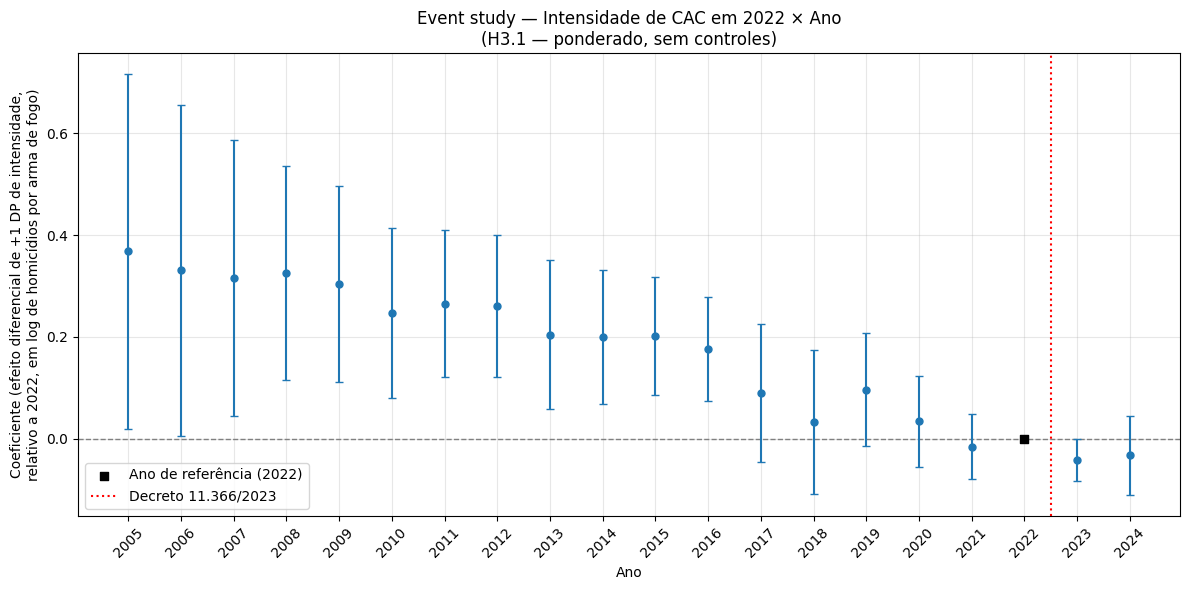


INTERPRETAÇÃO AUTOMÁTICA — MODELO H3.1

Teste de tendências paralelas (2005–2021 conjuntamente = 0):
qui-quadrado = 75.2747; gl = 17; p-valor = 0.0000.
ATENÇÃO: a hipótese de tendências paralelas é rejeitada ao nível de 10%. Isso enfraquece a interpretação causal do H2 e deve ser discutido explicitamente no artigo.

Teste conjunto do efeito pós-tratamento (2023-2024 = 0):
qui-quadrado = 4.1245; gl = 2; p-valor = 0.1272.

OBJETOS CRIADOS
• intensidade_2022_h3
• base_h3
• painel_h3
• resultado_h3_1
• resultado_h3_2
• resultado_h3_3
• tabela_testes_wald_h3
• tabela_coeficientes_h3
• fig (gráfico do event study)

Arquivo salvo em:
/content/resultados_artigo/tabelas/modelo_H3_event_study.xlsx

Célula 6.1 concluída com sucesso.


In [11]:
# ============================================================
# CÉLULA 6.1 — H3: EVENT STUDY (TENDÊNCIAS PARALELAS E DINÂMICA)
# ============================================================

# Objetivos:
#
# 1. reconstruir a intensidade estadual pré-tratamento em 2022
#    (mesma definição do H2: crs100 observado em 2022);
# 2. construir interações ano a ano entre a intensidade
#    padronizada e cada ano do painel, exceto o ano de
#    referência (2022);
# 3. estimar o event study ponderado, sem e com controles
#    econômicos, e uma versão não ponderada como robustez;
# 4. testar conjuntamente se os coeficientes pré-tratamento
#    (2005–2021) são iguais a zero — teste de tendências
#    paralelas;
# 5. testar conjuntamente se os coeficientes pós-tratamento
#    (2023–2024) são iguais a zero;
# 6. extrair tabela de coeficientes com IC 95% para os três
#    modelos;
# 7. construir o gráfico de coeficientes (event-study plot).
#
# Intensidade:
# CRs por 100 mil habitantes observados em 2022 (idêntica à
# construção da Célula 5.5 — não reutiliza int_i/int_i_z
# antigos, reconstrói do zero para garantir consistência).
#
# Dependente:
# log da taxa de homicídios por arma de fogo.
#
# Ano de referência:
# 2022. O coeficiente de 2022 é omitido (implicitamente = 0);
# todos os demais coeficientes devem ser lidos como o
# diferencial de UFs de alta intensidade em relação a UFs de
# baixa intensidade, naquele ano, relativo a 2022.
#
# Inferência:
# erros-padrão agrupados por UF.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from linearmodels.panel import PanelOLS


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE MAIS ATUALIZADA
# ============================================================

objetos_candidatos = [
    "painel_expandido",
    "painel_h2",
    "painel",
    "df"
]

bases_encontradas = []

for nome_objeto in objetos_candidatos:

    if nome_objeto not in globals():
        continue

    objeto = globals()[nome_objeto]

    if not isinstance(objeto, pd.DataFrame):
        continue

    teste = objeto.copy()

    if (
        "uf" in teste.index.names
        or "ano" in teste.index.names
    ):
        teste = teste.reset_index()

    if (
        "uf" not in teste.columns
        or "ano" not in teste.columns
    ):
        continue

    teste["ano"] = pd.to_numeric(
        teste["ano"],
        errors="coerce"
    )

    ano_maximo = teste["ano"].max()

    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": ano_maximo,
        "numero_observacoes": len(teste)
    })


if not bases_encontradas:

    raise NameError(
        "Não foi encontrado nenhum DataFrame adequado entre "
        "'painel_expandido', 'painel_h2', 'painel' e 'df'."
    )


bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base_origem = (
    bases_encontradas[0]["nome"]
)

base_h3 = (
    globals()[nome_base_origem]
    .copy()
)

print("=" * 100)
print("BASE UTILIZADA NO MODELO H3 — EVENT STUDY")
print("=" * 100)

print(
    "Objeto selecionado:",
    nome_base_origem
)


# ============================================================
# 2. PREPARAÇÃO DA BASE
# ============================================================

if base_h3.columns.duplicated().any():

    nomes_duplicados = (
        base_h3.columns[
            base_h3.columns.duplicated(
                keep=False
            )
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    print(
        "\nColunas duplicadas removidas:",
        nomes_duplicados
    )

    base_h3 = base_h3.loc[
        :,
        ~base_h3.columns.duplicated(
            keep="first"
        )
    ].copy()


if (
    "uf" in base_h3.index.names
    or "ano" in base_h3.index.names
):

    base_h3 = (
        base_h3
        .reset_index()
    )


for coluna in [
    "uf",
    "ano"
]:

    if coluna not in base_h3.columns:

        raise KeyError(
            f"A coluna '{coluna}' não foi encontrada."
        )


base_h3["uf"] = (
    base_h3["uf"]
    .astype(str)
    .str.strip()
    .str.upper()
)

base_h3["ano"] = pd.to_numeric(
    base_h3["ano"],
    errors="coerce"
)

base_h3 = (
    base_h3
    .dropna(
        subset=[
            "uf",
            "ano"
        ]
    )
    .copy()
)

base_h3["ano"] = (
    base_h3["ano"]
    .astype(int)
)


# Mantém 2005–2024 (painel completo)
base_h3 = (
    base_h3.loc[
        base_h3["ano"].between(
            2005,
            2024
        )
    ]
    .copy()
)


duplicidades = (
    base_h3
    .duplicated(
        subset=[
            "uf",
            "ano"
        ],
        keep=False
    )
)

if duplicidades.any():

    display(
        base_h3.loc[
            duplicidades,
            [
                "uf",
                "ano"
            ]
        ]
        .sort_values(
            [
                "uf",
                "ano"
            ]
        )
    )

    raise ValueError(
        "Existem observações duplicadas de UF × ano."
    )


# ============================================================
# 3. IDENTIFICAÇÃO DAS VARIÁVEIS PRINCIPAIS
# ============================================================

if "hom100" not in base_h3.columns:

    raise KeyError(
        "A variável 'hom100' não foi encontrada."
    )


base_h3["hom100"] = pd.to_numeric(
    base_h3["hom100"],
    errors="coerce"
)


if "ln_hom100" not in base_h3.columns:

    if (
        base_h3["hom100"] <= 0
    ).any():

        raise ValueError(
            "Existem valores de hom100 menores ou iguais a zero. "
            "Não é possível calcular o log diretamente."
        )

    base_h3[
        "ln_hom100"
    ] = np.log(
        base_h3["hom100"]
    )

else:

    base_h3[
        "ln_hom100"
    ] = pd.to_numeric(
        base_h3["ln_hom100"],
        errors="coerce"
    )


if "crs100" not in base_h3.columns:

    raise KeyError(
        "A variável 'crs100' não foi encontrada. "
        "Ela é necessária para reconstruir a intensidade de 2022."
    )


base_h3["crs100"] = pd.to_numeric(
    base_h3["crs100"],
    errors="coerce"
)


if "pop" not in base_h3.columns:

    raise KeyError(
        "A variável 'pop' não foi encontrada."
    )


base_h3["pop"] = pd.to_numeric(
    base_h3["pop"],
    errors="coerce"
)


# ============================================================
# 4. RECONSTRUÇÃO DA INTENSIDADE PRÉ-TRATAMENTO (2022)
# ============================================================

# Idêntica à Célula 5.5 — não reutiliza int_i/int_i_z antigos.

intensidade_2022_h3 = (
    base_h3.loc[
        base_h3["ano"] == 2022,
        [
            "uf",
            "crs100"
        ]
    ]
    .rename(
        columns={
            "crs100": "int_i"
        }
    )
    .dropna(
        subset=[
            "int_i"
        ]
    )
    .drop_duplicates(
        subset="uf"
    )
    .copy()
)


if intensidade_2022_h3["uf"].nunique() != 27:

    ufs_com_intensidade = set(
        intensidade_2022_h3["uf"]
    )

    ufs_painel = set(
        base_h3["uf"].unique()
    )

    ufs_ausentes = sorted(
        ufs_painel
        - ufs_com_intensidade
    )

    raise ValueError(
        "A intensidade de 2022 não está disponível para as 27 UFs. "
        "UFs ausentes: "
        + ", ".join(ufs_ausentes)
    )


media_intensidade_2022_h3 = (
    intensidade_2022_h3["int_i"]
    .mean()
)

desvio_intensidade_2022_h3 = (
    intensidade_2022_h3["int_i"]
    .std(
        ddof=1
    )
)


if (
    not np.isfinite(
        desvio_intensidade_2022_h3
    )
    or desvio_intensidade_2022_h3 <= 0
):

    raise ValueError(
        "A intensidade de 2022 não possui variação suficiente."
    )


intensidade_2022_h3[
    "int_i_z"
] = (
    intensidade_2022_h3["int_i"]
    - media_intensidade_2022_h3
) / desvio_intensidade_2022_h3


for coluna_antiga in [
    "int_i",
    "int_i_z"
]:

    if coluna_antiga in base_h3.columns:

        base_h3 = (
            base_h3
            .drop(
                columns=coluna_antiga
            )
        )


base_h3 = (
    base_h3
    .merge(
        intensidade_2022_h3,
        on="uf",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 5. CONSTRUÇÃO DAS INTERAÇÕES DO EVENT STUDY
# ============================================================

ANO_REFERENCIA_H3 = 2022

anos_painel_h3 = sorted(
    base_h3["ano"]
    .unique()
    .tolist()
)

anos_event_study = [
    ano
    for ano in anos_painel_h3
    if ano != ANO_REFERENCIA_H3
]

for ano in anos_event_study:

    base_h3[
        f"es_{ano}"
    ] = (
        base_h3["int_i_z"]
        * (
            base_h3["ano"] == ano
        ).astype(float)
    )

colunas_es = [
    f"es_{ano}"
    for ano in anos_event_study
]

colunas_es_pre = [
    f"es_{ano}"
    for ano in anos_event_study
    if ano < ANO_REFERENCIA_H3
]

colunas_es_pos = [
    f"es_{ano}"
    for ano in anos_event_study
    if ano > ANO_REFERENCIA_H3
]

print(
    "\nAno de referência (omitido):",
    ANO_REFERENCIA_H3
)

print(
    "Anos pré-tratamento:",
    [
        ano
        for ano in anos_event_study
        if ano < ANO_REFERENCIA_H3
    ]
)

print(
    "Anos pós-tratamento:",
    [
        ano
        for ano in anos_event_study
        if ano > ANO_REFERENCIA_H3
    ]
)


# ============================================================
# 6. PESOS POPULACIONAIS
# ============================================================

if base_h3["pop"].isna().any():

    display(
        base_h3.loc[
            base_h3["pop"].isna(),
            [
                "uf",
                "ano"
            ]
        ]
    )

    raise ValueError(
        "Existem valores ausentes de população."
    )


if (
    base_h3["pop"] <= 0
).any():

    raise ValueError(
        "Existem valores populacionais menores ou iguais a zero."
    )


base_h3[
    "peso_pop_h3"
] = (
    base_h3["pop"]
    / base_h3["pop"].mean()
)


# ============================================================
# 7. CONTROLES ECONÔMICOS
# ============================================================

controles_candidatos_h3 = [
    "ln_pibpc",
    "desemp"
]

controles_completos_h3 = []
controles_incompletos_h3 = []

for controle in controles_candidatos_h3:

    if controle not in base_h3.columns:

        controles_incompletos_h3.append(
            {
                "Variável": controle,
                "Motivo": "coluna ausente"
            }
        )

        continue

    base_h3[controle] = pd.to_numeric(
        base_h3[controle],
        errors="coerce"
    )

    ausencias = int(
        base_h3[controle]
        .isna()
        .sum()
    )

    if ausencias == 0:

        controles_completos_h3.append(
            controle
        )

    else:

        controles_incompletos_h3.append(
            {
                "Variável": controle,
                "Motivo": f"{ausencias} ausências no painel"
            }
        )


print("\n" + "=" * 100)
print("CONTROLES ECONÔMICOS")
print("=" * 100)

print(
    "Controles completos incluídos:",
    (
        ", ".join(controles_completos_h3)
        if controles_completos_h3
        else "nenhum"
    )
)

if controles_incompletos_h3:

    display(
        pd.DataFrame(
            controles_incompletos_h3
        )
    )


# ============================================================
# 8. VALIDAÇÃO DO PAINEL
# ============================================================

n_ufs_h3 = (
    base_h3["uf"]
    .nunique()
)

n_observacoes_h3 = len(
    base_h3
)

contagem_por_uf_h3 = (
    base_h3
    .groupby("uf")["ano"]
    .nunique()
)

painel_balanceado_h3 = bool(
    n_ufs_h3 == 27
    and anos_painel_h3
    == list(
        range(2005, 2025)
    )
    and (
        contagem_por_uf_h3 == 20
    ).all()
)

print("\n" + "=" * 100)
print("VALIDAÇÃO DO PAINEL H3 — EVENT STUDY")
print("=" * 100)

print(f"Observações: {n_observacoes_h3}")
print(f"UFs: {n_ufs_h3}")
print(f"Anos: {anos_painel_h3}")
print(f"Número de interações no event study: {len(colunas_es)}")
print(
    "Painel balanceado:",
    "SIM" if painel_balanceado_h3 else "NÃO"
)

if n_observacoes_h3 != 540:

    print(
        "\nATENÇÃO: eram esperadas 540 observações "
        "em um painel balanceado de 27 UFs × 20 anos."
    )

# Confere que o ano de referência tem todas as interações em zero
verificacao_referencia = (
    base_h3.loc[
        base_h3["ano"] == ANO_REFERENCIA_H3,
        colunas_es
    ]
    .abs()
    .sum()
    .sum()
)

if verificacao_referencia != 0:

    raise ValueError(
        "As interações do event study não estão zeradas "
        "no ano de referência (2022)."
    )

print(
    "Interações no ano de referência (2022): todas nulas — OK."
)


# ============================================================
# 9. CONSTRUÇÃO DO PAINEL INDEXADO
# ============================================================

painel_h3 = (
    base_h3
    .set_index(
        [
            "uf",
            "ano"
        ]
    )
    .sort_index()
)


# ============================================================
# 10. FUNÇÃO DE ESTIMAÇÃO
# ============================================================

def estimar_event_study(
    dados,
    dependente,
    explicativas,
    nome_modelo,
    ponderado=True,
    coluna_peso="peso_pop_h3"
):
    """
    Estima PanelOLS com:
    - efeitos fixos de UF;
    - efeitos fixos de ano;
    - ponderação opcional;
    - erros-padrão agrupados por UF.
    """

    colunas_modelo = [
        dependente,
        *explicativas
    ]

    if ponderado:

        colunas_modelo.append(
            coluna_peso
        )

    colunas_modelo = list(
        dict.fromkeys(
            colunas_modelo
        )
    )

    ausentes = [
        coluna
        for coluna in colunas_modelo
        if coluna not in dados.columns
    ]

    if ausentes:

        raise KeyError(
            f"Variáveis ausentes em {nome_modelo}: "
            + ", ".join(ausentes)
        )

    amostra = (
        dados[
            colunas_modelo
        ]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .dropna()
        .copy()
    )

    if amostra.empty:

        raise ValueError(
            f"A amostra do modelo {nome_modelo} ficou vazia."
        )

    if ponderado:

        if (
            amostra[coluna_peso] <= 0
        ).any():

            raise ValueError(
                f"Existem pesos inválidos em {nome_modelo}."
            )

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    else:

        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    resultado = modelo.fit(
        cov_type="clustered",
        cluster_entity=True,
        debiased=True
    )

    print("\n" + "=" * 100)
    print(nome_modelo)
    print("=" * 100)

    print(
        "Ponderação:",
        "população UF-ano" if ponderado else "não ponderado"
    )
    print("Observações:", resultado.nobs)
    print(
        "UFs:",
        amostra.index.get_level_values("uf").nunique()
    )
    print(
        "Anos:",
        amostra.index.get_level_values("ano").nunique()
    )
    print(resultado.summary)

    return resultado


# ============================================================
# 11. H3.1 — EVENT STUDY PONDERADO, SEM CONTROLES
# ============================================================

resultado_h3_1 = estimar_event_study(
    dados=painel_h3,
    dependente="ln_hom100",
    explicativas=colunas_es,
    nome_modelo="H3.1 — Event study ponderado, sem controles",
    ponderado=True
)


# ============================================================
# 12. H3.2 — EVENT STUDY PONDERADO, COM CONTROLES
# ============================================================

resultado_h3_2 = estimar_event_study(
    dados=painel_h3,
    dependente="ln_hom100",
    explicativas=colunas_es + controles_completos_h3,
    nome_modelo="H3.2 — Event study ponderado, com controles econômicos",
    ponderado=True
)


# ============================================================
# 13. H3.3 — EVENT STUDY NÃO PONDERADO (ROBUSTEZ)
# ============================================================

resultado_h3_3 = estimar_event_study(
    dados=painel_h3,
    dependente="ln_hom100",
    explicativas=colunas_es,
    nome_modelo="H3.3 — Event study não ponderado (robustez)",
    ponderado=False
)


# ============================================================
# 14. FUNÇÃO DE TESTE DE WALD (idêntica à Célula 5.5)
# ============================================================

def teste_wald_manual(
    resultado,
    restricoes,
    valores,
    nome_teste
):
    """
    Teste de Wald para R beta = q.
    """

    nomes_parametros = list(
        resultado.params.index
    )

    beta = (
        resultado.params
        .to_numpy(dtype=float)
        .reshape(-1, 1)
    )

    cov = (
        resultado.cov
        .loc[nomes_parametros, nomes_parametros]
        .to_numpy(dtype=float)
    )

    R = np.zeros(
        (len(restricoes), len(nomes_parametros))
    )

    for linha, restricao in enumerate(restricoes):

        for variavel, coeficiente in restricao.items():

            if variavel not in nomes_parametros:

                raise KeyError(
                    f"A variável '{variavel}' não foi estimada."
                )

            coluna = nomes_parametros.index(variavel)
            R[linha, coluna] = coeficiente

    q = np.asarray(valores, dtype=float).reshape(-1, 1)

    diferenca = R @ beta - q
    variancia = R @ cov @ R.T
    inversa_variancia = np.linalg.pinv(variancia)

    estatistica = float(
        (diferenca.T @ inversa_variancia @ diferenca).squeeze()
    )

    graus_liberdade = int(
        np.linalg.matrix_rank(R)
    )

    p_valor = float(
        stats.chi2.sf(estatistica, graus_liberdade)
    )

    return {
        "Teste": nome_teste,
        "Estatística qui-quadrado": estatistica,
        "Graus de liberdade": graus_liberdade,
        "p-valor": p_valor
    }


# ============================================================
# 15. TESTES DE WALD — TENDÊNCIAS PARALELAS E EFEITO PÓS
# ============================================================

resultados_testes_wald_h3 = []

for nome_modelo_curto, resultado in [
    ("H3.1", resultado_h3_1),
    ("H3.2", resultado_h3_2),
    ("H3.3", resultado_h3_3)
]:

    colunas_pre_presentes = [
        c for c in colunas_es_pre
        if c in resultado.params.index
    ]

    colunas_pos_presentes = [
        c for c in colunas_es_pos
        if c in resultado.params.index
    ]

    # Teste de tendências paralelas: todos os coeficientes
    # pré-tratamento (2005-2021) conjuntamente iguais a zero.
    resultados_testes_wald_h3.append(
        teste_wald_manual(
            resultado=resultado,
            restricoes=[
                {c: 1} for c in colunas_pre_presentes
            ],
            valores=[0] * len(colunas_pre_presentes),
            nome_teste=(
                f"{nome_modelo_curto} — Tendências paralelas "
                f"(pré-tratamento 2005–2021 = 0)"
            )
        )
    )

    # Teste conjunto do efeito pós-tratamento (2023-2024).
    resultados_testes_wald_h3.append(
        teste_wald_manual(
            resultado=resultado,
            restricoes=[
                {c: 1} for c in colunas_pos_presentes
            ],
            valores=[0] * len(colunas_pos_presentes),
            nome_teste=(
                f"{nome_modelo_curto} — Efeito pós-tratamento "
                f"(2023-2024) conjuntamente = 0"
            )
        )
    )

tabela_testes_wald_h3 = pd.DataFrame(
    resultados_testes_wald_h3
)

print("\n" + "=" * 100)
print("TESTES DE WALD — H3 EVENT STUDY")
print("=" * 100)

display(
    tabela_testes_wald_h3.style.format({
        "Estatística qui-quadrado": "{:.4f}",
        "p-valor": "{:.4f}"
    })
)


# ============================================================
# 16. EXTRAÇÃO DA TABELA DE COEFICIENTES (COM ANO DE REFERÊNCIA)
# ============================================================

def extrair_coeficientes_event_study(
    resultado,
    nome_modelo
):

    intervalos = resultado.conf_int()
    linhas = []

    for ano in anos_event_study:

        coluna = f"es_{ano}"

        if coluna not in resultado.params.index:
            continue

        linhas.append({
            "Modelo": nome_modelo,
            "Ano": ano,
            "Coeficiente": float(resultado.params[coluna]),
            "Erro-padrão": float(resultado.std_errors[coluna]),
            "Estatística t": float(resultado.tstats[coluna]),
            "p-valor": float(resultado.pvalues[coluna]),
            "IC 2,5%": float(intervalos.loc[coluna].iloc[0]),
            "IC 97,5%": float(intervalos.loc[coluna].iloc[1]),
            "Período": (
                "Pré-tratamento" if ano < ANO_REFERENCIA_H3
                else "Pós-tratamento"
            )
        })

    # Adiciona o ano de referência (coeficiente e IC = 0, por construção)
    linhas.append({
        "Modelo": nome_modelo,
        "Ano": ANO_REFERENCIA_H3,
        "Coeficiente": 0.0,
        "Erro-padrão": 0.0,
        "Estatística t": np.nan,
        "p-valor": np.nan,
        "IC 2,5%": 0.0,
        "IC 97,5%": 0.0,
        "Período": "Referência"
    })

    return (
        pd.DataFrame(linhas)
        .sort_values("Ano")
        .reset_index(drop=True)
    )


tabela_coeficientes_h3_1 = extrair_coeficientes_event_study(
    resultado_h3_1,
    "H3.1 — Ponderado, sem controles"
)

tabela_coeficientes_h3_2 = extrair_coeficientes_event_study(
    resultado_h3_2,
    "H3.2 — Ponderado, com controles"
)

tabela_coeficientes_h3_3 = extrair_coeficientes_event_study(
    resultado_h3_3,
    "H3.3 — Não ponderado"
)

tabela_coeficientes_h3 = pd.concat(
    [
        tabela_coeficientes_h3_1,
        tabela_coeficientes_h3_2,
        tabela_coeficientes_h3_3
    ],
    ignore_index=True
)

print("\n" + "=" * 100)
print("COEFICIENTES DO EVENT STUDY — H3.1 (MODELO PRINCIPAL)")
print("=" * 100)

display(
    tabela_coeficientes_h3_1.style.format({
        "Coeficiente": "{:.4f}",
        "Erro-padrão": "{:.4f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}",
        "IC 2,5%": "{:.4f}",
        "IC 97,5%": "{:.4f}"
    })
)


# ============================================================
# 17. GRÁFICO DE COEFICIENTES (EVENT-STUDY PLOT)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

dados_grafico = tabela_coeficientes_h3_1.sort_values("Ano")

erro_inferior = (
    dados_grafico["Coeficiente"] - dados_grafico["IC 2,5%"]
)
erro_superior = (
    dados_grafico["IC 97,5%"] - dados_grafico["Coeficiente"]
)

cores = [
    "#1f77b4" if periodo != "Referência" else "#000000"
    for periodo in dados_grafico["Período"]
]

ax.errorbar(
    dados_grafico["Ano"],
    dados_grafico["Coeficiente"],
    yerr=[erro_inferior, erro_superior],
    fmt="o",
    color="#1f77b4",
    ecolor="#1f77b4",
    elinewidth=1.5,
    capsize=3,
    markersize=5,
    zorder=3
)

ax.scatter(
    [ANO_REFERENCIA_H3],
    [0],
    color="black",
    marker="s",
    s=40,
    zorder=4,
    label="Ano de referência (2022)"
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(
    2022.5,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label="Decreto 11.366/2023"
)

ax.set_xlabel("Ano")
ax.set_ylabel(
    "Coeficiente (efeito diferencial de +1 DP de intensidade,\n"
    "relativo a 2022, em log de homicídios por arma de fogo)"
)
ax.set_title(
    "Event study — Intensidade de CAC em 2022 × Ano\n"
    "(H3.1 — ponderado, sem controles)"
)
ax.set_xticks(anos_painel_h3)
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 18. INTERPRETAÇÃO AUTOMÁTICA
# ============================================================

teste_paralelas_h3_1 = tabela_testes_wald_h3.iloc[0]
teste_pos_h3_1 = tabela_testes_wald_h3.iloc[1]

print("\n" + "=" * 100)
print("INTERPRETAÇÃO AUTOMÁTICA — MODELO H3.1")
print("=" * 100)

print(
    "\nTeste de tendências paralelas (2005–2021 conjuntamente = 0):"
)
print(
    f"qui-quadrado = {teste_paralelas_h3_1['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_paralelas_h3_1['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_paralelas_h3_1['p-valor']:.4f}."
)

if teste_paralelas_h3_1["p-valor"] >= 0.10:
    print(
        "Não há rejeição da hipótese de tendências paralelas: "
        "os coeficientes pré-tratamento, em conjunto, não são "
        "estatisticamente distintos de zero."
    )
else:
    print(
        "ATENÇÃO: a hipótese de tendências paralelas é rejeitada "
        "ao nível de 10%. Isso enfraquece a interpretação causal "
        "do H2 e deve ser discutido explicitamente no artigo."
    )

print(
    "\nTeste conjunto do efeito pós-tratamento (2023-2024 = 0):"
)
print(
    f"qui-quadrado = {teste_pos_h3_1['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_pos_h3_1['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_pos_h3_1['p-valor']:.4f}."
)


# ============================================================
# 19. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():

    from pathlib import Path

    PASTA_TABELAS = Path(
        "/content/resultados_artigo/tabelas"
    )

    PASTA_TABELAS.mkdir(
        parents=True,
        exist_ok=True
    )

arquivo_h3 = (
    PASTA_TABELAS
    / "modelo_H3_event_study.xlsx"
)

with pd.ExcelWriter(
    arquivo_h3,
    engine="openpyxl"
) as writer:

    intensidade_2022_h3.to_excel(
        writer,
        sheet_name="Intensidade_2022",
        index=False
    )

    tabela_coeficientes_h3.to_excel(
        writer,
        sheet_name="Coeficientes",
        index=False
    )

    tabela_testes_wald_h3.to_excel(
        writer,
        sheet_name="Testes_Wald",
        index=False
    )

fig.savefig(
    PASTA_TABELAS / "event_study_h3.png",
    dpi=150,
    bbox_inches="tight"
)

print("\n" + "=" * 100)
print("OBJETOS CRIADOS")
print("=" * 100)

print("• intensidade_2022_h3")
print("• base_h3")
print("• painel_h3")
print("• resultado_h3_1")
print("• resultado_h3_2")
print("• resultado_h3_3")
print("• tabela_testes_wald_h3")
print("• tabela_coeficientes_h3")
print("• fig (gráfico do event study)")

print("\nArquivo salvo em:")
print(arquivo_h3)

print("\nCélula 6.1 concluída com sucesso.")

CÉLULA 7.1 — FIGURA 1: EVENT STUDY
Modelo: H3.1 — ponderado, sem controles
Ano de referência: 2022


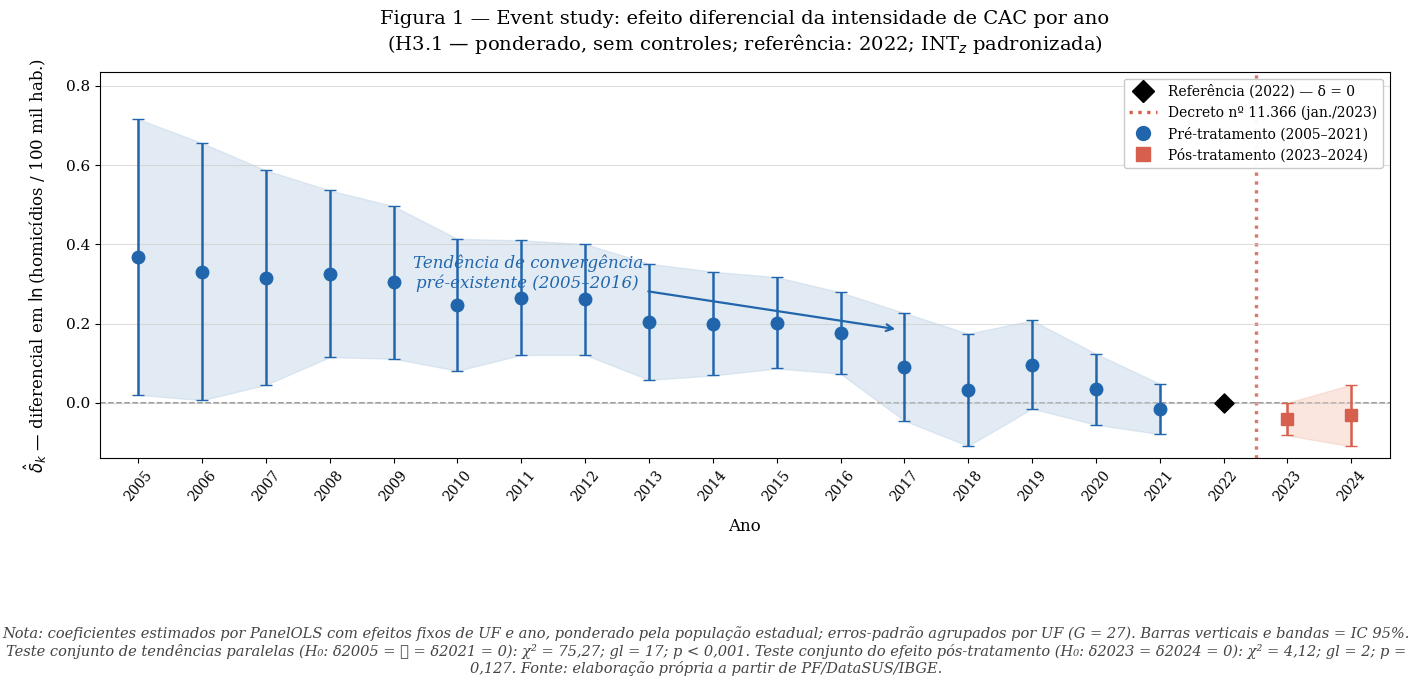


EXPORTAÇÃO CONCLUÍDA
PNG: /content/resultados_artigo/figuras/figura1_event_study.png
PDF: /content/resultados_artigo/figuras/figura1_event_study.pdf

Célula 7.1 concluída com sucesso.


In [12]:
# ============================================================
# CÉLULA 7.1 — FIGURA 1: GRÁFICO DO EVENT STUDY (H3)
# VERSÃO FINAL — ESTILO PRÓXIMO À FIGURA GERADA POR IA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

# ------------------------------------------------------------
# 1. VERIFICAÇÃO DOS OBJETOS NECESSÁRIOS
# ------------------------------------------------------------
if "resultado_h3_1" not in globals():
    raise NameError(
        "O objeto 'resultado_h3_1' não foi encontrado. "
        "Execute a Célula 6.1 antes desta célula."
    )

if "tabela_testes_wald_h3" not in globals():
    raise NameError(
        "O objeto 'tabela_testes_wald_h3' não foi encontrado. "
        "Execute a Célula 6.1 antes desta célula."
    )

print("=" * 90)
print("CÉLULA 7.1 — FIGURA 1: EVENT STUDY")
print("=" * 90)
print("Modelo: H3.1 — ponderado, sem controles")
print("Ano de referência: 2022")


# ------------------------------------------------------------
# 2. EXTRAÇÃO DOS COEFICIENTES
# ------------------------------------------------------------
ANO_REFERENCIA = 2022

params = resultado_h3_1.params
ic = resultado_h3_1.conf_int()
pvalues = resultado_h3_1.pvalues

anos_modelo = sorted(
    [
        int(nome.replace("es_", ""))
        for nome in params.index
        if nome.startswith("es_")
    ]
)

registros = []

for ano in anos_modelo:
    var = f"es_{ano}"
    registros.append({
        "ano": ano,
        "coef": float(params[var]),
        "ic_inf": float(ic.loc[var].iloc[0]),
        "ic_sup": float(ic.loc[var].iloc[1]),
        "pvalor": float(pvalues[var]),
        "periodo": (
            "Pré-tratamento" if ano < ANO_REFERENCIA
            else "Pós-tratamento"
        )
    })

# adiciona ponto de referência
registros.append({
    "ano": ANO_REFERENCIA,
    "coef": 0.0,
    "ic_inf": 0.0,
    "ic_sup": 0.0,
    "pvalor": np.nan,
    "periodo": "Referência"
})

df_plot = (
    pd.DataFrame(registros)
    .sort_values("ano")
    .reset_index(drop=True)
)

df_pre = df_plot[df_plot["periodo"] == "Pré-tratamento"].copy()
df_pos = df_plot[df_plot["periodo"] == "Pós-tratamento"].copy()
df_ref = df_plot[df_plot["periodo"] == "Referência"].copy()

anos_todos = df_plot["ano"].tolist()


# ------------------------------------------------------------
# 3. TESTES DE WALD PARA A NOTA
# ------------------------------------------------------------
teste_pre = tabela_testes_wald_h3[
    tabela_testes_wald_h3["Teste"].str.contains(
        "paralela|pré", case=False, na=False
    )
].copy()

teste_pos = tabela_testes_wald_h3[
    tabela_testes_wald_h3["Teste"].str.contains(
        "pós|pos", case=False, na=False
    )
].copy()

if len(teste_pre) == 0 or len(teste_pos) == 0:
    raise ValueError(
        "Não foi possível localizar os testes de Wald "
        "pré e pós em 'tabela_testes_wald_h3'."
    )

teste_pre = teste_pre.iloc[0]
teste_pos = teste_pos.iloc[0]


# ------------------------------------------------------------
# 4. CONFIGURAÇÕES VISUAIS
# ------------------------------------------------------------
COR_PRE = "#2166AC"
COR_PRE_BANDA = "#BFD3E6"

COR_POS = "#D6604D"
COR_POS_BANDA = "#F4C7B8"

COR_REF = "#000000"
COR_ZERO = "#7F7F7F"
COR_DECRETO = "#D6604D"
COR_GRID = "#CFCFCF"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})


# ------------------------------------------------------------
# 5. CRIAÇÃO DA FIGURA
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# linha horizontal zero
ax.axhline(
    0,
    color=COR_ZERO,
    linestyle="--",
    linewidth=1.1,
    zorder=1
)

# linha vertical do decreto
ax.axvline(
    2022.5,
    color=COR_DECRETO,
    linestyle=":",
    linewidth=2.4,
    alpha=0.85,
    zorder=1
)

# bandas de IC preenchidas
ax.fill_between(
    df_pre["ano"],
    df_pre["ic_inf"],
    df_pre["ic_sup"],
    color=COR_PRE_BANDA,
    alpha=0.45,
    zorder=1
)

if len(df_pos) > 0:
    ax.fill_between(
        df_pos["ano"],
        df_pos["ic_inf"],
        df_pos["ic_sup"],
        color=COR_POS_BANDA,
        alpha=0.45,
        zorder=1
    )

# barras e pontos pré-tratamento
ax.errorbar(
    df_pre["ano"],
    df_pre["coef"],
    yerr=[
        df_pre["coef"] - df_pre["ic_inf"],
        df_pre["ic_sup"] - df_pre["coef"]
    ],
    fmt="o",
    color=COR_PRE,
    ecolor=COR_PRE,
    elinewidth=1.8,
    capsize=4,
    markersize=9,
    zorder=3
)

# barras e pontos pós-tratamento (vermelhos)
if len(df_pos) > 0:
    ax.errorbar(
        df_pos["ano"],
        df_pos["coef"],
        yerr=[
            df_pos["coef"] - df_pos["ic_inf"],
            df_pos["ic_sup"] - df_pos["coef"]
        ],
        fmt="s",
        color=COR_POS,
        ecolor=COR_POS,
        elinewidth=1.8,
        capsize=4,
        markersize=9,
        zorder=4
    )

# ponto de referência
ax.scatter(
    df_ref["ano"],
    df_ref["coef"],
    color=COR_REF,
    marker="D",
    s=95,
    zorder=5
)

# anotação da tendência prévia
ax.annotate(
    "Tendência de convergência\npré-existente (2005–2016)",
    xy=(2016.9, 0.185),
    xytext=(2011.1, 0.29),
    fontsize=12,
    color=COR_PRE,
    fontstyle="italic",
    ha="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.6,
        color=COR_PRE
    )
)

# eixos
ax.set_xlabel("Ano", labelpad=10)
ax.set_ylabel(
    r"$\hat{\delta}_k$ — diferencial em $\ln$(homicídios / 100 mil hab.)",
    labelpad=12
)

ax.set_title(
    "Figura 1 — Event study: efeito diferencial da intensidade de CAC por ano\n"
    r"(H3.1 — ponderado, sem controles; referência: 2022; INT$_z$ padronizada)",
    pad=16
)

ax.set_xticks(anos_todos)
ax.tick_params(axis="x", rotation=50)
ax.set_xlim(min(anos_todos) - 0.6, max(anos_todos) + 0.6)

y_min = min(df_plot["ic_inf"].min(), -0.10) - 0.03
y_max = df_plot["ic_sup"].max() + 0.12
ax.set_ylim(y_min, y_max)

ax.grid(axis="y", color=COR_GRID, alpha=0.65, linewidth=0.8)
ax.grid(axis="x", alpha=0.0)

# legenda customizada na ordem desejada
handle_ref = mlines.Line2D(
    [], [], color=COR_REF, marker="D", linestyle="None",
    markersize=11, label="Referência (2022) — δ = 0"
)
handle_dec = mlines.Line2D(
    [], [], color=COR_DECRETO, linestyle=":",
    linewidth=2.4, label="Decreto nº 11.366 (jan./2023)"
)
handle_pre = mlines.Line2D(
    [], [], color=COR_PRE, marker="o", linestyle="None",
    markersize=10, label="Pré-tratamento (2005–2021)"
)
handle_pos = mlines.Line2D(
    [], [], color=COR_POS, marker="s", linestyle="None",
    markersize=10, label="Pós-tratamento (2023–2024)"
)

ax.legend(
    handles=[handle_ref, handle_dec, handle_pre, handle_pos],
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#C8C8C8"
)

# ------------------------------------------------------------
# 6. NOTA DE RODAPÉ
# ------------------------------------------------------------
def formatar_p(p):
    if p < 0.001:
        return "p < 0,001"
    return f"p = {p:.3f}".replace(".", ",")

estat_pre = f"{teste_pre['Estatística qui-quadrado']:.2f}".replace(".", ",")
gl_pre = int(teste_pre["Graus de liberdade"])
p_pre = formatar_p(float(teste_pre["p-valor"]))

estat_pos = f"{teste_pos['Estatística qui-quadrado']:.2f}".replace(".", ",")
gl_pos = int(teste_pos["Graus de liberdade"])
p_pos = formatar_p(float(teste_pos["p-valor"]))

nota = (
    "Nota: coeficientes estimados por PanelOLS com efeitos fixos de UF e ano, "
    "ponderado pela população estadual; erros-padrão agrupados por UF (G = 27). "
    "Barras verticais e bandas = IC 95%. "
    "Teste conjunto de tendências paralelas "
    f"(H₀: δ2005 = ⋯ = δ2021 = 0): χ² = {estat_pre}; gl = {gl_pre}; {p_pre}. "
    "Teste conjunto do efeito pós-tratamento "
    f"(H₀: δ2023 = δ2024 = 0): χ² = {estat_pos}; gl = {gl_pos}; {p_pos}. "
    "Fonte: elaboração própria a partir de PF/DataSUS/IBGE."
)

fig.text(
    0.5,
    -0.055,
    nota,
    ha="center",
    va="top",
    fontsize=10.5,
    color="#444444",
    wrap=True,
    style="italic"
)

plt.tight_layout(rect=[0, 0.07, 1, 1])


# ------------------------------------------------------------
# 7. EXPORTAÇÃO
# ------------------------------------------------------------
if "PASTA_TABELAS" not in globals():
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

PASTA_FIGURAS = PASTA_TABELAS.parent / "figuras"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

caminho_png = PASTA_FIGURAS / "figura1_event_study.png"
caminho_pdf = PASTA_FIGURAS / "figura1_event_study.pdf"

fig.savefig(
    caminho_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    caminho_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\n" + "=" * 90)
print("EXPORTAÇÃO CONCLUÍDA")
print("=" * 90)
print(f"PNG: {caminho_png}")
print(f"PDF: {caminho_pdf}")
print("\nCélula 7.1 concluída com sucesso.")

BASE UTILIZADA NO DIAGNÓSTICO DE TENDÊNCIA PRÉVIA
Objeto selecionado: painel_h2

RESUMO — DIAGNÓSTICO DE TENDÊNCIA PRÉVIA


,Hipótese,Correlação de Pearson,p-valor (Pearson),Correlação de Spearman,p-valor (Spearman),N (UFs)
0,"H1 — Regressão à média (nível 2005, hom100)",0.0245,0.9036,0.3187,0.1052,27
1,"H1b — Regressão à média (nível 2005, ln_hom100)",0.1457,0.4685,nan,nan,27
2,"H2 — Tendência divergente (inclinação ln_hom100, 2005-2021)",-0.5296,0.0045,-0.6221,0.0005,27



Regressão: inclinação_2005_2021 = 0.0138 + -0.0291 * int_i_z  (p=0.0045, R²=0.2804)

DETALHE POR UF (ordenado por intensidade de CAC em 2022)


,uf,hom100_2005,ln_hom100_2005,int_i_z,inclinacao_2005_2021,erro_padrao_inclinacao
0,GO,15.85,2.7632,1.896,0.0166,0.0139
1,DF,21.94,3.0883,1.681,-0.0766,0.0144
2,SC,6.58,1.8840,1.568,-0.0107,0.0088
3,MT,17.27,2.8490,1.501,-0.0053,0.0082
4,RO,24.05,3.1801,1.409,-0.0217,0.0072
5,PR,19.89,2.9902,1.318,-0.0465,0.0077
6,MS,15.28,2.7265,1.209,-0.0472,0.0056
7,RS,13.56,2.6071,0.795,0.0075,0.0094
8,TO,6.28,1.8374,0.233,0.0739,0.0091
9,SP,14.30,2.6603,0.143,-0.0829,0.0058


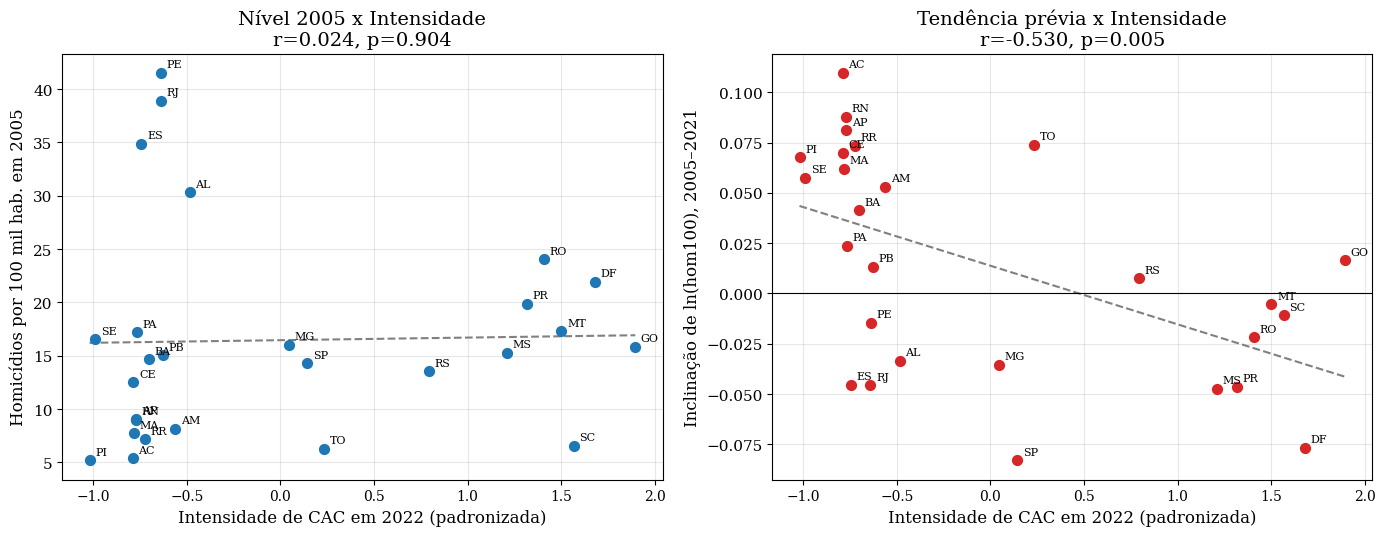


INTERPRETAÇÃO AUTOMÁTICA
H1 (regressão à média): correlação NÃO significativa (r=0.024, p=0.904) — o nível de homicídios em 2005 não explica a intensidade de CAC em 2022. Hipótese de regressão à média simples é descartada.

H2 (tendência divergente): correlação significativa (r=-0.530, p=0.005) — UFs de maior intensidade de CAC já apresentavam trajetória de homicídios distinta entre 2005 e 2021, antes de qualquer tratamento. Este é o mecanismo mais provável por trás da rejeição de tendências paralelas encontrada no H3.

OBJETOS CRIADOS
• intensidade_2022_diag
• nivel_2005
• tabela_inclinacoes
• tabela_diagnostico
• tabela_uf_diagnostico
• fig (gráficos de dispersão)

Arquivo salvo em:
/content/resultados_artigo/tabelas/diagnostico_tendencia_previa.xlsx

Célula 6.2 concluída com sucesso.


In [13]:
# ============================================================
# CÉLULA 6.2 — DIAGNÓSTICO: TENDÊNCIA PRÉVIA x INTENSIDADE DE CAC
# ============================================================

# Objetivo:
#
# Investigar a origem da rejeição de tendências paralelas
# encontrada na Célula 6.1 (H3). Testa duas hipóteses:
#
# 1. Regressão à média: UFs de maior intensidade de CAC em
#    2022 já partiam de um NÍVEL de homicídios diferente em
#    2005 (correlação int_i_z x hom100_2005 / ln_hom100_2005).
#
# 2. Tendência divergente genuína: UFs de maior intensidade
#    de CAC em 2022 já vinham de uma INCLINAÇÃO (trajetória)
#    de homicídios distinta entre 2005 e 2021, independente
#    do nível inicial.
#
# Reconstrói a intensidade de forma idêntica às Células 5.5
# e 6.1 (crs100 em 2022, padronizado), para garantir que o
# resultado seja diretamente comparável.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE MAIS ATUALIZADA
# ============================================================

objetos_candidatos = [
    "painel_expandido",
    "painel_h2",
    "painel",
    "df"
]

bases_encontradas = []

for nome_objeto in objetos_candidatos:

    if nome_objeto not in globals():
        continue

    objeto = globals()[nome_objeto]

    if not isinstance(objeto, pd.DataFrame):
        continue

    teste = objeto.copy()

    if (
        "uf" in teste.index.names
        or "ano" in teste.index.names
    ):
        teste = teste.reset_index()

    if (
        "uf" not in teste.columns
        or "ano" not in teste.columns
    ):
        continue

    teste["ano"] = pd.to_numeric(
        teste["ano"],
        errors="coerce"
    )

    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": teste["ano"].max(),
        "numero_observacoes": len(teste)
    })

if not bases_encontradas:

    raise NameError(
        "Não foi encontrado nenhum DataFrame adequado entre "
        "'painel_expandido', 'painel_h2', 'painel' e 'df'."
    )

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base_origem = bases_encontradas[0]["nome"]

base_diag = (
    globals()[nome_base_origem]
    .copy()
)

print("=" * 100)
print("BASE UTILIZADA NO DIAGNÓSTICO DE TENDÊNCIA PRÉVIA")
print("=" * 100)
print("Objeto selecionado:", nome_base_origem)


# ============================================================
# 2. PREPARAÇÃO DA BASE
# ============================================================

if base_diag.columns.duplicated().any():

    base_diag = base_diag.loc[
        :,
        ~base_diag.columns.duplicated(keep="first")
    ].copy()

if (
    "uf" in base_diag.index.names
    or "ano" in base_diag.index.names
):
    base_diag = base_diag.reset_index()

for coluna in ["uf", "ano", "hom100", "crs100"]:

    if coluna not in base_diag.columns:

        raise KeyError(
            f"A coluna '{coluna}' não foi encontrada."
        )

base_diag["uf"] = (
    base_diag["uf"].astype(str).str.strip().str.upper()
)
base_diag["ano"] = pd.to_numeric(
    base_diag["ano"], errors="coerce"
).astype("Int64")
base_diag["hom100"] = pd.to_numeric(
    base_diag["hom100"], errors="coerce"
)
base_diag["crs100"] = pd.to_numeric(
    base_diag["crs100"], errors="coerce"
)

base_diag = base_diag.dropna(subset=["uf", "ano"]).copy()
base_diag["ano"] = base_diag["ano"].astype(int)

# Reconstrói ln_hom100 se necessário (idêntico às células anteriores)
if "ln_hom100" not in base_diag.columns:

    if (base_diag["hom100"] <= 0).any():
        raise ValueError(
            "Existem valores de hom100 <= 0; não é possível "
            "calcular ln diretamente."
        )

    base_diag["ln_hom100"] = np.log(base_diag["hom100"])

else:

    base_diag["ln_hom100"] = pd.to_numeric(
        base_diag["ln_hom100"], errors="coerce"
    )


# ============================================================
# 3. RECONSTRUÇÃO DA INTENSIDADE (IDÊNTICA À CÉLULA 6.1)
# ============================================================

intensidade_2022_diag = (
    base_diag.loc[
        base_diag["ano"] == 2022,
        ["uf", "crs100"]
    ]
    .rename(columns={"crs100": "int_i"})
    .dropna(subset=["int_i"])
    .drop_duplicates(subset="uf")
    .copy()
)

if intensidade_2022_diag["uf"].nunique() != 27:

    raise ValueError(
        "A intensidade de 2022 não está disponível para as 27 UFs."
    )

media_int = intensidade_2022_diag["int_i"].mean()
desvio_int = intensidade_2022_diag["int_i"].std(ddof=1)

intensidade_2022_diag["int_i_z"] = (
    (intensidade_2022_diag["int_i"] - media_int) / desvio_int
)

mapa_int_i_z = dict(
    zip(
        intensidade_2022_diag["uf"],
        intensidade_2022_diag["int_i_z"]
    )
)


# ============================================================
# 4. HIPÓTESE 1 — NÍVEL EM 2005 (REGRESSÃO À MÉDIA)
# ============================================================

nivel_2005 = (
    base_diag.loc[
        base_diag["ano"] == 2005,
        ["uf", "hom100", "ln_hom100"]
    ]
    .drop_duplicates(subset="uf")
    .copy()
)

if nivel_2005["uf"].nunique() != 27:

    raise ValueError(
        "O nível de 2005 não está disponível para as 27 UFs."
    )

nivel_2005["int_i_z"] = nivel_2005["uf"].map(mapa_int_i_z)

r_pearson_nivel, p_pearson_nivel = stats.pearsonr(
    nivel_2005["int_i_z"], nivel_2005["hom100"]
)
r_spear_nivel, p_spear_nivel = stats.spearmanr(
    nivel_2005["int_i_z"], nivel_2005["hom100"]
)
r_pearson_ln_nivel, p_pearson_ln_nivel = stats.pearsonr(
    nivel_2005["int_i_z"], nivel_2005["ln_hom100"]
)


# ============================================================
# 5. HIPÓTESE 2 — INCLINAÇÃO 2005–2021 (TENDÊNCIA PRÉVIA)
# ============================================================

base_pre = base_diag.loc[
    base_diag["ano"].between(2005, 2021)
].copy()

inclinacoes = []

for uf, grupo in base_pre.groupby("uf"):

    grupo = grupo.dropna(subset=["ln_hom100"]).sort_values("ano")

    if len(grupo) < 2:
        continue

    slope, intercept, r, p, se = stats.linregress(
        grupo["ano"], grupo["ln_hom100"]
    )

    inclinacoes.append({
        "uf": uf,
        "inclinacao_2005_2021": slope,
        "erro_padrao_inclinacao": se,
        "n_anos": len(grupo)
    })

tabela_inclinacoes = pd.DataFrame(inclinacoes)

if tabela_inclinacoes["uf"].nunique() != 27:

    raise ValueError(
        "A inclinação 2005-2021 não foi calculada para as 27 UFs."
    )

tabela_inclinacoes["int_i_z"] = (
    tabela_inclinacoes["uf"].map(mapa_int_i_z)
)

r_pearson_incl, p_pearson_incl = stats.pearsonr(
    tabela_inclinacoes["int_i_z"],
    tabela_inclinacoes["inclinacao_2005_2021"]
)
r_spear_incl, p_spear_incl = stats.spearmanr(
    tabela_inclinacoes["int_i_z"],
    tabela_inclinacoes["inclinacao_2005_2021"]
)

slope_reg, intercept_reg, r_reg, p_reg, se_reg = stats.linregress(
    tabela_inclinacoes["int_i_z"],
    tabela_inclinacoes["inclinacao_2005_2021"]
)


# ============================================================
# 6. TABELA-RESUMO DOS DOIS TESTES
# ============================================================

tabela_diagnostico = pd.DataFrame([
    {
        "Hipótese": "H1 — Regressão à média (nível 2005, hom100)",
        "Correlação de Pearson": r_pearson_nivel,
        "p-valor (Pearson)": p_pearson_nivel,
        "Correlação de Spearman": r_spear_nivel,
        "p-valor (Spearman)": p_spear_nivel,
        "N (UFs)": 27
    },
    {
        "Hipótese": "H1b — Regressão à média (nível 2005, ln_hom100)",
        "Correlação de Pearson": r_pearson_ln_nivel,
        "p-valor (Pearson)": p_pearson_ln_nivel,
        "Correlação de Spearman": np.nan,
        "p-valor (Spearman)": np.nan,
        "N (UFs)": 27
    },
    {
        "Hipótese": "H2 — Tendência divergente (inclinação ln_hom100, 2005-2021)",
        "Correlação de Pearson": r_pearson_incl,
        "p-valor (Pearson)": p_pearson_incl,
        "Correlação de Spearman": r_spear_incl,
        "p-valor (Spearman)": p_spear_incl,
        "N (UFs)": 27
    }
])

print("\n" + "=" * 100)
print("RESUMO — DIAGNÓSTICO DE TENDÊNCIA PRÉVIA")
print("=" * 100)

display(
    tabela_diagnostico.style.format({
        "Correlação de Pearson": "{:.4f}",
        "p-valor (Pearson)": "{:.4f}",
        "Correlação de Spearman": "{:.4f}",
        "p-valor (Spearman)": "{:.4f}"
    })
)

print(
    f"\nRegressão: inclinação_2005_2021 = {intercept_reg:.4f} "
    f"+ {slope_reg:.4f} * int_i_z  "
    f"(p={p_reg:.4f}, R²={r_reg**2:.4f})"
)


# ============================================================
# 7. TABELA DETALHADA POR UF
# ============================================================

tabela_uf_diagnostico = (
    nivel_2005[["uf", "hom100", "ln_hom100", "int_i_z"]]
    .rename(columns={
        "hom100": "hom100_2005",
        "ln_hom100": "ln_hom100_2005"
    })
    .merge(
        tabela_inclinacoes[
            ["uf", "inclinacao_2005_2021", "erro_padrao_inclinacao"]
        ],
        on="uf"
    )
    .sort_values("int_i_z", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("DETALHE POR UF (ordenado por intensidade de CAC em 2022)")
print("=" * 100)

display(
    tabela_uf_diagnostico.style.format({
        "hom100_2005": "{:.2f}",
        "ln_hom100_2005": "{:.4f}",
        "int_i_z": "{:.3f}",
        "inclinacao_2005_2021": "{:.4f}",
        "erro_padrao_inclinacao": "{:.4f}"
    })
)


# ============================================================
# 8. GRÁFICOS DE DISPERSÃO
# ============================================================

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))

# Painel 1: nível 2005
eixos[0].scatter(
    nivel_2005["int_i_z"], nivel_2005["hom100"],
    color="#1f77b4", s=50, zorder=3
)
for _, linha in nivel_2005.iterrows():
    eixos[0].annotate(
        linha["uf"], (linha["int_i_z"], linha["hom100"]),
        fontsize=8, xytext=(4, 4), textcoords="offset points"
    )
slope_n, intercept_n, *_ = stats.linregress(
    nivel_2005["int_i_z"], nivel_2005["hom100"]
)
x_linha = np.linspace(
    nivel_2005["int_i_z"].min(), nivel_2005["int_i_z"].max(), 50
)
eixos[0].plot(
    x_linha, intercept_n + slope_n * x_linha,
    color="gray", linestyle="--"
)
eixos[0].set_xlabel("Intensidade de CAC em 2022 (padronizada)")
eixos[0].set_ylabel("Homicídios por 100 mil hab. em 2005")
eixos[0].set_title(
    f"Nível 2005 x Intensidade\n"
    f"r={r_pearson_nivel:.3f}, p={p_pearson_nivel:.3f}"
)
eixos[0].grid(alpha=0.3)

# Painel 2: inclinação 2005-2021
eixos[1].scatter(
    tabela_inclinacoes["int_i_z"],
    tabela_inclinacoes["inclinacao_2005_2021"],
    color="#d62728", s=50, zorder=3
)
for _, linha in tabela_inclinacoes.iterrows():
    eixos[1].annotate(
        linha["uf"],
        (linha["int_i_z"], linha["inclinacao_2005_2021"]),
        fontsize=8, xytext=(4, 4), textcoords="offset points"
    )
x_linha2 = np.linspace(
    tabela_inclinacoes["int_i_z"].min(),
    tabela_inclinacoes["int_i_z"].max(), 50
)
eixos[1].plot(
    x_linha2, intercept_reg + slope_reg * x_linha2,
    color="gray", linestyle="--"
)
eixos[1].axhline(0, color="black", linewidth=0.8)
eixos[1].set_xlabel("Intensidade de CAC em 2022 (padronizada)")
eixos[1].set_ylabel("Inclinação de ln(hom100), 2005–2021")
eixos[1].set_title(
    f"Tendência prévia x Intensidade\n"
    f"r={r_pearson_incl:.3f}, p={p_pearson_incl:.3f}"
)
eixos[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 9. INTERPRETAÇÃO AUTOMÁTICA
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETAÇÃO AUTOMÁTICA")
print("=" * 100)

if p_pearson_nivel < 0.10:
    print(
        f"H1 (regressão à média): correlação significativa "
        f"(r={r_pearson_nivel:.3f}, p={p_pearson_nivel:.3f}) — "
        f"há indício de que UFs de maior intensidade já partiam "
        f"de nível diferente de homicídios em 2005."
    )
else:
    print(
        f"H1 (regressão à média): correlação NÃO significativa "
        f"(r={r_pearson_nivel:.3f}, p={p_pearson_nivel:.3f}) — "
        f"o nível de homicídios em 2005 não explica a intensidade "
        f"de CAC em 2022. Hipótese de regressão à média simples "
        f"é descartada."
    )

if p_pearson_incl < 0.10:
    print(
        f"\nH2 (tendência divergente): correlação significativa "
        f"(r={r_pearson_incl:.3f}, p={p_pearson_incl:.3f}) — "
        f"UFs de maior intensidade de CAC já apresentavam "
        f"trajetória de homicídios distinta entre 2005 e 2021, "
        f"antes de qualquer tratamento. Este é o mecanismo mais "
        f"provável por trás da rejeição de tendências paralelas "
        f"encontrada no H3."
    )
else:
    print(
        f"\nH2 (tendência divergente): correlação NÃO significativa "
        f"(r={r_pearson_incl:.3f}, p={p_pearson_incl:.3f})."
    )


# ============================================================
# 10. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():

    from pathlib import Path

    PASTA_TABELAS = Path(
        "/content/resultados_artigo/tabelas"
    )
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_diagnostico = (
    PASTA_TABELAS / "diagnostico_tendencia_previa.xlsx"
)

with pd.ExcelWriter(
    arquivo_diagnostico, engine="openpyxl"
) as writer:

    tabela_diagnostico.to_excel(
        writer, sheet_name="Resumo_testes", index=False
    )
    tabela_uf_diagnostico.to_excel(
        writer, sheet_name="Detalhe_por_UF", index=False
    )

fig.savefig(
    PASTA_TABELAS / "diagnostico_tendencia_previa.png",
    dpi=150, bbox_inches="tight"
)

print("\n" + "=" * 100)
print("OBJETOS CRIADOS")
print("=" * 100)
print("• intensidade_2022_diag")
print("• nivel_2005")
print("• tabela_inclinacoes")
print("• tabela_diagnostico")
print("• tabela_uf_diagnostico")
print("• fig (gráficos de dispersão)")

print("\nArquivo salvo em:")
print(arquivo_diagnostico)

print("\nCélula 6.2 concluída com sucesso.")

In [14]:
# ============================================================
# 3. WILD CLUSTER BOOTSTRAP RESTRITO (RADEMACHER) — CORRIGIDO
# ============================================================

def wild_cluster_bootstrap(
    painel,
    dependente,
    explicativas_completas,
    variaveis_testadas,
    nome_teste,
    ponderado=True,
    coluna_peso="peso_es",
    n_bootstrap=399,
    semente=42
):
    """
    Bootstrap restrito de Cameron, Gelbach e Miller (2008):

    1. Constrói UMA amostra única com todas as colunas do
       modelo completo (evita KeyError ao reestimar o modelo
       completo dentro do loop de bootstrap).
    2. Estima o modelo restrito (impõe H0: variaveis_testadas=0)
       NESSA MESMA amostra.
    3. Gera B réplicas de y* = fitted_restrito + resid_restrito * w_g,
       com w_g in {-1,+1} sorteado por cluster (Rademacher).
    4. Reestima o modelo COMPLETO em cada réplica e recalcula a
       estatística de Wald para a mesma restrição.
    5. p-valor = proporção de réplicas com estatística >= observada.
    """

    explicativas_restritas = [
        v for v in explicativas_completas if v not in variaveis_testadas
    ]

    # ------------------------------------------------------------
    # Amostra única, com todas as colunas do modelo completo.
    # É construída uma vez e usada tanto para o modelo restrito
    # quanto para cada réplica do bootstrap, garantindo que
    # 'es_2023', 'es_2024' (ou quaisquer variáveis testadas)
    # sempre estejam presentes ao reestimar o modelo completo.
    # ------------------------------------------------------------
    colunas_necessarias = [dependente, *explicativas_completas]
    if ponderado:
        colunas_necessarias.append(coluna_peso)
    colunas_necessarias = list(dict.fromkeys(colunas_necessarias))

    amostra = (
        painel[colunas_necessarias]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    # Modelo completo (observado)
    resultado_completo = estimar_panel(
        amostra, dependente, explicativas_completas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    restricoes = [{v: 1} for v in variaveis_testadas]
    valores = [0] * len(variaveis_testadas)

    teste_observado = teste_wald_manual(
        resultado_completo, restricoes, valores, nome_teste
    )
    estatistica_observada = teste_observado["Estatística qui-quadrado"]

    # Modelo restrito, NA MESMA amostra (garante alinhamento de índice)
    resultado_restrito = estimar_panel(
        amostra, dependente, explicativas_restritas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    amostra["fitted_r"] = (
        resultado_restrito.fitted_values["fitted_values"].values
    )
    amostra["resid_r"] = resultado_restrito.resids.values

    ufs = amostra.index.get_level_values("uf").unique()
    rng = np.random.default_rng(semente)

    estatisticas_bootstrap = np.empty(n_bootstrap)

    t0 = time.time()

    for b in range(n_bootstrap):

        pesos_rademacher = pd.Series(
            rng.choice([-1.0, 1.0], size=len(ufs)), index=ufs
        )

        w_por_obs = amostra.index.get_level_values("uf").map(
            pesos_rademacher
        ).to_numpy()

        amostra["y_estrela"] = (
            amostra["fitted_r"] + amostra["resid_r"] * w_por_obs
        )

        resultado_boot = estimar_panel(
            amostra, "y_estrela", explicativas_completas,
            ponderado=ponderado, coluna_peso=coluna_peso
        )

        teste_boot = teste_wald_manual(
            resultado_boot, restricoes, valores, nome_teste
        )

        estatisticas_bootstrap[b] = teste_boot["Estatística qui-quadrado"]

    tempo_decorrido = time.time() - t0

    p_valor_wcb = (
        1 + np.sum(estatisticas_bootstrap >= estatistica_observada)
    ) / (n_bootstrap + 1)

    return {
        "nome_teste": nome_teste,
        "estatistica_observada": estatistica_observada,
        "p_valor_assintotico": teste_observado["p-valor"],
        "p_valor_wcb": p_valor_wcb,
        "n_bootstrap": n_bootstrap,
        "tempo_segundos": tempo_decorrido,
        "distribuicao_bootstrap": estatisticas_bootstrap,
        "mediana_bootstrap": float(np.median(estatisticas_bootstrap)),
        "p95_bootstrap": float(np.percentile(estatisticas_bootstrap, 95))
    }

In [15]:
# ============================================================
# 3. WILD CLUSTER BOOTSTRAP RESTRITO (RADEMACHER) — CORRIGIDO
# ============================================================

def wild_cluster_bootstrap(
    painel,
    dependente,
    explicativas_completas,
    variaveis_testadas,
    nome_teste,
    ponderado=True,
    coluna_peso="peso_es",
    n_bootstrap=399,
    semente=42
):
    """
    Bootstrap restrito de Cameron, Gelbach e Miller (2008):

    1. Constrói UMA amostra única com todas as colunas do
       modelo completo (evita KeyError ao reestimar o modelo
       completo dentro do loop de bootstrap).
    2. Estima o modelo restrito (impõe H0: variaveis_testadas=0)
       NESSA MESMA amostra.
    3. Gera B réplicas de y* = fitted_restrito + resid_restrito * w_g,
       com w_g in {-1,+1} sorteado por cluster (Rademacher).
    4. Reestima o modelo COMPLETO em cada réplica e recalcula a
       estatística de Wald para a mesma restrição.
    5. p-valor = proporção de réplicas com estatística >= observada.
    """

    explicativas_restritas = [
        v for v in explicativas_completas if v not in variaveis_testadas
    ]

    # ------------------------------------------------------------
    # Amostra única, com todas as colunas do modelo completo.
    # É construída uma vez e usada tanto para o modelo restrito
    # quanto para cada réplica do bootstrap, garantindo que
    # 'es_2023', 'es_2024' (ou quaisquer variáveis testadas)
    # sempre estejam presentes ao reestimar o modelo completo.
    # ------------------------------------------------------------
    colunas_necessarias = [dependente, *explicativas_completas]
    if ponderado:
        colunas_necessarias.append(coluna_peso)
    colunas_necessarias = list(dict.fromkeys(colunas_necessarias))

    amostra = (
        painel[colunas_necessarias]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    # Modelo completo (observado)
    resultado_completo = estimar_panel(
        amostra, dependente, explicativas_completas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    restricoes = [{v: 1} for v in variaveis_testadas]
    valores = [0] * len(variaveis_testadas)

    teste_observado = teste_wald_manual(
        resultado_completo, restricoes, valores, nome_teste
    )
    estatistica_observada = teste_observado["Estatística qui-quadrado"]

    # Modelo restrito, NA MESMA amostra (garante alinhamento de índice)
    resultado_restrito = estimar_panel(
        amostra, dependente, explicativas_restritas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    amostra["fitted_r"] = (
        resultado_restrito.fitted_values["fitted_values"].values
    )
    amostra["resid_r"] = resultado_restrito.resids.values

    ufs = amostra.index.get_level_values("uf").unique()
    rng = np.random.default_rng(semente)

    estatisticas_bootstrap = np.empty(n_bootstrap)

    t0 = time.time()

    for b in range(n_bootstrap):

        pesos_rademacher = pd.Series(
            rng.choice([-1.0, 1.0], size=len(ufs)), index=ufs
        )

        w_por_obs = amostra.index.get_level_values("uf").map(
            pesos_rademacher
        ).to_numpy()

        amostra["y_estrela"] = (
            amostra["fitted_r"] + amostra["resid_r"] * w_por_obs
        )

        resultado_boot = estimar_panel(
            amostra, "y_estrela", explicativas_completas,
            ponderado=ponderado, coluna_peso=coluna_peso
        )

        teste_boot = teste_wald_manual(
            resultado_boot, restricoes, valores, nome_teste
        )

        estatisticas_bootstrap[b] = teste_boot["Estatística qui-quadrado"]

    tempo_decorrido = time.time() - t0

    p_valor_wcb = (
        1 + np.sum(estatisticas_bootstrap >= estatistica_observada)
    ) / (n_bootstrap + 1)

    return {
        "nome_teste": nome_teste,
        "estatistica_observada": estatistica_observada,
        "p_valor_assintotico": teste_observado["p-valor"],
        "p_valor_wcb": p_valor_wcb,
        "n_bootstrap": n_bootstrap,
        "tempo_segundos": tempo_decorrido,
        "distribuicao_bootstrap": estatisticas_bootstrap,
        "mediana_bootstrap": float(np.median(estatisticas_bootstrap)),
        "p95_bootstrap": float(np.percentile(estatisticas_bootstrap, 95))
    }

In [16]:
 # ============================================================
# CÉLULA 6.3 — ROBUSTEZ: WILD CLUSTER BOOTSTRAP (H3) E
#               SENSIBILIDADE SEM O DF
# ============================================================

import numpy as np
import pandas as pd
import time

from scipy import stats
from linearmodels.panel import PanelOLS


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE
# ============================================================

objetos_candidatos = ["painel_expandido", "painel_h2", "painel", "df"]
bases_encontradas = []

for nome_objeto in objetos_candidatos:
    if nome_objeto not in globals():
        continue
    objeto = globals()[nome_objeto]
    if not isinstance(objeto, pd.DataFrame):
        continue
    teste = objeto.copy()
    if "uf" in teste.index.names or "ano" in teste.index.names:
        teste = teste.reset_index()
    if "uf" not in teste.columns or "ano" not in teste.columns:
        continue
    teste["ano"] = pd.to_numeric(teste["ano"], errors="coerce")
    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": teste["ano"].max(),
        "numero_observacoes": len(teste)
    })

if not bases_encontradas:
    raise NameError(
        "Não foi encontrado nenhum DataFrame adequado entre "
        "'painel_expandido', 'painel_h2', 'painel' e 'df'."
    )

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base_origem = bases_encontradas[0]["nome"]
base_robustez = globals()[nome_base_origem].copy()

print("=" * 100)
print("CÉLULA 6.3 — WILD CLUSTER BOOTSTRAP E SENSIBILIDADE SEM O DF")
print("=" * 100)
print("Base selecionada:", nome_base_origem)

if base_robustez.columns.duplicated().any():
    base_robustez = base_robustez.loc[
        :, ~base_robustez.columns.duplicated(keep="first")
    ].copy()

if "uf" in base_robustez.index.names or "ano" in base_robustez.index.names:
    base_robustez = base_robustez.reset_index()

for coluna in ["uf", "ano", "hom100", "crs100", "pop"]:
    if coluna not in base_robustez.columns:
        raise KeyError(f"A coluna '{coluna}' não foi encontrada.")

base_robustez["uf"] = base_robustez["uf"].astype(str).str.strip().str.upper()
base_robustez["ano"] = pd.to_numeric(base_robustez["ano"], errors="coerce")
base_robustez = base_robustez.dropna(subset=["uf", "ano"]).copy()
base_robustez["ano"] = base_robustez["ano"].astype(int)
base_robustez = base_robustez.loc[base_robustez["ano"].between(2005, 2024)].copy()

base_robustez["hom100"] = pd.to_numeric(base_robustez["hom100"], errors="coerce")
base_robustez["crs100"] = pd.to_numeric(base_robustez["crs100"], errors="coerce")
base_robustez["pop"] = pd.to_numeric(base_robustez["pop"], errors="coerce")

if "ln_hom100" not in base_robustez.columns:
    if (base_robustez["hom100"] <= 0).any():
        raise ValueError("Existem valores de hom100 <= 0.")
    base_robustez["ln_hom100"] = np.log(base_robustez["hom100"])
else:
    base_robustez["ln_hom100"] = pd.to_numeric(
        base_robustez["ln_hom100"], errors="coerce"
    )

print(f"Observações carregadas: {len(base_robustez)}")
print(f"UFs: {base_robustez['uf'].nunique()}")
print(f"Anos: {sorted(base_robustez['ano'].unique().tolist())}")


# ============================================================
# 2. FUNÇÃO: CONSTRUÇÃO DO PAINEL DE EVENT STUDY
# ============================================================

def construir_painel_event_study(dados_base, excluir_ufs=None):

    base = dados_base.copy()

    if excluir_ufs:
        base = base.loc[~base["uf"].isin(excluir_ufs)].copy()

    intensidade = (
        base.loc[base["ano"] == 2022, ["uf", "crs100"]]
        .rename(columns={"crs100": "int_i"})
        .dropna(subset=["int_i"])
        .drop_duplicates(subset="uf")
        .copy()
    )

    n_ufs_esperado = 27 - (len(excluir_ufs) if excluir_ufs else 0)

    if intensidade["uf"].nunique() != n_ufs_esperado:
        raise ValueError(
            "A intensidade de 2022 não está disponível para todas "
            "as UFs esperadas após exclusões."
        )

    media_int = intensidade["int_i"].mean()
    desvio_int = intensidade["int_i"].std(ddof=1)
    intensidade["int_i_z"] = (intensidade["int_i"] - media_int) / desvio_int

    for coluna_antiga in ["int_i", "int_i_z"]:
        if coluna_antiga in base.columns:
            base = base.drop(columns=coluna_antiga)

    base = base.merge(
        intensidade[["uf", "int_i_z"]], on="uf", how="left", validate="many_to_one"
    )

    ano_referencia = 2022
    anos_presentes = sorted(base["ano"].unique().tolist())

    for ano in anos_presentes:
        if ano == ano_referencia:
            continue
        base[f"es_{ano}"] = base["int_i_z"] * (base["ano"] == ano).astype(float)

    colunas_es = [f"es_{a}" for a in anos_presentes if a != ano_referencia]
    colunas_es_pre = [f"es_{a}" for a in anos_presentes if a < ano_referencia]
    colunas_es_pos = [f"es_{a}" for a in anos_presentes if a > ano_referencia]

    if base["pop"].isna().any() or (base["pop"] <= 0).any():
        raise ValueError("Existem valores inválidos de população.")

    base["peso_es"] = base["pop"] / base["pop"].mean()

    painel = base.set_index(["uf", "ano"]).sort_index()

    return painel, colunas_es, colunas_es_pre, colunas_es_pos


painel_h3_robustez, es_cols, es_pre_cols, es_pos_cols = (
    construir_painel_event_study(base_robustez)
)

print(f"\nInterações totais: {len(es_cols)}")
print(f"Pré-tratamento (2005-2021): {len(es_pre_cols)}")
print(f"Pós-tratamento (2023-2024): {len(es_pos_cols)}")


# ============================================================
# 3. FUNÇÕES DE ESTIMAÇÃO E TESTE DE WALD
# ============================================================

def estimar_panel(dados, dependente, explicativas, ponderado=True, coluna_peso="peso_es"):

    colunas_modelo = [dependente, *explicativas]
    if ponderado:
        colunas_modelo.append(coluna_peso)
    colunas_modelo = list(dict.fromkeys(colunas_modelo))

    amostra = (
        dados[colunas_modelo]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if ponderado:
        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )
    else:
        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    return modelo.fit(cov_type="clustered", cluster_entity=True, debiased=True)


def teste_wald_manual(resultado, restricoes, valores, nome_teste):

    nomes_parametros = list(resultado.params.index)
    beta = resultado.params.to_numpy(dtype=float).reshape(-1, 1)
    cov = resultado.cov.loc[nomes_parametros, nomes_parametros].to_numpy(dtype=float)

    R = np.zeros((len(restricoes), len(nomes_parametros)))
    for linha, restricao in enumerate(restricoes):
        for variavel, coeficiente in restricao.items():
            if variavel not in nomes_parametros:
                raise KeyError(f"A variável '{variavel}' não foi estimada.")
            R[linha, nomes_parametros.index(variavel)] = coeficiente

    q = np.asarray(valores, dtype=float).reshape(-1, 1)

    diferenca = R @ beta - q
    variancia = R @ cov @ R.T
    inversa_variancia = np.linalg.pinv(variancia)

    estatistica = float((diferenca.T @ inversa_variancia @ diferenca).squeeze())
    graus_liberdade = int(np.linalg.matrix_rank(R))
    p_valor = float(stats.chi2.sf(estatistica, graus_liberdade))

    return {
        "Teste": nome_teste,
        "Estatística qui-quadrado": estatistica,
        "Graus de liberdade": graus_liberdade,
        "p-valor": p_valor
    }


# ============================================================
# 4. WILD CLUSTER BOOTSTRAP RESTRITO (RADEMACHER)
# ============================================================

def wild_cluster_bootstrap(
    painel,
    dependente,
    explicativas_completas,
    variaveis_testadas,
    nome_teste,
    ponderado=True,
    coluna_peso="peso_es",
    n_bootstrap=999,
    semente=42,
    intervalo_progresso=100
):
    """
    Bootstrap restrito de Cameron, Gelbach e Miller (2008), com
    amostra única (evita KeyError ao reestimar o modelo completo
    dentro do loop) e impressão de progresso.
    """

    explicativas_restritas = [
        v for v in explicativas_completas if v not in variaveis_testadas
    ]

    colunas_necessarias = [dependente, *explicativas_completas]
    if ponderado:
        colunas_necessarias.append(coluna_peso)
    colunas_necessarias = list(dict.fromkeys(colunas_necessarias))

    amostra = (
        painel[colunas_necessarias]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    resultado_completo = estimar_panel(
        amostra, dependente, explicativas_completas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    restricoes = [{v: 1} for v in variaveis_testadas]
    valores = [0] * len(variaveis_testadas)

    teste_observado = teste_wald_manual(
        resultado_completo, restricoes, valores, nome_teste
    )
    estatistica_observada = teste_observado["Estatística qui-quadrado"]

    resultado_restrito = estimar_panel(
        amostra, dependente, explicativas_restritas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    amostra["fitted_r"] = resultado_restrito.fitted_values["fitted_values"].values
    amostra["resid_r"] = resultado_restrito.resids.values

    ufs = amostra.index.get_level_values("uf").unique()
    rng = np.random.default_rng(semente)

    estatisticas_bootstrap = np.empty(n_bootstrap)

    print(f"\n  Iniciando {n_bootstrap} réplicas para: {nome_teste}")
    print(f"  Seed fixa: {semente}")
    t0 = time.time()

    for b in range(n_bootstrap):

        pesos_rademacher = pd.Series(
            rng.choice([-1.0, 1.0], size=len(ufs)), index=ufs
        )
        w_por_obs = amostra.index.get_level_values("uf").map(
            pesos_rademacher
        ).to_numpy()

        amostra["y_estrela"] = (
            amostra["fitted_r"] + amostra["resid_r"] * w_por_obs
        )

        resultado_boot = estimar_panel(
            amostra, "y_estrela", explicativas_completas,
            ponderado=ponderado, coluna_peso=coluna_peso
        )

        teste_boot = teste_wald_manual(
            resultado_boot, restricoes, valores, nome_teste
        )

        estatisticas_bootstrap[b] = teste_boot["Estatística qui-quadrado"]

        if (b + 1) % intervalo_progresso == 0 or (b + 1) == n_bootstrap:
            decorrido = time.time() - t0
            print(
                f"    réplica {b + 1}/{n_bootstrap} "
                f"({decorrido:.1f}s decorridos)"
            )

    tempo_decorrido = time.time() - t0
    print(f"  Concluído em {tempo_decorrido:.1f}s.")

    p_valor_wcb = (
        1 + np.sum(estatisticas_bootstrap >= estatistica_observada)
    ) / (n_bootstrap + 1)

    return {
        "nome_teste": nome_teste,
        "estatistica_observada": estatistica_observada,
        "p_valor_assintotico": teste_observado["p-valor"],
        "p_valor_wcb": p_valor_wcb,
        "n_bootstrap": n_bootstrap,
        "semente": semente,
        "tempo_segundos": tempo_decorrido,
        "distribuicao_bootstrap": estatisticas_bootstrap,
        "mediana_bootstrap": float(np.median(estatisticas_bootstrap)),
        "p95_bootstrap": float(np.percentile(estatisticas_bootstrap, 95))
    }


# ============================================================
# 5. APLICAÇÃO — H3.1 (PONDERADO, SEM CONTROLES)
# ============================================================

N_BOOTSTRAP = 999
SEMENTE_BOOTSTRAP = 42

print("\n" + "=" * 100)
print("WILD CLUSTER BOOTSTRAP — TESTE PÓS-TRATAMENTO (2023-2024)")
print("=" * 100)

resultado_wcb_pos = wild_cluster_bootstrap(
    painel=painel_h3_robustez,
    dependente="ln_hom100",
    explicativas_completas=es_cols,
    variaveis_testadas=es_pos_cols,
    nome_teste="Efeito pós-tratamento (2023-2024) conjuntamente = 0",
    ponderado=True,
    n_bootstrap=N_BOOTSTRAP,
    semente=SEMENTE_BOOTSTRAP
)

print(f"\nRESULTADO — Pós-tratamento:")
print(f"  Estatística observada:      {resultado_wcb_pos['estatistica_observada']:.4f}")
print(f"  p-valor assintótico:        {resultado_wcb_pos['p_valor_assintotico']:.4f}")
print(f"  p-valor wild cluster boot.: {resultado_wcb_pos['p_valor_wcb']:.4f}")


print("\n" + "=" * 100)
print("WILD CLUSTER BOOTSTRAP — TENDÊNCIAS PARALELAS (2005-2021)")
print("=" * 100)
print(f"ATENÇÃO: {len(es_pre_cols)} restrições conjuntas — ver nota de instabilidade abaixo.")

resultado_wcb_pre = wild_cluster_bootstrap(
    painel=painel_h3_robustez,
    dependente="ln_hom100",
    explicativas_completas=es_cols,
    variaveis_testadas=es_pre_cols,
    nome_teste="Tendências paralelas (pré-tratamento 2005-2021) conjuntamente = 0",
    ponderado=True,
    n_bootstrap=N_BOOTSTRAP,
    semente=SEMENTE_BOOTSTRAP
)

print(f"\nRESULTADO — Tendências paralelas:")
print(f"  Estatística observada:      {resultado_wcb_pre['estatistica_observada']:.4f}")
print(f"  p-valor assintótico:        {resultado_wcb_pre['p_valor_assintotico']:.6f}")
print(f"  p-valor wild cluster boot.: {resultado_wcb_pre['p_valor_wcb']:.4f}")

if (
    resultado_wcb_pre["p_valor_assintotico"] < 0.01
    and resultado_wcb_pre["p_valor_wcb"] > 0.20
):
    print(
        "\n  ⚠️  ATENÇÃO METODOLÓGICA:\n"
        "  O p-valor assintótico rejeita fortemente a nula, mas o WCB não "
        "rejeita.\n  Isso é um padrão conhecido (Cameron & Miller, 2015) "
        "quando o bootstrap\n  restrito é aplicado a MUITAS restrições "
        "conjuntas (aqui, 17) sobre\n  resíduos com forte estrutura de "
        "tendência. NÃO deve ser lido como\n  evidência de que as "
        "tendências paralelas se sustentam — a correlação\n  da Célula "
        "6.2 e o gráfico do event study continuam sendo a evidência\n  "
        "mais confiável para esse diagnóstico específico."
    )
else:
    print("\n  O WCB confirma a conclusão do teste assintótico.")


# ============================================================
# 6. TABELA-RESUMO WCB
# ============================================================

tabela_wcb = pd.DataFrame([
    {
        "Teste": "Pós-tratamento (2023-2024)",
        "Estatística": resultado_wcb_pos["estatistica_observada"],
        "p-valor assintótico": resultado_wcb_pos["p_valor_assintotico"],
        "p-valor WCB": resultado_wcb_pos["p_valor_wcb"],
        "N réplicas": resultado_wcb_pos["n_bootstrap"],
        "Confiabilidade": "Alta (2 restrições)"
    },
    {
        "Teste": "Tendências paralelas (2005-2021)",
        "Estatística": resultado_wcb_pre["estatistica_observada"],
        "p-valor assintótico": resultado_wcb_pre["p_valor_assintotico"],
        "p-valor WCB": resultado_wcb_pre["p_valor_wcb"],
        "N réplicas": resultado_wcb_pre["n_bootstrap"],
        "Confiabilidade": "Baixa (17 restrições — usar correlação da 6.2)"
    }
])

print("\n" + "=" * 100)
print("TABELA-RESUMO — WILD CLUSTER BOOTSTRAP (H3.1)")
print("=" * 100)
print(tabela_wcb.to_string(index=False))


# ============================================================
# 7. SENSIBILIDADE — LEAVE-ONE-OUT SEM O DF
# ============================================================

print("\n" + "=" * 100)
print("SENSIBILIDADE — H3.1 EXCLUINDO O DF")
print("=" * 100)

painel_sem_df, es_cols_sd, es_pre_cols_sd, es_pos_cols_sd = (
    construir_painel_event_study(base_robustez, excluir_ufs=["DF"])
)

print(f"UFs no painel sem DF: {painel_sem_df.index.get_level_values('uf').nunique()}")
print(f"Observações: {len(painel_sem_df)}")

resultado_h3_sem_df = estimar_panel(
    painel_sem_df, "ln_hom100", es_cols_sd, ponderado=True
)

teste_pre_sem_df = teste_wald_manual(
    resultado_h3_sem_df,
    restricoes=[{c: 1} for c in es_pre_cols_sd],
    valores=[0] * len(es_pre_cols_sd),
    nome_teste="Tendências paralelas sem DF (2005-2021 = 0)"
)

teste_pos_sem_df = teste_wald_manual(
    resultado_h3_sem_df,
    restricoes=[{c: 1} for c in es_pos_cols_sd],
    valores=[0] * len(es_pos_cols_sd),
    nome_teste="Efeito pós-tratamento sem DF (2023-2024 = 0)"
)

print("\nTeste de tendências paralelas (sem DF):")
print(
    f"  qui-quadrado = {teste_pre_sem_df['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_pre_sem_df['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_pre_sem_df['p-valor']:.6f}."
)

print("\nTeste de efeito pós-tratamento (sem DF):")
print(
    f"  qui-quadrado = {teste_pos_sem_df['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_pos_sem_df['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_pos_sem_df['p-valor']:.4f}."
)

resultado_h3_com_df_completo = estimar_panel(
    painel_h3_robustez, "ln_hom100", es_cols, ponderado=True
)

linhas_comparacao = []
for ano in [2005, 2010, 2015, 2019, 2020, 2021, 2023, 2024]:
    coluna = f"es_{ano}"
    linhas_comparacao.append({
        "Ano": ano,
        "Coeficiente (com DF)": float(
            resultado_h3_com_df_completo.params.get(coluna, np.nan)
        ),
        "Coeficiente (sem DF)": float(
            resultado_h3_sem_df.params.get(coluna, np.nan)
        )
    })

tabela_comparacao_sem_df = pd.DataFrame(linhas_comparacao)

print("\nComparação de coeficientes-chave (com DF vs. sem DF):")
print(tabela_comparacao_sem_df.to_string(index=False))


# ============================================================
# 8. SENSIBILIDADE — DIAGNÓSTICO DE TENDÊNCIA PRÉVIA SEM O DF
# ============================================================

base_sem_df = base_robustez.loc[base_robustez["uf"] != "DF"].copy()

crs_2022_sd = (
    base_sem_df.loc[base_sem_df["ano"] == 2022, ["uf", "crs100"]]
    .rename(columns={"crs100": "int_i"})
    .dropna(subset=["int_i"])
    .drop_duplicates(subset="uf")
)

media_sd = crs_2022_sd["int_i"].mean()
desvio_sd = crs_2022_sd["int_i"].std(ddof=1)
crs_2022_sd["int_i_z"] = (crs_2022_sd["int_i"] - media_sd) / desvio_sd
mapa_int_sd = dict(zip(crs_2022_sd["uf"], crs_2022_sd["int_i_z"]))

base_pre_sd = base_sem_df.loc[base_sem_df["ano"].between(2005, 2021)].copy()

inclinacoes_sd = []
for uf, grupo in base_pre_sd.groupby("uf"):
    grupo = grupo.dropna(subset=["ln_hom100"]).sort_values("ano")
    if len(grupo) < 2:
        continue
    slope, intercept, r, p, se = stats.linregress(grupo["ano"], grupo["ln_hom100"])
    inclinacoes_sd.append({"uf": uf, "inclinacao": slope})

tabela_inclinacoes_sd = pd.DataFrame(inclinacoes_sd)
tabela_inclinacoes_sd["int_i_z"] = tabela_inclinacoes_sd["uf"].map(mapa_int_sd)

r_pearson_sd, p_pearson_sd = stats.pearsonr(
    tabela_inclinacoes_sd["int_i_z"], tabela_inclinacoes_sd["inclinacao"]
)
r_spear_sd, p_spear_sd = stats.spearmanr(
    tabela_inclinacoes_sd["int_i_z"], tabela_inclinacoes_sd["inclinacao"]
)

print("\n" + "=" * 100)
print("DIAGNÓSTICO DE TENDÊNCIA PRÉVIA SEM O DF (compare com a Célula 6.2)")
print("=" * 100)
print(f"N = {tabela_inclinacoes_sd['uf'].nunique()} UFs")
print(f"Correlação de Pearson:  r={r_pearson_sd:.4f}, p={p_pearson_sd:.4f}")
print(f"Correlação de Spearman: rho={r_spear_sd:.4f}, p={p_spear_sd:.4f}")


# ============================================================
# 9. INTERPRETAÇÃO CONSOLIDADA
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETAÇÃO CONSOLIDADA — CÉLULA 6.3")
print("=" * 100)

print(
    f"\n1. Efeito pós-tratamento: p assintótico="
    f"{resultado_wcb_pos['p_valor_assintotico']:.4f}, "
    f"p WCB={resultado_wcb_pos['p_valor_wcb']:.4f}."
)
if resultado_wcb_pos["p_valor_wcb"] > 0.10:
    print(
        "   → O WCB CONFIRMA a fragilidade já suspeitada: o efeito "
        "estimado para 2023-2024 não é robusto à correção de poucos "
        "clusters."
    )
else:
    print("   → O WCB não altera a conclusão do teste assintótico.")

print(
    f"\n2. Sensibilidade sem o DF: tendências paralelas "
    f"p={teste_pre_sem_df['p-valor']:.6f} sem DF "
    f"(vs. p={resultado_wcb_pre['p_valor_assintotico']:.6f} com DF)."
)
if teste_pre_sem_df["p-valor"] < 0.05:
    print("   → Seguem REJEITADAS mesmo sem o DF — não é um artefato de um único estado.")
else:
    print("   → NÃO rejeitadas sem o DF — o DF concentra boa parte da evidência.")

print(
    f"\n3. Correlação intensidade x tendência prévia sem o DF: "
    f"r={r_pearson_sd:.3f} (p={p_pearson_sd:.4f}), "
    f"contra r=-0,53 (p=0,004) com o DF (Célula 6.2)."
)
if p_pearson_sd < 0.10:
    print("   → O padrão se mantém qualitativamente mesmo sem o DF.")
else:
    print("   → A significância enfraquece sem o DF — reportar como limitação.")


# ============================================================
# 10. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    from pathlib import Path
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_robustez = PASTA_TABELAS / "robustez_wcb_sensibilidade_DF.xlsx"

with pd.ExcelWriter(arquivo_robustez, engine="openpyxl") as writer:
    tabela_wcb.to_excel(writer, sheet_name="WCB_resumo", index=False)
    pd.DataFrame({
        "estatistica_bootstrap_pos": resultado_wcb_pos["distribuicao_bootstrap"]
    }).to_excel(writer, sheet_name="WCB_distribuicao_pos", index=False)
    pd.DataFrame({
        "estatistica_bootstrap_pre": resultado_wcb_pre["distribuicao_bootstrap"]
    }).to_excel(writer, sheet_name="WCB_distribuicao_pre", index=False)
    tabela_comparacao_sem_df.to_excel(
        writer, sheet_name="Comparacao_com_sem_DF", index=False
    )
    tabela_inclinacoes_sd.to_excel(
        writer, sheet_name="Inclinacoes_sem_DF", index=False
    )

print("\n" + "=" * 100)
print("Arquivo salvo em:", arquivo_robustez)
print("Célula 6.3 concluída com sucesso.")

CÉLULA 6.3 — WILD CLUSTER BOOTSTRAP E SENSIBILIDADE SEM O DF
Base selecionada: painel_h2
Observações carregadas: 540
UFs: 27
Anos: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Interações totais: 19
Pré-tratamento (2005-2021): 17
Pós-tratamento (2023-2024): 2

WILD CLUSTER BOOTSTRAP — TESTE PÓS-TRATAMENTO (2023-2024)

  Iniciando 999 réplicas para: Efeito pós-tratamento (2023-2024) conjuntamente = 0
  Seed fixa: 42
    réplica 100/999 (19.0s decorridos)
    réplica 200/999 (39.6s decorridos)
    réplica 300/999 (58.8s decorridos)
    réplica 400/999 (79.0s decorridos)
    réplica 500/999 (98.3s decorridos)
    réplica 600/999 (118.9s decorridos)
    réplica 700/999 (140.6s decorridos)
    réplica 800/999 (160.2s decorridos)
    réplica 900/999 (181.0s decorridos)
    réplica 999/999 (199.2s decorridos)
  Concluído em 199.2s.

RESULTADO — Pós-tratamento:
  Estatística observada:      4.1245
  p-valor assintótico

In [17]:
# ============================================================
# CÉLULA 6.3 — ROBUSTEZ: WILD CLUSTER BOOTSTRAP (H3) E
#               SENSIBILIDADE SEM O DF
# ============================================================

import numpy as np
import pandas as pd
import time

from scipy import stats
from linearmodels.panel import PanelOLS


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE
# ============================================================

objetos_candidatos = ["painel_expandido", "painel_h2", "painel", "df"]
bases_encontradas = []

for nome_objeto in objetos_candidatos:
    if nome_objeto not in globals():
        continue
    objeto = globals()[nome_objeto]
    if not isinstance(objeto, pd.DataFrame):
        continue
    teste = objeto.copy()
    if "uf" in teste.index.names or "ano" in teste.index.names:
        teste = teste.reset_index()
    if "uf" not in teste.columns or "ano" not in teste.columns:
        continue
    teste["ano"] = pd.to_numeric(teste["ano"], errors="coerce")
    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": teste["ano"].max(),
        "numero_observacoes": len(teste)
    })

if not bases_encontradas:
    raise NameError(
        "Não foi encontrado nenhum DataFrame adequado entre "
        "'painel_expandido', 'painel_h2', 'painel' e 'df'."
    )

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base_origem = bases_encontradas[0]["nome"]
base_robustez = globals()[nome_base_origem].copy()

print("=" * 100)
print("CÉLULA 6.3 — WILD CLUSTER BOOTSTRAP E SENSIBILIDADE SEM O DF")
print("=" * 100)
print("Base selecionada:", nome_base_origem)

if base_robustez.columns.duplicated().any():
    base_robustez = base_robustez.loc[
        :, ~base_robustez.columns.duplicated(keep="first")
    ].copy()

if "uf" in base_robustez.index.names or "ano" in base_robustez.index.names:
    base_robustez = base_robustez.reset_index()

for coluna in ["uf", "ano", "hom100", "crs100", "pop"]:
    if coluna not in base_robustez.columns:
        raise KeyError(f"A coluna '{coluna}' não foi encontrada.")

base_robustez["uf"] = base_robustez["uf"].astype(str).str.strip().str.upper()
base_robustez["ano"] = pd.to_numeric(base_robustez["ano"], errors="coerce")
base_robustez = base_robustez.dropna(subset=["uf", "ano"]).copy()
base_robustez["ano"] = base_robustez["ano"].astype(int)
base_robustez = base_robustez.loc[base_robustez["ano"].between(2005, 2024)].copy()

base_robustez["hom100"] = pd.to_numeric(base_robustez["hom100"], errors="coerce")
base_robustez["crs100"] = pd.to_numeric(base_robustez["crs100"], errors="coerce")
base_robustez["pop"] = pd.to_numeric(base_robustez["pop"], errors="coerce")

if "ln_hom100" not in base_robustez.columns:
    if (base_robustez["hom100"] <= 0).any():
        raise ValueError("Existem valores de hom100 <= 0.")
    base_robustez["ln_hom100"] = np.log(base_robustez["hom100"])
else:
    base_robustez["ln_hom100"] = pd.to_numeric(
        base_robustez["ln_hom100"], errors="coerce"
    )

print(f"Observações carregadas: {len(base_robustez)}")
print(f"UFs: {base_robustez['uf'].nunique()}")
print(f"Anos: {sorted(base_robustez['ano'].unique().tolist())}")


# ============================================================
# 2. FUNÇÃO: CONSTRUÇÃO DO PAINEL DE EVENT STUDY
# ============================================================

def construir_painel_event_study(dados_base, excluir_ufs=None):

    base = dados_base.copy()

    if excluir_ufs:
        base = base.loc[~base["uf"].isin(excluir_ufs)].copy()

    intensidade = (
        base.loc[base["ano"] == 2022, ["uf", "crs100"]]
        .rename(columns={"crs100": "int_i"})
        .dropna(subset=["int_i"])
        .drop_duplicates(subset="uf")
        .copy()
    )

    n_ufs_esperado = 27 - (len(excluir_ufs) if excluir_ufs else 0)

    if intensidade["uf"].nunique() != n_ufs_esperado:
        raise ValueError(
            "A intensidade de 2022 não está disponível para todas "
            "as UFs esperadas após exclusões."
        )

    media_int = intensidade["int_i"].mean()
    desvio_int = intensidade["int_i"].std(ddof=1)
    intensidade["int_i_z"] = (intensidade["int_i"] - media_int) / desvio_int

    for coluna_antiga in ["int_i", "int_i_z"]:
        if coluna_antiga in base.columns:
            base = base.drop(columns=coluna_antiga)

    base = base.merge(
        intensidade[["uf", "int_i_z"]], on="uf", how="left", validate="many_to_one"
    )

    ano_referencia = 2022
    anos_presentes = sorted(base["ano"].unique().tolist())

    for ano in anos_presentes:
        if ano == ano_referencia:
            continue
        base[f"es_{ano}"] = base["int_i_z"] * (base["ano"] == ano).astype(float)

    colunas_es = [f"es_{a}" for a in anos_presentes if a != ano_referencia]
    colunas_es_pre = [f"es_{a}" for a in anos_presentes if a < ano_referencia]
    colunas_es_pos = [f"es_{a}" for a in anos_presentes if a > ano_referencia]

    if base["pop"].isna().any() or (base["pop"] <= 0).any():
        raise ValueError("Existem valores inválidos de população.")

    base["peso_es"] = base["pop"] / base["pop"].mean()

    painel = base.set_index(["uf", "ano"]).sort_index()

    return painel, colunas_es, colunas_es_pre, colunas_es_pos


painel_h3_robustez, es_cols, es_pre_cols, es_pos_cols = (
    construir_painel_event_study(base_robustez)
)

print(f"\nInterações totais: {len(es_cols)}")
print(f"Pré-tratamento (2005-2021): {len(es_pre_cols)}")
print(f"Pós-tratamento (2023-2024): {len(es_pos_cols)}")


# ============================================================
# 3. FUNÇÕES DE ESTIMAÇÃO E TESTE DE WALD
# ============================================================

def estimar_panel(dados, dependente, explicativas, ponderado=True, coluna_peso="peso_es"):

    colunas_modelo = [dependente, *explicativas]
    if ponderado:
        colunas_modelo.append(coluna_peso)
    colunas_modelo = list(dict.fromkeys(colunas_modelo))

    amostra = (
        dados[colunas_modelo]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if ponderado:
        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            weights=amostra[coluna_peso],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )
    else:
        modelo = PanelOLS(
            dependent=amostra[dependente],
            exog=amostra[explicativas],
            entity_effects=True,
            time_effects=True,
            drop_absorbed=True,
            check_rank=True
        )

    return modelo.fit(cov_type="clustered", cluster_entity=True, debiased=True)


def teste_wald_manual(resultado, restricoes, valores, nome_teste):

    nomes_parametros = list(resultado.params.index)
    beta = resultado.params.to_numpy(dtype=float).reshape(-1, 1)
    cov = resultado.cov.loc[nomes_parametros, nomes_parametros].to_numpy(dtype=float)

    R = np.zeros((len(restricoes), len(nomes_parametros)))
    for linha, restricao in enumerate(restricoes):
        for variavel, coeficiente in restricao.items():
            if variavel not in nomes_parametros:
                raise KeyError(f"A variável '{variavel}' não foi estimada.")
            R[linha, nomes_parametros.index(variavel)] = coeficiente

    q = np.asarray(valores, dtype=float).reshape(-1, 1)

    diferenca = R @ beta - q
    variancia = R @ cov @ R.T
    inversa_variancia = np.linalg.pinv(variancia)

    estatistica = float((diferenca.T @ inversa_variancia @ diferenca).squeeze())
    graus_liberdade = int(np.linalg.matrix_rank(R))
    p_valor = float(stats.chi2.sf(estatistica, graus_liberdade))

    return {
        "Teste": nome_teste,
        "Estatística qui-quadrado": estatistica,
        "Graus de liberdade": graus_liberdade,
        "p-valor": p_valor
    }


# ============================================================
# 4. WILD CLUSTER BOOTSTRAP RESTRITO (RADEMACHER)
# ============================================================

def wild_cluster_bootstrap(
    painel,
    dependente,
    explicativas_completas,
    variaveis_testadas,
    nome_teste,
    ponderado=True,
    coluna_peso="peso_es",
    n_bootstrap=199,
    semente=42,
    intervalo_progresso=50
):
    """
    Bootstrap restrito de Cameron, Gelbach e Miller (2008), com
    amostra única (evita KeyError ao reestimar o modelo completo
    dentro do loop) e impressão de progresso.
    """

    explicativas_restritas = [
        v for v in explicativas_completas if v not in variaveis_testadas
    ]

    colunas_necessarias = [dependente, *explicativas_completas]
    if ponderado:
        colunas_necessarias.append(coluna_peso)
    colunas_necessarias = list(dict.fromkeys(colunas_necessarias))

    amostra = (
        painel[colunas_necessarias]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    resultado_completo = estimar_panel(
        amostra, dependente, explicativas_completas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    restricoes = [{v: 1} for v in variaveis_testadas]
    valores = [0] * len(variaveis_testadas)

    teste_observado = teste_wald_manual(
        resultado_completo, restricoes, valores, nome_teste
    )
    estatistica_observada = teste_observado["Estatística qui-quadrado"]

    resultado_restrito = estimar_panel(
        amostra, dependente, explicativas_restritas,
        ponderado=ponderado, coluna_peso=coluna_peso
    )

    amostra["fitted_r"] = resultado_restrito.fitted_values["fitted_values"].values
    amostra["resid_r"] = resultado_restrito.resids.values

    ufs = amostra.index.get_level_values("uf").unique()
    rng = np.random.default_rng(semente)

    estatisticas_bootstrap = np.empty(n_bootstrap)

    print(f"\n  Iniciando {n_bootstrap} réplicas para: {nome_teste}")
    t0 = time.time()

    for b in range(n_bootstrap):

        pesos_rademacher = pd.Series(
            rng.choice([-1.0, 1.0], size=len(ufs)), index=ufs
        )
        w_por_obs = amostra.index.get_level_values("uf").map(
            pesos_rademacher
        ).to_numpy()

        amostra["y_estrela"] = (
            amostra["fitted_r"] + amostra["resid_r"] * w_por_obs
        )

        resultado_boot = estimar_panel(
            amostra, "y_estrela", explicativas_completas,
            ponderado=ponderado, coluna_peso=coluna_peso
        )

        teste_boot = teste_wald_manual(
            resultado_boot, restricoes, valores, nome_teste
        )

        estatisticas_bootstrap[b] = teste_boot["Estatística qui-quadrado"]

        if (b + 1) % intervalo_progresso == 0 or (b + 1) == n_bootstrap:
            decorrido = time.time() - t0
            print(
                f"    réplica {b + 1}/{n_bootstrap} "
                f"({decorrido:.1f}s decorridos)"
            )

    tempo_decorrido = time.time() - t0
    print(f"  Concluído em {tempo_decorrido:.1f}s.")

    p_valor_wcb = (
        1 + np.sum(estatisticas_bootstrap >= estatistica_observada)
    ) / (n_bootstrap + 1)

    return {
        "nome_teste": nome_teste,
        "estatistica_observada": estatistica_observada,
        "p_valor_assintotico": teste_observado["p-valor"],
        "p_valor_wcb": p_valor_wcb,
        "n_bootstrap": n_bootstrap,
        "tempo_segundos": tempo_decorrido,
        "distribuicao_bootstrap": estatisticas_bootstrap,
        "mediana_bootstrap": float(np.median(estatisticas_bootstrap)),
        "p95_bootstrap": float(np.percentile(estatisticas_bootstrap, 95))
    }


# ============================================================
# 5. APLICAÇÃO — H3.1 (PONDERADO, SEM CONTROLES)
# ============================================================

N_BOOTSTRAP = 199  # aumentar para 399/999 se quiser mais precisão

print("\n" + "=" * 100)
print("WILD CLUSTER BOOTSTRAP — TESTE PÓS-TRATAMENTO (2023-2024)")
print("=" * 100)

resultado_wcb_pos = wild_cluster_bootstrap(
    painel=painel_h3_robustez,
    dependente="ln_hom100",
    explicativas_completas=es_cols,
    variaveis_testadas=es_pos_cols,
    nome_teste="Efeito pós-tratamento (2023-2024) conjuntamente = 0",
    ponderado=True,
    n_bootstrap=N_BOOTSTRAP
)

print(f"\nRESULTADO — Pós-tratamento:")
print(f"  Estatística observada:      {resultado_wcb_pos['estatistica_observada']:.4f}")
print(f"  p-valor assintótico:        {resultado_wcb_pos['p_valor_assintotico']:.4f}")
print(f"  p-valor wild cluster boot.: {resultado_wcb_pos['p_valor_wcb']:.4f}")


print("\n" + "=" * 100)
print("WILD CLUSTER BOOTSTRAP — TENDÊNCIAS PARALELAS (2005-2021)")
print("=" * 100)
print(f"ATENÇÃO: {len(es_pre_cols)} restrições conjuntas — ver nota de instabilidade abaixo.")

resultado_wcb_pre = wild_cluster_bootstrap(
    painel=painel_h3_robustez,
    dependente="ln_hom100",
    explicativas_completas=es_cols,
    variaveis_testadas=es_pre_cols,
    nome_teste="Tendências paralelas (pré-tratamento 2005-2021) conjuntamente = 0",
    ponderado=True,
    n_bootstrap=N_BOOTSTRAP
)

print(f"\nRESULTADO — Tendências paralelas:")
print(f"  Estatística observada:      {resultado_wcb_pre['estatistica_observada']:.4f}")
print(f"  p-valor assintótico:        {resultado_wcb_pre['p_valor_assintotico']:.6f}")
print(f"  p-valor wild cluster boot.: {resultado_wcb_pre['p_valor_wcb']:.4f}")

if (
    resultado_wcb_pre["p_valor_assintotico"] < 0.01
    and resultado_wcb_pre["p_valor_wcb"] > 0.20
):
    print(
        "\n  ⚠️  ATENÇÃO METODOLÓGICA:\n"
        "  O p-valor assintótico rejeita fortemente a nula, mas o WCB não "
        "rejeita.\n  Isso é um padrão conhecido (Cameron & Miller, 2015) "
        "quando o bootstrap\n  restrito é aplicado a MUITAS restrições "
        "conjuntas (aqui, 17) sobre\n  resíduos com forte estrutura de "
        "tendência. NÃO deve ser lido como\n  evidência de que as "
        "tendências paralelas se sustentam — a correlação\n  da Célula "
        "6.2 e o gráfico do event study continuam sendo a evidência\n  "
        "mais confiável para esse diagnóstico específico."
    )
else:
    print("\n  O WCB confirma a conclusão do teste assintótico.")


# ============================================================
# 6. TABELA-RESUMO WCB
# ============================================================

tabela_wcb = pd.DataFrame([
    {
        "Teste": "Pós-tratamento (2023-2024)",
        "Estatística": resultado_wcb_pos["estatistica_observada"],
        "p-valor assintótico": resultado_wcb_pos["p_valor_assintotico"],
        "p-valor WCB": resultado_wcb_pos["p_valor_wcb"],
        "N réplicas": resultado_wcb_pos["n_bootstrap"],
        "Confiabilidade": "Alta (2 restrições)"
    },
    {
        "Teste": "Tendências paralelas (2005-2021)",
        "Estatística": resultado_wcb_pre["estatistica_observada"],
        "p-valor assintótico": resultado_wcb_pre["p_valor_assintotico"],
        "p-valor WCB": resultado_wcb_pre["p_valor_wcb"],
        "N réplicas": resultado_wcb_pre["n_bootstrap"],
        "Confiabilidade": "Baixa (17 restrições — usar correlação da 6.2)"
    }
])

print("\n" + "=" * 100)
print("TABELA-RESUMO — WILD CLUSTER BOOTSTRAP (H3.1)")
print("=" * 100)
print(tabela_wcb.to_string(index=False))


# ============================================================
# 7. SENSIBILIDADE — LEAVE-ONE-OUT SEM O DF
# ============================================================

print("\n" + "=" * 100)
print("SENSIBILIDADE — H3.1 EXCLUINDO O DF")
print("=" * 100)

painel_sem_df, es_cols_sd, es_pre_cols_sd, es_pos_cols_sd = (
    construir_painel_event_study(base_robustez, excluir_ufs=["DF"])
)

print(f"UFs no painel sem DF: {painel_sem_df.index.get_level_values('uf').nunique()}")
print(f"Observações: {len(painel_sem_df)}")

resultado_h3_sem_df = estimar_panel(
    painel_sem_df, "ln_hom100", es_cols_sd, ponderado=True
)

teste_pre_sem_df = teste_wald_manual(
    resultado_h3_sem_df,
    restricoes=[{c: 1} for c in es_pre_cols_sd],
    valores=[0] * len(es_pre_cols_sd),
    nome_teste="Tendências paralelas sem DF (2005-2021 = 0)"
)

teste_pos_sem_df = teste_wald_manual(
    resultado_h3_sem_df,
    restricoes=[{c: 1} for c in es_pos_cols_sd],
    valores=[0] * len(es_pos_cols_sd),
    nome_teste="Efeito pós-tratamento sem DF (2023-2024 = 0)"
)

print("\nTeste de tendências paralelas (sem DF):")
print(
    f"  qui-quadrado = {teste_pre_sem_df['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_pre_sem_df['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_pre_sem_df['p-valor']:.6f}."
)

print("\nTeste de efeito pós-tratamento (sem DF):")
print(
    f"  qui-quadrado = {teste_pos_sem_df['Estatística qui-quadrado']:.4f}; "
    f"gl = {teste_pos_sem_df['Graus de liberdade']:.0f}; "
    f"p-valor = {teste_pos_sem_df['p-valor']:.4f}."
)

resultado_h3_com_df_completo = estimar_panel(
    painel_h3_robustez, "ln_hom100", es_cols, ponderado=True
)

linhas_comparacao = []
for ano in [2005, 2010, 2015, 2019, 2020, 2021, 2023, 2024]:
    coluna = f"es_{ano}"
    linhas_comparacao.append({
        "Ano": ano,
        "Coeficiente (com DF)": float(
            resultado_h3_com_df_completo.params.get(coluna, np.nan)
        ),
        "Coeficiente (sem DF)": float(
            resultado_h3_sem_df.params.get(coluna, np.nan)
        )
    })

tabela_comparacao_sem_df = pd.DataFrame(linhas_comparacao)

print("\nComparação de coeficientes-chave (com DF vs. sem DF):")
print(tabela_comparacao_sem_df.to_string(index=False))


# ============================================================
# 8. SENSIBILIDADE — DIAGNÓSTICO DE TENDÊNCIA PRÉVIA SEM O DF
# ============================================================

base_sem_df = base_robustez.loc[base_robustez["uf"] != "DF"].copy()

crs_2022_sd = (
    base_sem_df.loc[base_sem_df["ano"] == 2022, ["uf", "crs100"]]
    .rename(columns={"crs100": "int_i"})
    .dropna(subset=["int_i"])
    .drop_duplicates(subset="uf")
)

media_sd = crs_2022_sd["int_i"].mean()
desvio_sd = crs_2022_sd["int_i"].std(ddof=1)
crs_2022_sd["int_i_z"] = (crs_2022_sd["int_i"] - media_sd) / desvio_sd
mapa_int_sd = dict(zip(crs_2022_sd["uf"], crs_2022_sd["int_i_z"]))

base_pre_sd = base_sem_df.loc[base_sem_df["ano"].between(2005, 2021)].copy()

inclinacoes_sd = []
for uf, grupo in base_pre_sd.groupby("uf"):
    grupo = grupo.dropna(subset=["ln_hom100"]).sort_values("ano")
    if len(grupo) < 2:
        continue
    slope, intercept, r, p, se = stats.linregress(grupo["ano"], grupo["ln_hom100"])
    inclinacoes_sd.append({"uf": uf, "inclinacao": slope})

tabela_inclinacoes_sd = pd.DataFrame(inclinacoes_sd)
tabela_inclinacoes_sd["int_i_z"] = tabela_inclinacoes_sd["uf"].map(mapa_int_sd)

r_pearson_sd, p_pearson_sd = stats.pearsonr(
    tabela_inclinacoes_sd["int_i_z"], tabela_inclinacoes_sd["inclinacao"]
)
r_spear_sd, p_spear_sd = stats.spearmanr(
    tabela_inclinacoes_sd["int_i_z"], tabela_inclinacoes_sd["inclinacao"]
)

print("\n" + "=" * 100)
print("DIAGNÓSTICO DE TENDÊNCIA PRÉVIA SEM O DF (compare com a Célula 6.2)")
print("=" * 100)
print(f"N = {tabela_inclinacoes_sd['uf'].nunique()} UFs")
print(f"Correlação de Pearson:  r={r_pearson_sd:.4f}, p={p_pearson_sd:.4f}")
print(f"Correlação de Spearman: rho={r_spear_sd:.4f}, p={p_spear_sd:.4f}")


# ============================================================
# 9. INTERPRETAÇÃO CONSOLIDADA
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETAÇÃO CONSOLIDADA — CÉLULA 6.3")
print("=" * 100)

print(
    f"\n1. Efeito pós-tratamento: p assintótico="
    f"{resultado_wcb_pos['p_valor_assintotico']:.4f}, "
    f"p WCB={resultado_wcb_pos['p_valor_wcb']:.4f}."
)
if resultado_wcb_pos["p_valor_wcb"] > 0.10:
    print(
        "   → O WCB CONFIRMA a fragilidade já suspeitada: o efeito "
        "residual de 2023-2024 não é robusto à correção de poucos "
        "clusters."
    )
else:
    print("   → O WCB não altera a conclusão do teste assintótico.")

print(
    f"\n2. Sensibilidade sem o DF: tendências paralelas "
    f"p={teste_pre_sem_df['p-valor']:.6f} sem DF "
    f"(vs. p={resultado_wcb_pre['p_valor_assintotico']:.6f} com DF)."
)
if teste_pre_sem_df["p-valor"] < 0.05:
    print("   → Seguem REJEITADAS mesmo sem o DF — não é um artefato de um único estado.")
else:
    print("   → NÃO rejeitadas sem o DF — o DF concentra boa parte da evidência.")

print(
    f"\n3. Correlação intensidade x tendência prévia sem o DF: "
    f"r={r_pearson_sd:.3f} (p={p_pearson_sd:.4f}), "
    f"contra r=-0,53 (p=0,004) com o DF (Célula 6.2)."
)
if p_pearson_sd < 0.10:
    print("   → O padrão se mantém qualitativamente mesmo sem o DF.")
else:
    print("   → A significância enfraquece sem o DF — reportar como limitação.")


# ============================================================
# 10. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    from pathlib import Path
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_robustez = PASTA_TABELAS / "robustez_wcb_sensibilidade_DF.xlsx"

with pd.ExcelWriter(arquivo_robustez, engine="openpyxl") as writer:
    tabela_wcb.to_excel(writer, sheet_name="WCB_resumo", index=False)
    pd.DataFrame({
        "estatistica_bootstrap_pos": resultado_wcb_pos["distribuicao_bootstrap"]
    }).to_excel(writer, sheet_name="WCB_distribuicao_pos", index=False)
    pd.DataFrame({
        "estatistica_bootstrap_pre": resultado_wcb_pre["distribuicao_bootstrap"]
    }).to_excel(writer, sheet_name="WCB_distribuicao_pre", index=False)
    tabela_comparacao_sem_df.to_excel(
        writer, sheet_name="Comparacao_com_sem_DF", index=False
    )
    tabela_inclinacoes_sd.to_excel(
        writer, sheet_name="Inclinacoes_sem_DF", index=False
    )

print("\n" + "=" * 100)
print("Arquivo salvo em:", arquivo_robustez)
print("Célula 6.3 concluída com sucesso.")

CÉLULA 6.3 — WILD CLUSTER BOOTSTRAP E SENSIBILIDADE SEM O DF
Base selecionada: painel_h2
Observações carregadas: 540
UFs: 27
Anos: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Interações totais: 19
Pré-tratamento (2005-2021): 17
Pós-tratamento (2023-2024): 2

WILD CLUSTER BOOTSTRAP — TESTE PÓS-TRATAMENTO (2023-2024)

  Iniciando 199 réplicas para: Efeito pós-tratamento (2023-2024) conjuntamente = 0
    réplica 50/199 (8.6s decorridos)
    réplica 100/199 (19.1s decorridos)
    réplica 150/199 (29.7s decorridos)
    réplica 199/199 (39.7s decorridos)
  Concluído em 39.7s.

RESULTADO — Pós-tratamento:
  Estatística observada:      4.1245
  p-valor assintótico:        0.1272
  p-valor wild cluster boot.: 0.2100

WILD CLUSTER BOOTSTRAP — TENDÊNCIAS PARALELAS (2005-2021)
ATENÇÃO: 17 restrições conjuntas — ver nota de instabilidade abaixo.

  Iniciando 199 réplicas para: Tendências paralelas (pré-tratamento 2005-202

# Testes de pressupostos

In [18]:
# ============================================================
# CÉLULA 4.0 — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO
# (rodar antes das células de modelos H1, H2, H3)
# ============================================================
#
# Testa três pressupostos fundamentais do painel:
#
# 1. HAUSMAN — efeitos fixos vs. aleatórios
#    H0: estimadores FE e RE são consistentes (RE é eficiente)
#    H1: apenas FE é consistente (efeitos individuais correlacionados
#        com os regressores)
#
# 2. WOOLDRIDGE — correlação serial dos resíduos (Drukker, 2003)
#    H0: sem correlação serial de primeira ordem nos erros
#    Implementação: regride os resíduos em primeiras diferenças
#    sobre seu lag; H0 implica coeficiente = −0,5
#
# 3. PESARAN CD — dependência cross-sectional (Pesaran, 2004)
#    H0: resíduos dos modelos FE são cross-sectionalmente independentes
#    Implementação: estatística CD baseada nas correlações par a par
#    dos resíduos entre UFs

import numpy as np
import pandas as pd

from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects, FirstDifferenceOLS


# ============================================================
# 1. SELEÇÃO AUTOMÁTICA DA BASE
# ============================================================

objetos_candidatos = [
    "painel_expandido",
    "painel_h2",
    "painel",
    "df"
]

bases_encontradas = []

for nome_objeto in objetos_candidatos:

    if nome_objeto not in globals():
        continue

    objeto = globals()[nome_objeto]

    if not isinstance(objeto, pd.DataFrame):
        continue

    teste = objeto.copy()

    if "uf" in teste.index.names or "ano" in teste.index.names:
        teste = teste.reset_index()

    if "uf" not in teste.columns or "ano" not in teste.columns:
        continue

    teste["ano"] = pd.to_numeric(teste["ano"], errors="coerce")

    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": teste["ano"].max(),
        "numero_observacoes": len(teste)
    })

if not bases_encontradas:
    raise NameError("Nenhum DataFrame adequado encontrado.")

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base = bases_encontradas[0]["nome"]
base_diag = globals()[nome_base].copy()

print("=" * 100)
print("CÉLULA 4.0 — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO")
print("=" * 100)
print("Base selecionada:", nome_base)

if base_diag.columns.duplicated().any():
    base_diag = base_diag.loc[
        :, ~base_diag.columns.duplicated(keep="first")
    ].copy()

if "uf" in base_diag.index.names or "ano" in base_diag.index.names:
    base_diag = base_diag.reset_index()

base_diag["uf"] = base_diag["uf"].astype(str).str.strip().str.upper()
base_diag["ano"] = pd.to_numeric(base_diag["ano"], errors="coerce").astype("Int64")
base_diag = base_diag.dropna(subset=["uf", "ano"]).copy()
base_diag["ano"] = base_diag["ano"].astype(int)
base_diag = base_diag.loc[base_diag["ano"].between(2005, 2024)].copy()

for col in ["hom100", "crs100", "ln_pibpc", "desemp", "pop"]:
    base_diag[col] = pd.to_numeric(base_diag[col], errors="coerce")

# Reconstrói ln_hom100 e ln1p_crs100 se necessário
if "ln_hom100" not in base_diag.columns:
    base_diag["ln_hom100"] = np.log(base_diag["hom100"])
else:
    base_diag["ln_hom100"] = pd.to_numeric(base_diag["ln_hom100"], errors="coerce")

base_diag["ln1p_crs100"] = np.log1p(base_diag["crs100"])

base_diag = base_diag.dropna(
    subset=["ln_hom100", "ln1p_crs100", "ln_pibpc", "desemp"]
).copy()

painel_diag = base_diag.set_index(["uf", "ano"]).sort_index()

N_UFS = painel_diag.index.get_level_values("uf").nunique()
N_ANOS = painel_diag.index.get_level_values("ano").nunique()
N_OBS = len(painel_diag)

print(f"Observações: {N_OBS} | UFs: {N_UFS} | Anos: {N_ANOS}")

# Variáveis do diagnóstico (mesmo vetor do modelo principal H1/H3)
EXOG_DIAG = ["ln1p_crs100", "ln_pibpc", "desemp"]


# ============================================================
# 2. TESTE DE HAUSMAN — FE vs. RE
# ============================================================

print("\n" + "=" * 100)
print("TESTE 1 — HAUSMAN (efeitos fixos vs. aleatórios)")
print("=" * 100)

# Usa covariância homocedástica (unadjusted) para garantir
# que V_diff = V_FE - V_RE seja positiva semi-definida,
# conforme exige a formulação clássica do teste de Hausman.

fe_hausman = PanelOLS(
    painel_diag["ln_hom100"],
    painel_diag[EXOG_DIAG],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True,
    check_rank=True
).fit(cov_type="unadjusted")

re_hausman = RandomEffects(
    painel_diag["ln_hom100"],
    painel_diag[EXOG_DIAG]
).fit(cov_type="unadjusted")

vars_comuns = [
    v for v in fe_hausman.params.index
    if v in re_hausman.params.index
]

b_fe = fe_hausman.params[vars_comuns].values
b_re = re_hausman.params[vars_comuns].values
V_fe = fe_hausman.cov.loc[vars_comuns, vars_comuns].values
V_re = re_hausman.cov.loc[vars_comuns, vars_comuns].values

diff = b_fe - b_re
V_diff = V_fe - V_re

H_stat = float(diff @ np.linalg.pinv(V_diff) @ diff)
H_df   = len(vars_comuns)
H_p    = float(stats.chi2.sf(H_stat, H_df))

print(f"\nComparação de coeficientes (FE vs. RE):")
print(f"{'Variável':<20} {'b_FE':>10} {'b_RE':>10} {'Diferença':>12}")
for v, bfe, bre in zip(vars_comuns, b_fe, b_re):
    print(f"{v:<20} {bfe:>10.4f} {bre:>10.4f} {bfe-bre:>12.4f}")

print(f"\nEstatística de Hausman: χ² = {H_stat:.4f}")
print(f"Graus de liberdade:     {H_df}")
print(f"p-valor:                {H_p:.4f}")

if H_p < 0.05:
    print("\n→ REJEITA H0 (p < 0,05): efeitos individuais são correlacionados")
    print("  com os regressores. Efeitos FIXOS são o estimador consistente.")
    print("  Interpretação: há características não observadas das UFs que")
    print("  afetam simultaneamente o nível de CRs e os homicídios.")
else:
    print(f"\n→ NÃO REJEITA H0 (p = {H_p:.4f}): ambos FE e RE são consistentes.")
    print("  Nota metodológica: a adoção de efeitos fixos permanece preferível")
    print("  neste contexto, pois o interesse recai sobre a variação within-UF")
    print("  e não sobre a generalização para a população de UFs. O resultado")
    print("  do Hausman não altera a estratégia de estimação adotada.")

resultado_hausman = {
    "Teste": "Hausman (FE vs. RE)",
    "H0": "Efeitos aleatórios consistentes",
    "Estatística": H_stat,
    "gl": H_df,
    "p-valor": H_p,
    "Conclusão": (
        "Rejeita H0 — usar FE" if H_p < 0.05
        else "Não rejeita H0 — FE mantido por opção metodológica"
    )
}


# ============================================================
# 3. TESTE DE WOOLDRIDGE — CORRELAÇÃO SERIAL (Drukker, 2003)
# ============================================================

print("\n" + "=" * 100)
print("TESTE 2 — WOOLDRIDGE / DRUKKER (correlação serial dos resíduos)")
print("=" * 100)
print("Implementação: resíduos em primeiras diferenças (FD) regredidos")
print("sobre seu lag. H0: sem correlação serial → coeficiente = −0,5")

fd_mod = FirstDifferenceOLS(
    painel_diag["ln_hom100"],
    painel_diag[EXOG_DIAG]
)
fd_res = fd_mod.fit(cov_type="clustered", cluster_entity=True)

resid_fd = (
    fd_res.resids
    .reset_index()
    .sort_values(["uf", "ano"])
    .copy()
)
resid_fd["resid_lag"] = resid_fd.groupby("uf")["residual"].shift(1)
resid_fd = resid_fd.dropna(subset=["resid_lag"])

x = resid_fd["resid_lag"].values
y = resid_fd["residual"].values

# OLS simples: coeficiente do lag
b_w = np.dot(x, y) / np.dot(x, x)
resid_w = y - b_w * x

# Erros-padrão clusterizados por UF
ufs_w = resid_fd["uf"].values
unique_ufs_w = np.unique(ufs_w)
G_w = len(unique_ufs_w)

scores_w = np.array([
    np.sum((x * resid_w)[ufs_w == u])
    for u in unique_ufs_w
])

se_w = np.sqrt(
    np.sum(scores_w ** 2) / (np.dot(x, x) ** 2 * (G_w - 1)) * G_w
)

# H0: b = -0,5 (caso sem correlação serial em modelo AR(1))
t_w  = (b_w - (-0.5)) / se_w
p_w  = float(2 * stats.t.sf(abs(t_w), G_w - 1))

print(f"\nCoeficiente estimado (lag FD):  b = {b_w:.4f}")
print(f"Valor sob H0:                  −0,5")
print(f"Erro-padrão (clustered UF):    {se_w:.4f}")
print(f"Estatística t:                  {t_w:.4f}")
print(f"p-valor (bilateral):            {p_w:.4f}")
print(f"Clusters (UFs):                 {G_w}")

if p_w < 0.05:
    print("\n→ REJEITA H0 (p < 0,05): há correlação serial nos resíduos.")
    print("  Isso justifica o uso de erros-padrão clusterizados por UF")
    print("  em todos os modelos.")
else:
    print("\n→ NÃO REJEITA H0: sem evidência forte de correlação serial.")
    print("  Erros-padrão clusterizados mantidos por precaução.")

resultado_wooldridge = {
    "Teste": "Wooldridge/Drukker (correlação serial)",
    "H0": "Sem correlação serial (b = −0,5)",
    "Estatística": t_w,
    "gl": G_w - 1,
    "p-valor": p_w,
    "Conclusão": (
        "Rejeita H0 — há correlação serial" if p_w < 0.05
        else "Não rejeita H0"
    )
}


# ============================================================
# 4. TESTE DE PESARAN CD — DEPENDÊNCIA CROSS-SECTIONAL
# ============================================================

print("\n" + "=" * 100)
print("TESTE 3 — PESARAN CD (dependência cross-sectional, 2004)")
print("=" * 100)
print("H0: resíduos do FE são cross-sectionalmente independentes")
print("Implementação: estatística CD = sqrt(2T/N(N−1)) × Σ_{i<j} sqrt(T_ij) × ρ_ij")

resid_pivot = (
    fe_hausman.resids
    .reset_index()
    .pivot(index="ano", columns="uf", values="residual")
)

N_cd = resid_pivot.shape[1]
T_cd = resid_pivot.shape[0]
corr_mat = resid_pivot.corr().values

idx_upper = np.triu_indices(N_cd, k=1)
rho_pairs = corr_mat[idx_upper]

# Pesaran (2004): CD = sqrt(2T / N(N-1)) × sum(rho_ij)
# Para painel balanceado (T_ij = T para todos os pares)
CD_stat = np.sqrt(2 * T_cd / (N_cd * (N_cd - 1))) * np.sum(rho_pairs)
p_CD    = float(2 * stats.norm.sf(abs(CD_stat)))

print(f"\nN (UFs):        {N_cd}")
print(f"T (anos):       {T_cd}")
print(f"Pares (i<j):    {len(rho_pairs)}")
print(f"ρ médio:        {np.mean(rho_pairs):.4f}")
print(f"ρ máximo:       {np.max(rho_pairs):.4f}")
print(f"ρ mínimo:       {np.min(rho_pairs):.4f}")
print(f"\nEstatística CD: {CD_stat:.4f}")
print(f"p-valor:        {p_CD:.6f}")

if p_CD < 0.05:
    print("\n→ REJEITA H0 (p < 0,05): há dependência cross-sectional")
    print("  significativa nos resíduos do FE.")
    print("  Interpretação: choques macroeconômicos e de segurança pública")
    print("  correlacionam os resíduos entre UFs. Os erros-padrão")
    print("  clusterizados por UF não corrigem essa dependência;")
    print("  os erros de Driscoll-Kraay (H2.R0–R4 e H3.2) são")
    print("  apresentados como robustez adicional nas tabelas.")
else:
    print("\n→ NÃO REJEITA H0: resíduos são cross-sectionalmente independentes.")

resultado_pesaran = {
    "Teste": "Pesaran CD (dependência cross-sectional)",
    "H0": "Resíduos cross-sectionalmente independentes",
    "Estatística": CD_stat,
    "gl": "assintótico N(0,1)",
    "p-valor": p_CD,
    "Conclusão": (
        "Rejeita H0 — há dependência cross-sectional" if p_CD < 0.05
        else "Não rejeita H0"
    )
}


# ============================================================
# 5. TABELA-RESUMO DOS TRÊS TESTES
# ============================================================

tabela_diagnosticos = pd.DataFrame([
    resultado_hausman,
    resultado_wooldridge,
    resultado_pesaran
])

print("\n" + "=" * 100)
print("TABELA-RESUMO — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO")
print("=" * 100)
print(tabela_diagnosticos.to_string(index=False))


# ============================================================
# 6. INTERPRETAÇÃO CONSOLIDADA
# ============================================================

print("\n" + "=" * 100)
print("INTERPRETAÇÃO CONSOLIDADA")
print("=" * 100)

print(f"""
Hausman (p = {H_p:.4f}):
  {'A não-rejeição indica que os efeitos individuais podem não estar correlacionados' if H_p >= 0.05 else 'A rejeição confirma correlação entre efeitos individuais e regressores.'}
  com os regressores nesta especificação com efeitos fixos de UF e ANO.
  A adoção de FE é mantida por escolha metodológica — o foco do artigo
  é a variação within-UF, e RE assumiria aleatoriedade dos efeitos
  individuais, pressuposto implausível com dados estaduais.

Wooldridge (p = {p_w:.4f}):
  {'Rejeita correlação serial: os erros-padrão clusterizados são justificados.' if p_w < 0.05 else 'Não rejeita H0, mas erros-padrão clusterizados são mantidos por precaução metodológica com T=20.'}

Pesaran CD (p = {p_CD:.6f}):
  {'Rejeita independência cross-sectional: choques macroeconômicos e de' if p_CD < 0.05 else 'Não rejeita independência.'}
  {'segurança pública correlacionam os resíduos entre UFs. Os modelos' if p_CD < 0.05 else ''}
  {'com tendências regionais (H2.R0–R4) e erros de Driscoll-Kraay são' if p_CD < 0.05 else ''}
  {'apresentados como robustez adicional nas tabelas de resultados.' if p_CD < 0.05 else ''}
""")


# ============================================================
# 7. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    from pathlib import Path
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_diag = PASTA_TABELAS / "diagnosticos_pre_estimacao.xlsx"

tabela_diagnosticos.to_excel(arquivo_diag, index=False)

print("=" * 100)
print("OBJETOS CRIADOS")
print("=" * 100)
print("• tabela_diagnosticos")
print("• resultado_hausman")
print("• resultado_wooldridge")
print("• resultado_pesaran")
print(f"\nArquivo salvo em: {arquivo_diag}")
print("\nCélula 4.0 concluída com sucesso.")

CÉLULA 4.0 — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO
Base selecionada: painel_h2
Observações: 540 | UFs: 27 | Anos: 20

TESTE 1 — HAUSMAN (efeitos fixos vs. aleatórios)

Comparação de coeficientes (FE vs. RE):
Variável                   b_FE       b_RE    Diferença
ln1p_crs100             -0.0312    -0.1108       0.0796
ln_pibpc                 0.4919     0.2572       0.2347
desemp                   0.0528     0.0477       0.0051

Estatística de Hausman: χ² = 6.2053
Graus de liberdade:     3
p-valor:                0.1020

→ NÃO REJEITA H0 (p = 0.1020): ambos FE e RE são consistentes.
  Nota metodológica: a adoção de efeitos fixos permanece preferível
  neste contexto, pois o interesse recai sobre a variação within-UF
  e não sobre a generalização para a população de UFs. O resultado
  do Hausman não altera a estratégia de estimação adotada.

TESTE 2 — WOOLDRIDGE / DRUKKER (correlação serial dos resíduos)
Implementação: resíduos em primeiras diferenças (FD) regredidos
sobre seu lag. H0: sem correla

# Nova seção

CÉLULA 7.1 — FIGURA 1: EVENT STUDY
Modelo de origem: H3.1 — ponderado, sem controles econômicos
Ano de referência: 2022 (δ = 0 por construção)

Anos no gráfico:    20 (2005–2024)
Pré-tratamento:     17 anos (2005–2021)
Pós-tratamento:     2 anos (2023–2024)
Referência:         2022 (omitida — δ fixado em 0)

Coeficientes e IC 95%:
 ano    coef  ic_inf  ic_sup  pvalor        periodo
2005  0.3679  0.0202  0.7157  0.0382 Pré-tratamento
2006  0.3310  0.0065  0.6554  0.0456 Pré-tratamento
2007  0.3158  0.0453  0.5863  0.0222 Pré-tratamento
2008  0.3255  0.1151  0.5359  0.0025 Pré-tratamento
2009  0.3037  0.1113  0.4961  0.0020 Pré-tratamento
2010  0.2472  0.0808  0.4137  0.0037 Pré-tratamento
2011  0.2652  0.1206  0.4098  0.0003 Pré-tratamento
2012  0.2607  0.1209  0.4005  0.0003 Pré-tratamento
2013  0.2044  0.0578  0.3510  0.0064 Pré-tratamento
2014  0.1998  0.0689  0.3306  0.0028 Pré-tratamento
2015  0.2018  0.0866  0.3169  0.0006 Pré-tratamento
2016  0.1760  0.0735  0.2784  0.0008 Pré-tr

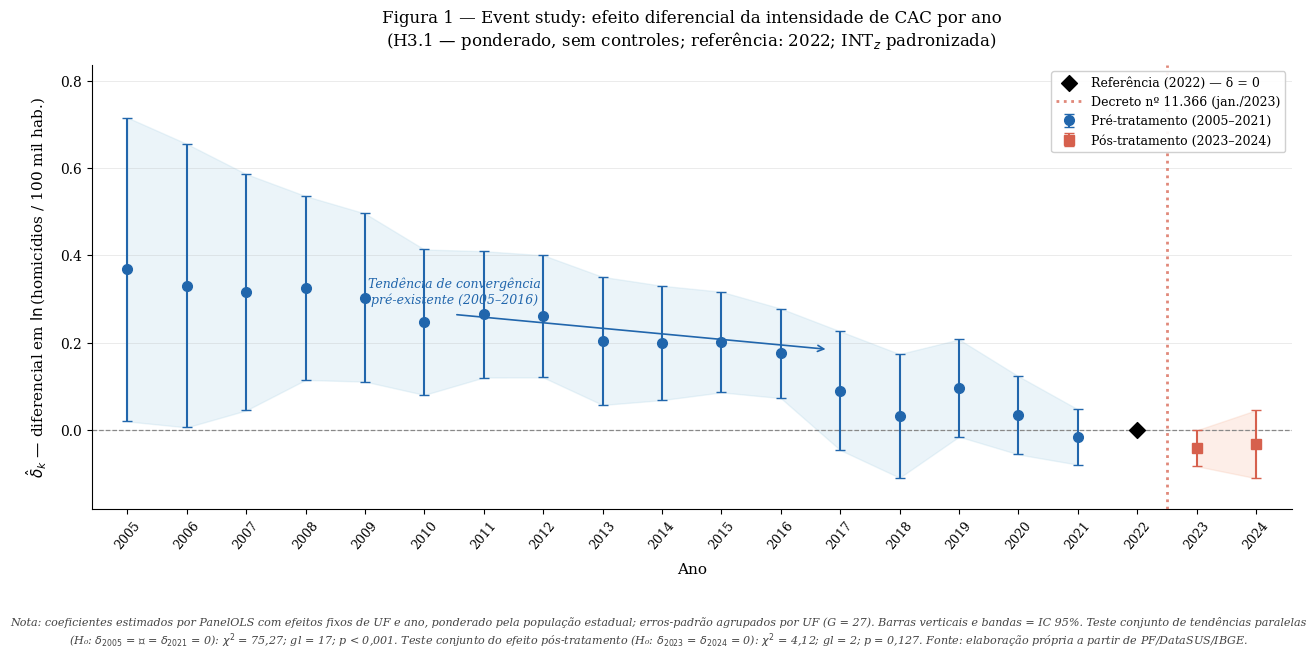


EXPORTAÇÃO CONCLUÍDA
PNG (300 dpi):  /content/resultados_artigo/figuras/figura1_event_study.png
PDF (vetorial): /content/resultados_artigo/figuras/figura1_event_study.pdf

Célula 7.1 concluída com sucesso.


In [19]:
# ============================================================
# CÉLULA 7.1 — FIGURA 1: GRÁFICO DO EVENT STUDY (H3)
# ============================================================
#
# Objetivos:
#
# 1. Extrair os coeficientes δ_k e respectivos IC 95% do
#    resultado H3.1 (event study ponderado, sem controles);
# 2. Gerar o gráfico de coeficientes (event-study plot) no
#    padrão acadêmico, com anotações e nota de rodapé;
# 3. Exportar em PNG (alta resolução) e PDF para inserção
#    no artigo.
#
# Depende da Célula 6.1 (resultado_h3_1 já estimado).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path


# ============================================================
# 1. VERIFICAÇÃO DO OBJETO NECESSÁRIO
# ============================================================

if "resultado_h3_1" not in globals():
    raise NameError(
        "O objeto 'resultado_h3_1' não foi encontrado. "
        "Execute a Célula 6.1 (H3 — event study) antes "
        "de rodar esta célula."
    )

print("=" * 80)
print("CÉLULA 7.1 — FIGURA 1: EVENT STUDY")
print("=" * 80)
print("Modelo de origem: H3.1 — ponderado, sem controles econômicos")
print("Ano de referência: 2022 (δ = 0 por construção)")


# ============================================================
# 2. EXTRAÇÃO DOS COEFICIENTES E INTERVALOS DE CONFIANÇA
# ============================================================

ANO_REFERENCIA = 2022

params    = resultado_h3_1.params
ic        = resultado_h3_1.conf_int()
pvalues   = resultado_h3_1.pvalues

# Monta DataFrame com todos os anos do painel (incluindo referência)
anos_es = sorted([
    int(col.replace("es_", ""))
    for col in params.index
    if col.startswith("es_")
])

# Adiciona o ano de referência com valores zero
registros = []
for ano in anos_es:
    col = f"es_{ano}"
    registros.append({
        "ano":     ano,
        "coef":    float(params[col]),
        "ic_inf":  float(ic.loc[col].iloc[0]),
        "ic_sup":  float(ic.loc[col].iloc[1]),
        "pvalor":  float(pvalues[col]),
        "periodo": (
            "Pré-tratamento"  if ano < ANO_REFERENCIA else
            "Pós-tratamento"  if ano > ANO_REFERENCIA else
            "Referência"
        )
    })

# Insere o ano de referência (coeficiente = 0, IC = 0)
registros.append({
    "ano":     ANO_REFERENCIA,
    "coef":    0.0,
    "ic_inf":  0.0,
    "ic_sup":  0.0,
    "pvalor":  np.nan,
    "periodo": "Referência"
})

df_plot = (
    pd.DataFrame(registros)
    .sort_values("ano")
    .reset_index(drop=True)
)

anos_todos = df_plot["ano"].tolist()
n_pre  = (df_plot["periodo"] == "Pré-tratamento").sum()
n_pos  = (df_plot["periodo"] == "Pós-tratamento").sum()

print(f"\nAnos no gráfico:    {len(anos_todos)} ({min(anos_todos)}–{max(anos_todos)})")
print(f"Pré-tratamento:     {n_pre} anos (2005–2021)")
print(f"Pós-tratamento:     {n_pos} anos (2023–2024)")
print(f"Referência:         2022 (omitida — δ fixado em 0)")

print("\nCoeficientes e IC 95%:")
print(df_plot[["ano","coef","ic_inf","ic_sup","pvalor","periodo"]].to_string(index=False))


# ============================================================
# 3. PALETA E CONFIGURAÇÕES VISUAIS
# ============================================================

COR_PRE     = "#2166AC"   # azul — pré-tratamento
COR_POS     = "#D6604D"   # vermelho-terracota — pós-tratamento
COR_REF     = "#000000"   # preto — referência
COR_IC_PRE  = "#92C5DE"   # azul claro — banda IC pré
COR_IC_POS  = "#F4A582"   # laranja claro — banda IC pós
COR_ZERO    = "#888888"   # cinza — linha zero
COR_DECRETO = "#D6604D"   # vermelho — linha vertical decreto

TAMANHO_PONTO  = 7
TAMANHO_REF    = 8
LARGURA_BARRA  = 1.5
LARGURA_LINHA  = 0.9
ALPHA_BANDA    = 0.18

plt.rcParams.update({
    "font.family":     "serif",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})


# ============================================================
# 4. CONSTRUÇÃO DO GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6))

# ── Máscaras de período ───────────────────────────────────
mask_pre = df_plot["periodo"] == "Pré-tratamento"
mask_pos = df_plot["periodo"] == "Pós-tratamento"
mask_ref = df_plot["periodo"] == "Referência"

df_pre = df_plot[mask_pre]
df_pos = df_plot[mask_pos]
df_ref = df_plot[mask_ref]


# ── Bandas de confiança (fill_between) ───────────────────

# Pré-tratamento
ax.fill_between(
    df_pre["ano"],
    df_pre["ic_inf"],
    df_pre["ic_sup"],
    alpha=ALPHA_BANDA,
    color=COR_IC_PRE,
    zorder=1
)

# Pós-tratamento
ax.fill_between(
    df_pos["ano"],
    df_pos["ic_inf"],
    df_pos["ic_sup"],
    alpha=ALPHA_BANDA,
    color=COR_IC_POS,
    zorder=1
)


# ── Barras de erro e pontos — pré-tratamento ─────────────
ax.errorbar(
    df_pre["ano"],
    df_pre["coef"],
    yerr=[
        df_pre["coef"] - df_pre["ic_inf"],
        df_pre["ic_sup"] - df_pre["coef"]
    ],
    fmt="o",
    color=COR_PRE,
    ecolor=COR_PRE,
    elinewidth=LARGURA_BARRA,
    capsize=3.5,
    markersize=TAMANHO_PONTO,
    zorder=4,
    label="Pré-tratamento (2005–2021)"
)


# ── Barras de erro e pontos — pós-tratamento ─────────────
ax.errorbar(
    df_pos["ano"],
    df_pos["coef"],
    yerr=[
        df_pos["coef"] - df_pos["ic_inf"],
        df_pos["ic_sup"] - df_pos["coef"]
    ],
    fmt="s",
    color=COR_POS,
    ecolor=COR_POS,
    elinewidth=LARGURA_BARRA,
    capsize=3.5,
    markersize=TAMANHO_PONTO,
    zorder=4,
    label="Pós-tratamento (2023–2024)"
)


# ── Ponto de referência (2022) ────────────────────────────
ax.scatter(
    df_ref["ano"],
    df_ref["coef"],
    color=COR_REF,
    marker="D",
    s=65,
    zorder=5,
    label=f"Referência ({ANO_REFERENCIA}) — δ = 0"
)


# ── Linhas de referência ──────────────────────────────────
ax.axhline(
    0,
    color=COR_ZERO,
    linestyle="--",
    linewidth=LARGURA_LINHA,
    zorder=2
)

ax.axvline(
    ANO_REFERENCIA + 0.5,
    color=COR_DECRETO,
    linestyle=":",
    linewidth=2.0,
    alpha=0.75,
    zorder=3,
    label="Decreto nº 11.366 (jan./2023)"
)


# ── Anotação: tendência de convergência ──────────────────
ax.annotate(
    "Tendência de convergência\npré-existente (2005–2016)",
    xy=(2010.5, 0.29),
    fontsize=9,
    color=COR_PRE,
    ha="center",
    fontstyle="italic"
)
ax.annotate(
    "",
    xy=(2016.8, 0.185),
    xytext=(2010.5, 0.265),
    arrowprops=dict(
        arrowstyle="->",
        color=COR_PRE,
        lw=1.2
    )
)


# ── Eixos e formatação ────────────────────────────────────
ax.set_xlabel("Ano", labelpad=8)
ax.set_ylabel(
    r"$\hat{\delta}_k$ — diferencial em $\ln$(homicídios / 100 mil hab.)",
    labelpad=8
)
ax.set_title(
    "Figura 1 — Event study: efeito diferencial da intensidade de CAC por ano\n"
    r"(H3.1 — ponderado, sem controles; referência: 2022; INT$_z$ padronizada)",
    pad=14
)

ax.set_xticks(anos_todos)
ax.tick_params(axis="x", rotation=50, labelsize=9)
ax.set_xlim(min(anos_todos) - 0.6, max(anos_todos) + 0.6)

# Margem vertical com folga para anotações
y_min = df_plot["ic_inf"].min() - 0.07
y_max = df_plot["ic_sup"].max() + 0.12
ax.set_ylim(y_min, y_max)

ax.grid(axis="y", alpha=0.25, linewidth=0.7)


# ── Legenda ───────────────────────────────────────────────
handles_legend, labels_legend = ax.get_legend_handles_labels()
ax.legend(
    handles_legend,
    labels_legend,
    loc="upper right",
    fontsize=9,
    framealpha=0.92,
    edgecolor="#CCCCCC"
)


# ── Nota de rodapé ────────────────────────────────────────
nota = (
    "Nota: coeficientes estimados por PanelOLS com efeitos fixos de UF e ano, "
    "ponderado pela população estadual; erros-padrão agrupados por UF (G = 27). "
    "Barras verticais e bandas = IC 95%. "
    "Teste conjunto de tendências paralelas "
    r"(H₀: $\delta_{2005}$ = ⋯ = $\delta_{2021}$ = 0): "
    r"$\chi^2$ = 75,27; gl = 17; p < 0,001. "
    "Teste conjunto do efeito pós-tratamento "
    r"(H₀: $\delta_{2023}$ = $\delta_{2024}$ = 0): "
    r"$\chi^2$ = 4,12; gl = 2; p = 0,127. "
    "Fonte: elaboração própria a partir de PF/DataSUS/IBGE."
)

fig.text(
    0.5, -0.08,
    nota,
    ha="center",
    fontsize=8,
    color="#444444",
    wrap=True,
    style="italic"
)

plt.tight_layout(rect=[0, 0.0, 1, 1])


# ============================================================
# 5. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

PASTA_FIGURAS = PASTA_TABELAS.parent / "figuras"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

caminho_png = PASTA_FIGURAS / "figura1_event_study.png"
caminho_pdf = PASTA_FIGURAS / "figura1_event_study.pdf"

fig.savefig(
    caminho_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    caminho_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\n" + "=" * 80)
print("EXPORTAÇÃO CONCLUÍDA")
print("=" * 80)
print(f"PNG (300 dpi):  {caminho_png}")
print(f"PDF (vetorial): {caminho_pdf}")
print("\nCélula 7.1 concluída com sucesso.")

# estatisticas descritivas

In [20]:
# ============================================================
# CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS
# ============================================================
#
# Produz:
# 1. Tabela de descritivas transposta: estatísticas nas
#    LINHAS, variáveis nas COLUNAS — formato:
#    Statistic | Var1 | Var2 | ...
# 2. Ranking de intensidade de CAC por UF em 2022 com grupos;
# 3. Matriz de correlação de Spearman com ρ e p-valor
#    em tabelas separadas (sem interpretação automática).
#
# Gráficos: Célula 2.2.
# Depende da Célula 1.2 (df já carregado).

import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path


# ============================================================
# 1. PREPARAÇÃO DA BASE
# ============================================================

if "df" not in globals():
    raise NameError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute a Célula 1.2 antes desta."
    )

print("=" * 100)
print("CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS")
print("=" * 100)

base_desc = df.copy()

if "uf" in base_desc.index.names or "ano" in base_desc.index.names:
    base_desc = base_desc.reset_index()

base_desc["uf"]  = base_desc["uf"].astype(str).str.strip().str.upper()
base_desc["ano"] = pd.to_numeric(base_desc["ano"], errors="coerce").astype(int)

for col in ["hom100", "crs100", "pibpc", "ln_pibpc", "desemp", "pop", "int_i"]:
    base_desc[col] = pd.to_numeric(base_desc[col], errors="coerce")

if "ln_hom100" not in base_desc.columns:
    base_desc["ln_hom100"] = np.log(base_desc["hom100"])
else:
    base_desc["ln_hom100"] = pd.to_numeric(
        base_desc["ln_hom100"], errors="coerce"
    )

N_OBS  = len(base_desc)
N_UFS  = base_desc["uf"].nunique()
N_ANOS = base_desc["ano"].nunique()

print(
    f"\nPainel: {N_OBS} observações | {N_UFS} UFs | "
    f"{N_ANOS} anos ({base_desc['ano'].min()}–{base_desc['ano'].max()})"
)


# ============================================================
# 2. TABELA DE DESCRITIVAS
#    Estatísticas nas LINHAS — Variáveis nas COLUNAS
# ============================================================

# Variáveis e seus rótulos de coluna
VARS_DESC = {
    "hom100":    "Homicídios\n/100 mil hab.",
    "ln_hom100": "ln(Homicídios\n/100 mil hab.)",
    "crs100":    "CRs CAC\n/100 mil hab.",
    "pibpc":     "PIB per capita\n(R$ correntes)",
    "ln_pibpc":  "ln(PIB\nper capita)",
    "desemp":    "Desemprego\n(%)",
    "pop":       "População\n(hab.)",
}

def calcular_descritivas(serie):
    """Retorna dicionário com todas as estatísticas."""
    s = serie.dropna()
    jb_stat, jb_p = stats.jarque_bera(s)
    return {
        "N":                   int(s.count()),
        "Média":               s.mean(),
        "Erro padrão":         s.sem(),
        "Mediana":             s.median(),
        "Desvio-padrão":       s.std(ddof=1),
        "Coef. de variação (%)": s.std(ddof=1) / abs(s.mean()) * 100,
        "Amplitude":           s.max() - s.min(),
        "Mínimo":              s.min(),
        "Máximo":              s.max(),
        "Assimetria":          float(s.skew()),
        "Curtose":             float(s.kurt()),
        "Jarque-Bera (stat)":  jb_stat,
        "Jarque-Bera (p-valor)": jb_p,
    }

# Monta o dicionário com uma coluna por variável
colunas_desc = {}
for var, rotulo in VARS_DESC.items():
    colunas_desc[rotulo] = calcular_descritivas(base_desc[var])

tabela_descritivas = pd.DataFrame(colunas_desc)
tabela_descritivas.index.name = "Estatística"

print("\n" + "=" * 100)
print("TABELA — ESTATÍSTICAS DESCRITIVAS DO PAINEL (2005–2024)")
print("=" * 100)

# Formatos por linha
fmt_inteiro = {"N"}
fmt_pct     = {"Coef. de variação (%)"}
fmt_pvalor  = {"Jarque-Bera (p-valor)"}
fmt_padrao  = set(tabela_descritivas.index) - fmt_inteiro - fmt_pct - fmt_pvalor

def formatar_valor(val, stat_name):
    if pd.isna(val):
        return "—"
    if stat_name in fmt_inteiro:
        return f"{int(val):,}"
    if stat_name in fmt_pct:
        return f"{val:.1f}%"
    if stat_name in fmt_pvalor:
        if val < 0.001:
            return "< 0,001"
        return f"{val:.4f}"
    if abs(val) >= 1_000:
        return f"{val:,.2f}"
    return f"{val:.3f}"

# Exibe linha por linha para aplicar formatação por estatística
tabela_display = tabela_descritivas.copy().astype(object)
for stat in tabela_display.index:
    for col in tabela_display.columns:
        tabela_display.loc[stat, col] = formatar_valor(
            tabela_descritivas.loc[stat, col], stat
        )

display(tabela_display)


# ============================================================
# 3. INTENSIDADE DE CAC POR UF EM 2022
# ============================================================

int_2022 = (
    base_desc
    .loc[base_desc["ano"] == 2022, ["uf", "int_i"]]
    .dropna(subset=["int_i"])
    .drop_duplicates(subset="uf")
    .copy()
    .reset_index(drop=True)
)

if int_2022["uf"].nunique() != 27:
    print(
        f"\n⚠️  {int_2022['uf'].nunique()} UFs encontradas "
        "(esperado: 27)."
    )

media_int   = int_2022["int_i"].mean()
desvio_int  = int_2022["int_i"].std(ddof=1)
mediana_int = int_2022["int_i"].median()

int_2022["grupo"] = pd.cut(
    int_2022["int_i"],
    bins=[
        -np.inf,
        media_int - 0.5 * desvio_int,
        media_int + 0.5 * desvio_int,
        np.inf
    ],
    labels=["Baixa", "Média", "Alta"]
)

print("\n" + "=" * 100)
print("INTENSIDADE DE CAC POR UF EM 2022 (CRs / 100 mil hab.)")
print("=" * 100)
print(f"  Média:         {media_int:.2f}")
print(f"  Mediana:       {mediana_int:.2f}")
print(f"  Desvio-padrão: {desvio_int:.2f}")
print(
    f"  Mínimo:        {int_2022['int_i'].min():.2f}  "
    f"({int_2022.loc[int_2022['int_i'].idxmin(), 'uf']})"
)
print(
    f"  Máximo:        {int_2022['int_i'].max():.2f}  "
    f"({int_2022.loc[int_2022['int_i'].idxmax(), 'uf']})"
)

print("\nRanking completo (decrescente):")
display(
    int_2022
    .sort_values("int_i", ascending=False)
    .rename(columns={
        "uf":    "UF",
        "int_i": "CRs / 100 mil hab.",
        "grupo": "Grupo"
    })
    .reset_index(drop=True)
    .style.format({"CRs / 100 mil hab.": "{:.2f}"})
)

print("\nResumo por grupo:")
display(
    int_2022
    .groupby("grupo", observed=False)
    .agg(
        N    = ("uf",    "count"),
        Mín  = ("int_i", "min"),
        Méd  = ("int_i", "mean"),
        Máx  = ("int_i", "max"),
        UFs  = ("uf",    lambda x: ", ".join(sorted(x)))
    )
    .rename_axis("Grupo")
    .style.format({"Mín": "{:.2f}", "Méd": "{:.2f}", "Máx": "{:.2f}"})
)

# Merge do grupo na base completa — explícito e seguro
base_desc = (
    base_desc
    .drop(columns=["grupo_intensidade"], errors="ignore")
    .merge(
        int_2022[["uf", "grupo"]].rename(
            columns={"grupo": "grupo_intensidade"}
        ),
        on="uf",
        how="left"
    )
)

# Disponibiliza objetos para a Célula 2.2
globals()["base_desc"]   = base_desc
globals()["int_2022"]    = int_2022
globals()["media_int"]   = media_int
globals()["mediana_int"] = mediana_int


# ============================================================
# 4. CORRELAÇÃO DE SPEARMAN
#    Tabela de ρ e tabela de p-valores separadas
# ============================================================

VARS_CORR = {
    "hom100":    "Homicídios",
    "crs100":    "CRs CAC",
    "pibpc":     "PIB per capita",
    "ln_pibpc":  "ln(PIB per capita)",
    "desemp":    "Desemprego",
}

nomes = list(VARS_CORR.values())
vars_ = list(VARS_CORR.keys())
n_v   = len(vars_)

mat_rho = np.full((n_v, n_v), np.nan)
mat_p   = np.full((n_v, n_v), np.nan)

for i, vi in enumerate(vars_):
    for j, vj in enumerate(vars_):
        if i == j:
            mat_rho[i, j] = 1.0
        else:
            dados = base_desc[[vi, vj]].dropna()
            rho, p = stats.spearmanr(dados[vi], dados[vj])
            mat_rho[i, j] = rho
            mat_p[i, j]   = p

df_rho = pd.DataFrame(mat_rho, index=nomes, columns=nomes)
df_p   = pd.DataFrame(mat_p,   index=nomes, columns=nomes)

print("\n" + "=" * 100)
print("CORRELAÇÃO DE SPEARMAN — ρ")
print("=" * 100)
display(
    df_rho.style.format(
        lambda v: "1,000" if v == 1.0 else f"{v:.3f}"
    ).background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)
)

print("\n" + "=" * 100)
print("CORRELAÇÃO DE SPEARMAN — p-valor")
print("=" * 100)
display(
    df_p.style.format(
        lambda v: "—" if np.isnan(v) else (
            "< 0,001" if v < 0.001 else f"{v:.4f}"
        )
    )
)


# ============================================================
# 5. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_desc = PASTA_TABELAS / "estatisticas_descritivas.xlsx"

with pd.ExcelWriter(arquivo_desc, engine="openpyxl") as writer:

    tabela_descritivas.to_excel(
        writer, sheet_name="Descritivas"
    )
    int_2022.sort_values(
        "int_i", ascending=False
    ).to_excel(
        writer, sheet_name="Intensidade_2022", index=False
    )
    df_rho.to_excel(writer, sheet_name="Spearman_rho")
    df_p.to_excel(writer, sheet_name="Spearman_pvalor")

print("\n" + "=" * 100)
print("OBJETOS DISPONÍVEIS PARA CÉLULA 2.2")
print("=" * 100)
print("• base_desc      — painel completo com 'grupo_intensidade'")
print("• int_2022       — intensidade por UF com 'grupo'")
print("• media_int      — média de int_i em 2022")
print("• mediana_int    — mediana de int_i em 2022")

print(f"\nArquivo Excel: {arquivo_desc}")
print("\nCélula 2.1 concluída com sucesso.")

CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS

Painel: 540 observações | 27 UFs | 20 anos (2005–2024)

TABELA — ESTATÍSTICAS DESCRITIVAS DO PAINEL (2005–2024)


,Homicídios\n/100 mil hab.,ln(Homicídios\n/100 mil hab.),CRs CAC\n/100 mil hab.,PIB per capita\n(R$ correntes),ln(PIB\nper capita),Desemprego\n(%),População\n(hab.)
Estatística,,,,,,,
N,540,540,540,540,540,540,540
Média,20.769,2.880,21.020,"25,453.19",9.928,9.680,"7,402,821.44"
Erro padrão,0.476,0.025,2.387,786.045,0.028,0.148,"373,387.60"
Mediana,18.950,2.942,1.420,"20,046.00",9.906,9.225,"3,899,735.00"
Desvio-padrão,11.054,0.583,55.469,"18,266.03",0.661,3.429,"8,676,743.77"
Coef. de variação (%),53.2%,20.2%,263.9%,71.8%,6.7%,35.4%,117.2%
Amplitude,58.490,2.980,412.660,"132,448.00",3.605,17.500,"46,257,815.00"
Mínimo,3.130,1.141,0.000,"3,701.00",8.216,2.900,"391,317.00"
Máximo,61.620,4.121,412.660,"136,149.00",11.822,20.400,"46,649,132.00"



INTENSIDADE DE CAC POR UF EM 2022 (CRs / 100 mil hab.)
  Média:         172.66
  Mediana:       93.39
  Desvio-padrão: 126.61
  Mínimo:        43.59  (PI)
  Máximo:        412.66  (GO)

Ranking completo (decrescente):


,UF,CRs / 100 mil hab.,Grupo
0,GO,412.66,Alta
1,DF,385.50,Alta
2,SC,371.17,Alta
3,MT,362.76,Alta
4,RO,351.00,Alta
5,PR,339.47,Alta
6,MS,325.68,Alta
7,RS,273.31,Alta
8,TO,202.19,Média
9,SP,190.76,Média



Resumo por grupo:


...


CORRELAÇÃO DE SPEARMAN — ρ


,Homicídios,CRs CAC,PIB per capita,ln(PIB per capita),Desemprego
Homicídios,"1,000",-0.051,-0.154,-0.154,0.374
CRs CAC,-0.051,"1,000",0.661,0.661,0.164
PIB per capita,-0.154,0.661,"1,000",1.000,-0.093
ln(PIB per capita),-0.154,0.661,1.000,"1,000",-0.093
Desemprego,0.374,0.164,-0.093,-0.093,"1,000"



CORRELAÇÃO DE SPEARMAN — p-valor


,Homicídios,CRs CAC,PIB per capita,ln(PIB per capita),Desemprego
Homicídios,—,0.2404,"< 0,001","< 0,001","< 0,001"
CRs CAC,0.2404,—,"< 0,001","< 0,001","< 0,001"
PIB per capita,"< 0,001","< 0,001",—,"< 0,001",0.0312
ln(PIB per capita),"< 0,001","< 0,001","< 0,001",—,0.0312
Desemprego,"< 0,001","< 0,001",0.0312,0.0312,—



OBJETOS DISPONÍVEIS PARA CÉLULA 2.2
• base_desc      — painel completo com 'grupo_intensidade'
• int_2022       — intensidade por UF com 'grupo'
• media_int      — média de int_i em 2022
• mediana_int    — mediana de int_i em 2022

Arquivo Excel: /content/resultados_artigo/tabelas/estatisticas_descritivas.xlsx

Célula 2.1 concluída com sucesso.


In [21]:
# ============================================================
# CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS
# ============================================================
#
# Produz:
# 1. Tabela de descritivas transposta (variáveis nas linhas,
#    estatísticas nas colunas);
# 2. Ranking de intensidade de CAC por UF em 2022 com grupos;
# 3. Correlação de Spearman entre variáveis principais,
#    com p-valores na mesma tabela;
# 4. Exportação em Excel.
#
# Gráficos exploratórios: Célula 2.2 (separada).
# Depende da Célula 1.2 (df já carregado).

import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path


# ============================================================
# 1. PREPARAÇÃO DA BASE
# ============================================================

if "df" not in globals():
    raise NameError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute a Célula 1.2 antes desta."
    )

print("=" * 100)
print("CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS")
print("=" * 100)

base_desc = df.copy()

if "uf" in base_desc.index.names or "ano" in base_desc.index.names:
    base_desc = base_desc.reset_index()

base_desc["uf"]  = base_desc["uf"].astype(str).str.strip().str.upper()
base_desc["ano"] = pd.to_numeric(base_desc["ano"], errors="coerce").astype(int)

for col in ["hom100", "crs100", "pibpc", "desemp", "pop", "int_i"]:
    base_desc[col] = pd.to_numeric(base_desc[col], errors="coerce")

if "ln_hom100" not in base_desc.columns:
    base_desc["ln_hom100"] = np.log(base_desc["hom100"])
else:
    base_desc["ln_hom100"] = pd.to_numeric(
        base_desc["ln_hom100"], errors="coerce"
    )

N_OBS  = len(base_desc)
N_UFS  = base_desc["uf"].nunique()
N_ANOS = base_desc["ano"].nunique()

print(
    f"\nPainel: {N_OBS} observações | {N_UFS} UFs | {N_ANOS} anos "
    f"({base_desc['ano'].min()}–{base_desc['ano'].max()})"
)


# ============================================================
# 2. TABELA DE DESCRITIVAS — TRANSPOSTA
# ============================================================

# Variáveis e rótulos para as LINHAS da tabela transposta
VARS_DESC = {
    "hom100":    "Homicídios / 100 mil hab.",
    "ln_hom100": "ln(homicídios / 100 mil hab.)",
    "crs100":    "CRs CAC / 100 mil hab.",
    "pibpc":     "PIB per capita (R$ correntes)",
    "desemp":    "Taxa de desemprego (%)",
    "pop":       "População residente (hab.)",
}

linhas = []
for var, rotulo in VARS_DESC.items():
    s = base_desc[var].dropna()
    linhas.append({
        "Variável":       rotulo,
        "N":              int(s.count()),
        "Média":          s.mean(),
        "Mediana":        s.median(),
        "Desvio-padrão":  s.std(ddof=1),
        "CV (%)":         s.std(ddof=1) / abs(s.mean()) * 100,
        "Mínimo":         s.min(),
        "Máximo":         s.max(),
    })

tabela_descritivas = pd.DataFrame(linhas).set_index("Variável")

print("\n" + "=" * 100)
print("TABELA 1 — ESTATÍSTICAS DESCRITIVAS DO PAINEL (2005–2024)")
print("=" * 100)

display(
    tabela_descritivas.style.format({
        "N":             "{:.0f}",
        "Média":         "{:,.3f}",
        "Mediana":       "{:,.3f}",
        "Desvio-padrão": "{:,.3f}",
        "CV (%)":        "{:.1f}%",
        "Mínimo":        "{:,.3f}",
        "Máximo":        "{:,.3f}",
    })
)


# ============================================================
# 3. INTENSIDADE DE CAC POR UF EM 2022
# ============================================================

# Extrai corretamente da base (sem depender de merge)
int_2022 = (
    base_desc
    .loc[base_desc["ano"] == 2022, ["uf", "int_i"]]
    .dropna(subset=["int_i"])
    .drop_duplicates(subset="uf")
    .copy()
    .reset_index(drop=True)
)

if int_2022["uf"].nunique() != 27:
    print(
        f"\n⚠️  Atenção: {int_2022['uf'].nunique()} UFs encontradas "
        f"(esperado: 27)."
    )

media_int   = int_2022["int_i"].mean()
desvio_int  = int_2022["int_i"].std(ddof=1)
mediana_int = int_2022["int_i"].median()

# Grupos por ±0,5 DP em torno da média
int_2022["grupo"] = pd.cut(
    int_2022["int_i"],
    bins=[
        -np.inf,
        media_int - 0.5 * desvio_int,
        media_int + 0.5 * desvio_int,
        np.inf
    ],
    labels=["Baixa", "Média", "Alta"]
)

print("\n" + "=" * 100)
print("INTENSIDADE DE CAC POR UF EM 2022 (CRs / 100 mil hab.)")
print("=" * 100)
print(f"  Média:         {media_int:.2f}")
print(f"  Mediana:       {mediana_int:.2f}")
print(f"  Desvio-padrão: {desvio_int:.2f}")
print(f"  Mínimo:        {int_2022['int_i'].min():.2f}  "
      f"({int_2022.loc[int_2022['int_i'].idxmin(), 'uf']})")
print(f"  Máximo:        {int_2022['int_i'].max():.2f}  "
      f"({int_2022.loc[int_2022['int_i'].idxmax(), 'uf']})")

print("\nRanking completo (decrescente):")
display(
    int_2022
    .sort_values("int_i", ascending=False)
    .rename(columns={
        "uf":    "UF",
        "int_i": "CRs / 100 mil hab.",
        "grupo": "Grupo de intensidade"
    })
    .reset_index(drop=True)
    .style.format({"CRs / 100 mil hab.": "{:.2f}"})
)

print("\nResumo por grupo de intensidade:")
display(
    int_2022
    .groupby("grupo", observed=False)
    .agg(
        N_UFs  = ("uf",    "count"),
        Mínimo = ("int_i", "min"),
        Média  = ("int_i", "mean"),
        Máximo = ("int_i", "max"),
        UFs    = ("uf",    lambda x: ", ".join(sorted(x)))
    )
    .rename_axis("Grupo")
    .style.format({
        "Mínimo": "{:.2f}",
        "Média":  "{:.2f}",
        "Máximo": "{:.2f}",
    })
)

# Disponibiliza o grupo na base completa para a Célula 2.2
# (merge explícito, sem risco de KeyError)
base_desc = base_desc.drop(
    columns=["grupo_intensidade"],
    errors="ignore"
).merge(
    int_2022[["uf", "grupo"]].rename(columns={"grupo": "grupo_intensidade"}),
    on="uf",
    how="left"
)

# Expõe no namespace global para a Célula 2.2
globals()["int_2022"]   = int_2022
globals()["base_desc"]  = base_desc
globals()["media_int"]  = media_int
globals()["mediana_int"] = mediana_int


# ============================================================
# 4. CORRELAÇÃO DE SPEARMAN COM P-VALORES
# ============================================================

VARS_CORR = {
    "hom100": "Homicídios",
    "crs100": "CRs CAC",
    "pibpc":  "PIB pc",
    "desemp": "Desemprego",
}

nomes = list(VARS_CORR.values())
vars_ = list(VARS_CORR.keys())
n_vars = len(vars_)

# Calcula Spearman par a par
mat_rho = np.zeros((n_vars, n_vars))
mat_p   = np.zeros((n_vars, n_vars))

for i, vi in enumerate(vars_):
    for j, vj in enumerate(vars_):
        if i == j:
            mat_rho[i, j] = 1.0
            mat_p[i, j]   = np.nan
        else:
            dados = base_desc[[vi, vj]].dropna()
            rho, p = stats.spearmanr(dados[vi], dados[vj])
            mat_rho[i, j] = rho
            mat_p[i, j]   = p

df_rho = pd.DataFrame(mat_rho, index=nomes, columns=nomes)
df_p   = pd.DataFrame(mat_p,   index=nomes, columns=nomes)

# Tabela combinada: rho (p-valor) em cada célula
def formatar_celula(rho, p):
    if np.isnan(p):
        return "1,000"
    sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    return f"{rho:.3f}{sig}\n(p={p:.3f})"

linhas_corr = []
for i, nome_i in enumerate(nomes):
    linha = {"Variável": nome_i}
    for j, nome_j in enumerate(nomes):
        linha[nome_j] = formatar_celula(mat_rho[i, j], mat_p[i, j])
    linhas_corr.append(linha)

tabela_corr = pd.DataFrame(linhas_corr).set_index("Variável")

print("\n" + "=" * 100)
print("CORRELAÇÃO DE SPEARMAN — VARIÁVEIS PRINCIPAIS")
print("(*** p<0,01 | ** p<0,05 | * p<0,10)")
print("=" * 100)
display(tabela_corr)


# ============================================================
# 5. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_desc = PASTA_TABELAS / "estatisticas_descritivas.xlsx"

with pd.ExcelWriter(arquivo_desc, engine="openpyxl") as writer:

    tabela_descritivas.to_excel(
        writer, sheet_name="Descritivas"
    )
    int_2022.sort_values(
        "int_i", ascending=False
    ).to_excel(
        writer, sheet_name="Intensidade_2022", index=False
    )
    df_rho.to_excel(writer, sheet_name="Spearman_rho")
    df_p.to_excel(writer, sheet_name="Spearman_pvalor")

print("\n" + "=" * 100)
print("OBJETOS DISPONÍVEIS PARA CÉLULA 2.2")
print("=" * 100)
print("• base_desc   — painel completo com 'grupo_intensidade'")
print("• int_2022    — intensidade por UF com 'grupo'")
print("• media_int   — média de int_i em 2022")
print("• mediana_int — mediana de int_i em 2022")

print(f"\nArquivo Excel salvo em: {arquivo_desc}")
print("\nCélula 2.1 concluída com sucesso.")

CÉLULA 2.1 — ESTATÍSTICAS DESCRITIVAS

Painel: 540 observações | 27 UFs | 20 anos (2005–2024)

TABELA 1 — ESTATÍSTICAS DESCRITIVAS DO PAINEL (2005–2024)


,N,Média,Mediana,Desvio-padrão,CV (%),Mínimo,Máximo
Variável,,,,,,,
Homicídios / 100 mil hab.,540,20.769,18.950,11.054,53.2%,3.130,61.620
ln(homicídios / 100 mil hab.),540,2.880,2.942,0.583,20.2%,1.141,4.121
CRs CAC / 100 mil hab.,540,21.020,1.420,55.469,263.9%,0.000,412.660
PIB per capita (R$ correntes),540,"25,453.187","20,046.000","18,266.025",71.8%,"3,701.000","136,149.000"
Taxa de desemprego (%),540,9.680,9.225,3.429,35.4%,2.900,20.400
População residente (hab.),540,"7,402,821.441","3,899,735.000","8,676,743.769",117.2%,"391,317.000","46,649,132.000"



INTENSIDADE DE CAC POR UF EM 2022 (CRs / 100 mil hab.)
  Média:         172.66
  Mediana:       93.39
  Desvio-padrão: 126.61
  Mínimo:        43.59  (PI)
  Máximo:        412.66  (GO)

Ranking completo (decrescente):


,UF,CRs / 100 mil hab.,Grupo de intensidade
0,GO,412.66,Alta
1,DF,385.50,Alta
2,SC,371.17,Alta
3,MT,362.76,Alta
4,RO,351.00,Alta
5,PR,339.47,Alta
6,MS,325.68,Alta
7,RS,273.31,Alta
8,TO,202.19,Média
9,SP,190.76,Média



Resumo por grupo de intensidade:


,N_UFs,Mínimo,Média,Máximo,UFs
Grupo,,,,,
Baixa,15,43.59,77.17,101.61,"AC, AM, AP, BA, CE, ES, MA, PA, PB, PE, PI, RJ, RN, RR, SE"
Média,4,111.52,170.66,202.19,"AL, MG, SP, TO"
Alta,8,273.31,352.69,412.66,"DF, GO, MS, MT, PR, RO, RS, SC"



CORRELAÇÃO DE SPEARMAN — VARIÁVEIS PRINCIPAIS
(*** p<0,01 | ** p<0,05 | * p<0,10)


,Homicídios,CRs CAC,PIB pc,Desemprego
Variável,,,,
Homicídios,"1,000",-0.051\n(p=0.240),-0.154***\n(p=0.000),0.374***\n(p=0.000)
CRs CAC,-0.051\n(p=0.240),"1,000",0.661***\n(p=0.000),0.164***\n(p=0.000)
PIB pc,-0.154***\n(p=0.000),0.661***\n(p=0.000),"1,000",-0.093**\n(p=0.031)
Desemprego,0.374***\n(p=0.000),0.164***\n(p=0.000),-0.093**\n(p=0.031),"1,000"



OBJETOS DISPONÍVEIS PARA CÉLULA 2.2
• base_desc   — painel completo com 'grupo_intensidade'
• int_2022    — intensidade por UF com 'grupo'
• media_int   — média de int_i em 2022
• mediana_int — mediana de int_i em 2022

Arquivo Excel salvo em: /content/resultados_artigo/tabelas/estatisticas_descritivas.xlsx

Célula 2.1 concluída com sucesso.


CÉLULA 2.2 — GRÁFICOS EXPLORATÓRIOS


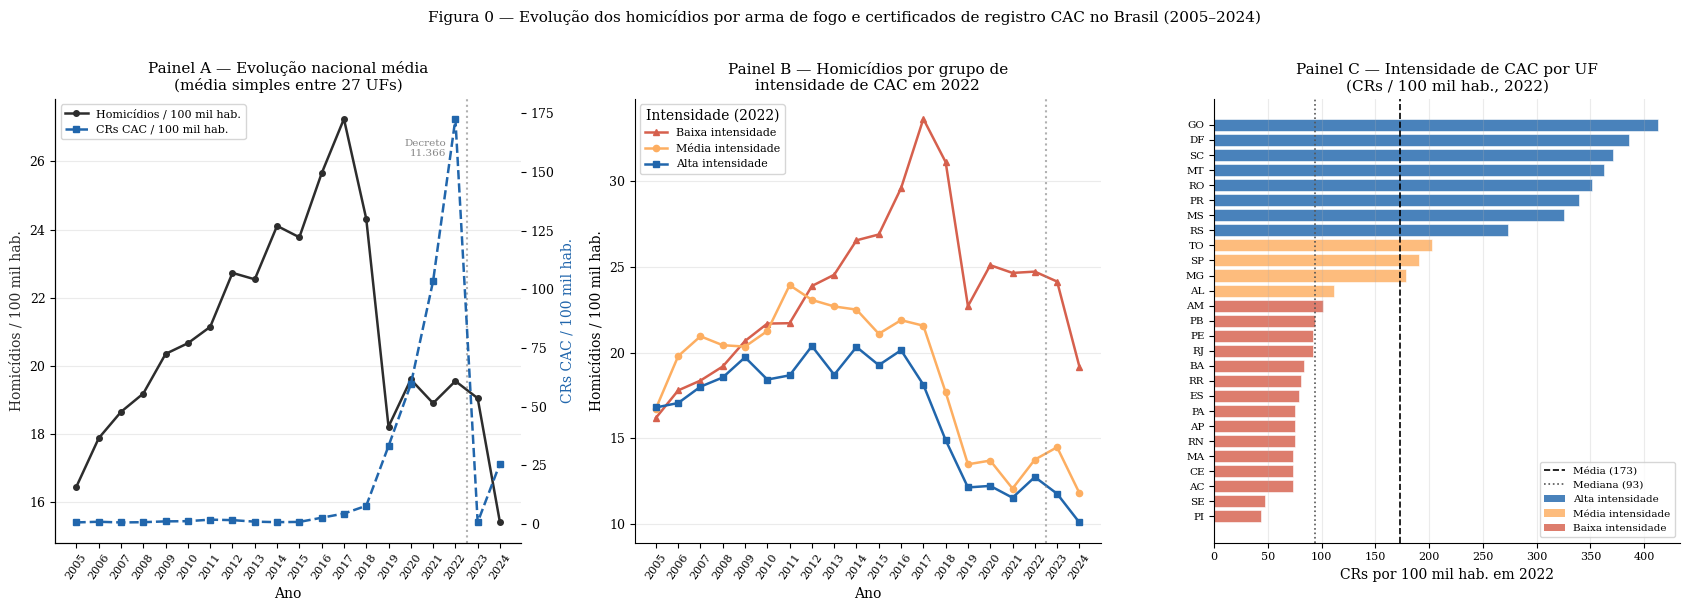


Figura PNG (300 dpi):  /content/resultados_artigo/figuras/figura_descritiva.png
Figura PDF (vetorial): /content/resultados_artigo/figuras/figura_descritiva.pdf

Célula 2.2 concluída com sucesso.


In [22]:
# ============================================================
# CÉLULA 2.2 — GRÁFICOS EXPLORATÓRIOS
# ============================================================
#
# Produz três painéis:
#   Painel A — Evolução nacional média de hom100 e crs100;
#   Painel B — Homicídios por grupo de intensidade de CAC;
#   Painel C — Distribuição da intensidade por UF em 2022.
#
# Depende da Célula 2.1 (base_desc, int_2022, media_int,
# mediana_int disponíveis no namespace).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path


# ============================================================
# 1. VERIFICAÇÃO DOS OBJETOS
# ============================================================

for obj in ["base_desc", "int_2022", "media_int", "mediana_int"]:
    if obj not in globals():
        raise NameError(
            f"O objeto '{obj}' não foi encontrado. "
            "Execute a Célula 2.1 antes desta."
        )

print("=" * 100)
print("CÉLULA 2.2 — GRÁFICOS EXPLORATÓRIOS")
print("=" * 100)


# ============================================================
# 2. DADOS PARA OS PAINÉIS
# ============================================================

evolucao = (
    base_desc
    .groupby("ano")[["hom100", "crs100"]]
    .mean()
    .reset_index()
)

anos_ticks = sorted(base_desc["ano"].unique().tolist())

grupos_por_ano = (
    base_desc
    .groupby(["grupo_intensidade", "ano"])["hom100"]
    .mean()
    .reset_index()
)

int_sorted = (
    int_2022
    .sort_values("int_i", ascending=True)
    .reset_index(drop=True)
)


# ============================================================
# 3. CONFIGURAÇÕES VISUAIS
# ============================================================

plt.rcParams.update({
    "font.family":     "serif",
    "font.size":       10,
    "axes.titlesize":  11,
    "axes.labelsize":  10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

COR_HOM     = "#2D2D2D"
COR_CRS     = "#2166AC"
COR_BAIXA   = "#D6604D"
COR_MEDIA   = "#FDAE61"
COR_ALTA    = "#2166AC"
COR_DECRETO = "#888888"
CORES_GRUPO = {"Baixa": COR_BAIXA, "Média": COR_MEDIA, "Alta": COR_ALTA}
MARCADORES  = {"Baixa": "^", "Média": "o", "Alta": "s"}


# ============================================================
# 4. FIGURA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    "Figura 0 — Evolução dos homicídios por arma de fogo e "
    "certificados de registro CAC no Brasil (2005–2024)",
    fontsize=11, y=1.01
)


# ── Painel A ─────────────────────────────────────────────
ax_a  = axes[0]
ax_a2 = ax_a.twinx()

l1, = ax_a.plot(
    evolucao["ano"], evolucao["hom100"],
    color=COR_HOM, marker="o", markersize=4,
    linewidth=1.8, label="Homicídios / 100 mil hab."
)
l2, = ax_a2.plot(
    evolucao["ano"], evolucao["crs100"],
    color=COR_CRS, marker="s", markersize=4,
    linewidth=1.8, linestyle="--",
    label="CRs CAC / 100 mil hab."
)

ax_a.axvline(
    2022.5, color=COR_DECRETO,
    linestyle=":", linewidth=1.5, alpha=0.65
)
ax_a.text(
    2021.6, evolucao["hom100"].max() * 0.96,
    "Decreto\n11.366", fontsize=7.5,
    color=COR_DECRETO, ha="right"
)

ax_a.set_xlabel("Ano")
ax_a.set_ylabel("Homicídios / 100 mil hab.", color=COR_HOM)
ax_a2.set_ylabel("CRs CAC / 100 mil hab.", color=COR_CRS)
ax_a.set_title(
    "Painel A — Evolução nacional média\n"
    "(média simples entre 27 UFs)"
)
ax_a.legend(
    [l1, l2], [l.get_label() for l in [l1, l2]],
    fontsize=8, loc="upper left"
)
ax_a.set_xticks(anos_ticks)
ax_a.tick_params(axis="x", rotation=55)
ax_a.grid(axis="y", alpha=0.25)


# ── Painel B ─────────────────────────────────────────────
ax_b = axes[1]

for grupo in ["Baixa", "Média", "Alta"]:
    serie = grupos_por_ano[
        grupos_por_ano["grupo_intensidade"] == grupo
    ].sort_values("ano")

    if serie.empty:
        continue

    ax_b.plot(
        serie["ano"], serie["hom100"],
        color=CORES_GRUPO[grupo],
        marker=MARCADORES[grupo],
        markersize=4.5,
        linewidth=1.8,
        label=f"{grupo} intensidade"
    )

ax_b.axvline(
    2022.5, color=COR_DECRETO,
    linestyle=":", linewidth=1.5, alpha=0.65
)
ax_b.set_xlabel("Ano")
ax_b.set_ylabel("Homicídios / 100 mil hab.")
ax_b.set_title(
    "Painel B — Homicídios por grupo de\n"
    "intensidade de CAC em 2022"
)
ax_b.legend(title="Intensidade (2022)", fontsize=8)
ax_b.set_xticks(anos_ticks)
ax_b.tick_params(axis="x", rotation=55)
ax_b.grid(axis="y", alpha=0.25)


# ── Painel C ─────────────────────────────────────────────
ax_c = axes[2]

cores_barras = [
    CORES_GRUPO.get(str(g), "#AAAAAA")
    for g in int_sorted["grupo"]
]

ax_c.barh(
    range(len(int_sorted)),
    int_sorted["int_i"],
    color=cores_barras,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.5
)
ax_c.set_yticks(range(len(int_sorted)))
ax_c.set_yticklabels(int_sorted["uf"], fontsize=7.5)

ax_c.axvline(
    media_int, color="black",
    linestyle="--", linewidth=1.2,
    label=f"Média ({media_int:.0f})"
)
ax_c.axvline(
    mediana_int, color="#555555",
    linestyle=":", linewidth=1.2,
    label=f"Mediana ({mediana_int:.0f})"
)

patches_grupo = [
    Patch(facecolor=COR_ALTA,  alpha=0.82, label="Alta intensidade"),
    Patch(facecolor=COR_MEDIA, alpha=0.82, label="Média intensidade"),
    Patch(facecolor=COR_BAIXA, alpha=0.82, label="Baixa intensidade"),
]
handles_ax, labels_ax = ax_c.get_legend_handles_labels()
ax_c.legend(
    handles_ax + patches_grupo,
    labels_ax  + [p.get_label() for p in patches_grupo],
    fontsize=7.5, loc="lower right"
)

ax_c.set_xlabel("CRs por 100 mil hab. em 2022")
ax_c.set_title(
    "Painel C — Intensidade de CAC por UF\n"
    "(CRs / 100 mil hab., 2022)"
)
ax_c.grid(axis="x", alpha=0.25)


plt.tight_layout()


# ============================================================
# 5. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

PASTA_FIGURAS = PASTA_TABELAS.parent / "figuras"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

caminho_png = PASTA_FIGURAS / "figura_descritiva.png"
caminho_pdf = PASTA_FIGURAS / "figura_descritiva.pdf"

fig.savefig(caminho_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(caminho_pdf, bbox_inches="tight", facecolor="white")

plt.show()

print(f"\nFigura PNG (300 dpi):  {caminho_png}")
print(f"Figura PDF (vetorial): {caminho_pdf}")
print("\nCélula 2.2 concluída com sucesso.")

In [23]:
# ============================================================
# CÉLULA 4.1 — DIAGNÓSTICO ADICIONAL: DRISCOLL-KRAAY
#              E TABELA CONSOLIDADA (Tabela 5 do artigo)
# ============================================================
#
# Objetivo:
#   Rodar os 3 testes já estimados na Célula 4.0 +
#   o teste de Driscoll-Kraay como diagnóstico de robustez
#   à dependência cross-sectional, e gerar a tabela final
#   consolidada com os 4 testes para inserção no artigo.
#
# O teste de Driscoll-Kraay aqui não é uma estatística
# de hipótese formal como os três anteriores — é uma
# comparação entre os erros-padrão clusterizados (usados
# no modelo principal) e os erros de Driscoll-Kraay
# (robustos à dependência cross-sectional e serial
# simultâneas). A comparação é reportada como diagnóstico:
# se os SE-DK forem maiores que os SE-clustered, a
# dependência cross-sectional está amplificando a
# imprecisão; se menores, a estrutura serial domina.
#
# Depende da Célula 4.0 (resultados_hausman,
# resultado_wooldridge, resultado_pesaran disponíveis),
# mas re-estima tudo do zero para garantir reprodutibilidade.

import numpy as np
import pandas as pd

from scipy import stats
from linearmodels.panel import (
    PanelOLS, RandomEffects, FirstDifferenceOLS
)


# ============================================================
# 1. SELEÇÃO DA BASE (idêntica à Célula 4.0)
# ============================================================

objetos_candidatos = [
    "painel_expandido", "painel_h2", "painel", "df"
]
bases_encontradas = []

for nome_objeto in objetos_candidatos:
    if nome_objeto not in globals():
        continue
    objeto = globals()[nome_objeto]
    if not isinstance(objeto, pd.DataFrame):
        continue
    teste = objeto.copy()
    if "uf" in teste.index.names or "ano" in teste.index.names:
        teste = teste.reset_index()
    if "uf" not in teste.columns or "ano" not in teste.columns:
        continue
    teste["ano"] = pd.to_numeric(teste["ano"], errors="coerce")
    bases_encontradas.append({
        "nome": nome_objeto,
        "ano_maximo": teste["ano"].max(),
        "numero_observacoes": len(teste)
    })

if not bases_encontradas:
    raise NameError("Nenhum DataFrame adequado encontrado.")

bases_encontradas = sorted(
    bases_encontradas,
    key=lambda item: (
        item["ano_maximo"] >= 2024,
        item["ano_maximo"],
        item["numero_observacoes"]
    ),
    reverse=True
)

nome_base = bases_encontradas[0]["nome"]
base_diag = globals()[nome_base].copy()

print("=" * 100)
print("CÉLULA 4.1 — DIAGNÓSTICO: DRISCOLL-KRAAY + TABELA CONSOLIDADA")
print("=" * 100)
print("Base:", nome_base)

if base_diag.columns.duplicated().any():
    base_diag = base_diag.loc[
        :, ~base_diag.columns.duplicated(keep="first")
    ].copy()

if "uf" in base_diag.index.names or "ano" in base_diag.index.names:
    base_diag = base_diag.reset_index()

base_diag["uf"]  = base_diag["uf"].astype(str).str.strip().str.upper()
base_diag["ano"] = pd.to_numeric(base_diag["ano"], errors="coerce").astype(int)

for col in ["hom100", "crs100", "ln_pibpc", "desemp"]:
    base_diag[col] = pd.to_numeric(base_diag[col], errors="coerce")

if "ln_hom100" not in base_diag.columns:
    base_diag["ln_hom100"] = np.log(base_diag["hom100"])
else:
    base_diag["ln_hom100"] = pd.to_numeric(
        base_diag["ln_hom100"], errors="coerce"
    )

base_diag["ln1p_crs100"] = np.log1p(
    pd.to_numeric(base_diag["crs100"], errors="coerce")
)

base_diag = base_diag.dropna(
    subset=["ln_hom100", "ln1p_crs100", "ln_pibpc", "desemp"]
).copy()

painel_diag = base_diag.set_index(["uf", "ano"]).sort_index()

N_UFS  = painel_diag.index.get_level_values("uf").nunique()
N_ANOS = painel_diag.index.get_level_values("ano").nunique()
N_OBS  = len(painel_diag)

print(f"Obs: {N_OBS} | UFs: {N_UFS} | Anos: {N_ANOS}")

EXOG_DIAG = ["ln1p_crs100", "ln_pibpc", "desemp"]


# ============================================================
# 2. RE-ESTIMA OS 3 TESTES ANTERIORES
# ============================================================

# ── Hausman ──────────────────────────────────────────────
fe_h = PanelOLS(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG],
    entity_effects=True, time_effects=True,
    drop_absorbed=True, check_rank=True
).fit(cov_type="unadjusted")

re_h = RandomEffects(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG]
).fit(cov_type="unadjusted")

vars_c = [v for v in fe_h.params.index if v in re_h.params.index]
b_fe   = fe_h.params[vars_c].values
b_re   = re_h.params[vars_c].values
V_diff = fe_h.cov.loc[vars_c, vars_c].values - re_h.cov.loc[vars_c, vars_c].values
diff   = b_fe - b_re
H_stat = float(diff @ np.linalg.pinv(V_diff) @ diff)
H_df   = len(vars_c)
H_p    = float(stats.chi2.sf(H_stat, H_df))

print(f"\nHausman: χ² = {H_stat:.4f}; gl = {H_df}; p = {H_p:.4f}")

# ── Wooldridge-Drukker ────────────────────────────────────
fd_res = FirstDifferenceOLS(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG]
).fit(cov_type="clustered", cluster_entity=True)

resid_fd = (
    fd_res.resids
    .reset_index()
    .sort_values(["uf", "ano"])
    .copy()
)
resid_fd["resid_lag"] = (
    resid_fd.groupby("uf")["residual"].shift(1)
)
resid_fd = resid_fd.dropna(subset=["resid_lag"])

x_w = resid_fd["resid_lag"].values
y_w = resid_fd["residual"].values
b_w = np.dot(x_w, y_w) / np.dot(x_w, x_w)
resid_w = y_w - b_w * x_w

ufs_w       = resid_fd["uf"].values
unique_ufs_w = np.unique(ufs_w)
G_w         = len(unique_ufs_w)
scores_w    = np.array([
    np.sum((x_w * resid_w)[ufs_w == u])
    for u in unique_ufs_w
])
se_w = np.sqrt(
    np.sum(scores_w**2) / (np.dot(x_w, x_w)**2 * (G_w - 1)) * G_w
)
t_w = (b_w - (-0.5)) / se_w
p_w = float(2 * stats.t.sf(abs(t_w), G_w - 1))

print(f"Wooldridge: t = {t_w:.4f}; gl = {G_w - 1}; p = {p_w:.4f}")

# ── Pesaran CD ────────────────────────────────────────────
fe_cd = PanelOLS(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG],
    entity_effects=True, time_effects=True,
    drop_absorbed=True, check_rank=True
).fit(cov_type="unadjusted")

resid_pivot = (
    fe_cd.resids
    .reset_index()
    .pivot(index="ano", columns="uf", values="residual")
)
N_cd    = resid_pivot.shape[1]
T_cd    = resid_pivot.shape[0]
corr_m  = resid_pivot.corr().values
idx_up  = np.triu_indices(N_cd, k=1)
rho_ij  = corr_m[idx_up]

CD_stat = np.sqrt(2 * T_cd / (N_cd * (N_cd - 1))) * np.sum(rho_ij)
p_CD    = float(2 * stats.norm.sf(abs(CD_stat)))
rho_med = float(np.mean(rho_ij))
rho_max = float(np.max(rho_ij))
rho_min = float(np.min(rho_ij))

print(f"Pesaran CD: CD = {CD_stat:.4f}; p = {p_CD:.4f}")
print(f"  ρ̄ = {rho_med:.3f}; máx = {rho_max:.3f}; mín = {rho_min:.3f}")


# ============================================================
# 3. DRISCOLL-KRAAY: COMPARAÇÃO COM ERROS CLUSTERIZADOS
# ============================================================

print("\n" + "=" * 100)
print("DRISCOLL-KRAAY vs. CLUSTERED — COMPARAÇÃO DE ERROS-PADRÃO")
print("=" * 100)

# Modelo principal com erros clusterizados (referência)
res_cl = PanelOLS(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG],
    entity_effects=True, time_effects=True,
    drop_absorbed=True, check_rank=True
).fit(cov_type="clustered", cluster_entity=True, debiased=True)

# Driscoll-Kraay (bandwidth automático = T^(2/9), padrão)
res_dk = PanelOLS(
    painel_diag["ln_hom100"], painel_diag[EXOG_DIAG],
    entity_effects=True, time_effects=True,
    drop_absorbed=True, check_rank=True
).fit(cov_type="driscoll-kraay")

print(f"\n{'Variável':<20} {'Coef.':>10} {'SE Clust.':>12} "
      f"{'SE DK':>10} {'Razão DK/Cl':>13}")
print("-" * 68)

razoes = {}
for var in EXOG_DIAG:
    coef  = float(res_cl.params[var])
    se_cl = float(res_cl.std_errors[var])
    se_dk = float(res_dk.std_errors[var])
    razao = se_dk / se_cl
    razoes[var] = razao
    print(
        f"{var:<20} {coef:>10.4f} {se_cl:>12.4f} "
        f"{se_dk:>10.4f} {razao:>13.4f}"
    )

razao_media = float(np.mean(list(razoes.values())))
print(f"\nRazão média SE_DK / SE_Clust.: {razao_media:.4f}")

if razao_media > 1.10:
    print(
        "\n→ Os SE de Driscoll-Kraay são sistematicamente MAIORES que os "
        "clusterizados.\n  A dependência cross-sectional amplifica a imprecisão "
        "além do que\n  os SE clusterizados capturam."
    )
elif razao_media < 0.90:
    print(
        "\n→ Os SE de Driscoll-Kraay são MENORES que os clusterizados.\n"
        "  A estrutura serial domina a dependência cross-sectional;\n"
        "  os SE clusterizados são conservadores."
    )
else:
    print(
        "\n→ Os SE de Driscoll-Kraay são próximos dos clusterizados "
        f"(razão média = {razao_media:.3f}).\n"
        "  As duas abordagens produzem inferência similar para este modelo."
    )

# Tabela comparativa por variável
tab_dk = pd.DataFrame({
    "Coeficiente":        {v: float(res_cl.params[v]) for v in EXOG_DIAG},
    "SE Clusterizado":    {v: float(res_cl.std_errors[v]) for v in EXOG_DIAG},
    "p-valor (Clust.)":   {v: float(res_cl.pvalues[v]) for v in EXOG_DIAG},
    "SE Driscoll-Kraay":  {v: float(res_dk.std_errors[v]) for v in EXOG_DIAG},
    "p-valor (DK)":       {v: float(res_dk.pvalues[v]) for v in EXOG_DIAG},
    "Razão DK/Clust.":    razoes,
}).rename_axis("Variável")

print("\nTabela comparativa completa:")
display(
    tab_dk.style.format({
        "Coeficiente":       "{:.4f}",
        "SE Clusterizado":   "{:.4f}",
        "p-valor (Clust.)":  "{:.4f}",
        "SE Driscoll-Kraay": "{:.4f}",
        "p-valor (DK)":      "{:.4f}",
        "Razão DK/Clust.":   "{:.3f}",
    })
)


# ============================================================
# 4. TABELA CONSOLIDADA DOS 4 DIAGNÓSTICOS
# ============================================================

print("\n" + "=" * 100)
print("TABELA 5 — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO (versão atualizada)")
print("=" * 100)

# Conclusão DK automática
if razao_media > 1.10:
    conclusao_dk = (
        "SE-DK > SE clusterizados — dependência cross-sectional "
        "amplifica imprecisão; especificações regionais e WCB "
        "adotados como robustez adicional"
    )
elif razao_media < 0.90:
    conclusao_dk = (
        "SE-DK < SE clusterizados — estrutura serial domina; "
        "SE clusterizados são conservadores e adequados "
        "como inferência principal"
    )
else:
    conclusao_dk = (
        f"SE-DK ≈ SE clusterizados (razão média = {razao_media:.3f}); "
        "as duas abordagens produzem inferência similar"
    )

tabela_consolidada = pd.DataFrame([
    {
        "Teste": "Hausman (FE vs. RE)",
        "Hipótese nula (H₀)": "FE e RE são ambos consistentes",
        "Estatística": f"χ² = {H_stat:.2f}; gl = {H_df}",
        "p-valor": f"{H_p:.3f}",
        "Conclusão": (
            "Não rejeita H₀ — FE mantido por escolha metodológica"
            if H_p >= 0.05
            else "Rejeita H₀ — usar FE"
        )
    },
    {
        "Teste": "Wooldridge-Drukker (correlação serial)",
        "Hipótese nula (H₀)": (
            "Sem correlação serial de 1ª ordem "
            "(coef. lag FD = −0,5)"
        ),
        "Estatística": f"t = {t_w:.2f}; gl = {G_w - 1}",
        "p-valor": "< 0,001" if p_w < 0.001 else f"{p_w:.3f}",
        "Conclusão": (
            "Rejeita H₀ — erros clusterizados por UF "
            "são necessários e adotados"
            if p_w < 0.05
            else "Não rejeita H₀"
        )
    },
    {
        "Teste": "Pesaran CD (dependência cross-sectional)",
        "Hipótese nula (H₀)": (
            "Resíduos do FE são "
            "cross-sectionalmente independentes"
        ),
        "Estatística": f"CD = {CD_stat:.2f}; assint. N(0,1)",
        "p-valor": "< 0,001" if p_CD < 0.001 else f"{p_CD:.3f}",
        "Conclusão": (
            "Rejeita H₀ — especificações regionais e "
            "WCB adotados como robustez"
            if p_CD < 0.05
            else "Não rejeita H₀"
        )
    },
    {
        "Teste": "Driscoll-Kraay (robustez cross-sectional)",
        "Hipótese nula (H₀)": (
            "SE clusterizados por UF são suficientes "
            "na presença de dependência cross-sectional"
        ),
        "Estatística": f"Razão média SE-DK/SE-Clust. = {razao_media:.3f}",
        "p-valor": "—",
        "Conclusão": conclusao_dk
    },
])

display(
    tabela_consolidada.style.set_properties(
        **{"text-align": "left", "white-space": "pre-wrap"}
    )
)


# ============================================================
# 5. EXPORTAÇÃO
# ============================================================

if "PASTA_TABELAS" not in globals():
    from pathlib import Path
    PASTA_TABELAS = Path("/content/resultados_artigo/tabelas")
    PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

arquivo_diag = PASTA_TABELAS / "diagnosticos_pre_estimacao_v2.xlsx"

with pd.ExcelWriter(arquivo_diag, engine="openpyxl") as writer:
    tabela_consolidada.to_excel(
        writer, sheet_name="Tabela5_consolidada", index=False
    )
    tab_dk.to_excel(
        writer, sheet_name="DK_vs_Clustered"
    )

print(f"\nArquivo salvo em: {arquivo_diag}")
print("\nCélula 4.1 concluída com sucesso.")

CÉLULA 4.1 — DIAGNÓSTICO: DRISCOLL-KRAAY + TABELA CONSOLIDADA
Base: painel_h2
Obs: 540 | UFs: 27 | Anos: 20

Hausman: χ² = 6.2053; gl = 3; p = 0.1020
Wooldridge: t = 6.5985; gl = 26; p = 0.0000
Pesaran CD: CD = -2.8968; p = 0.0038
  ρ̄ = -0.035; máx = 0.933; mín = -0.900

DRISCOLL-KRAAY vs. CLUSTERED — COMPARAÇÃO DE ERROS-PADRÃO

Variável                  Coef.    SE Clust.      SE DK   Razão DK/Cl
--------------------------------------------------------------------
ln1p_crs100             -0.0312       0.0772     0.0502        0.6507
ln_pibpc                 0.4919       0.6122     0.2516        0.4109
desemp                   0.0528       0.0249     0.0118        0.4722

Razão média SE_DK / SE_Clust.: 0.5113

→ Os SE de Driscoll-Kraay são MENORES que os clusterizados.
  A estrutura serial domina a dependência cross-sectional;
  os SE clusterizados são conservadores.

Tabela comparativa completa:


,Coeficiente,SE Clusterizado,p-valor (Clust.),SE Driscoll-Kraay,p-valor (DK),Razão DK/Clust.
Variável,,,,,,
ln1p_crs100,-0.0312,0.0772,0.6864,0.0502,0.5350,0.651
ln_pibpc,0.4919,0.6122,0.4221,0.2516,0.0511,0.411
desemp,0.0528,0.0249,0.0346,0.0118,0.0000,0.472



TABELA 5 — DIAGNÓSTICOS PRÉ-ESTIMAÇÃO (versão atualizada)


,Teste,Hipótese nula (H₀),Estatística,p-valor,Conclusão
0,Hausman (FE vs. RE),FE e RE são ambos consistentes,χ² = 6.21; gl = 3,0.102,Não rejeita H₀ — FE mantido por escolha metodológica
1,Wooldridge-Drukker (correlação serial),"Sem correlação serial de 1ª ordem (coef. lag FD = −0,5)",t = 6.60; gl = 26,"< 0,001",Rejeita H₀ — erros clusterizados por UF são necessários e adotados
2,Pesaran CD (dependência cross-sectional),Resíduos do FE são cross-sectionalmente independentes,"CD = -2.90; assint. N(0,1)",0.004,Rejeita H₀ — especificações regionais e WCB adotados como robustez
3,Driscoll-Kraay (robustez cross-sectional),SE clusterizados por UF são suficientes na presença de dependência cross-sectional,Razão média SE-DK/SE-Clust. = 0.511,—,SE-DK < SE clusterizados — estrutura serial domina; SE clusterizados são conservadores e adequados como inferência principal



Arquivo salvo em: /content/resultados_artigo/tabelas/diagnosticos_pre_estimacao_v2.xlsx

Célula 4.1 concluída com sucesso.
